# Preparation

In [463]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import truncnorm, mode, ttest_ind, chi2_contingency
import numpy as np
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.multitest import multipletests

In [464]:
def compute_significance(df1, df2, year_list):

    results = []

    for year in year_list:
        for status in ["Graduated", "Non Graduated"]:

            x1 = df1.loc[df1["YearsSinceTIP"] == year, f"{status}_num"].values[0]
            n1 = df1.loc[df1["YearsSinceTIP"] == year, f"{status}_denom"].values[0]

            x2 = df2.loc[df2["YearsSinceTIP"] == year, f"{status}_num"].values[0]
            n2 = df2.loc[df2["YearsSinceTIP"] == year, f"{status}_denom"].values[0]

            stat, p = proportions_ztest([x1, x2], [n1, n2])

            results.append({
                "YearsSinceTIP": year,
                "Status": status,
                "p_value": p
            })

    results = pd.DataFrame(results)

    return results

#Example call: sig_results = compute_significance(data_pre2022, data_post2022, year_comp)

In [465]:
def star(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    return ""

#Example call: sig_results["star"] = sig_results["p_adj"].apply(star)

In [466]:
def add_sig_stars(ax, data, sig_results, width):

    x = np.arange(len(data))

    for i, year in enumerate(data["YearsSinceTIP"]):

        for j, status in enumerate(["Graduated", "Non Graduated"]):

            star = sig_results.loc[
                (sig_results["YearsSinceTIP"] == year) &
                (sig_results["Status"] == status),
                "star"
            ].values[0]

            if star == "":
                continue

            if status == "Graduated":
                xpos = x[i] - width/2
                height = data.loc[data["YearsSinceTIP"] == year, "Graduated Percent"].values[0]

            else:
                xpos = x[i] + width/2
                height = data.loc[data["YearsSinceTIP"] == year, "Non Graduated Percent"].values[0]

            ax.text(
                xpos,
                height + 0.04,
                star,
                ha="center",
                va="bottom",
                fontsize=14,
                fontweight="bold"
            )

#Example call: add_sig_stars(ax, data_pre2022, sig_results, width)
#then call: plt.ylim(0, 1.05) to make sure the stars don't go off the edge of the graph

In [467]:
import matplotlib.font_manager
from IPython.core.display import HTML

def make_html(fontname):
    return "<p>{font}: <span style='font-family:{font}; font-size: 24px;'>{font}</p>".format(font=fontname)

code = "\n".join([make_html(font) for font in sorted(set([f.name for f in matplotlib.font_manager.fontManager.ttflist]))])

sns.set_theme(style='white', font_scale=1.2)
TIP_colors =  ["#1B4355", "#CB7A2C", "#7A8F50"]
sns.set_palette(TIP_colors)

# HTML("<div style='column-count: 2;'>{}</div>".format(code))
sns.color_palette(TIP_colors)

[(0.10588235294117647, 0.2627450980392157, 0.3333333333333333),
 (0.796078431372549, 0.47843137254901963, 0.17254901960784313),
 (0.47843137254901963, 0.5607843137254902, 0.3137254901960784)]

## Data Cleaning of TIP_StudentData and Demographic Descriptive Analysis

In [468]:
#import necessary files

df_student = pd.read_csv(r'C:\Users\sarah\Documents\CMU\Spring 2026\Systems Synthesis\Data\Matching Data\TIP_clean.csv', parse_dates=['CreatedDate', 'DoB', 'InterviewedDate','Interviewed Only Date','StartDate','EndDate'])
df_demos = pd.read_csv(r'C:\Users\sarah\Documents\CMU\Spring 2026\Systems Synthesis\Data\Post-Cleaning\tip_demos_rg.csv')[['tip_id', 'census_tract', 'gender', 'race']]



In [469]:
#Clean student datafile column names

df_student = df_student.rename(columns={
    'participant_id' : 'tip_id',
    'DoB' : 'DOB',
    'Age_at_start' : 'age',
    'Status' : 'tip_status',
})

#check number of unique participants in our student file
df_student["tip_id"].nunique()

2723

In [470]:
#Define statuses as "Graduated" or "Non Graduated"

def status(row):
    ts = str(row['tip_status'])
    if "Graduate" in ts:
        return 'Graduated'
    #TIP does not consider individuals who did not finish orientation to be participants
    #so all DNF status EXCEPT those that are DNF orientation are our "Non Graduated" pool
    elif ("DNF" in ts) and ("Orientation" not in ts):
        return 'Non Graduated'
    else:
        return 'None'

df_student['Status'] = df_student.apply(status, axis=1)
df_student.Status.value_counts()

Status
None             1281
Graduated         893
Non Graduated     549
Name: count, dtype: int64

In [471]:
#ensure datetime
for c in ["DOB", "StartDate", "EndDate", "InterviewedDate"]:
    if c in df_student.columns:
        df_student[c] = pd.to_datetime(df_student[c], errors="coerce")
        df_student[c] = df_student[c].dt.tz_localize(None)

#add a pre/post 2022 cohort based on StartDate
cutoff = pd.Timestamp("2022-01-01")
df_student["cohort_2022"] = np.where(
    df_student["StartDate"].notna(),
    np.where(df_student["StartDate"] >= cutoff, 2, 1),
    np.nan
)

df_student["cohort_2022"] = pd.to_numeric(df_student["cohort_2022"], errors="coerce")

#add a start year
df_student["StartYear"] = df_student["StartDate"].dt.year

#drop DOB
df_student = df_student.drop(columns=["DOB"], errors="ignore")

In [472]:
df_student = df_student[df_student['Status'] != "None"]

df_student = pd.merge(
    df_student,
    df_demos,
    on='tip_id',
    how='left'
)

In [473]:
df_student['Status'].value_counts()

Status
Graduated        893
Non Graduated    549
Name: count, dtype: int64

In [474]:
#check grad/non-grad mix for post 2022 cohort

df_student['cohort_2022'] = pd.to_numeric(df_student['cohort_2022'], errors='coerce')
df_student.loc[df_student['cohort_2022'] == 2, 'Status'].value_counts()


Status
Graduated        368
Non Graduated    198
Name: count, dtype: int64

In [475]:
#check grad/non grad mix for pre 2022 cohort
df_student.loc[df_student['cohort_2022'] == 1, 'Status'].value_counts()

Status
Graduated        525
Non Graduated    350
Name: count, dtype: int64

In [476]:
df_student['StartYear'] = df_student.apply(lambda x: int(x['StartDate'].year) if not pd.isnull(x['StartDate']) else int(x['InterviewedDate'].year), axis=1)

In [477]:
#set up dataframes specifically for graduates and non graduates
df_grad = df_student[df_student["Status"] == "Graduated"].copy()
df_non_grad = df_student[df_student["Status"] == "Non Graduated"].copy()


##Gender and race distribution by status
cols_to_check = ["gender", "race"]

for name, target_df in [("Graduated", df_grad), ("Non Graduated", df_non_grad)]:
    print("\n" + "=" * 30)
    print(f"{name}: ")
    print("=" * 30)

    #Note: Drops NAs/blanks, checks gender and race
    for col in cols_to_check:
        print(f"\n--- {col} (NaN dropped) ---")
        s = target_df[col].dropna()  

        counts = s.value_counts()
        percent = s.value_counts(normalize=True) * 100

        dist_df = pd.DataFrame({"Count": counts, "Percentage (%)": percent.round(2)})
        print(dist_df)

    #Calculate mean and median age
    print("\n--- age stats (mean/median, NaN dropped) ---")
    age_s = pd.to_numeric(target_df["age"], errors="coerce").dropna()
    age_stats = pd.Series(
        {
            "N (non-missing)": int(age_s.shape[0]),
            "Mean": round(age_s.mean(), 2) if age_s.shape[0] else np.nan,
            "Median": round(age_s.median(), 2) if age_s.shape[0] else np.nan,
        }
    )
    print(age_stats)


Graduated: 

--- gender (NaN dropped) ---
        Count  Percentage (%)
gender                       
Male      666           88.92
Female     83           11.08

--- race (NaN dropped) ---
       Count  Percentage (%)
race                        
Black    667           89.77
White     75           10.09
Other      1            0.13

--- age stats (mean/median, NaN dropped) ---
N (non-missing)    877.00
Mean                28.88
Median              27.49
dtype: float64

Non Graduated: 

--- gender (NaN dropped) ---
        Count  Percentage (%)
gender                       
Male      413           90.97
Female     41            9.03

--- race (NaN dropped) ---
       Count  Percentage (%)
race                        
Black    409           90.29
White     44            9.71

--- age stats (mean/median, NaN dropped) ---
N (non-missing)    540.00
Mean                26.79
Median              25.38
dtype: float64


In [478]:
#Split demographic analysis by cohort instead

#Ensure cohort_2022 is numeric
df_student['cohort_2022'] = pd.to_numeric(df_student['cohort_2022'], errors='coerce')

#set up columns and cohorts to analyze
cols_to_check = ["gender", "race"]
cohorts = [1, 2]

#Filter statuses to include only Participant or Graduated (this should be accounted for in our dataframe, but just in case)
valid_statuses = ["Non Graduated", "Graduated"]

for cohort_num in cohorts:
    #Apply both filters: cohort AND status
    target_df = df_student[
        (df_student["cohort_2022"] == cohort_num) & 
        (df_student["Status"].isin(valid_statuses))
    ].copy()
    
    print("\n" + "=" * 30)
    print(f"Cohort {cohort_num}: ")
    print("=" * 30)

    if target_df.empty:
        print("No rows for this cohort and status filter!")
        continue

    #gender and race distribution - drops NAs/blanks
    for col in cols_to_check:
        print(f"\n--- {col} (NaN dropped) ---")
        s = target_df[col].dropna()  

        counts = s.value_counts()
        percent = s.value_counts(normalize=True) * 100

        dist_df = pd.DataFrame({"Count": counts, "Percentage (%)": percent.round(2)})
        print(dist_df)

    #Calculate mean and median age
    print("\n--- age stats (mean/median, NaN dropped) ---")
    age_s = pd.to_numeric(target_df["age"], errors='coerce').dropna()
    age_stats = pd.Series(
        {
            "N (non-missing)": int(age_s.shape[0]),
            "Mean": round(age_s.mean(), 2) if age_s.shape[0] else np.nan,
            "Median": round(age_s.median(), 2) if age_s.shape[0] else np.nan,
        }
    )
    print(age_stats)



Cohort 1: 

--- gender (NaN dropped) ---
        Count  Percentage (%)
gender                       
Male      768           92.87
Female     59            7.13

--- race (NaN dropped) ---
       Count  Percentage (%)
race                        
Black    729           88.58
White     94           11.42

--- age stats (mean/median, NaN dropped) ---
N (non-missing)    852.00
Mean                28.52
Median              27.35
dtype: float64

Cohort 2: 

--- gender (NaN dropped) ---
        Count  Percentage (%)
gender                       
Male      310           82.67
Female     65           17.33

--- race (NaN dropped) ---
       Count  Percentage (%)
race                        
Black    346           93.01
White     25            6.72
Other      1            0.27

--- age stats (mean/median, NaN dropped) ---
N (non-missing)    565.00
Mean                27.42
Median              25.40
dtype: float64


In [479]:
#Repeat similar analysis, but now also by cohort and by participant type


cols_to_check = ["gender", "race"]

# Cohorts and statuses to include
cohorts = sorted(df_student['cohort_2022'].dropna().unique())
statuses = ["Graduated", "Non Graduated"]

for cohort_num in cohorts:
    cohort_df = df_student[df_student['cohort_2022'] == cohort_num].copy()
    print("\n" + "=" * 50)
    print(f"Cohort {int(cohort_num)}")
    print("=" * 50)

    for status in statuses:
        target_df = cohort_df[cohort_df['Status'] == status].copy()
        if target_df.empty:
            continue

        print("\n" + "-" * 30)
        print(f"Status: {status}")
        print("-" * 30)

        #gender and race distribution, drops NAs/blanks
        for col in cols_to_check:
            print(f"\n--- {col} (NaN dropped) ---")
            s = target_df[col].dropna()
            counts = s.value_counts()
            percent = s.value_counts(normalize=True) * 100
            dist_df = pd.DataFrame({"Count": counts, "Percentage (%)": percent.round(2)})
            print(dist_df)

        #calculate mean and median
        print("\n--- age stats (mean/median, NaN dropped) ---")
        age_s = pd.to_numeric(target_df['age'], errors='coerce').dropna()
        age_stats = pd.Series({
            "N (non-missing)": int(age_s.shape[0]),
            "Mean": round(age_s.mean(), 2) if age_s.shape[0] else np.nan,
            "Median": round(age_s.median(), 2) if age_s.shape[0] else np.nan,
        })
        print(age_stats)


Cohort 1

------------------------------
Status: Graduated
------------------------------

--- gender (NaN dropped) ---
        Count  Percentage (%)
gender                       
Male      459           92.91
Female     35            7.09

--- race (NaN dropped) ---
       Count  Percentage (%)
race                        
Black    431           87.78
White     60           12.22

--- age stats (mean/median, NaN dropped) ---
N (non-missing)    509.00
Mean                29.49
Median              28.29
dtype: float64

------------------------------
Status: Non Graduated
------------------------------

--- gender (NaN dropped) ---
        Count  Percentage (%)
gender                       
Male      309           92.79
Female     24            7.21

--- race (NaN dropped) ---
       Count  Percentage (%)
race                        
Black    298           89.76
White     34           10.24

--- age stats (mean/median, NaN dropped) ---
N (non-missing)    343.00
Mean                27.10

In [480]:
#Subgroup analysis: younger participants (age subgroup analyses)

#Add age band based on age at start

def assign_age_band(age):
    if pd.isna(age):
        return np.nan
    elif 18 <= age <= 24:
        return '<=24'
    elif 25 <= age <= 34:
        return '25-34'
    elif age >= 35:
        return '35+'
    else:
        return np.nan

df_student['age_band'] = df_student['age'].apply(assign_age_band)

df_student.head()

,tip_id,CreatedDate,tip_status,Course,StartDate,EndDate,InterviewedDate,Interviewed Only Date,DriversLicense,EndDriversLicense,...,Workforce Housing,SNAP Assistance,age,Status,cohort_2022,StartYear,census_tract,gender,race,age_band
0,1,2018-07-11 00:00:00+00:00,DNF: Dropped Out,Introduction to Masonry,2018-07-12,2018-08-01,NaT,NaT,No,NaN,...,NaN,NaN,25.840055,Non Graduated,1.0,2018,4.200356e+10,Male,Black,25-34
1,2,2018-07-11 00:00:00+00:00,DNF: Asked to Leave,Introduction to Masonry,2018-07-12,NaT,NaT,NaT,No,NaN,...,NaN,NaN,21.424470,Non Graduated,1.0,2018,4.200352e+10,Male,Black,<=24
2,3,2018-07-11 00:00:00+00:00,DNF: Asked to Leave,Introduction to Masonry,2018-07-23,NaT,NaT,NaT,NaN,NaN,...,NaN,NaN,19.193438,Non Graduated,1.0,2018,4.200356e+10,Male,Black,<=24
3,4,2018-07-12 00:00:00+00:00,Graduated-Employed,Introduction to Masonry,2013-08-12,2013-10-16,NaT,NaT,NaN,NaN,...,NaN,NaN,30.950103,Graduated,1.0,2013,4.200313e+10,Male,Black,25-34
4,5,2018-07-12 00:00:00+00:00,Graduated-Employed,Introduction to Masonry,2010-11-29,2011-02-04,NaT,NaT,NaN,NaN,...,NaN,NaN,22.605605,Graduated,1.0,2010,NaN,NaN,NaN,<=24


In [481]:
df_student_young = df_student[df_student['age_band'] == '<=24'].copy()

##analyze by cohort, same as earlier analysis (age subgroup analyses)

#set up columns and cohorts to analyze
cols_to_check = ["gender", "race"]
cohorts = [1, 2]

#Filter statuses to include only Participant or Graduated (this should be accounted for in our dataframe, but just in case)
valid_statuses = ["Non Graduated", "Graduated"]

for cohort_num in cohorts:
    #Apply both filters: cohort AND status
    target_df = df_student_young[
        (df_student_young["cohort_2022"] == cohort_num) & 
        (df_student_young["Status"].isin(valid_statuses))
    ].copy()
    
    print("\n" + "=" * 30)
    print(f"Cohort {cohort_num}: ")
    print("=" * 30)

    if target_df.empty:
        print("No rows for this cohort and status filter!")
        continue

    #gender and race distribution - drops NAs/blanks
    for col in cols_to_check:
        print(f"\n--- {col} (NaN dropped) ---")
        s = target_df[col].dropna()  

        counts = s.value_counts()
        percent = s.value_counts(normalize=True) * 100

        dist_df = pd.DataFrame({"Count": counts, "Percentage (%)": percent.round(2)})
        print(dist_df)

    #Calculate mean and median age
    print("\n--- age stats (mean/median, NaN dropped) ---")
    age_s = pd.to_numeric(target_df["age"], errors='coerce').dropna()
    age_stats = pd.Series(
        {
            "N (non-missing)": int(age_s.shape[0]),
            "Mean": round(age_s.mean(), 2) if age_s.shape[0] else np.nan,
            "Median": round(age_s.median(), 2) if age_s.shape[0] else np.nan,
        }
    )
    print(age_stats)


Cohort 1: 

--- gender (NaN dropped) ---
        Count  Percentage (%)
gender                       
Male      209           90.87
Female     21            9.13

--- race (NaN dropped) ---
       Count  Percentage (%)
race                        
Black    207            90.0
White     23            10.0

--- age stats (mean/median, NaN dropped) ---
N (non-missing)    244.00
Mean                21.31
Median              21.43
dtype: float64

Cohort 2: 

--- gender (NaN dropped) ---
        Count  Percentage (%)
gender                       
Male      134           79.76
Female     34           20.24

--- race (NaN dropped) ---
       Count  Percentage (%)
race                        
Black    155           93.37
White     11            6.63

--- age stats (mean/median, NaN dropped) ---
N (non-missing)    242.00
Mean                20.67
Median              20.37
dtype: float64


In [482]:
#repeat similar analysis for young students of cohort and status (age subgroup analyses)

cols_to_check = ["gender", "race"]

# Cohorts and statuses to include
cohorts = sorted(df_student['cohort_2022'].dropna().unique())
statuses = ["Graduated", "Non Graduated"]

for cohort_num in cohorts:
    cohort_df = df_student_young[df_student_young['cohort_2022'] == cohort_num].copy()
    print("\n" + "=" * 50)
    print(f"Cohort {int(cohort_num)}")
    print("=" * 50)

    for status in statuses:
        target_df = cohort_df[cohort_df['Status'] == status].copy()
        if target_df.empty:
            continue

        print("\n" + "-" * 30)
        print(f"Status: {status}")
        print("-" * 30)

        #gender and race distribution, drops NAs/blanks
        for col in cols_to_check:
            print(f"\n--- {col} (NaN dropped) ---")
            s = target_df[col].dropna()
            counts = s.value_counts()
            percent = s.value_counts(normalize=True) * 100
            dist_df = pd.DataFrame({"Count": counts, "Percentage (%)": percent.round(2)})
            print(dist_df)

        #calculate mean and median
        print("\n--- age stats (mean/median, NaN dropped) ---")
        age_s = pd.to_numeric(target_df['age'], errors='coerce').dropna()
        age_stats = pd.Series({
            "N (non-missing)": int(age_s.shape[0]),
            "Mean": round(age_s.mean(), 2) if age_s.shape[0] else np.nan,
            "Median": round(age_s.median(), 2) if age_s.shape[0] else np.nan,
        })
        print(age_stats)


Cohort 1

------------------------------
Status: Graduated
------------------------------

--- gender (NaN dropped) ---
        Count  Percentage (%)
gender                       
Male       93           91.18
Female      9            8.82

--- race (NaN dropped) ---
       Count  Percentage (%)
race                        
Black     91           89.22
White     11           10.78

--- age stats (mean/median, NaN dropped) ---
N (non-missing)    109.00
Mean                21.10
Median              21.09
dtype: float64

------------------------------
Status: Non Graduated
------------------------------

--- gender (NaN dropped) ---
        Count  Percentage (%)
gender                       
Male      116           90.62
Female     12            9.38

--- race (NaN dropped) ---
       Count  Percentage (%)
race                        
Black    116           90.62
White     12            9.38

--- age stats (mean/median, NaN dropped) ---
N (non-missing)    135.00
Mean                21.49

In [483]:
##Set up several variables we'll need for event time - the valid years post-program (ValidYears) 
##the valid years pre-program based on when our UI/earnings data start (2017)
##and valid years pre-program based on when our arrest data start (2014)

#ValidYears post-program is capped at end of December 2024, as our datasets only cover through 2024
max_date = pd.to_datetime('2024-12-31').tz_localize(None)

def valid_years(row):
    if not pd.isnull(row['EndDate']):
        return (pd.to_datetime(max_date) - row['EndDate']).days / 365.25
    elif not pd.isnull(row['StartDate']):
        return (pd.to_datetime(max_date) - row['StartDate']).days / 365.25
    elif not pd.isnull(row['InterviewedDate']):
        return (pd.to_datetime(max_date) - row['InterviewedDate']).days / 365.25
    else:
        return None

df_student['ValidYears']=df_student.apply(valid_years, axis=1)
df_student_young['ValidYears']=df_student_young.apply(valid_years, axis=1)

min_date = pd.to_datetime('2017-01-01').tz_localize(None)

def valid_years_pre(row):
    if not pd.isnull(row['StartDate']):
        return (pd.to_datetime(min_date) - row['StartDate']).days/365.25
    elif not pd.isnull(row['InterviewedDate']):
        return(pd.to_datetime(min_date) - row['InterviewedDate']).days/365.25
    else:
        return None

df_student['ValidYearsPre_UI']=df_student.apply(valid_years_pre, axis = 1)
df_student_young['ValidYearsPre_UI']=df_student_young.apply(valid_years_pre, axis = 1)

min_date = pd.to_datetime('2014-01-01').tz_localize(None)

def valid_years_pre_arr(row):
    if not pd.isnull(row['StartDate']):
        return (pd.to_datetime(min_date) - row['StartDate']).days/365.25
    elif not pd.isnull(row['InterviewedDate']):
        return(pd.to_datetime(min_date) - row['InterviewedDate']).days/365.25
    else:
        return None

df_student['ValidYearsPre_Arrests']=df_student.apply(valid_years_pre_arr, axis = 1)
df_student_young['ValidYearsPre_Arrests']=df_student_young.apply(valid_years_pre_arr, axis = 1)

df_student.head()

,tip_id,CreatedDate,tip_status,Course,StartDate,EndDate,InterviewedDate,Interviewed Only Date,DriversLicense,EndDriversLicense,...,Status,cohort_2022,StartYear,census_tract,gender,race,age_band,ValidYears,ValidYearsPre_UI,ValidYearsPre_Arrests
0,1,2018-07-11 00:00:00+00:00,DNF: Dropped Out,Introduction to Masonry,2018-07-12,2018-08-01,NaT,NaT,No,NaN,...,Non Graduated,1.0,2018,4.200356e+10,Male,Black,25-34,6.417522,-1.524983,-4.525667
1,2,2018-07-11 00:00:00+00:00,DNF: Asked to Leave,Introduction to Masonry,2018-07-12,NaT,NaT,NaT,No,NaN,...,Non Graduated,1.0,2018,4.200352e+10,Male,Black,<=24,6.472279,-1.524983,-4.525667
2,3,2018-07-11 00:00:00+00:00,DNF: Asked to Leave,Introduction to Masonry,2018-07-23,NaT,NaT,NaT,NaN,NaN,...,Non Graduated,1.0,2018,4.200356e+10,Male,Black,<=24,6.442163,-1.555099,-4.555784
3,4,2018-07-12 00:00:00+00:00,Graduated-Employed,Introduction to Masonry,2013-08-12,2013-10-16,NaT,NaT,NaN,NaN,...,Graduated,1.0,2013,4.200313e+10,Male,Black,25-34,11.208761,3.389459,0.388775
4,5,2018-07-12 00:00:00+00:00,Graduated-Employed,Introduction to Masonry,2010-11-29,2011-02-04,NaT,NaT,NaN,NaN,...,Graduated,1.0,2010,NaN,NaN,NaN,<=24,13.905544,6.091718,3.091034


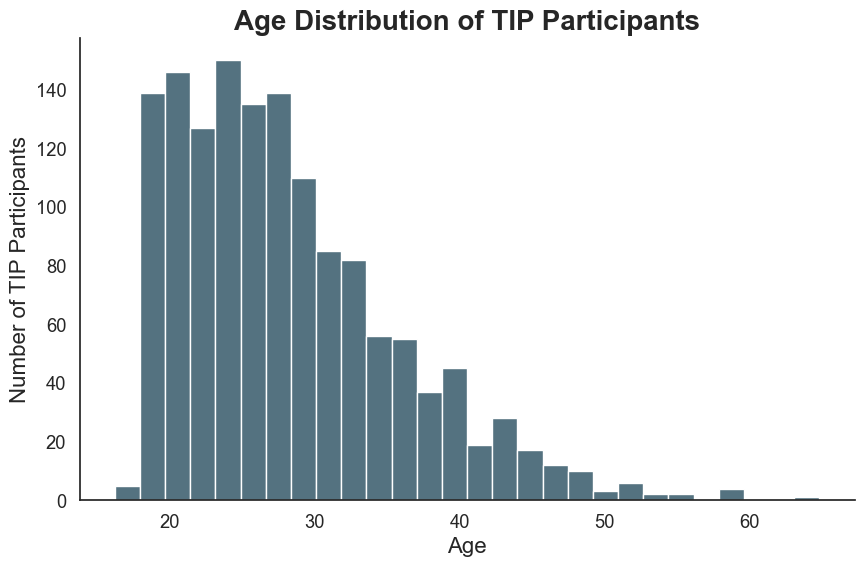

In [484]:
#Examine age distribution of participants

curr_df = df_student[(df_student['Status'] == 'Graduated') | (df_student['Status'] == 'Non Graduated')]
ages = curr_df['age'].dropna()
ages = ages[ages > 5]
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(ages)
sns.despine()
plt.title('Age Distribution of TIP Participants', fontdict={'fontsize': 20, 'fontweight': 'semibold'})
plt.xlabel('Age', fontdict={'fontsize': 16})
plt.ylabel('Number of TIP Participants', fontdict={'fontsize': 16})
plt.show()

C:\Users\sarah\AppData\Local\Temp\ipykernel_10680\338355821.py:21: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.histplot(
C:\Users\sarah\AppData\Local\Temp\ipykernel_10680\338355821.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Cohort')


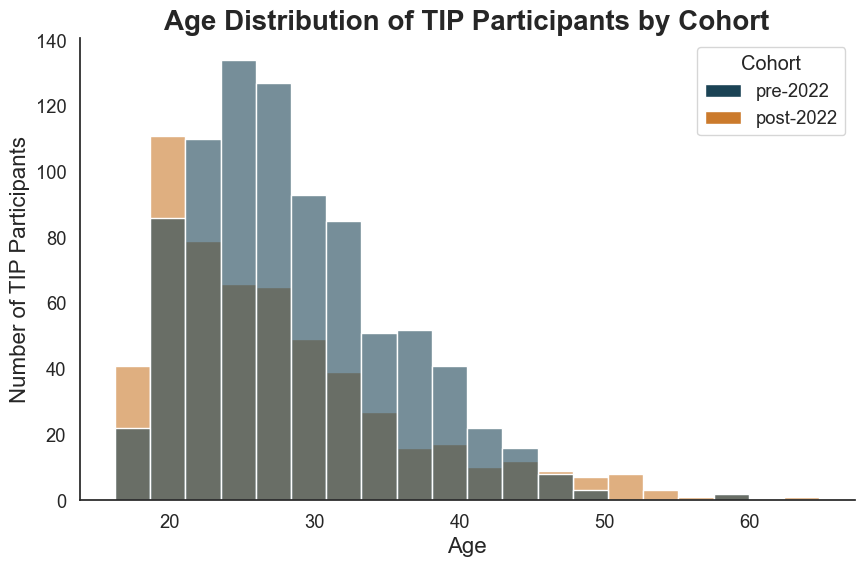

In [485]:
#age distribution by cohort

curr_df = df_student[(df_student['Status'] == 'Graduated') | (df_student['Status'] == 'Non Graduated')]
ages = curr_df['age'].dropna()
curr_df = curr_df[curr_df['age'] > 5]  

# Ensure cohort is numeric
curr_df['cohort_2022'] = pd.to_numeric(curr_df['cohort_2022'], errors='coerce')

#cohort label mapping
cohort_label_map = {
    1.0: "pre-2022",
    2.0: "post-2022"
}

cohorts = sorted(curr_df['cohort_2022'].unique())
palette = TIP_colors[:len(cohorts)]

# Plot histogram with overlayed cohorts
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(
    data=curr_df,
    x='age',
    hue='cohort_2022',       
    multiple='layer',        
    palette=TIP_colors,          
    bins=20,                 
    alpha=0.6                
)

sns.despine()
plt.title('Age Distribution of TIP Participants by Cohort', fontdict={'fontsize': 20, 'fontweight': 'semibold'})
plt.xlabel('Age', fontdict={'fontsize': 16})
plt.ylabel('Number of TIP Participants', fontdict={'fontsize': 16})
plt.legend(title='Cohort')
from matplotlib.patches import Patch
handles = [Patch(facecolor=palette[i], label=cohort_label_map[cohorts[i]]) 
           for i in range(len(cohorts))]

plt.legend(handles=handles, title='Cohort', loc='upper right')

ax.legend(handles=handles, title='Cohort', loc='upper right')
plt.show()

In [486]:
ages.describe()

count    1417.000000
mean       28.082928
std         7.675720
min         0.030075
25%        22.414217
50%        26.657553
75%        32.311688
max        64.787423
Name: age, dtype: float64

C:\Users\sarah\AppData\Local\Temp\ipykernel_10680\3134559474.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  graph_counts = df_student.groupby(['StartYear', 'Status']).size().unstack(fill_value=0)


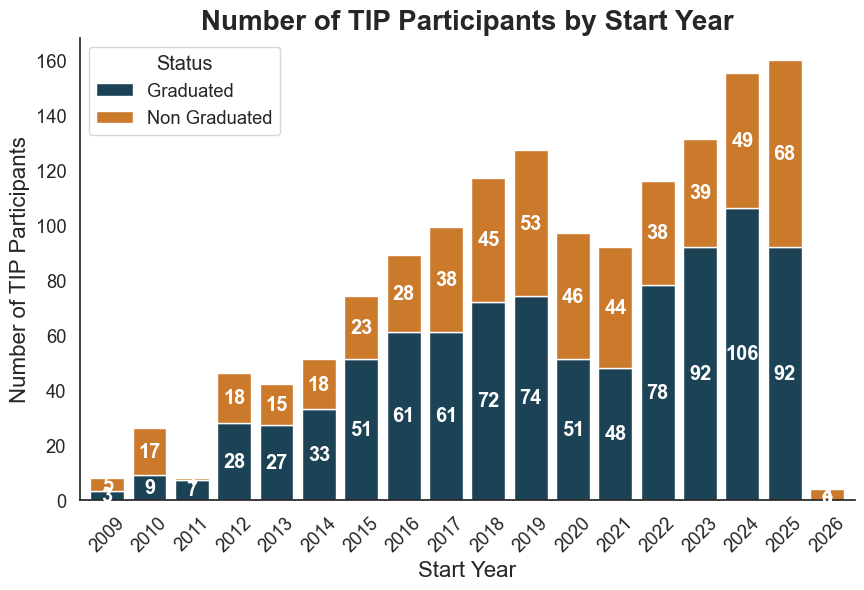

In [487]:
#Examine number and type of participants over time

fig, ax = plt.subplots(figsize=(10, 6))

status_order = ["Graduated", "Non Graduated"]
df_student['Status'] = pd.Categorical(df_student['Status'], categories=status_order, ordered=True)

graph_counts = df_student.groupby(['StartYear', 'Status']).size().unstack(fill_value=0) 
graph_counts.plot(kind='bar', stacked=True, ax=ax, width=0.8)

for container in ax.containers:
    ax.bar_label(container, label_type='center', color='white', fontweight='bold')

sns.despine()
plt.xticks(rotation=45)
plt.title('Number of TIP Participants by Start Year', fontdict={'fontsize': 20, 'fontweight': 'semibold'})
plt.xlabel('Start Year', fontdict={'fontsize': 16})
plt.ylabel('Number of TIP Participants', fontdict={'fontsize': 16})
plt.show()

In [488]:
#Difference in race between cohorts
##overall
table = pd.crosstab(df_student["cohort_2022"], df_student["race"])
chi2, p, dof, expected = chi2_contingency(table)

print("Full Cohort")
print(table)
print("Chi-square:", chi2)
print("p-value:", p)

##within cohort 1
##graduated
print("#################")
print("Within Cohort 1 Only")
table = pd.crosstab(df_c1["Status"], df_c1["race"])
chi2, p, dof, expected = chi2_contingency(table)

print(table)
print("Chi-square:", chi2)
print("p-value:", p)

##within cohort 2
##graduated
print("#################")
print("Within Cohort 2 Only")
table = pd.crosstab(df_c2["cohort_2022"], df_c2["race"])
chi2, p, dof, expected = chi2_contingency(table)

print(table)
print("Chi-square:", chi2)
print("p-value:", p)

##graduated
print("#################")
print("Among Grads Only")
table = pd.crosstab(df_grad["cohort_2022"], df_grad["race"])
chi2, p, dof, expected = chi2_contingency(table)

print(table)
print("Chi-square:", chi2)
print("p-value:", p)

##nongraduated
print("#################")
print("Among Non-Grads Only")
table = pd.crosstab(df_non_grad["cohort_2022"], df_non_grad["race"])
chi2, p, dof, expected = chi2_contingency(table)

print(table)
print("Chi-square:", chi2)
print("p-value:", p)

Full Cohort
race         Black  Other  White
cohort_2022                     
1.0            729      0     94
2.0            346      1     25
Chi-square: 8.457955695515874
p-value: 0.014567272911767343
#################
Within Cohort 1 Only
race           Black  White
Status                     
Graduated        431     60
Non Graduated    298     34
Chi-square: 0.5836162603899646
p-value: 0.4448983430243185
#################
Within Cohort 2 Only
race         Black  Other  White
cohort_2022                     
2.0            346      1     25
Chi-square: 0.0
p-value: 1.0
#################
Among Grads Only
race         Black  Other  White
cohort_2022                     
1.0            431      0     60
2.0            236      1     15
Chi-square: 9.068446234646231
p-value: 0.01073524401284729
#################
Among Non-Grads Only
race         Black  White
cohort_2022              
1.0            298     34
2.0            110     10
Chi-square: 0.18021410508343516
p-value: 0.6711893

In [489]:
#Difference in race between cohorts, young participants only (age subgroup analyses)
##overall
table = pd.crosstab(df_student_young["cohort_2022"], df_student_young["race"])
chi2, p, dof, expected = chi2_contingency(table)

print("Full Cohort, Participants <= 24 years old")
print(table)
print("Chi-square:", chi2)
print("p-value:", p)

##within cohort 1
df_c1_young = df_student_young[df_student_young["cohort_2022"] == 1].copy() 
##graduated
print("#################")
print("Within Cohort 1 Only, Participants <= 24 years old")
table = pd.crosstab(df_c1_young["Status"], df_c1_young["race"])
chi2, p, dof, expected = chi2_contingency(table)

print(table)
print("Chi-square:", chi2)
print("p-value:", p)

##within cohort 2
##graduated
df_c2_young = df_student_young[df_student_young["cohort_2022"] ==2].copy()
print("#################")
print("Within Cohort 2 Only, Participants <= 24 years old")
table = pd.crosstab(df_c2_young["cohort_2022"], df_c2_young["race"])
chi2, p, dof, expected = chi2_contingency(table)

print(table)
print("Chi-square:", chi2)
print("p-value:", p)

##graduated
df_grad_young = df_student_young[df_student_young["Status"] == "Graduated"].copy()
print("#################")
print("Among Grads Only, Participants <= 24 years old")
table = pd.crosstab(df_grad_young["cohort_2022"], df_grad_young["race"])
chi2, p, dof, expected = chi2_contingency(table)

print(table)
print("Chi-square:", chi2)
print("p-value:", p)

##nongraduated
df_nongrad_young = df_student_young[df_student_young["Status"] == "Non Graduated"].copy()
print("#################")
print("Among Non-Grads Only, Participants <= 24 years old")
table = pd.crosstab(df_nongrad_young["cohort_2022"], df_nongrad_young["race"])
chi2, p, dof, expected = chi2_contingency(table)

print(table)
print("Chi-square:", chi2)
print("p-value:", p)

Full Cohort, Participants <= 24 years old
race         Black  White
cohort_2022              
1.0            207     23
2.0            155     11
Chi-square: 1.0012090583015683
p-value: 0.31701812790191514
#################
Within Cohort 1 Only, Participants <= 24 years old
race           Black  White
Status                     
Graduated         91     11
Non Graduated    116     12
Chi-square: 0.017616421568627492
p-value: 0.8944093930256996
#################
Within Cohort 2 Only, Participants <= 24 years old
race         Black  White
cohort_2022              
2.0            155     11
Chi-square: 0.0
p-value: 1.0
#################
Among Grads Only, Participants <= 24 years old
race         Black  White
cohort_2022              
1.0             91     11
2.0            100      7
Chi-square: 0.7158710244874982
p-value: 0.39750163685779005
#################
Among Non-Grads Only, Participants <= 24 years old
race         Black  White
cohort_2022              
1.0            116     12


In [490]:
#Difference in mean age
##overall
age1 = pd.to_numeric(df_student[df_student["cohort_2022"] == 1]["age"], errors="coerce").dropna()
age2 = pd.to_numeric(df_student[df_student["cohort_2022"] == 2]["age"], errors="coerce").dropna()

t, p = ttest_ind(age1, age2, equal_var=False)

print("Age Across Cohorts")
print("t-value:", t)
print("p-value:", p)
print("n1:", len(age1))
print("n2:", len(age2))

##within cohort 1
age1 = pd.to_numeric(df_c1[df_c1["Status"] == "Graduated"]["age"], errors="coerce").dropna()
age2 = pd.to_numeric(df_c1[df_c1["Status"] == "Non Graduated"]["age"], errors="coerce").dropna()

t, p = ttest_ind(age1, age2, equal_var=False)
print("#################")
print("Age within Cohort 1 Only")
print("t-value:", t)
print("p-value:", p)
print("n1:", len(age1))
print("n2:", len(age2))

##within cohort 2
age1 = pd.to_numeric(df_c2[df_c2["Status"] == "Graduated"]["age"], errors="coerce").dropna()
age2 = pd.to_numeric(df_c2[df_c2["Status"] == "Non Graduated"]["age"], errors="coerce").dropna()

t, p = ttest_ind(age1, age2, equal_var=False)
print("#################")
print("Age within Cohort 2 Only")
print("t-value:", t)
print("p-value:", p)
print("n1:", len(age1))
print("n2:", len(age2))

##graduated
age1 = pd.to_numeric(df_grad[df_grad["cohort_2022"] == 1]["age"], errors="coerce").dropna()
age2 = pd.to_numeric(df_grad[df_grad["cohort_2022"] == 2]["age"], errors="coerce").dropna()

t, p = ttest_ind(age1, age2, equal_var=False)
print("#################")
print("Age among Grads Only")
print("t-value:", t)
print("p-value:", p)
print("n1:", len(age1))
print("n2:", len(age2))

##nongraduated
age1 = pd.to_numeric(df_non_grad[df_non_grad["cohort_2022"] == 1]["age"], errors="coerce").dropna()
age2 = pd.to_numeric(df_non_grad[df_non_grad["cohort_2022"] == 2]["age"], errors="coerce").dropna()

t, p = ttest_ind(age1, age2, equal_var=False)
print("#################")
print("Age among Non-Grads Only")
print("t-value:", t)
print("p-value:", p)
print("n1:", len(age1))
print("n2:", len(age2))

Age Across Cohorts
t-value: 2.5409236404601176
p-value: 0.011205003231096931
n1: 852
n2: 565
#################
Age within Cohort 1 Only
t-value: 5.172278970130134
p-value: 2.9373258807692535e-07
n1: 509
n2: 343
#################
Age within Cohort 2 Only
t-value: 2.35388211507211
p-value: 0.01905091827641157
n1: 368
n2: 197
#################
Age among Grads Only
t-value: 2.6085626003265237
p-value: 0.009291328280493108
n1: 509
n2: 368
#################
Age among Non-Grads Only
t-value: 1.2152885835120941
p-value: 0.22515421257285062
n1: 343
n2: 197


In [491]:
#Difference in gender between cohorts
##overall
table = pd.crosstab(df_student["cohort_2022"], df_student["gender"])
chi2, p, dof, expected = chi2_contingency(table)

print("Full Cohort")
print(table)
print("Chi-square:", chi2)
print("p-value:", p)

##within cohort 1
df_c1 = df_student[df_student["cohort_2022"]==1].copy()
table = pd.crosstab(df_c1["Status"], df_c1["gender"])
chi2, p, dof, expected = chi2_contingency(table)

print("#################")
print("Within Cohort 1")
print(table)
print("Chi-square:", chi2)
print("p-value:", p)

##within cohort 2
df_c2 = df_student[df_student["cohort_2022"]==2].copy()
table = pd.crosstab(df_c2["Status"], df_c2["gender"])
chi2, p, dof, expected = chi2_contingency(table)

print("#################")
print("Within Cohort 2")
print(table)
print("Chi-square:", chi2)
print("p-value:", p)

##graduated
print("#################")
print("Among Grads Only")
table = pd.crosstab(df_grad["cohort_2022"], df_grad["gender"])
chi2, p, dof, expected = chi2_contingency(table)

print(table)
print("Chi-square:", chi2)
print("p-value:", p)

##nongraduated
print("#################")
print("Among Non-Grads Only")
table = pd.crosstab(df_non_grad["cohort_2022"], df_non_grad["gender"])
chi2, p, dof, expected = chi2_contingency(table)

print(table)
print("Chi-square:", chi2)
print("p-value:", p)

Full Cohort
gender       Female  Male
cohort_2022              
1.0              59   768
2.0              65   310
Chi-square: 27.916617954410302
p-value: 1.2665729639787169e-07
#################
Within Cohort 1
gender         Female  Male
Status                     
Graduated          35   459
Non Graduated      24   309
Chi-square: 0.0
p-value: 1.0
#################
Within Cohort 2
gender         Female  Male
Status                     
Graduated          48   207
Non Graduated      17   103
Chi-square: 0.9313763501678587
p-value: 0.334505536561334
#################
Among Grads Only
gender       Female  Male
cohort_2022              
1.0              35   459
2.0              48   207
Chi-square: 22.3429754024074
p-value: 2.280456760001165e-06
#################
Among Non-Grads Only
gender       Female  Male
cohort_2022              
1.0              24   309
2.0              17   103
Chi-square: 4.3792875625596
p-value: 0.03637819974804068


In [492]:
#Difference in gender between cohorts, younger participants (age subgroup analyses)
##overall
table = pd.crosstab(df_student_young["cohort_2022"], df_student_young["gender"])
chi2, p, dof, expected = chi2_contingency(table)

print("Full Cohort, Participants <= 24 years old")
print(table)
print("Chi-square:", chi2)
print("p-value:", p)

##within cohort 1
table = pd.crosstab(df_c1_young["Status"], df_c1_young["gender"])
chi2, p, dof, expected = chi2_contingency(table)

print("#################")
print("Within Cohort 1, Participants <= 24 years old")
print(table)
print("Chi-square:", chi2)
print("p-value:", p)

##within cohort 2
table = pd.crosstab(df_c2_young["Status"], df_c2_young["gender"])
chi2, p, dof, expected = chi2_contingency(table)

print("#################")
print("Within Cohort 2, Participants <= 24 years old")
print(table)
print("Chi-square:", chi2)
print("p-value:", p)

##graduated
print("#################")
print("Among Grads Only, Participants <= 24 years old")
table = pd.crosstab(df_grad_young["cohort_2022"], df_grad_young["gender"])
chi2, p, dof, expected = chi2_contingency(table)

print(table)
print("Chi-square:", chi2)
print("p-value:", p)

##nongraduated
print("#################")
print("Among Non-Grads Only, Participants <= 24 years old")
table = pd.crosstab(df_nongrad_young["cohort_2022"], df_nongrad_young["gender"])
chi2, p, dof, expected = chi2_contingency(table)

print(table)
print("Chi-square:", chi2)
print("p-value:", p)

Full Cohort, Participants <= 24 years old
gender       Female  Male
cohort_2022              
1.0              21   209
2.0              34   134
Chi-square: 9.14687268260535
p-value: 0.0024914351866134957
#################
Within Cohort 1, Participants <= 24 years old
gender         Female  Male
Status                     
Graduated           9    93
Non Graduated      12   116
Chi-square: 0.0
p-value: 1.0
#################
Within Cohort 2, Participants <= 24 years old
gender         Female  Male
Status                     
Graduated          24    85
Non Graduated      10    49
Chi-square: 0.33579775530317135
p-value: 0.5622649391667862
#################
Among Grads Only, Participants <= 24 years old
gender       Female  Male
cohort_2022              
1.0               9    93
2.0              24    85
Chi-square: 5.9890389115541005
p-value: 0.014395043344392193
#################
Among Non-Grads Only, Participants <= 24 years old
gender       Female  Male
cohort_2022              
1.

## Data Cleaning of TIP_MergedSentencingData and Offense Descriptive Analysis

In [203]:
df_convictions = pd.read_csv(r'C:\Users\sarah\Documents\CMU\Spring 2026\Systems Synthesis\Data\Matching Data\convictions_matched_to_tip_final.csv', parse_dates=['DOF', 'DOS', 'StartDate', 'InterviewedDate', 'EndDate', 'GraduatedDate'])

#remove any timezone info
for c in ['DOF', 'DOS', 'StartDate', 'InterviewedDate', 'EndDate', 'GraduatedDate']:
    if c in df_convictions.columns:
        df_convictions[c] = df_convictions[c].dt.tz_localize(None)

#keep only rows where offense indicator = 1
df_convictions = df_convictions[df_convictions['offense_indicator'] == 1]

df_convictions = df_convictions.rename(columns={
    'Status' : 'tip_status',
})

#calculate whether the offense occurred before the participant started TIP
df_convictions['OffenseBeforeStart'] = df_convictions.apply(lambda x: x['DOS'] < x['StartDate'] if not pd.isnull(x['StartDate']) else (x['DOS'] < x['InterviewedDate'] if not pd.isnull(x['InterviewedDate']) else False), axis=1)

In [204]:
df_student['OffenseBeforeStart'] = df_student['tip_id'].apply(lambda x: x in df_convictions[df_convictions['OffenseBeforeStart'] == True]['tip_id'].unique())

In [205]:
df_convictions.head()

,tip_id,DOB,tip_status,GraduatedDate,InterviewedDate,StartDate,EndDate,DriversLicense,Course,CreatedDate,DOF,DOS,OGS,INCMIN,PCS_OFF_ID,YearsSinceTIP,offense_indicator,OffenseBeforeStart
0,1,1992-08-26T00:00:00Z,DNF: Dropped Out,NaT,NaT,2018-07-12,2018-08-01,No,Introduction to Masonry,2018-07-11T00:00:00Z,2016-01-09,2016-07-12,9.0,NaN,1068451.0,-2.559890,1,True
1,1,1992-08-26T00:00:00Z,DNF: Dropped Out,NaT,NaT,2018-07-12,2018-08-01,No,Introduction to Masonry,2018-07-11T00:00:00Z,2016-01-09,2016-07-12,3.0,NaN,1068451.0,-2.559890,1,True
2,1,1992-08-26T00:00:00Z,DNF: Dropped Out,NaT,NaT,2018-07-12,2018-08-01,No,Introduction to Masonry,2018-07-11T00:00:00Z,2016-01-09,2016-07-12,10.0,NaN,1068451.0,-2.559890,1,True
3,2,1997-01-27T00:00:00Z,DNF: Asked to Leave,NaT,NaT,2018-07-12,NaT,No,Introduction to Masonry,2018-07-11T00:00:00Z,2017-05-02,2018-05-22,9.0,NaN,1041834.0,-1.522245,1,True
4,2,1997-01-27T00:00:00Z,DNF: Asked to Leave,NaT,NaT,2018-07-12,NaT,No,Introduction to Masonry,2018-07-11T00:00:00Z,2017-05-02,2018-05-22,1.0,0.131579,1041834.0,-1.522245,1,True


In [206]:
df_student.head()

,tip_id,CreatedDate,tip_status,Course,StartDate,EndDate,InterviewedDate,Interviewed Only Date,DriversLicense,EndDriversLicense,...,cohort_2022,StartYear,census_tract,gender,race,age_band,ValidYears,ValidYearsPre_UI,ValidYearsPre_Arrests,OffenseBeforeStart
0,1,2018-07-11 00:00:00+00:00,DNF: Dropped Out,Introduction to Masonry,2018-07-12,2018-08-01,NaT,NaT,No,NaN,...,1.0,2018,4.200356e+10,Male,Black,25-34,6.417522,-1.524983,-4.525667,True
1,2,2018-07-11 00:00:00+00:00,DNF: Asked to Leave,Introduction to Masonry,2018-07-12,NaT,NaT,NaT,No,NaN,...,1.0,2018,4.200352e+10,Male,Black,<=24,6.472279,-1.524983,-4.525667,True
2,3,2018-07-11 00:00:00+00:00,DNF: Asked to Leave,Introduction to Masonry,2018-07-23,NaT,NaT,NaT,NaN,NaN,...,1.0,2018,4.200356e+10,Male,Black,<=24,6.442163,-1.555099,-4.555784,False
3,4,2018-07-12 00:00:00+00:00,Graduated-Employed,Introduction to Masonry,2013-08-12,2013-10-16,NaT,NaT,NaN,NaN,...,1.0,2013,4.200313e+10,Male,Black,25-34,11.208761,3.389459,0.388775,False
4,5,2018-07-12 00:00:00+00:00,Graduated-Employed,Introduction to Masonry,2010-11-29,2011-02-04,NaT,NaT,NaN,NaN,...,1.0,2010,NaN,NaN,NaN,<=24,13.905544,6.091718,3.091034,False


In [207]:
#Check percentage of participants overall that had an offense before starting TIP

d = df_student.copy()

# make sure it's boolean (handles True/False, "True"/"False", 1/0)
d["OffenseBeforeStart"] = d["OffenseBeforeStart"].map(
    lambda x: True if x is True or x == 1 or str(x).strip().lower() == "true"
    else False if x is False or x == 0 or str(x).strip().lower() == "false"
    else np.nan
)

summary = (
    d.groupby("Status")["OffenseBeforeStart"]
     .agg(
         n_total=lambda s: s.notna().sum(),
         n_true=lambda s: (s == True).sum()
     )
     .reset_index()
)

summary["pct_true"] = (summary["n_true"] / summary["n_total"] * 100).round(2)

print(summary)

          Status  n_total  n_true  pct_true
0      Graduated      893     285     31.91
1  Non Graduated      549     173     31.51


C:\Users\sarah\AppData\Local\Temp\ipykernel_10680\482219411.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  d.groupby("Status")["OffenseBeforeStart"]


In [208]:
#Repeat for young students

d = d[d['age_band'] == '<=24'].copy()

# make sure it's boolean (handles True/False, "True"/"False", 1/0)
d["OffenseBeforeStart"] = d["OffenseBeforeStart"].map(
    lambda x: True if x is True or x == 1 or str(x).strip().lower() == "true"
    else False if x is False or x == 0 or str(x).strip().lower() == "false"
    else np.nan
)

summary = (
    d.groupby("Status")["OffenseBeforeStart"]
     .agg(
         n_total=lambda s: s.notna().sum(),
         n_true=lambda s: (s == True).sum()
     )
     .reset_index()
)

summary["pct_true"] = (summary["n_true"] / summary["n_total"] * 100).round(2)

print(summary)

          Status  n_total  n_true  pct_true
0      Graduated      255      69     27.06
1  Non Graduated      231      72     31.17


C:\Users\sarah\AppData\Local\Temp\ipykernel_10680\3791394302.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  d.groupby("Status")["OffenseBeforeStart"]


C:\Users\sarah\AppData\Local\Temp\ipykernel_10680\839870675.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_df = grouped_df.groupby(['StartYear', 'Status'])['OffenseBeforeStart'].mean().reset_index()
C:\Users\sarah\AppData\Local\Temp\ipykernel_10680\839870675.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for status, subset in grouped_df.groupby('Status'):


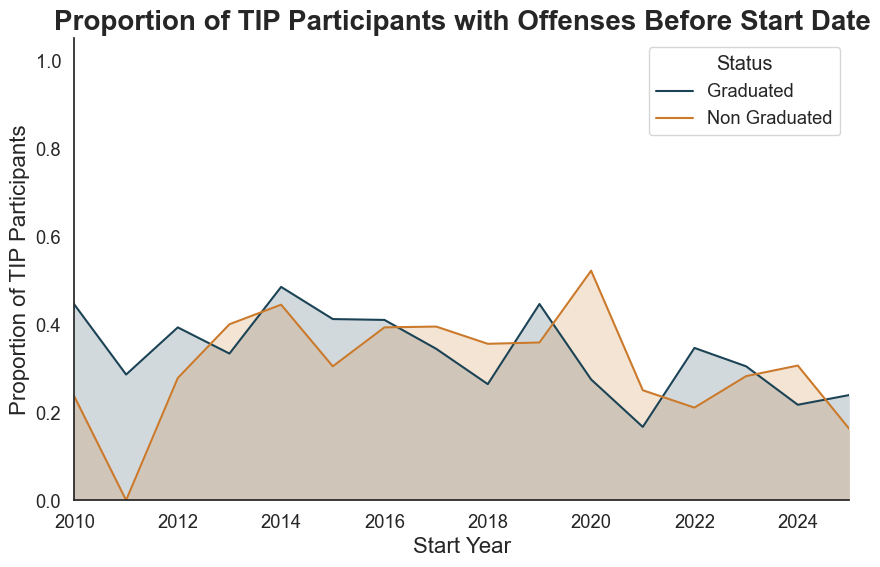

In [209]:
#Examine proportion with an offense before start by year and by status

fig, ax = plt.subplots(figsize=(10, 6))

grouped_df = df_student.copy()
grouped_df['Status'] = pd.Categorical(grouped_df['Status'], categories=["Graduated", "Non Graduated"], ordered=True)

grouped_df = grouped_df.groupby(['StartYear', 'Status'])['OffenseBeforeStart'].mean().reset_index()
sns.lineplot(
    data=grouped_df,
    x='StartYear',
    y='OffenseBeforeStart',
    hue='Status',
    ax=ax
)
for status, subset in grouped_df.groupby('Status'):
    ax.fill_between(
        subset['StartYear'], subset['OffenseBeforeStart'], 0, alpha=0.2  
    )

sns.despine()

plt.title('Proportion of TIP Participants with Offenses Before Start Date', fontdict={'fontsize': 20, 'fontweight': 'semibold'})
plt.xlabel('Start Year', fontdict={'fontsize': 16})
plt.ylabel('Proportion of TIP Participants', fontdict={'fontsize': 16})
plt.ylim(0, 1.05)
plt.xlim(2010, 2025)
plt.show()

In [210]:
df_convictions = pd.merge(
    df_convictions,
    df_student[['tip_id', 'cohort_2022', 'ValidYears', 'Status']],
    on='tip_id',
    how='left'
)
df_convictions['cohort_2022'] = pd.to_numeric(df_convictions['cohort_2022'], errors='coerce')
df_convictions.head

<bound method NDFrame.head of       tip_id                   DOB           tip_status GraduatedDate  \
0          1  1992-08-26T00:00:00Z     DNF: Dropped Out           NaT   
1          1  1992-08-26T00:00:00Z     DNF: Dropped Out           NaT   
2          1  1992-08-26T00:00:00Z     DNF: Dropped Out           NaT   
3          2  1997-01-27T00:00:00Z  DNF: Asked to Leave           NaT   
4          2  1997-01-27T00:00:00Z  DNF: Asked to Leave           NaT   
...      ...                   ...                  ...           ...   
7315    2698  1996-06-25T00:00:00Z             Enrolled           NaT   
7316    2698  1996-06-25T00:00:00Z             Enrolled           NaT   
7317    2698  1996-06-25T00:00:00Z             Enrolled           NaT   
7318    2698  1996-06-25T00:00:00Z             Enrolled           NaT   
7319    2698  1996-06-25T00:00:00Z             Enrolled           NaT   

     InterviewedDate  StartDate    EndDate DriversLicense  \
0                NaT 2018-07-12 

C:\Users\sarah\AppData\Local\Temp\ipykernel_10680\948716352.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Status")["tip_id"]


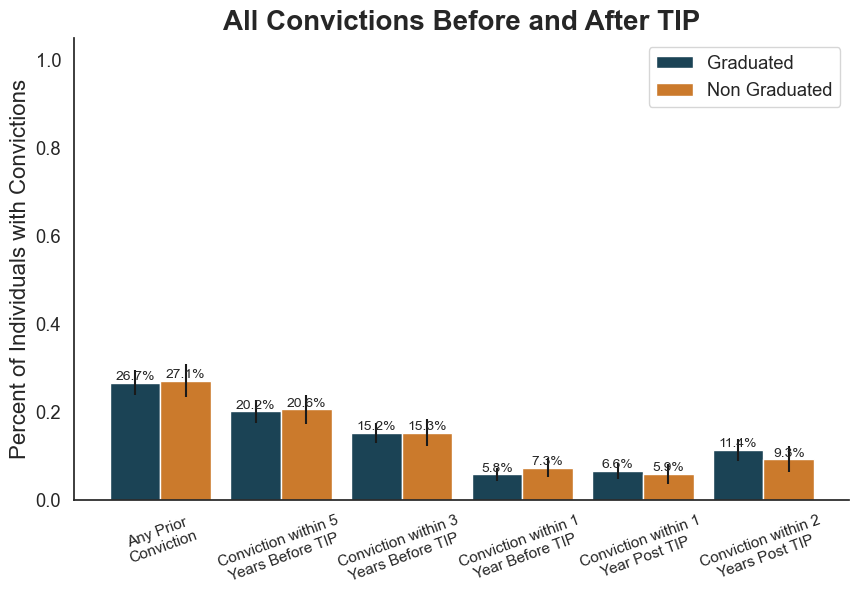

In [211]:
#Look at convictions pre/post TIP for all participants (no cohort distinction)

off = df_convictions.copy()

#Pre-TIP calculations - using cumulative time periods
#Because offense data goes back until 2001, we do not need to check ValidYearsPre for students - each student's pre-TIP years are
#assumed to be included in the offense dataset

pre_bins = {
    -1: [-1],             # 1 year pre
    -3: [-3, -2, -1],     # 1-3 years pre
    -5: [-5,-4,-3,-2,-1],  #1-5 years pre
    -30: list(range(-30, 0))  # any prior usage
}

off["YearsSinceTIP"] = pd.to_numeric(off["YearsSinceTIP"], errors="coerce")
off["YearsSinceTIP_int"] = off["YearsSinceTIP"].round().astype("Int64")

rows = []
for bin_edge, years in pre_bins.items():
    cur = off[off["YearsSinceTIP_int"].isin(years)]
    
    row = {"YearsSinceTIP": bin_edge}
    for status in ["Graduated", "Non Graduated"]:
        num = cur.loc[cur["Status"] == status, "tip_id"].nunique()
        row[status] = num
        
    rows.append(row)

pre_count = pd.DataFrame(rows)

# denominators for pre: total people per status

denom_pre = (
    df_student[(df_student["Status"].isin(["Graduated", "Non Graduated"]))]
    .groupby("Status")["tip_id"]
    .nunique()
    .to_dict()
)

z = 1.96
for status in ["Graduated", "Non Graduated"]:
    pre_count[f"{status} Percent"] = pre_count[status] / denom_pre.get(status, np.nan)
    p = pre_count[f"{status} Percent"]
    n = denom_pre.get(status, np.nan)
    se = np.sqrt(p * (1 - p) / n)
    pre_count[f"{status}_Upper_CI"] = (p + z * se).clip(0, 1)
    pre_count[f"{status}_Lower_CI"] = (p - z * se).clip(0, 1)

# -----------------------------
#post-period calculations
#not all participants will have valid post years in the data, so we will use "ValidYears" to check 

post_points = [1, 2]
rows = []

for i in post_points:
    cur = off[(off["YearsSinceTIP"] >= 0) & (off["YearsSinceTIP"] < i) & (off["ValidYears"] >= i)]

    row = {"YearsSinceTIP": i}
    for status in ["Graduated", "Non Graduated"]:
        num = cur.loc[cur["Status"] == status, "tip_id"].nunique()
        denom = df_student.loc[(df_student["Status"] == status) & (df_student["ValidYears"] >= i), "tip_id"].nunique()

        p = (num / denom) if denom > 0 else 0
        se = np.sqrt(p * (1 - p) / denom) if denom > 0 else np.nan

        row[f"{status}"] = num
        row[f"{status} Percent"] = p
        row[f"{status}_Upper_CI"] = min(1, p + z * se) if denom > 0 else np.nan
        row[f"{status}_Lower_CI"] = max(0, p - z * se) if denom > 0 else np.nan

    rows.append(row)

post_df = pd.DataFrame(rows)

# -----------------------------
#plot our pre and post period data together

label_map = {
    -30: "Any Prior\nConviction",
    -5: "Conviction within 5\nYears Before TIP",
    -3:  "Conviction within 3\nYears Before TIP",
    -1:  "Conviction within 1\nYear Before TIP",
     1:  "Conviction within 1\nYear Post TIP",
     2:  "Conviction within 2\nYears Post TIP"
}
order = [-30, -5, -3, -1, 1, 2]

pre_keep = pre_count[pre_count["YearsSinceTIP"].isin([-30, -5, -3, -1])].copy()
data = pd.concat([pre_keep, post_df], ignore_index=True)

data["label"] = data["YearsSinceTIP"].astype(int).map(label_map)
data["YearsSinceTIP"] = data["YearsSinceTIP"].astype(int)
data["YearsSinceTIP"] = pd.Categorical(data["YearsSinceTIP"], categories=order, ordered=True)
data = data.sort_values("YearsSinceTIP").reset_index(drop=True)


grad_err = np.abs(
    data[["Graduated_Upper_CI", "Graduated_Lower_CI"]].T.values - data["Graduated Percent"].values
)
non_grad_err = np.abs(
    data[["Non Graduated_Upper_CI", "Non Graduated_Lower_CI"]].T.values - data["Non Graduated Percent"].values
)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(data))
width = 0.42

ax.bar(x - width/2, data["Graduated Percent"], width=width, label="Graduated", yerr=grad_err, capsize=0)
ax.bar(x + width/2, data["Non Graduated Percent"], width=width, label="Non Graduated", yerr=non_grad_err, capsize=0)

ax.set_xticks(x)
ax.set_xticklabels(data["label"], rotation=20, ha="center", fontsize=11)

for xi, yi in zip(x - width/2, data["Graduated Percent"]):
    ax.text(xi, yi, f"{yi:.1%}", ha="center", va="bottom", fontsize=10)
for xi, yi in zip(x + width/2, data["Non Graduated Percent"]):
    ax.text(xi, yi, f"{yi:.1%}", ha="center", va="bottom", fontsize=10)

sns.despine()
plt.title("All Convictions Before and After TIP", fontdict={"fontsize": 20, "fontweight": "semibold"})
plt.ylabel("Percent of Individuals with Convictions", fontdict={"fontsize": 16})
plt.ylim(0, 1.05)
plt.legend(loc="upper right")
plt.show()


C:\Users\sarah\AppData\Local\Temp\ipykernel_10680\2576391968.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Status")["tip_id"]


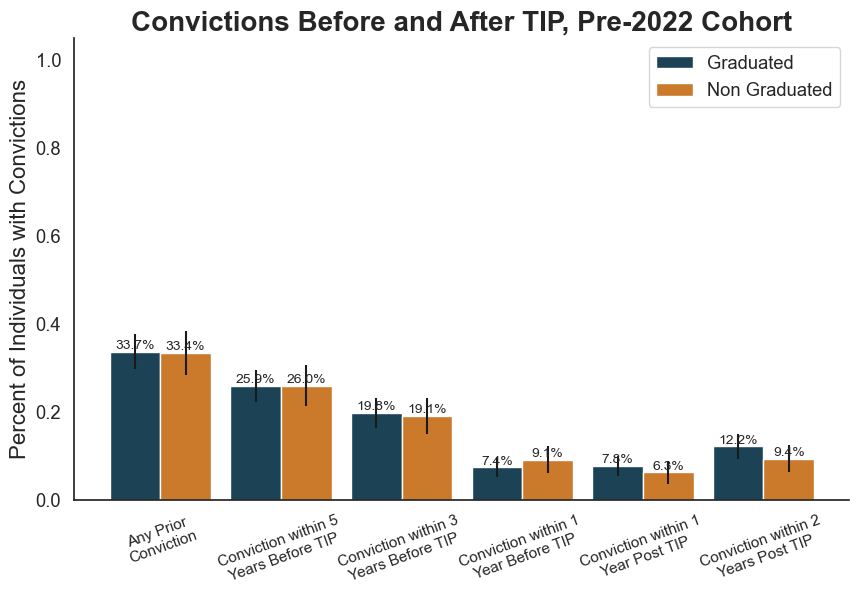

In [289]:
#repeat for COHORT 1 ONLY

off = df_convictions[df_convictions["cohort_2022"] == 1].copy()

#Pre-TIP calculations - using cumulative time periods
#Because offense data goes back until 2001, we do not need to check ValidYearsPre for students - each student's pre-TIP years are
#assumed to be included in the offense dataset

pre_bins = {
    -1: [-1],             # 1 year pre
    -3: [-3, -2, -1],     # 1-3 years pre
    -5: [-5,-4,-3,-2,-1],  #1-5 years pre
    -30: list(range(-30, 0))  # any prior usage
}

off["YearsSinceTIP"] = pd.to_numeric(off["YearsSinceTIP"], errors="coerce")
off["YearsSinceTIP_int"] = off["YearsSinceTIP"].round().astype("Int64")

rows = []
for bin_edge, years in pre_bins.items():
    cur = off[off["YearsSinceTIP_int"].isin(years)]
    
    row = {"YearsSinceTIP": bin_edge}
    for status in ["Graduated", "Non Graduated"]:
        num = cur.loc[cur["Status"] == status, "tip_id"].nunique()
        row[status] = num
        
    rows.append(row)

pre_count = pd.DataFrame(rows)

# denominators for pre: total people per status

denom_pre = (
    df_student[(df_student["Status"].isin(["Graduated", "Non Graduated"])) & (df_student["cohort_2022"] == 1)]
    .groupby("Status")["tip_id"]
    .nunique()
    .to_dict()
)

z = 1.96
for status in ["Graduated", "Non Graduated"]:
    pre_count[f"{status} Percent"] = pre_count[status] / denom_pre.get(status, np.nan)
    p = pre_count[f"{status} Percent"]
    n = denom_pre.get(status, np.nan)
    se = np.sqrt(p * (1 - p) / n)
    pre_count[f"{status}_Upper_CI"] = (p + z * se).clip(0, 1)
    pre_count[f"{status}_Lower_CI"] = (p - z * se).clip(0, 1)

# -----------------------------
#post-period calculations
#not all participants will have valid post years in the data, so we will use "ValidYears" to check 

post_points = [1, 2]
rows = []

for i in post_points:
    cur = off[(off["YearsSinceTIP"] >= 0) & (off["YearsSinceTIP"] < i) & (off["ValidYears"] >= i)]

    row = {"YearsSinceTIP": i}
    for status in ["Graduated", "Non Graduated"]:
        num = cur.loc[cur["Status"] == status, "tip_id"].nunique()
        denom = df_student.loc[(df_student["Status"] == status) & (df_student["ValidYears"] >= i) & (df_student["cohort_2022"] ==1), "tip_id"].nunique()

        p = (num / denom) if denom > 0 else 0
        se = np.sqrt(p * (1 - p) / denom) if denom > 0 else np.nan

        row[f"{status}"] = num
        row[f"{status} Percent"] = p
        row[f"{status}_Upper_CI"] = min(1, p + z * se) if denom > 0 else np.nan
        row[f"{status}_Lower_CI"] = max(0, p - z * se) if denom > 0 else np.nan

    rows.append(row)

post_df = pd.DataFrame(rows)

# -----------------------------
#plot our pre and post period data together

label_map = {
    -30: "Any Prior\nConviction",
    -5: "Conviction within 5\nYears Before TIP",
    -3:  "Conviction within 3\nYears Before TIP",
    -1:  "Conviction within 1\nYear Before TIP",
     1:  "Conviction within 1\nYear Post TIP",
     2:  "Conviction within 2\nYears Post TIP"
}
order = [-30, -5, -3, -1, 1, 2]

pre_keep = pre_count[pre_count["YearsSinceTIP"].isin([-30, -5, -3, -1])].copy()
data = pd.concat([pre_keep, post_df], ignore_index=True)

data["label"] = data["YearsSinceTIP"].astype(int).map(label_map)
data["YearsSinceTIP"] = data["YearsSinceTIP"].astype(int)
data["YearsSinceTIP"] = pd.Categorical(data["YearsSinceTIP"], categories=order, ordered=True)
data = data.sort_values("YearsSinceTIP").reset_index(drop=True)


grad_err = np.abs(
    data[["Graduated_Upper_CI", "Graduated_Lower_CI"]].T.values - data["Graduated Percent"].values
)
non_grad_err = np.abs(
    data[["Non Graduated_Upper_CI", "Non Graduated_Lower_CI"]].T.values - data["Non Graduated Percent"].values
)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(data))
width = 0.42

ax.bar(x - width/2, data["Graduated Percent"], width=width, label="Graduated", yerr=grad_err, capsize=0)
ax.bar(x + width/2, data["Non Graduated Percent"], width=width, label="Non Graduated", yerr=non_grad_err, capsize=0)

ax.set_xticks(x)
ax.set_xticklabels(data["label"], rotation=20, ha="center", fontsize=11)

for xi, yi in zip(x - width/2, data["Graduated Percent"]):
    ax.text(xi, yi, f"{yi:.1%}", ha="center", va="bottom", fontsize=10)
for xi, yi in zip(x + width/2, data["Non Graduated Percent"]):
    ax.text(xi, yi, f"{yi:.1%}", ha="center", va="bottom", fontsize=10)

sns.despine()
plt.title("Convictions Before and After TIP, Pre-2022 Cohort", fontdict={"fontsize": 20, "fontweight": "semibold"})
plt.ylabel("Percent of Individuals with Convictions", fontdict={"fontsize": 16})
plt.ylim(0, 1.05)
plt.legend(loc="upper right")
plt.show()


C:\Users\sarah\AppData\Local\Temp\ipykernel_10680\315375469.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Status")["tip_id"]


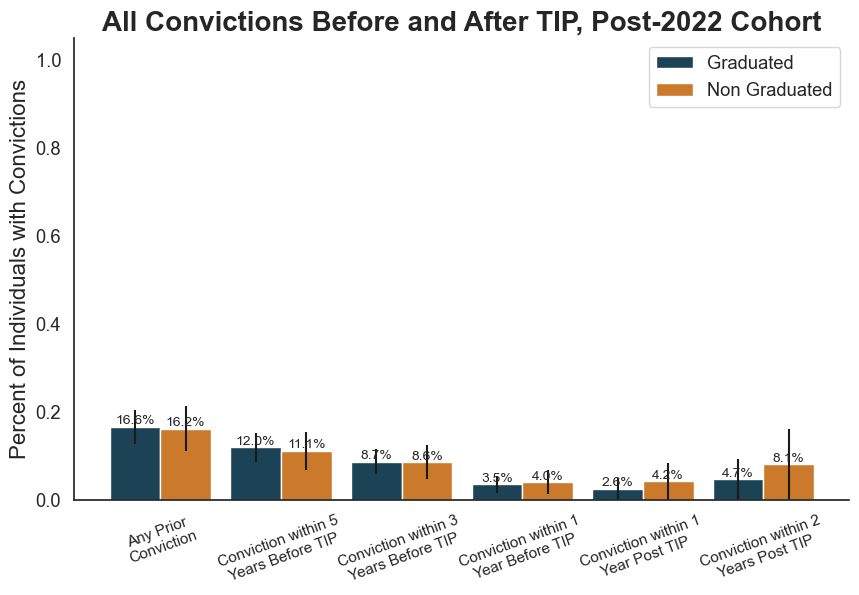

In [291]:
#Repeat for Cohort 2 ONLY

off = df_convictions[df_convictions["cohort_2022"] == 2].copy()

#Pre-TIP calculations - using cumulative time periods
#Because offense data goes back until 2001, we do not need to check ValidYearsPre for students - each student's pre-TIP years are
#assumed to be included in the offense dataset

pre_bins = {
    -1: [-1],             # 1 year pre
    -3: [-3, -2, -1],     # 1-3 years pre
    -5: [-5,-4,-3,-2,-1],  #1-5 years pre
    -30: list(range(-30, 0))  # any prior usage
}

off["YearsSinceTIP"] = pd.to_numeric(off["YearsSinceTIP"], errors="coerce")
off["YearsSinceTIP_int"] = off["YearsSinceTIP"].round().astype("Int64")

rows = []
for bin_edge, years in pre_bins.items():
    cur = off[off["YearsSinceTIP_int"].isin(years)]
    
    row = {"YearsSinceTIP": bin_edge}
    for status in ["Graduated", "Non Graduated"]:
        num = cur.loc[cur["Status"] == status, "tip_id"].nunique()
        row[status] = num
        
    rows.append(row)

pre_count = pd.DataFrame(rows)

# denominators for pre: total people per status

denom_pre = (
    df_student[(df_student["Status"].isin(["Graduated", "Non Graduated"])) & (df_student["cohort_2022"] == 2)]
    .groupby("Status")["tip_id"]
    .nunique()
    .to_dict()
)

z = 1.96
for status in ["Graduated", "Non Graduated"]:
    pre_count[f"{status} Percent"] = pre_count[status] / denom_pre.get(status, np.nan)
    p = pre_count[f"{status} Percent"]
    n = denom_pre.get(status, np.nan)
    se = np.sqrt(p * (1 - p) / n)
    pre_count[f"{status}_Upper_CI"] = (p + z * se).clip(0, 1)
    pre_count[f"{status}_Lower_CI"] = (p - z * se).clip(0, 1)

# -----------------------------
#post-period calculations
#not all participants will have valid post years in the data, so we will use "ValidYears" to check 

post_points = [1, 2]
rows = []

for i in post_points:
    cur = off[(off["YearsSinceTIP"] >= 0) & (off["YearsSinceTIP"] < i) & (off["ValidYears"] >= i)]

    row = {"YearsSinceTIP": i}
    for status in ["Graduated", "Non Graduated"]:
        num = cur.loc[cur["Status"] == status, "tip_id"].nunique()
        denom = df_student.loc[(df_student["Status"] == status) & (df_student["ValidYears"] >= i) & (df_student["cohort_2022"] ==2), "tip_id"].nunique()

        p = (num / denom) if denom > 0 else 0
        se = np.sqrt(p * (1 - p) / denom) if denom > 0 else np.nan

        row[f"{status}"] = num
        row[f"{status} Percent"] = p
        row[f"{status}_Upper_CI"] = min(1, p + z * se) if denom > 0 else np.nan
        row[f"{status}_Lower_CI"] = max(0, p - z * se) if denom > 0 else np.nan

    rows.append(row)

post_df = pd.DataFrame(rows)

# -----------------------------
#plot our pre and post period data together

label_map = {
    -30: "Any Prior\nConviction",
    -5: "Conviction within 5\nYears Before TIP",
    -3:  "Conviction within 3\nYears Before TIP",
    -1:  "Conviction within 1\nYear Before TIP",
     1:  "Conviction within 1\nYear Post TIP",
     2:  "Conviction within 2\nYears Post TIP"
}
order = [-30, -5, -3, -1, 1, 2]

pre_keep = pre_count[pre_count["YearsSinceTIP"].isin([-30, -5, -3, -1])].copy()
data = pd.concat([pre_keep, post_df], ignore_index=True)

data["label"] = data["YearsSinceTIP"].astype(int).map(label_map)
data["YearsSinceTIP"] = data["YearsSinceTIP"].astype(int)
data["YearsSinceTIP"] = pd.Categorical(data["YearsSinceTIP"], categories=order, ordered=True)
data = data.sort_values("YearsSinceTIP").reset_index(drop=True)


grad_err = np.abs(
    data[["Graduated_Upper_CI", "Graduated_Lower_CI"]].T.values - data["Graduated Percent"].values
)
non_grad_err = np.abs(
    data[["Non Graduated_Upper_CI", "Non Graduated_Lower_CI"]].T.values - data["Non Graduated Percent"].values
)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(data))
width = 0.42

ax.bar(x - width/2, data["Graduated Percent"], width=width, label="Graduated", yerr=grad_err, capsize=0)
ax.bar(x + width/2, data["Non Graduated Percent"], width=width, label="Non Graduated", yerr=non_grad_err, capsize=0)

ax.set_xticks(x)
ax.set_xticklabels(data["label"], rotation=20, ha="center", fontsize=11)

for xi, yi in zip(x - width/2, data["Graduated Percent"]):
    ax.text(xi, yi, f"{yi:.1%}", ha="center", va="bottom", fontsize=10)
for xi, yi in zip(x + width/2, data["Non Graduated Percent"]):
    ax.text(xi, yi, f"{yi:.1%}", ha="center", va="bottom", fontsize=10)

sns.despine()
plt.title("All Convictions Before and After TIP, Post-2022 Cohort", fontdict={"fontsize": 20, "fontweight": "semibold"})
plt.ylabel("Percent of Individuals with Convictions", fontdict={"fontsize": 16})
plt.ylim(0, 1.05)
plt.legend(loc="upper right")
plt.show()


## Data Cleaning of arrest_data and Arrests Descriptive Analysis

In [292]:
df_arrests = pd.read_csv(r'C:\Users\sarah\Documents\CMU\Spring 2026\Systems Synthesis\Data\Pre-Cleaning\arrest_data.csv', parse_dates=['ArrestDate', 'StartDate', 'EndDate', 'InterviewedDate', 'GraduatedDate'])
df_arrests['ArrestBeforeStart'] = df_arrests.apply(lambda x: x['ArrestDate'] < x['StartDate'] if not pd.isnull(x['StartDate']) else (x['ArrestDate'] < x['InterviewedDate'] if not pd.isnull(x['InterviewedDate']) else False), axis=1)

In [293]:
#create arrest before start value in our overall student dataframe
df_student['ArrestBeforeStart'] = df_student['tip_id'].apply(lambda x: x in df_arrests[df_arrests['ArrestBeforeStart'] == True]['tip_id'].unique())

C:\Users\sarah\AppData\Local\Temp\ipykernel_10680\2014475968.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_df = grouped_df.groupby(['StartYear', 'Status'])['ArrestBeforeStart'].mean().reset_index()
C:\Users\sarah\AppData\Local\Temp\ipykernel_10680\2014475968.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for status, subset in grouped_df.groupby('Status'):


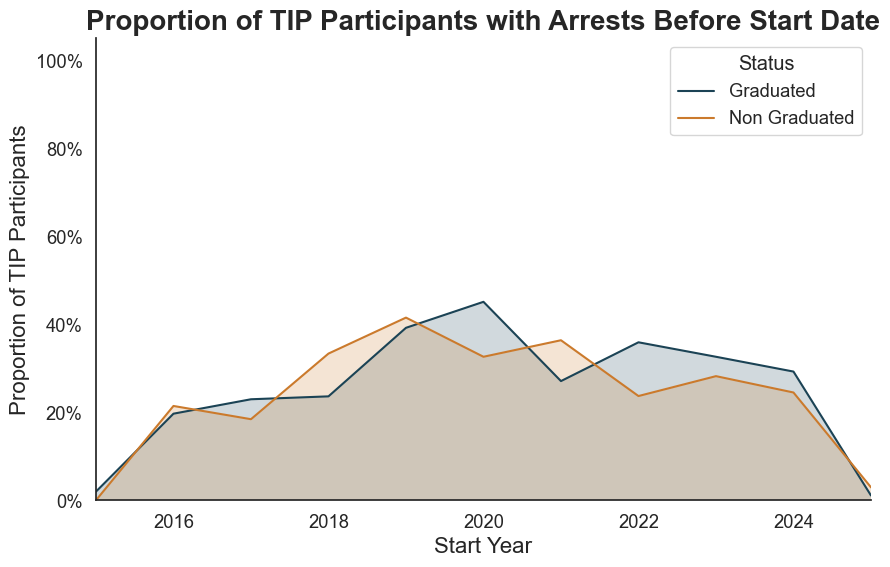

In [294]:
#Examine proportion of TIP participants with arrests before start date

fig, ax = plt.subplots(figsize=(10, 6))

grouped_df = df_student.copy()
grouped_df['Status'] = pd.Categorical(grouped_df['Status'], categories=["Graduated", "Non Graduated"], ordered=True)

grouped_df = grouped_df.groupby(['StartYear', 'Status'])['ArrestBeforeStart'].mean().reset_index()
sns.lineplot(
    data=grouped_df,
    x='StartYear',
    y='ArrestBeforeStart',
    hue='Status',
    ax=ax
)
for status, subset in grouped_df.groupby('Status'):
    ax.fill_between(
        subset['StartYear'], subset['ArrestBeforeStart'], 0, alpha=0.2  
    )

sns.despine()

ax.yaxis.set_major_formatter('{:.0%}'.format)
plt.title('Proportion of TIP Participants with Arrests Before Start Date', fontdict={'fontsize': 20, 'fontweight': 'semibold'})
plt.xlabel('Start Year', fontdict={'fontsize': 16})
plt.ylabel('Proportion of TIP Participants', fontdict={'fontsize': 16})
plt.ylim(0, 1.05)
plt.xlim(2015, 2025)
plt.show()

## OGS

In [295]:
df_convictions.head()

,tip_id,DOB,tip_status,GraduatedDate,InterviewedDate,StartDate,EndDate,DriversLicense,Course,CreatedDate,...,DOS,OGS,INCMIN,PCS_OFF_ID,YearsSinceTIP,offense_indicator,OffenseBeforeStart,cohort_2022,ValidYears,Status
0,1,1992-08-26T00:00:00Z,DNF: Dropped Out,NaT,NaT,2018-07-12,2018-08-01,No,Introduction to Masonry,2018-07-11T00:00:00Z,...,2016-07-12,9.0,NaN,1068451.0,-2.559890,1,True,1.0,6.417522,Non Graduated
1,1,1992-08-26T00:00:00Z,DNF: Dropped Out,NaT,NaT,2018-07-12,2018-08-01,No,Introduction to Masonry,2018-07-11T00:00:00Z,...,2016-07-12,3.0,NaN,1068451.0,-2.559890,1,True,1.0,6.417522,Non Graduated
2,1,1992-08-26T00:00:00Z,DNF: Dropped Out,NaT,NaT,2018-07-12,2018-08-01,No,Introduction to Masonry,2018-07-11T00:00:00Z,...,2016-07-12,10.0,NaN,1068451.0,-2.559890,1,True,1.0,6.417522,Non Graduated
3,2,1997-01-27T00:00:00Z,DNF: Asked to Leave,NaT,NaT,2018-07-12,NaT,No,Introduction to Masonry,2018-07-11T00:00:00Z,...,2018-05-22,9.0,NaN,1041834.0,-1.522245,1,True,1.0,6.472279,Non Graduated
4,2,1997-01-27T00:00:00Z,DNF: Asked to Leave,NaT,NaT,2018-07-12,NaT,No,Introduction to Masonry,2018-07-11T00:00:00Z,...,2018-05-22,1.0,0.131579,1041834.0,-1.522245,1,True,1.0,6.472279,Non Graduated


In [296]:
#create new dataframe for OGS exploration - drop na status (in case) drop those without offenses before start
df_convictions_ogs = df_convictions.dropna(subset=['Status']).copy()
df_convictions_ogs = df_convictions_ogs[df_convictions_ogs['OffenseBeforeStart'] == True]

#apply start year
df_convictions_ogs['StartYear'] = df_convictions_ogs.apply(lambda x: x['StartDate'].year if not pd.isnull(x['StartDate']) else x['InterviewedDate'].year, axis=1)

#ensure status is categorical
df_convictions_ogs['Status'] = pd.Categorical(df_convictions_ogs['Status'], categories=["Graduated", "Non Graduated"], ordered=True)

#fix OGS type
df_convictions_ogs["OGS"] = pd.to_numeric(df_convictions_ogs["OGS"], errors="coerce")
df_convictions_ogs["OGS"] = df_convictions_ogs["OGS"].astype("Int64")

In [297]:
#There are some records with the same tip_id, DOF, OGS, and Status
#We cannot confirm whether or not those are duplicates
#We will drop them out of caution
df_convictions_ogs = df_convictions_ogs.drop_duplicates(subset=["tip_id", "DOF", "OGS", "Status"])

ogs_df = pd.DataFrame(df_convictions_ogs.groupby(['OGS', 'Status']).size()).reset_index()
ogs_df.columns = ['OGS', 'Status', 'Count']
ogs_df['Percentage'] = ogs_df['Count'] / ogs_df['Count'].sum()
ogs_df = ogs_df.pivot(index='OGS', columns='Status', values=['Percentage', 'Count'])
ogs_df.columns = ['Graduated_Percentage', 'Non Graduated_Percentage', 'Graduated_Count', 'Non Graduated_Count']
ogs_df = ogs_df.reset_index()

C:\Users\sarah\AppData\Local\Temp\ipykernel_10680\1055681505.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ogs_df = pd.DataFrame(df_convictions_ogs.groupby(['OGS', 'Status']).size()).reset_index()


In [298]:
# Set up pre-2022 cohort
df_convictions_pre22 = df_convictions_ogs.copy()
df_convictions_pre22 = df_convictions_pre22[df_convictions_pre22["cohort_2022"] == 1].copy()

ogs_pre22_df = pd.DataFrame(df_convictions_pre22.groupby(['OGS', 'Status']).size()).reset_index()
ogs_pre22_df.columns = ['OGS', 'Status', 'Count']
ogs_pre22_df['Percentage'] = ogs_pre22_df['Count'] / ogs_pre22_df['Count'].sum()
ogs_pre22_df = ogs_pre22_df.pivot(index='OGS', columns='Status', values=['Percentage', 'Count'])
ogs_pre22_df.columns = ['Graduated_Percentage', 'Non Graduated_Percentage', 'Graduated_Count', 'Non Graduated_Count']
ogs_pre22_df = ogs_pre22_df.reset_index()

C:\Users\sarah\AppData\Local\Temp\ipykernel_10680\2221915191.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ogs_pre22_df = pd.DataFrame(df_convictions_pre22.groupby(['OGS', 'Status']).size()).reset_index()


In [299]:
# Set up post-2022 cohort
df_convictions_post22 = df_convictions_ogs.copy()
df_convictions_post22 = df_convictions_post22[df_convictions_post22["cohort_2022"] == 2].copy()

ogs_post22_df = pd.DataFrame(df_convictions_post22.groupby(['OGS', 'Status']).size()).reset_index()
ogs_post22_df.columns = ['OGS', 'Status', 'Count']
ogs_post22_df['Percentage'] = ogs_post22_df['Count'] / ogs_post22_df['Count'].sum()
ogs_post22_df = ogs_post22_df.pivot(index='OGS', columns='Status', values=['Percentage', 'Count'])
ogs_post22_df.columns = ['Graduated_Percentage', 'Non Graduated_Percentage', 'Graduated_Count', 'Non Graduated_Count']
ogs_post22_df = ogs_post22_df.reset_index()

C:\Users\sarah\AppData\Local\Temp\ipykernel_10680\3296677821.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ogs_post22_df = pd.DataFrame(df_convictions_post22.groupby(['OGS', 'Status']).size()).reset_index()


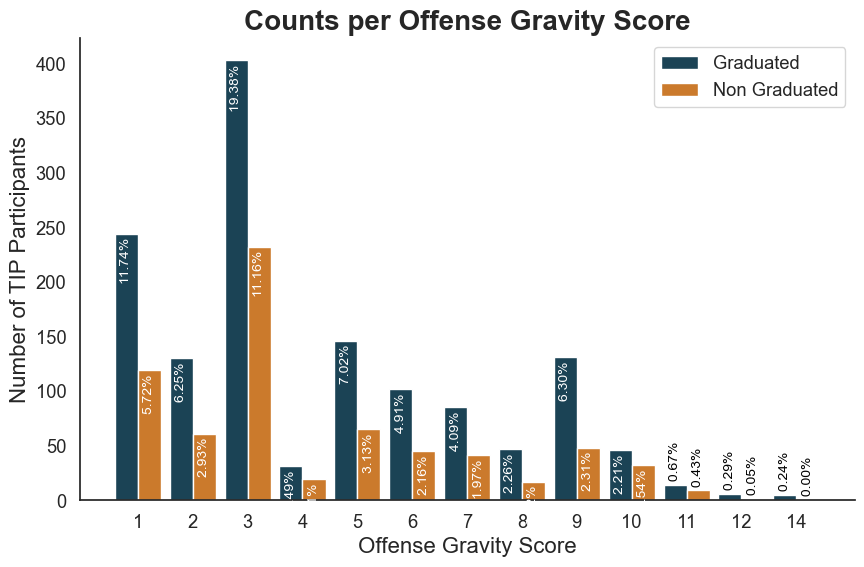

In [300]:
#Look at counts per OGS

fig, ax = plt.subplots(figsize=(10, 6))

x_indexes = np.arange(len(ogs_df))

bar_width = 0.42

plt.bar(
    x_indexes - bar_width / 2,
    ogs_df['Graduated_Count'],
    width=bar_width,
    label='Graduated',
    color=TIP_colors[0]
)

plt.bar(
    x_indexes + bar_width / 2,
    ogs_df['Non Graduated_Count'],
    width=bar_width,
    label='Non Graduated',
    color=TIP_colors[1]
)

for i, (x, y, upper, y2, upper2) in enumerate(zip(x_indexes, ogs_df['Graduated_Percentage'], ogs_df['Graduated_Count'], ogs_df['Non Graduated_Percentage'], ogs_df['Non Graduated_Count'])):
    if i >= 10:
        continue
    plt.text(x - bar_width / 2, upper + 0.01, f'{y:.2%} ', ha='center', va='top', fontsize=10, rotation=90, color='white')
    plt.text(x + bar_width / 2, upper2 + 0.01, f'{y2:.2%} ', ha='center', va='top', fontsize=10, rotation=90, color='white')

for i, (x, y, upper, y2, upper2) in enumerate(zip(x_indexes, ogs_df['Graduated_Percentage'], ogs_df['Graduated_Count'], ogs_df['Non Graduated_Percentage'], ogs_df['Non Graduated_Count'])):
    if i < 10:
        continue
    plt.text(x - bar_width / 2, upper + 0.01, f' {y:.2%}', ha='center', va='bottom', fontsize=10, rotation=90, color='black')
    plt.text(x + bar_width / 2, upper2 + 0.01, f' {y2:.2%}', ha='center', va='bottom', fontsize=10, rotation=90, color='black')

sns.despine()

plt.xticks(ticks=x_indexes, labels=ogs_df['OGS'], rotation=0)
plt.legend()
plt.title('Counts per Offense Gravity Score', fontdict={'fontsize': 20, 'fontweight': 'semibold'})
plt.xlabel('Offense Gravity Score', fontdict={'fontsize': 16})
plt.ylabel('Number of TIP Participants', fontdict={'fontsize': 16})
plt.show()

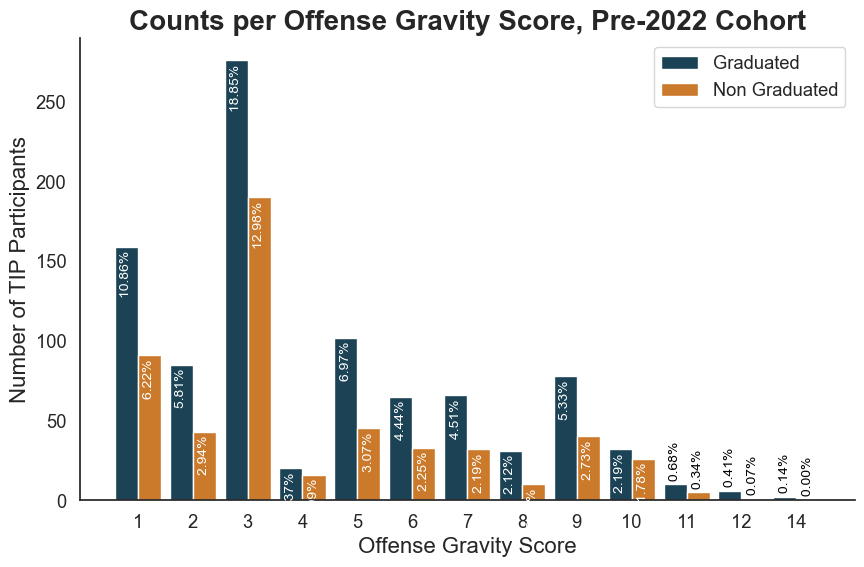

In [301]:
#Repeat for pre-2022 cohort
fig, ax = plt.subplots(figsize=(10, 6))

x_indexes = np.arange(len(ogs_pre22_df))

bar_width = 0.42

plt.bar(
    x_indexes - bar_width / 2,
    ogs_pre22_df['Graduated_Count'],
    width=bar_width,
    label='Graduated',
    color=TIP_colors[0]
)

plt.bar(
    x_indexes + bar_width / 2,
    ogs_pre22_df['Non Graduated_Count'],
    width=bar_width,
    label='Non Graduated',
    color=TIP_colors[1]
)

for i, (x, y, upper, y2, upper2) in enumerate(zip(x_indexes, ogs_pre22_df['Graduated_Percentage'], ogs_pre22_df['Graduated_Count'], ogs_pre22_df['Non Graduated_Percentage'], ogs_pre22_df['Non Graduated_Count'])):
    if i >= 10:
        continue
    plt.text(x - bar_width / 2, upper + 0.01, f'{y:.2%} ', ha='center', va='top', fontsize=10, rotation=90, color='white')
    plt.text(x + bar_width / 2, upper2 + 0.01, f'{y2:.2%} ', ha='center', va='top', fontsize=10, rotation=90, color='white')

for i, (x, y, upper, y2, upper2) in enumerate(zip(x_indexes, ogs_pre22_df['Graduated_Percentage'], ogs_pre22_df['Graduated_Count'], ogs_pre22_df['Non Graduated_Percentage'], ogs_pre22_df['Non Graduated_Count'])):
    if i < 10:
        continue
    plt.text(x - bar_width / 2, upper + 0.01, f' {y:.2%}', ha='center', va='bottom', fontsize=10, rotation=90, color='black')
    plt.text(x + bar_width / 2, upper2 + 0.01, f' {y2:.2%}', ha='center', va='bottom', fontsize=10, rotation=90, color='black')

sns.despine()

plt.xticks(ticks=x_indexes, labels=ogs_pre22_df['OGS'], rotation=0)
plt.legend()
plt.title('Counts per Offense Gravity Score, Pre-2022 Cohort', fontdict={'fontsize': 20, 'fontweight': 'semibold'})
plt.xlabel('Offense Gravity Score', fontdict={'fontsize': 16})
plt.ylabel('Number of TIP Participants', fontdict={'fontsize': 16})
plt.show()

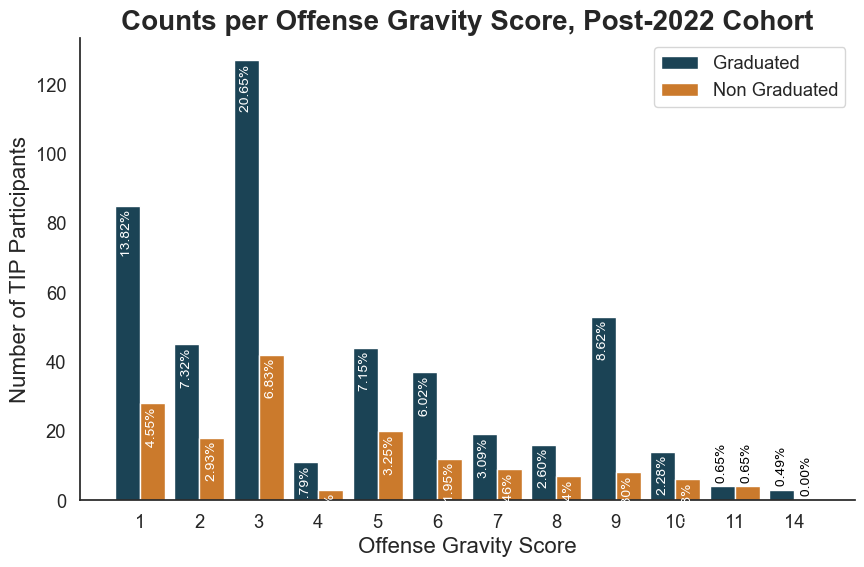

In [302]:
#Repeat for post-2022 cohort
fig, ax = plt.subplots(figsize=(10, 6))

x_indexes = np.arange(len(ogs_post22_df))

bar_width = 0.42

plt.bar(
    x_indexes - bar_width / 2,
    ogs_post22_df['Graduated_Count'],
    width=bar_width,
    label='Graduated',
    color=TIP_colors[0]
)

plt.bar(
    x_indexes + bar_width / 2,
    ogs_post22_df['Non Graduated_Count'],
    width=bar_width,
    label='Non Graduated',
    color=TIP_colors[1]
)

for i, (x, y, upper, y2, upper2) in enumerate(zip(x_indexes, ogs_post22_df['Graduated_Percentage'], ogs_post22_df['Graduated_Count'], ogs_post22_df['Non Graduated_Percentage'], ogs_post22_df['Non Graduated_Count'])):
    if i >= 10:
        continue
    plt.text(x - bar_width / 2, upper + 0.01, f'{y:.2%} ', ha='center', va='top', fontsize=10, rotation=90, color='white')
    plt.text(x + bar_width / 2, upper2 + 0.01, f'{y2:.2%} ', ha='center', va='top', fontsize=10, rotation=90, color='white')

for i, (x, y, upper, y2, upper2) in enumerate(zip(x_indexes, ogs_post22_df['Graduated_Percentage'], ogs_post22_df['Graduated_Count'], ogs_post22_df['Non Graduated_Percentage'], ogs_post22_df['Non Graduated_Count'])):
    if i < 10:
        continue
    plt.text(x - bar_width / 2, upper + 0.01, f' {y:.2%}', ha='center', va='bottom', fontsize=10, rotation=90, color='black')
    plt.text(x + bar_width / 2, upper2 + 0.01, f' {y2:.2%}', ha='center', va='bottom', fontsize=10, rotation=90, color='black')

sns.despine()

plt.xticks(ticks=x_indexes, labels=ogs_post22_df['OGS'], rotation=0)
plt.legend()
plt.title('Counts per Offense Gravity Score, Post-2022 Cohort', fontdict={'fontsize': 20, 'fontweight': 'semibold'})
plt.xlabel('Offense Gravity Score', fontdict={'fontsize': 16})
plt.ylabel('Number of TIP Participants', fontdict={'fontsize': 16})
plt.show()

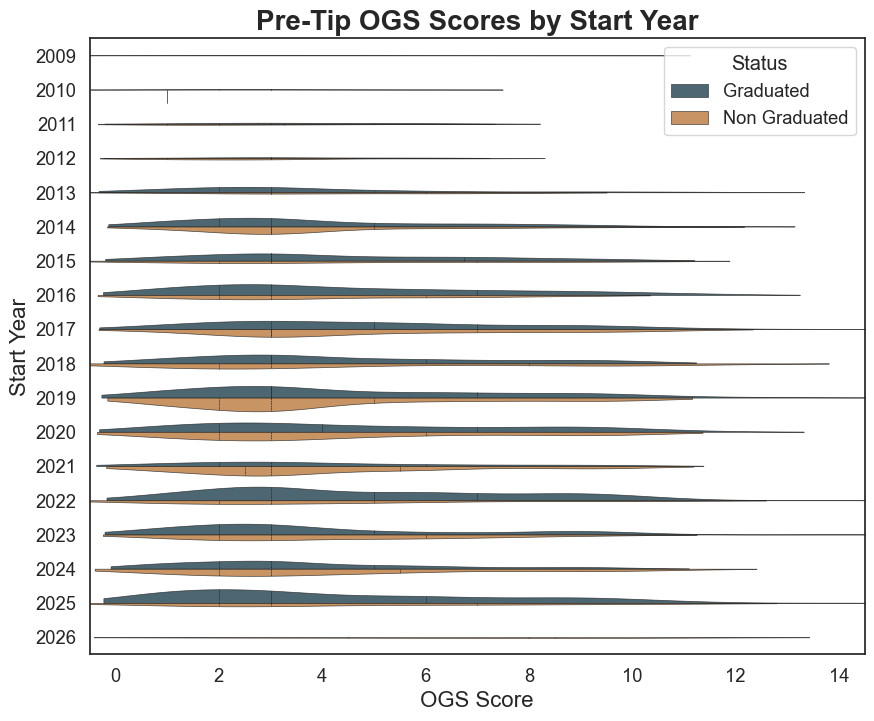

In [303]:
plt.figure(figsize=(10, 8))

sns.violinplot(
    data = df_convictions_ogs,
    y='StartYear',
    x='OGS',
    hue='Status',
    split=True,
    inner='quart',
    orient='h',
    saturation=0.8,
    dodge=True,
    cut=1.1,
    density_norm='count',
    linewidth=0.5,
    alpha=0.8
)

plt.title('Pre-Tip OGS Scores by Start Year', fontdict={'fontsize': 20, 'fontweight': 'semibold'})
plt.ylabel('Start Year', fontdict={'fontsize': 16})
plt.xlabel('OGS Score', fontdict={'fontsize': 16})
plt.xlim(-0.5, 14.5)
plt.show()

## Criminal Justice Interactions

In [304]:
#Define a function to calculate YearsSinceTIP
#Our convictions dataset already has this field, but we will need to apply it to the arrests dataframe as well

def years_since_TIP(row, event_col):
    event_date = row[event_col]

    start = row['StartDate'] if pd.notnull(row['StartDate']) else row['InterviewedDate']
    end = row['EndDate'] if pd.notnull(row['EndDate']) else row['StartDate']

    # If missing key dates, return None
    if pd.isnull(event_date) or (pd.isnull(start) and pd.isnull(end)):
        return None

    # If event is after TIP start → measure from end
    if pd.notnull(start) and event_date > start:
        if pd.isnull(end):
            return None
        return (event_date - end).days / 365.2425

    # If event is before TIP start → measure from start
    elif pd.notnull(start):
        return -(start - event_date).days / 365.2425

    return None

In [305]:
df_arrests = pd.merge(
    df_arrests,
    df_student[['tip_id', 'Status', 'ValidYears', 'ValidYearsPre_Arrests', 'cohort_2022']],
    on='tip_id',
    how='left'
)

In [306]:
df_arrests['DOF'] = df_arrests['ArrestDate']
df_arrests['YearsSinceTIP'] = df_arrests.apply(lambda row: years_since_TIP(row, 'DOF'), axis=1)

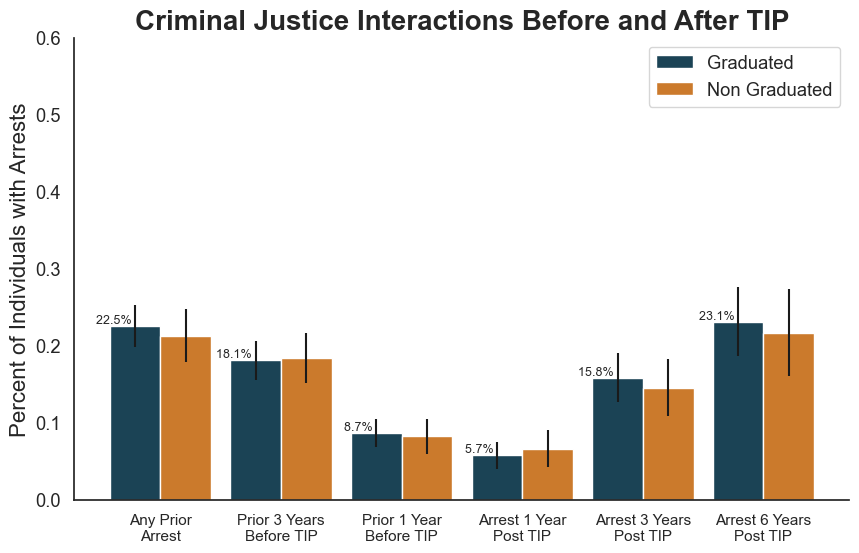

In [307]:
#Examine arrests pre and post tip

#pre
data_before = []

pre_bins = {
    -30: ("Any Prior Arrest", None),
    -3: ("Prior 3 Years Before TIP", -3),
    -1: ("Prior 1 Year Before TIP", -1)
}

#unlike convictions data, our arrest data only goes back until 2014
#so we are applying "ValidYearsPre_Arrests" to check whether we would expect to see the participants pre periods in these data
for bin_edge, (label, min_valid_year) in pre_bins.items():
    if bin_edge == -30:
        # Any prior arrest: include tip_ids with any valid pre-TIP data
        curr_grads = df_arrests[
            (df_arrests['YearsSinceTIP'] < 0) &
            (df_arrests['Status'] == 'Graduated')
        ]['tip_id'].unique()
        
        curr_non_grads = df_arrests[
            (df_arrests['YearsSinceTIP'] < 0) &
            (df_arrests['Status'] == 'Non Graduated')
        ]['tip_id'].unique()
        
    else:
        # Define the window: cumulative
        start = bin_edge  # e.g., -3 or -1
        end = 0
        
        # Only include tip_ids with enough valid pre-TIP years
        curr_grads = df_arrests[
            (df_arrests['YearsSinceTIP'] >= start) &
            (df_arrests['YearsSinceTIP'] < end) &
            (df_arrests['Status'] == 'Graduated') &
            (df_arrests['tip_id'].isin(df_student[df_student['ValidYearsPre_Arrests'] <= min_valid_year]['tip_id']))
        ]['tip_id'].unique()
        
        curr_non_grads = df_arrests[
            (df_arrests['YearsSinceTIP'] >= start) &
            (df_arrests['YearsSinceTIP'] < end) &
            (df_arrests['Status'] == 'Non Graduated') &
            (df_arrests['tip_id'].isin(df_student[df_student['ValidYearsPre_Arrests'] <= min_valid_year]['tip_id']))
        ]['tip_id'].unique()
        
    
    # Denominator = number of tip_ids that could appear in this window
    denom_grads = len(df_student[(df_student['Status'] == 'Graduated') & (df_student['ValidYearsPre_Arrests'] <= min_valid_year if min_valid_year is not None else True)])
    denom_non_grads = len(df_student[(df_student['Status'] == 'Non Graduated') & (df_student['ValidYearsPre_Arrests'] <= min_valid_year if min_valid_year is not None else True)])
    
    data_before.append({
        'YearsSinceTIP': bin_edge,
        'Graduated': len(curr_grads),
        'Graduated Percent': len(curr_grads)/denom_grads if denom_grads>0 else 0,
        'Non Graduated': len(curr_non_grads),
        'Non Graduated Percent': len(curr_non_grads)/denom_non_grads if denom_non_grads>0 else 0,
    })

data_before = pd.DataFrame(data_before)


data_after = []
for i in np.arange(0, 30.2, 0.2):
    curr_grads = df_arrests[(df_arrests['YearsSinceTIP'] >= 0) & (df_arrests['YearsSinceTIP'] < i) & (df_arrests['Status'] == 'Graduated') & (df_arrests['ValidYears'] > i)].copy()
    curr_non_grads = df_arrests[(df_arrests['YearsSinceTIP'] >= 0) & (df_arrests['YearsSinceTIP'] < i) & (df_arrests['Status'] == 'Non Graduated') & (df_arrests['ValidYears'] > i)].copy()

    graduate_pop_size = df_student[(df_student['Status'] == 'Graduated') & (df_student['ValidYears'] > i)].tip_id.nunique()
    non_graduate_pop_size = df_student[(df_student['Status'] == 'Non Graduated') & (df_student['ValidYears'] > i)].tip_id.nunique()

    data_after.append({
        'YearsSinceTIP': i,
        'Graduated': curr_grads['tip_id'].nunique(),
        'Graduated Percent' : (curr_grads['tip_id'].nunique() / graduate_pop_size) if graduate_pop_size > 0 else 0,
        'Non Graduated': curr_non_grads['tip_id'].nunique(),
        'Non Graduated Percent' : (curr_non_grads['tip_id'].nunique() / non_graduate_pop_size) if non_graduate_pop_size > 0 else 0,
    })

data_after = pd.DataFrame(data_after)

data_before['Graduated_Upper_CI'] = data_before['Graduated Percent'] + 1.96 * np.sqrt(data_before['Graduated Percent'] * (1 - data_before['Graduated Percent']) / df_student[df_student['Status'] == 'Graduated'].tip_id.nunique())
data_before['Graduated_Lower_CI'] = data_before['Graduated Percent'] - 1.96 * np.sqrt(data_before['Graduated Percent'] * (1 - data_before['Graduated Percent']) / df_student[df_student['Status'] == 'Graduated'].tip_id.nunique())
data_before['Non Graduated_Upper_CI'] = data_before['Non Graduated Percent'] + 1.96 * np.sqrt(data_before['Non Graduated Percent'] * (1 - data_before['Non Graduated Percent']) / df_student[df_student['Status'] == 'Non Graduated'].tip_id.nunique())
data_before['Non Graduated_Lower_CI'] = data_before['Non Graduated Percent'] - 1.96 * np.sqrt(data_before['Non Graduated Percent'] * (1 - data_before['Non Graduated Percent']) / df_student[df_student['Status'] == 'Non Graduated'].tip_id.nunique())

data_after['Graduated_Upper_CI'] = data_after['Graduated Percent'] + 1.96 * np.sqrt(data_after['Graduated Percent'] * (1 - data_after['Graduated Percent']) / data_after['YearsSinceTIP'].apply(lambda x: df_student[(df_student['Status'] == 'Graduated') & (df_student['ValidYears'] > x)].tip_id.nunique() if x > 0 else df_student[(df_student['Status'] == 'Graduated')].tip_id.nunique()))
data_after['Graduated_Lower_CI'] = data_after['Graduated Percent'] - 1.96 * np.sqrt(data_after['Graduated Percent'] * (1 - data_after['Graduated Percent']) / data_after['YearsSinceTIP'].apply(lambda x: df_student[(df_student['Status'] == 'Graduated') & (df_student['ValidYears'] > x)].tip_id.nunique() if x > 0 else df_student[(df_student['Status'] == 'Graduated')].tip_id.nunique()))
data_after['Non Graduated_Upper_CI'] = data_after['Non Graduated Percent'] + 1.96 * np.sqrt(data_after['Non Graduated Percent'] * (1 - data_after['Non Graduated Percent']) / data_after['YearsSinceTIP'].apply(lambda x: df_student[(df_student['Status'] == 'Non Graduated') & (df_student['ValidYears'] > x)].tip_id.nunique() if x > 0 else df_student[(df_student['Status'] == 'Non Graduated')].tip_id.nunique()))
data_after['Non Graduated_Lower_CI'] = data_after['Non Graduated Percent'] - 1.96 * np.sqrt(data_after['Non Graduated Percent'] * (1 - data_after['Non Graduated Percent']) / data_after['YearsSinceTIP'].apply(lambda x: df_student[(df_student['Status'] == 'Non Graduated') & (df_student['ValidYears'] > x)].tip_id.nunique() if x > 0 else df_student[(df_student['Status'] == 'Non Graduated')].tip_id.nunique()))

data = pd.concat([
    data_before[(data_before['YearsSinceTIP'] == -1) | (data_before['YearsSinceTIP'] == -3) | (data_before['YearsSinceTIP'] == -30)],
    data_after[(data_after['YearsSinceTIP'] == 1) | (data_after['YearsSinceTIP'] == 3) | (data_after['YearsSinceTIP'] == 6)]
])

data['YearsSinceTIP'] = data['YearsSinceTIP'].astype(str)
data['YearsSinceTIP'] = [
    "Any Prior Arrest", 
    "Prior 3 Years Before TIP", 
    "Prior 1 Year Before TIP", 
    "Arrest 1 Year Post TIP", 
    "Arrest 3 Years Post TIP", 
    "Arrest 6 Years Post TIP"
]

grad_err = np.abs(data[["Graduated_Upper_CI", "Graduated_Lower_CI"]].T.values - data["Graduated Percent"].values)
non_grad_err = np.abs(data[["Non Graduated_Upper_CI", "Non Graduated_Lower_CI"]].T.values - data["Non Graduated Percent"].values)

fig, ax = plt.subplots(figsize=(10, 6))

x_indexes = np.arange(len(data))
width = 0.42

ax.bar(
    x_indexes - width/2,
    data['Graduated Percent'],
    width=width,
    label='Graduated',
    yerr=grad_err,
    capsize=0
)

ax.bar(
    x_indexes + width/2,
    data['Non Graduated Percent'],
    width=width,
    label='Non Graduated',
    yerr=non_grad_err,
    capsize=0,
)


ax.set_xticks(x_indexes)
ax.set_xticklabels([
    "Any Prior\nArrest", 
    "Prior 3 Years\nBefore TIP", 
    "Prior 1 Year\nBefore TIP", 
    "Arrest 1 Year\nPost TIP", 
    "Arrest 3 Years\nPost TIP", 
    "Arrest 6 Years\nPost TIP"
], rotation=0, ha='center', fontsize=11)

for i, (x, y, upper, lower) in enumerate(zip(x_indexes - width/2, data['Graduated Percent'], data['Graduated_Upper_CI'], data['Graduated_Lower_CI'])):
    ax.text(x, y, f"{y:.1%} ", ha='right', va='bottom', fontsize=9, fontdict={'fontweight': 'medium'})

# for i, (x, y, upper, lower) in enumerate(zip(x_indexes + width/2, data['Non Graduated Percent'], data['Non Graduated_Upper_CI'], data['Non Graduated_Lower_CI'])):
#     ax.text(x, y, f" {y:.1%}", ha='left', va='bottom', fontsize=9, fontdict={'fontweight': 'medium'})

sns.despine()

plt.title('Criminal Justice Interactions Before and After TIP', fontdict={'fontsize': 20, 'fontweight': 'semibold'})
plt.xlabel('', fontdict={'fontsize': 0})
plt.ylabel('Percent of Individuals with Arrests', fontdict={'fontsize': 16})
plt.ylim(0, 0.6)
plt.legend()
plt.show()


In [308]:
#Repeat for pre-2022 cohort
# -------------------------
df_arrests_c1 = df_arrests[df_arrests["cohort_2022"] == 1].copy()
df_c1 = df_student[df_student["cohort_2022"] == 1].copy()

# Helper to extract the first number from a string
def extract_number(s):
    m = re.search(r'\d+', s)
    return int(m.group()) if m else None

#pre-TIP calculations
data_before = []

pre_bins = {
    -30: ("Any Prior Arrest", None),  # all pre-TIP arrests
    -3: ("Prior 3 Years Before TIP", -3),
    -1: ("Prior 1 Year Before TIP", -1)
}

for bin_edge, (label, min_valid_year) in pre_bins.items():
    if bin_edge == -30:
        curr_grads = df_arrests_c1[(df_arrests_c1['YearsSinceTIP'] < 0) & (df_arrests_c1['Status'] == 'Graduated')]['tip_id'].unique()
        curr_non_grads = df_arrests_c1[(df_arrests_c1['YearsSinceTIP'] < 0) & (df_arrests_c1['Status'] == 'Non Graduated')]['tip_id'].unique()
    else:
        start = bin_edge
        end = 0
        curr_grads = df_arrests_c1[
            (df_arrests_c1['YearsSinceTIP'] >= start) &
            (df_arrests_c1['YearsSinceTIP'] < end) &
            (df_arrests_c1['Status'] == 'Graduated') &
            (df_arrests_c1['tip_id'].isin(df_c1[df_c1['ValidYearsPre_Arrests'] <= min_valid_year]['tip_id']))
        ]['tip_id'].unique()

        curr_non_grads = df_arrests_c1[
            (df_arrests_c1['YearsSinceTIP'] >= start) &
            (df_arrests_c1['YearsSinceTIP'] < end) &
            (df_arrests_c1['Status'] == 'Non Graduated') &
            (df_arrests_c1['tip_id'].isin(df_c1[df_c1['ValidYearsPre_Arrests'] <= min_valid_year]['tip_id']))
        ]['tip_id'].unique()

    denom_grads = len(df_c1[(df_c1['Status'] == 'Graduated') & (df_c1['ValidYearsPre_Arrests'] <= min_valid_year if min_valid_year is not None else True)])
    denom_non_grads = len(df_c1[(df_c1['Status'] == 'Non Graduated') & (df_c1['ValidYearsPre_Arrests'] <= min_valid_year if min_valid_year is not None else True)])
    denom_interviewed = len(df_c1[(df_c1['Status'] == 'Interviewed') & (df_c1['ValidYearsPre_Arrests'] <= min_valid_year if min_valid_year is not None else True)])

    data_before.append({
        'YearsSinceTIP': bin_edge,
        'Graduated': len(curr_grads),
        'Graduated Percent': len(curr_grads)/denom_grads if denom_grads>0 else 0,
        'Non Graduated': len(curr_non_grads),
        'Non Graduated Percent': len(curr_non_grads)/denom_non_grads if denom_non_grads>0 else 0,
    })

data_before = pd.DataFrame(data_before)

# -------------------------
#post calculations
data_after = []

for i in np.arange(0, 30.2, 0.2):

    curr_grads = df_arrests_c1[
        (df_arrests_c1['YearsSinceTIP'] >= 0) &
        (df_arrests_c1['YearsSinceTIP'] < i) &
        (df_arrests_c1['Status'] == 'Graduated') &
        (df_arrests_c1['ValidYears'] > i)
    ].copy()

    curr_non_grads = df_arrests_c1[
        (df_arrests_c1['YearsSinceTIP'] >= 0) &
        (df_arrests_c1['YearsSinceTIP'] < i) &
        (df_arrests_c1['Status'] == 'Non Graduated') &
        (df_arrests_c1['ValidYears'] > i)
    ].copy()

    curr_interviewed = df_arrests_c1[
        (df_arrests_c1['YearsSinceTIP'] >= 0) &
        (df_arrests_c1['YearsSinceTIP'] < i) &
        (df_arrests_c1['Status'] == 'Interviewed') &
        (df_arrests_c1['ValidYears'] > i)
    ].copy()

    graduate_pop_size = df_c1[(df_c1['Status'] == 'Graduated') & (df_c1['ValidYears'] > i)].tip_id.nunique()
    non_graduate_pop_size = df_c1[(df_c1['Status'] == 'Non Graduated') & (df_c1['ValidYears'] > i)].tip_id.nunique()
    interviewed_pop_size = df_c1[(df_c1['Status'] == 'Interviewed') & (df_c1['ValidYears'] > i)].tip_id.nunique()

    data_after.append({
        'YearsSinceTIP': i,
        'Graduated': curr_grads['tip_id'].nunique(),
        'Graduated Percent': (curr_grads['tip_id'].nunique() / graduate_pop_size) if graduate_pop_size > 0 else 0,
        'Non Graduated': curr_non_grads['tip_id'].nunique(),
        'Non Graduated Percent': (curr_non_grads['tip_id'].nunique() / non_graduate_pop_size) if non_graduate_pop_size > 0 else 0,
        'Interviewed': curr_interviewed['tip_id'].nunique(),
        'Interviewed Percent': (curr_interviewed['tip_id'].nunique() / interviewed_pop_size) if interviewed_pop_size > 0 else 0
    })

data_after = pd.DataFrame(data_after)


data_before['Graduated_Upper_CI'] = data_before['Graduated Percent'] + 1.96 * np.sqrt(data_before['Graduated Percent'] * (1 - data_before['Graduated Percent']) / df_student[df_student['Status'] == 'Graduated'].tip_id.nunique())
data_before['Graduated_Lower_CI'] = data_before['Graduated Percent'] - 1.96 * np.sqrt(data_before['Graduated Percent'] * (1 - data_before['Graduated Percent']) / df_student[df_student['Status'] == 'Graduated'].tip_id.nunique())

data_before['Non Graduated_Upper_CI'] = data_before['Non Graduated Percent'] + 1.96 * np.sqrt(data_before['Non Graduated Percent'] * (1 - data_before['Non Graduated Percent']) / df_student[df_student['Status'] == 'Non Graduated'].tip_id.nunique())
data_before['Non Graduated_Lower_CI'] = data_before['Non Graduated Percent'] - 1.96 * np.sqrt(data_before['Non Graduated Percent'] * (1 - data_before['Non Graduated Percent']) / df_student[df_student['Status'] == 'Non Graduated'].tip_id.nunique())

data_after['Graduated_Upper_CI'] = data_after['Graduated Percent'] + 1.96 * np.sqrt(
    data_after['Graduated Percent'] * (1 - data_after['Graduated Percent']) /
    data_after['YearsSinceTIP'].apply(lambda x: df_student[(df_student['Status'] == 'Graduated') & (df_student['ValidYears'] > x)].tip_id.nunique() if x > 0 else df_student[(df_student['Status'] == 'Graduated')].tip_id.nunique())
)

data_after['Graduated_Lower_CI'] = data_after['Graduated Percent'] - 1.96 * np.sqrt(
    data_after['Graduated Percent'] * (1 - data_after['Graduated Percent']) /
    data_after['YearsSinceTIP'].apply(lambda x: df_student[(df_student['Status'] == 'Graduated') & (df_student['ValidYears'] > x)].tip_id.nunique() if x > 0 else df_student[(df_student['Status'] == 'Graduated')].tip_id.nunique())
)

data_after['Non Graduated_Upper_CI'] = data_after['Non Graduated Percent'] + 1.96 * np.sqrt(
    data_after['Non Graduated Percent'] * (1 - data_after['Non Graduated Percent']) /
    data_after['YearsSinceTIP'].apply(lambda x: df_student[(df_student['Status'] == 'Non Graduated') & (df_student['ValidYears'] > x)].tip_id.nunique() if x > 0 else df_student[(df_student['Status'] == 'Non Graduated')].tip_id.nunique())
)

data_after['Non Graduated_Lower_CI'] = data_after['Non Graduated Percent'] - 1.96 * np.sqrt(
    data_after['Non Graduated Percent'] * (1 - data_after['Non Graduated Percent']) /
    data_after['YearsSinceTIP'].apply(lambda x: df_student[(df_student['Status'] == 'Non Graduated') & (df_student['ValidYears'] > x)].tip_id.nunique() if x > 0 else df_student[(df_student['Status'] == 'Non Graduated')].tip_id.nunique())
)


# -------------------------
#combine
data = pd.concat([
    data_before[data_before['YearsSinceTIP'].isin([-30, -3, -1])],
    data_after[data_after['YearsSinceTIP'].isin([1, 2])]
])


# Copy for plotting and significance testing
pre_2022_arrests_plot = data.copy()
pre2022_arrests = data.copy()

pre2022_arrests['Graduated_num'] = pre2022_arrests['Graduated']
pre2022_arrests['Non Graduated_num'] = pre2022_arrests['Non Graduated']

pre2022_arrests['Graduated_denom'] = [
    df_c1[df_c1['Status'] == 'Graduated'].tip_id.nunique() if year < 0
    else df_c1[(df_c1['Status'] == 'Graduated') & (df_c1['ValidYears'] > year)].tip_id.nunique()
    for year in pre2022_arrests['YearsSinceTIP']
]

pre2022_arrests['Non Graduated_denom'] = [
    df_c1[df_c1['Status'] == 'Non Graduated'].tip_id.nunique() if year < 0
    else df_c1[(df_c1['Status'] == 'Non Graduated') & (df_c1['ValidYears'] > year)].tip_id.nunique()
    for year in pre2022_arrests['YearsSinceTIP']
]

In [309]:
#repeat for post-2022 cohort

df_arrests_c1 = df_arrests[df_arrests["cohort_2022"] == 2].copy()
df_c1 = df_student[df_student["cohort_2022"] == 2].copy()

# Helper to extract the first number from a string
def extract_number(s):
    m = re.search(r'\d+', s)
    return int(m.group()) if m else None

# -------------------------
# Pre-TIP calculations
# -------------------------
data_before = []

pre_bins = {
    -30: ("Any Prior Arrest", None),
    -3: ("Prior 3 Years Before TIP", -3),
    -1: ("Prior 1 Year Before TIP", -1)
}

for bin_edge, (label, min_valid_year) in pre_bins.items():
    if bin_edge == -30:
        curr_grads = df_arrests_c1[(df_arrests_c1['YearsSinceTIP'] < 0) & (df_arrests_c1['Status'] == 'Graduated')]['tip_id'].unique()
        curr_non_grads = df_arrests_c1[(df_arrests_c1['YearsSinceTIP'] < 0) & (df_arrests_c1['Status'] == 'Non Graduated')]['tip_id'].unique()
    else:
        start = bin_edge
        end = 0
        curr_grads = df_arrests_c1[
            (df_arrests_c1['YearsSinceTIP'] >= start) &
            (df_arrests_c1['YearsSinceTIP'] < end) &
            (df_arrests_c1['Status'] == 'Graduated') &
            (df_arrests_c1['tip_id'].isin(df_c1[df_c1['ValidYearsPre_Arrests'] <= min_valid_year]['tip_id']))
        ]['tip_id'].unique()

        curr_non_grads = df_arrests_c1[
            (df_arrests_c1['YearsSinceTIP'] >= start) &
            (df_arrests_c1['YearsSinceTIP'] < end) &
            (df_arrests_c1['Status'] == 'Non Graduated') &
            (df_arrests_c1['tip_id'].isin(df_c1[df_c1['ValidYearsPre_Arrests'] <= min_valid_year]['tip_id']))
        ]['tip_id'].unique()

    denom_grads = len(df_c1[(df_c1['Status'] == 'Graduated') & (df_c1['ValidYearsPre_Arrests'] <= min_valid_year if min_valid_year is not None else True)])
    denom_non_grads = len(df_c1[(df_c1['Status'] == 'Non Graduated') & (df_c1['ValidYearsPre_Arrests'] <= min_valid_year if min_valid_year is not None else True)])
    denom_interviewed = len(df_c1[(df_c1['Status'] == 'Interviewed') & (df_c1['ValidYearsPre_Arrests'] <= min_valid_year if min_valid_year is not None else True)])

    data_before.append({
        'YearsSinceTIP': bin_edge,
        'Graduated': len(curr_grads),
        'Graduated Percent': len(curr_grads)/denom_grads if denom_grads>0 else 0,
        'Non Graduated': len(curr_non_grads),
        'Non Graduated Percent': len(curr_non_grads)/denom_non_grads if denom_non_grads>0 else 0,
    })

data_before = pd.DataFrame(data_before)

# -------------------------
#post-TIP

data_after = []

for i in np.arange(0, 30.2, 0.2):

    curr_grads = df_arrests_c1[
        (df_arrests_c1['YearsSinceTIP'] >= 0) &
        (df_arrests_c1['YearsSinceTIP'] < i) &
        (df_arrests_c1['Status'] == 'Graduated') &
        (df_arrests_c1['ValidYears'] > i)
    ]

    curr_non_grads = df_arrests_c1[
        (df_arrests_c1['YearsSinceTIP'] >= 0) &
        (df_arrests_c1['YearsSinceTIP'] < i) &
        (df_arrests_c1['Status'] == 'Non Graduated') &
        (df_arrests_c1['ValidYears'] > i)
    ]

    graduate_pop_size = df_c1[(df_c1['Status'] == 'Graduated') & (df_c1['ValidYears'] > i)].tip_id.nunique()
    non_graduate_pop_size = df_c1[(df_c1['Status'] == 'Non Graduated') & (df_c1['ValidYears'] > i)].tip_id.nunique()

    data_after.append({
        'YearsSinceTIP': i,
        'Graduated': curr_grads['tip_id'].nunique(),
        'Graduated Percent' : (curr_grads['tip_id'].nunique() / graduate_pop_size) if graduate_pop_size > 0 else 0,
        'Non Graduated': curr_non_grads['tip_id'].nunique(),
        'Non Graduated Percent' : (curr_non_grads['tip_id'].nunique() / non_graduate_pop_size) if non_graduate_pop_size > 0 else 0,
    })

data_after = pd.DataFrame(data_after)


data_before['Graduated_Upper_CI'] = data_before['Graduated Percent'] + 1.96 * np.sqrt(data_before['Graduated Percent'] * (1 - data_before['Graduated Percent']) / df_student[df_student['Status'] == 'Graduated'].tip_id.nunique())
data_before['Graduated_Lower_CI'] = data_before['Graduated Percent'] - 1.96 * np.sqrt(data_before['Graduated Percent'] * (1 - data_before['Graduated Percent']) / df_student[df_student['Status'] == 'Graduated'].tip_id.nunique())

data_before['Non Graduated_Upper_CI'] = data_before['Non Graduated Percent'] + 1.96 * np.sqrt(data_before['Non Graduated Percent'] * (1 - data_before['Non Graduated Percent']) / df_student[df_student['Status'] == 'Non Graduated'].tip_id.nunique())
data_before['Non Graduated_Lower_CI'] = data_before['Non Graduated Percent'] - 1.96 * np.sqrt(data_before['Non Graduated Percent'] * (1 - data_before['Non Graduated Percent']) / df_student[df_student['Status'] == 'Non Graduated'].tip_id.nunique())

data_after['Graduated_Upper_CI'] = data_after['Graduated Percent'] + 1.96 * np.sqrt(
    data_after['Graduated Percent'] * (1 - data_after['Graduated Percent']) /
    data_after['YearsSinceTIP'].apply(lambda x: df_student[(df_student['Status'] == 'Graduated') & (df_student['ValidYears'] > x)].tip_id.nunique() if x > 0 else df_student[(df_student['Status'] == 'Graduated')].tip_id.nunique())
)

data_after['Graduated_Lower_CI'] = data_after['Graduated Percent'] - 1.96 * np.sqrt(
    data_after['Graduated Percent'] * (1 - data_after['Graduated Percent']) /
    data_after['YearsSinceTIP'].apply(lambda x: df_student[(df_student['Status'] == 'Graduated') & (df_student['ValidYears'] > x)].tip_id.nunique() if x > 0 else df_student[(df_student['Status'] == 'Graduated')].tip_id.nunique())
)

data_after['Non Graduated_Upper_CI'] = data_after['Non Graduated Percent'] + 1.96 * np.sqrt(
    data_after['Non Graduated Percent'] * (1 - data_after['Non Graduated Percent']) /
    data_after['YearsSinceTIP'].apply(lambda x: df_student[(df_student['Status'] == 'Non Graduated') & (df_student['ValidYears'] > x)].tip_id.nunique() if x > 0 else df_student[(df_student['Status'] == 'Non Graduated')].tip_id.nunique())
)

data_after['Non Graduated_Lower_CI'] = data_after['Non Graduated Percent'] - 1.96 * np.sqrt(
    data_after['Non Graduated Percent'] * (1 - data_after['Non Graduated Percent']) /
    data_after['YearsSinceTIP'].apply(lambda x: df_student[(df_student['Status'] == 'Non Graduated') & (df_student['ValidYears'] > x)].tip_id.nunique() if x > 0 else df_student[(df_student['Status'] == 'Non Graduated')].tip_id.nunique())
)


# -------------------------
#combine

data = pd.concat([
    data_before[data_before['YearsSinceTIP'].isin([-30, -3, -1])],
    data_after[data_after['YearsSinceTIP'].isin([1, 2])]
])

# Copy for plotting and significance testing
post_2022_arrests_plot = data.copy()
post2022_arrests = data.copy()

post2022_arrests['Graduated_num'] = post2022_arrests['Graduated']
post2022_arrests['Non Graduated_num'] = post2022_arrests['Non Graduated']

post2022_arrests['Graduated_denom'] = [
    df_c1[df_c1['Status'] == 'Graduated'].tip_id.nunique() if year < 0
    else df_c1[(df_c1['Status'] == 'Graduated') & (df_c1['ValidYears'] > year)].tip_id.nunique()
    for year in post2022_arrests['YearsSinceTIP']
]

post2022_arrests['Non Graduated_denom'] = [
    df_c1[df_c1['Status'] == 'Non Graduated'].tip_id.nunique() if year < 0
    else df_c1[(df_c1['Status'] == 'Non Graduated') & (df_c1['ValidYears'] > year)].tip_id.nunique()
    for year in post2022_arrests['YearsSinceTIP']
]

In [310]:
#Significance testing for differences within the same bar across different cohorts
#E.G. - This will test whether graduated arrest proportion in YearsSinceTIP of -3 in the pre-2022 cohort is significantly different than
#the graduated arrest proportion in YearsSinceTIP of -3 in the post-2022 cohort

year_list = [-30,-3, -1, 1, 2]

sig_results_arrests = compute_significance(pre2022_arrests, post2022_arrests, year_list)

sig_results_arrests["star"] = sig_results_arrests["p_value"].apply(star)

print(sig_results_arrests)

   YearsSinceTIP         Status   p_value star
0            -30      Graduated  0.243193     
1            -30  Non Graduated  0.072582     
2             -3      Graduated  0.589657     
3             -3  Non Graduated  0.019437    *
4             -1      Graduated  0.995420     
5             -1  Non Graduated  0.078254     
6              1      Graduated  0.255922     
7              1  Non Graduated  0.155038     
8              2      Graduated  0.160311     
9              2  Non Graduated  0.706738     


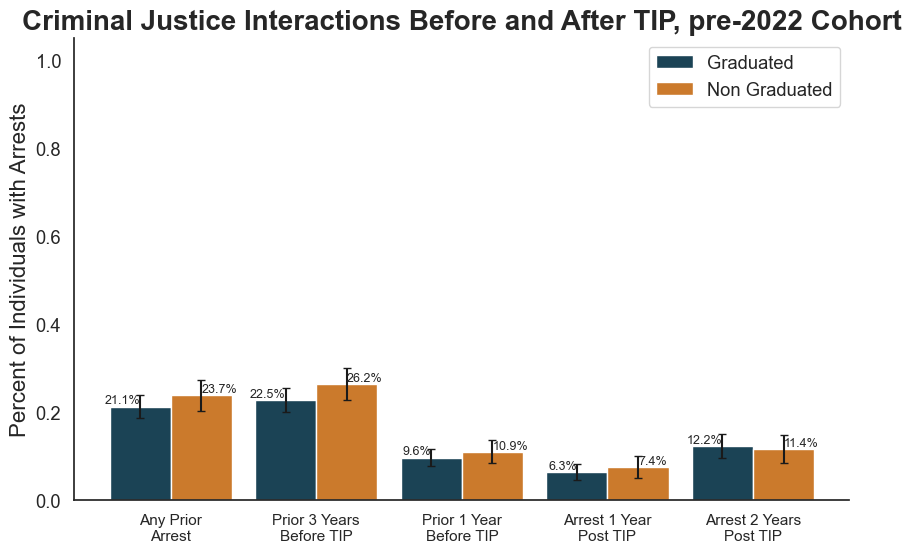

In [311]:
# Keep numeric YearsSinceTIP for significance
pre_2022_arrests_plot_numeric = pre_2022_arrests_plot.copy()
pre_2022_arrests_plot_numeric["YearsSinceTIP_numeric"] = pre_2022_arrests_plot_numeric["YearsSinceTIP"]  # preserve numeric for stars
sig_results_arrests["YearsSinceTIP"] = sig_results_arrests["YearsSinceTIP"].astype(int)

# Friendly labels for x-axis
x_labels = [
    "Any Prior\nArrest", 
    "Prior 3 Years\nBefore TIP", 
    "Prior 1 Year\nBefore TIP", 
    "Arrest 1 Year\nPost TIP", 
    "Arrest 2 Years\nPost TIP"
]

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
x_indexes = np.arange(len(pre_2022_arrests_plot_numeric))
width = 0.42

# Graduated bar
ax.bar(
    x_indexes - width/2,
    pre_2022_arrests_plot_numeric['Graduated Percent'],
    width=width,
    label='Graduated',
    yerr=np.abs(pre_2022_arrests_plot_numeric[["Graduated_Upper_CI","Graduated_Lower_CI"]].T.values - pre_2022_arrests_plot_numeric["Graduated Percent"].values),
    capsize=3
)

# Non Graduated bar
ax.bar(
    x_indexes + width/2,
    pre_2022_arrests_plot_numeric['Non Graduated Percent'],
    width=width,
    label='Non Graduated',
    yerr=np.abs(pre_2022_arrests_plot_numeric[["Non Graduated_Upper_CI","Non Graduated_Lower_CI"]].T.values - pre_2022_arrests_plot_numeric["Non Graduated Percent"].values),
    capsize=3
)

# Set x-axis labels
ax.set_xticks(x_indexes)
ax.set_xticklabels(x_labels, rotation=0, ha='center', fontsize=11)

# Add percent labels
for i, (x, y) in enumerate(zip(x_indexes - width/2, pre_2022_arrests_plot_numeric['Graduated Percent'])):
    ax.text(x, y, f"{y:.1%}", ha='right', va='bottom', fontsize=9, fontweight='medium')

for i, (x, y) in enumerate(zip(x_indexes + width/2, pre_2022_arrests_plot_numeric['Non Graduated Percent'])):
    ax.text(x, y, f"{y:.1%}", ha='left', va='bottom', fontsize=9, fontweight='medium')

sns.despine()
plt.title('Criminal Justice Interactions Before and After TIP, pre-2022 Cohort', fontsize=20, fontweight='semibold')
plt.ylabel('Percent of Individuals with Arrests', fontsize=16)

plt.ylim(0, 1.05)
plt.legend()
plt.show()

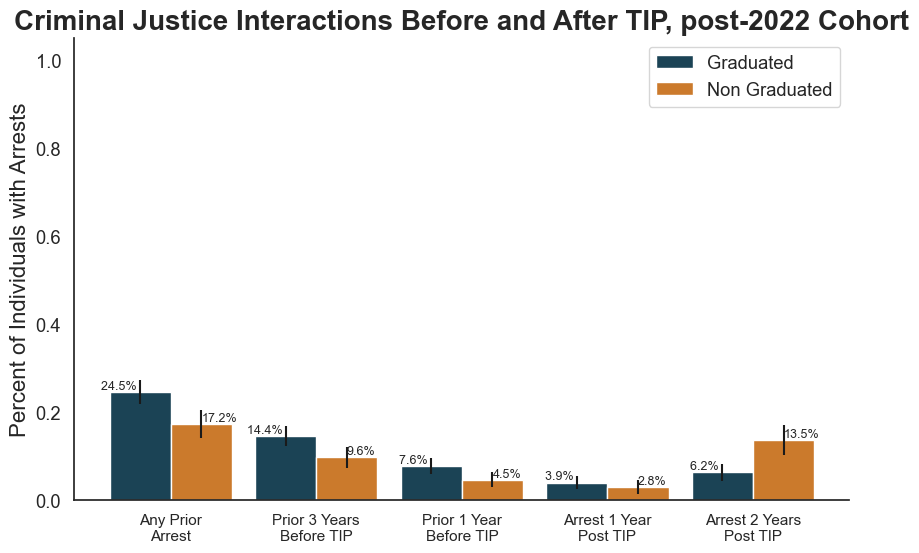

In [312]:
#plot post-2022 cohort

# Recalculate error bars
grad_err = np.abs(post_2022_arrests_plot[["Graduated_Upper_CI", "Graduated_Lower_CI"]].T.values - post_2022_arrests_plot["Graduated Percent"].values)
non_grad_err = np.abs(post_2022_arrests_plot[["Non Graduated_Upper_CI", "Non Graduated_Lower_CI"]].T.values - post_2022_arrests_plot["Non Graduated Percent"].values)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
x_indexes = np.arange(len(post_2022_arrests_plot))
width = 0.42

ax.bar(
    x_indexes - width/2,
    post_2022_arrests_plot['Graduated Percent'],
    width=width,
    label='Graduated',
    yerr=grad_err,
    capsize=0
)

ax.bar(
    x_indexes + width/2,
    post_2022_arrests_plot['Non Graduated Percent'],
    width=width,
    label='Non Graduated',
    yerr=non_grad_err,
    capsize=0,
)

ax.set_xticks(x_indexes)
ax.set_xticklabels([
    "Any Prior\nArrest", 
    "Prior 3 Years\nBefore TIP", 
    "Prior 1 Year\nBefore TIP", 
    "Arrest 1 Year\nPost TIP", 
    "Arrest 2 Years\nPost TIP"
], rotation=0, ha='center', fontsize=11)

for i, (x, y, upper, lower) in enumerate(zip(x_indexes - width/2, post_2022_arrests_plot['Graduated Percent'], post_2022_arrests_plot['Graduated_Upper_CI'], post_2022_arrests_plot['Graduated_Lower_CI'])):
    ax.text(x, y, f"{y:.1%} ", ha='right', va='bottom', fontsize=9, fontdict={'fontweight': 'medium'})

for i, (x, y, upper, lower) in enumerate(zip(x_indexes + width/2, post_2022_arrests_plot['Non Graduated Percent'], post_2022_arrests_plot['Non Graduated_Upper_CI'], post_2022_arrests_plot['Non Graduated_Lower_CI'])):
    ax.text(x, y, f"{y:.1%}", ha='left', va='bottom', fontsize=9, fontdict={'fontweight': 'medium'})

sns.despine()

plt.title('Criminal Justice Interactions Before and After TIP, post-2022 Cohort', fontdict={'fontsize': 20, 'fontweight': 'semibold'})
plt.xlabel('', fontdict={'fontsize': 0})
plt.ylabel('Percent of Individuals with Arrests', fontdict={'fontsize': 16})
plt.ylim(0, 1.05)
plt.legend()
plt.show()


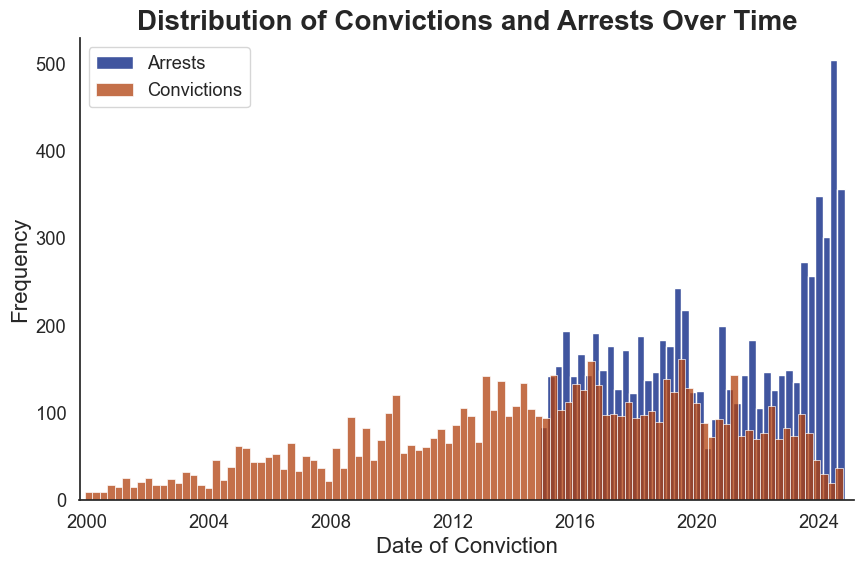

In [313]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(
    df_arrests['DOF'],
    binwidth=90,
    color=sns.color_palette('dark')[0]
)

sns.histplot(
    df_convictions['DOF'],
    binwidth=90,
    color=sns.color_palette('dark')[1]
)

sns.despine()

plt.title('Distribution of Convictions and Arrests Over Time', fontdict={'fontsize': 20, 'fontweight': 'semibold'})
plt.xlim(pd.Timestamp('1999-10-01'), pd.Timestamp('2025-02-28'))
plt.xlabel('Date of Conviction', fontdict={'fontsize': 16})
plt.ylabel('Frequency', fontdict={'fontsize': 16})
plt.legend(['Arrests', 'Convictions'])
plt.show()


## Data cleaning and exploration of social service usage and UI 

In [314]:
df_uibenefits = pd.read_csv(r'C:\Users\sarah\Documents\CMU\Spring 2026\Systems Synthesis\Data\Post-Cleaning\tip_ui.csv')

In [315]:
df_uibenefits.head()

,Unnamed: 0,TIP_ID,REQUEST_PERIOD,UC_BENEFIT
0,1,1189,20173,2496.0
1,2,297,20173,1648.0
2,3,663,20172,484.0
3,4,34,20172,1281.0
4,5,129,20172,2320.0


In [316]:
df_uibenefits = df_uibenefits.rename(columns={"TIP_ID": "tip_id"})

df_uibenefits["quarter"] = pd.to_numeric(df_uibenefits["REQUEST_PERIOD"], errors="coerce")

#Extract the quarter number from the five digit request date
df_uibenefits["q_num"] = (df_uibenefits["quarter"] % 10).astype("Int64")
#Extract the year from the five digit request date
df_uibenefits["year"] = (df_uibenefits["quarter"] // 10).astype("Int64")

#Add a dummy variable signifying whether they received benefits that period
df_uibenefits["ui_dummy"] = (~df_uibenefits["UC_BENEFIT"].isna()).astype(int)

#Annualize the data: if any quarter in that year has ui_dummy==1 -> received UI that year
df_ui_annual = (
    df_uibenefits.groupby(["tip_id", "year"], as_index=False)["ui_dummy"]
    .max()
)

df_uibenefits.head()

,Unnamed: 0,tip_id,REQUEST_PERIOD,UC_BENEFIT,quarter,q_num,year,ui_dummy
0,1,1189,20173,2496.0,20173,3,2017,1
1,2,297,20173,1648.0,20173,3,2017,1
2,3,663,20172,484.0,20172,2,2017,1
3,4,34,20172,1281.0,20172,2,2017,1
4,5,129,20172,2320.0,20172,2,2017,1


In [317]:
df_ui_annual.head()

,tip_id,year,ui_dummy
0,1,2017,0
1,1,2018,0
2,1,2019,0
3,1,2020,0
4,1,2021,0


In [318]:
#change quarter and year to date time

# map to calendar quarter end month/day
# Q1 -> 03/31
# Q2 -> 06/30
# Q3 -> 09/30
# Q4 -> 12/31 
month_map = {1: 3, 2: 6, 3: 9, 4: 12}
day_map   = {1: 31, 2: 30, 3: 30, 4: 31}

df_uibenefits["cal_end_year"] = df_uibenefits["year"]
df_uibenefits["cal_end_month"] = df_uibenefits["q_num"].map(month_map)
df_uibenefits["cal_end_day"] = df_uibenefits["q_num"].map(day_map)

df_uibenefits["year_quarter_dt"] = pd.to_datetime(
    dict(
        year=df_uibenefits["cal_end_year"],
        month=df_uibenefits["cal_end_month"],
        day=df_uibenefits["cal_end_day"],
    ),
    errors="coerce",
)

df_uibenefits["year_month"] = df_uibenefits["year_quarter_dt"].dt.to_period("M")
df_uibenefits.drop(columns=["Unnamed: 0", "qnum", "cal_end_year", "cal_end_month", "cal_end_day"], errors="ignore", inplace=True)
df_uibenefits.head()

,tip_id,REQUEST_PERIOD,UC_BENEFIT,quarter,q_num,year,ui_dummy,year_quarter_dt,year_month
0,1189,20173,2496.0,20173,3,2017,1,2017-09-30,2017-09
1,297,20173,1648.0,20173,3,2017,1,2017-09-30,2017-09
2,663,20172,484.0,20172,2,2017,1,2017-06-30,2017-06
3,34,20172,1281.0,20172,2,2017,1,2017-06-30,2017-06
4,129,20172,2320.0,20172,2,2017,1,2017-06-30,2017-06


In [319]:
#read in social service usage data and merge with variables from df_student
df_services = pd.read_csv(r'C:\Users\sarah\Documents\CMU\Spring 2026\Systems Synthesis\Data\Post-Cleaning\tip_ss.csv')
df_services = pd.merge(
    df_services,
    df_student[['tip_id', 'Status', 'StartDate', 'InterviewedDate', 'EndDate', 'ValidYears', 'ValidYearsPre_UI','cohort_2022','StartYear']],
    on='tip_id',
    how='left'
)

#clean and apply YearsSinceTIP to social service usage records
df_services['cohort_2022'] = pd.to_numeric(df_services['cohort_2022'], errors='coerce')
df_services['year_datetime'] = pd.to_datetime(df_services['year'], format='%Y')

df_services.head()

#apply YearsSinceTIP to records
df_services['YearsSinceTIP'] =df_services['YearsSinceTIP'] = df_services.apply(
    lambda row: years_since_TIP(row, 'year_datetime'), axis=1
)

df_services.head()

,Unnamed: 0,tip_id,year,aging,drug_alcohol,mental_health,cyf_child,cyf_parent,family_support_center,early_childhood,...,Status,StartDate,InterviewedDate,EndDate,ValidYears,ValidYearsPre_UI,cohort_2022,StartYear,year_datetime,YearsSinceTIP
0,1,632,2011,0,0,0,0,0,0,0,...,NaN,NaT,NaT,NaT,NaN,NaN,NaN,NaN,2011-01-01,NaN
1,2,632,2012,0,0,0,0,0,0,0,...,NaN,NaT,NaT,NaT,NaN,NaN,NaN,NaN,2012-01-01,NaN
2,3,632,2013,0,0,0,0,0,0,0,...,NaN,NaT,NaT,NaT,NaN,NaN,NaN,NaN,2013-01-01,NaN
3,4,632,2014,0,0,0,0,0,0,0,...,NaN,NaT,NaT,NaT,NaN,NaN,NaN,NaN,2014-01-01,NaN
4,5,632,2015,0,0,0,0,0,0,0,...,NaN,NaT,NaT,NaT,NaN,NaN,NaN,NaN,2015-01-01,NaN


In [321]:

df_services["year"] = pd.to_numeric(df_services["year"], errors="coerce")

#Create a combined indicator for SNAP & TANF based on whether the participant received either
df_services["SNAP_TANF"] = df_services["snap"].fillna(0) + df_services["tanf"].fillna(0)

df_services = df_services.merge(
    df_ui_annual,   
    on=["tip_id", "year"],
    how="outer"
)

df_services.columns = df_services.columns.str.strip()

#establish service columns - not all of the columns in the DHS database are social services
service_cols = [
    "aging",
    "drug_alcohol",
    "mental_health",
    "family_support_center",
    "early_childhood",
    "jail_collab",
    "matp",
    "home_visiting",
    "dhs_housing_supports",
    "indep_living",
    "intellectual_disab",
    "link_referral",
    "public_housing",
    "section8_housing",
    "medicaid",
    "snap",
    "tanf",
    "ssi",
    "ccdf",
]

#Establish two more dummy columns - one if the participant received any services in our service columns
#One if they received any of those or UI benefits
#Fill NAs with 0s
svc_mat = df_services[service_cols].apply(pd.to_numeric, errors="coerce").fillna(0)

df_services["any_one"] = (svc_mat.eq(1).any(axis=1)).astype(int)
ui_col = "ui_dummy" 
df_services[ui_col] = pd.to_numeric(df_services[ui_col], errors="coerce").fillna(0)
df_services["any_one_plus_ui"] = ((df_services["any_one"] == 1) | (df_services[ui_col] == 1)).astype(int)


In [322]:
df_services = df_services.drop(columns=["Unnamed: 0"], errors="ignore")
df_services.head()

,tip_id,year,aging,drug_alcohol,mental_health,cyf_child,cyf_parent,family_support_center,early_childhood,jail_collab,...,ValidYears,ValidYearsPre_UI,cohort_2022,StartYear,year_datetime,YearsSinceTIP,SNAP_TANF,ui_dummy,any_one,any_one_plus_ui
0,1,2010,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,6.417522,-1.524983,1.0,2018.0,2010-01-01,-8.525842,0.0,0.0,1,1
1,1,2011,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,6.417522,-1.524983,1.0,2018.0,2011-01-01,-7.526506,0.0,0.0,1,1
2,1,2012,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,6.417522,-1.524983,1.0,2018.0,2012-01-01,-6.527170,0.0,0.0,1,1
3,1,2013,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,6.417522,-1.524983,1.0,2018.0,2013-01-01,-5.525096,0.0,0.0,1,1
4,1,2014,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,6.417522,-1.524983,1.0,2018.0,2014-01-01,-4.525760,0.0,0.0,1,1


C:\Users\sarah\AppData\Local\Temp\ipykernel_10680\2466816734.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Status")["tip_id"]


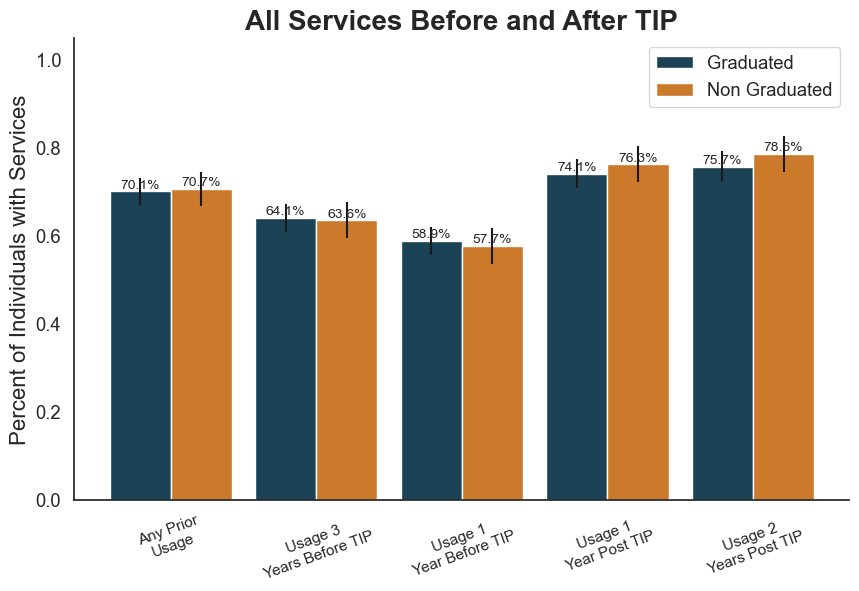

In [326]:
#examine service use (combined both cohorts)

#keep only Graduated / Non Graduated and those who used at least one service
svc = df_services.copy()
svc = svc[
    (svc["any_one"] == 1) &
    (svc["Status"].isin(["Graduated","Non Graduated"]))
].copy()
# -----------------------------
#pre-bins - we're not checking ValidYearsPre here since our service data goes back until 2010

pre_bins = {
    -1: [-1],             # 1 year pre
    -3: [-3, -2, -1],     # 1-3 years pre
    -30: list(range(-30, 0))  # any prior usage
}

svc["YearsSinceTIP"] = pd.to_numeric(svc["YearsSinceTIP"], errors="coerce")
svc["YearsSinceTIP_int"] = svc["YearsSinceTIP"].round().astype("Int64")

rows = []
for bin_edge, years in pre_bins.items():
    cur = svc[svc["YearsSinceTIP_int"].isin(years)]
    
    row = {"YearsSinceTIP": bin_edge}
    for status in ["Graduated", "Non Graduated"]:
        num = cur.loc[cur["Status"] == status, "tip_id"].nunique()
        row[status] = num
        
    rows.append(row)

pre_count = pd.DataFrame(rows)

# denominators for pre: total people per status

denom_pre = (
    df_student[(df_student["Status"].isin(["Graduated", "Non Graduated"]))]
    .groupby("Status")["tip_id"]
    .nunique()
    .to_dict()
)

z = 1.96
for status in ["Graduated", "Non Graduated"]:
    pre_count[f"{status} Percent"] = pre_count[status] / denom_pre.get(status, np.nan)
    p = pre_count[f"{status} Percent"]
    n = denom_pre.get(status, np.nan)
    se = np.sqrt(p * (1 - p) / n)
    pre_count[f"{status}_Upper_CI"] = (p + z * se).clip(0, 1)
    pre_count[f"{status}_Lower_CI"] = (p - z * se).clip(0, 1)

# -----------------------------
#post-TIP (cumulative windows)

post_points = [1, 2]
rows = []

for i in post_points:
    cur = svc[(svc["YearsSinceTIP"] >= 0) & (svc["YearsSinceTIP"] < i+1) & (svc["ValidYears"] >= i)]

    row = {"YearsSinceTIP": i}
    for status in ["Graduated", "Non Graduated"]:
        num = cur.loc[cur["Status"] == status, "tip_id"].nunique()
        denom = df_student.loc[(df_student["Status"] == status) & (df_student["ValidYears"] >= i), "tip_id"].nunique()

        p = (num / denom) if denom > 0 else 0
        se = np.sqrt(p * (1 - p) / denom) if denom > 0 else np.nan

        row[f"{status}"] = num
        row[f"{status} Percent"] = p
        row[f"{status}_Upper_CI"] = min(1, p + z * se) if denom > 0 else np.nan
        row[f"{status}_Lower_CI"] = max(0, p - z * se) if denom > 0 else np.nan

    rows.append(row)

post_df = pd.DataFrame(rows)

# -----------------------------
#combine and plot
label_map = {
    -30: "Any Prior\nUsage",
    -3:  "Usage 3\nYears Before TIP",
    -1:  "Usage 1\nYear Before TIP",
     1:  "Usage 1\nYear Post TIP",
     2:  "Usage 2\nYears Post TIP"
}
order = [-30, -3, -1, 1, 2]

pre_keep = pre_count[pre_count["YearsSinceTIP"].isin([-30, -3, -1])].copy()
data = pd.concat([pre_keep, post_df], ignore_index=True)

data["YearsSinceTIP"] = data["YearsSinceTIP"].astype(int)
data["YearsSinceTIP"] = pd.Categorical(data["YearsSinceTIP"], categories=order, ordered=True)
data = data.sort_values("YearsSinceTIP").reset_index(drop=True)
data["label"] = data["YearsSinceTIP"].astype(int).map(label_map)

grad_err = np.abs(
    data[["Graduated_Upper_CI", "Graduated_Lower_CI"]].T.values - data["Graduated Percent"].values
)
non_grad_err = np.abs(
    data[["Non Graduated_Upper_CI", "Non Graduated_Lower_CI"]].T.values - data["Non Graduated Percent"].values
)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(data))
width = 0.42

ax.bar(x - width/2, data["Graduated Percent"], width=width, label="Graduated", yerr=grad_err, capsize=0)
ax.bar(x + width/2, data["Non Graduated Percent"], width=width, label="Non Graduated", yerr=non_grad_err, capsize=0)

ax.set_xticks(x)
ax.set_xticklabels(data["label"], rotation=20, ha="center", fontsize=11)

for xi, yi in zip(x - width/2, data["Graduated Percent"]):
    ax.text(xi, yi, f"{yi:.1%}", ha="center", va="bottom", fontsize=10)
for xi, yi in zip(x + width/2, data["Non Graduated Percent"]):
    ax.text(xi, yi, f"{yi:.1%}", ha="center", va="bottom", fontsize=10)

sns.despine()
plt.title("All Services Before and After TIP", fontdict={"fontsize": 20, "fontweight": "semibold"})
plt.ylabel("Percent of Individuals with Services", fontdict={"fontsize": 16})
plt.ylim(0, 1.05)
plt.legend(loc="upper right")
plt.show()


C:\Users\sarah\AppData\Local\Temp\ipykernel_10680\787226485.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Status")["tip_id"]


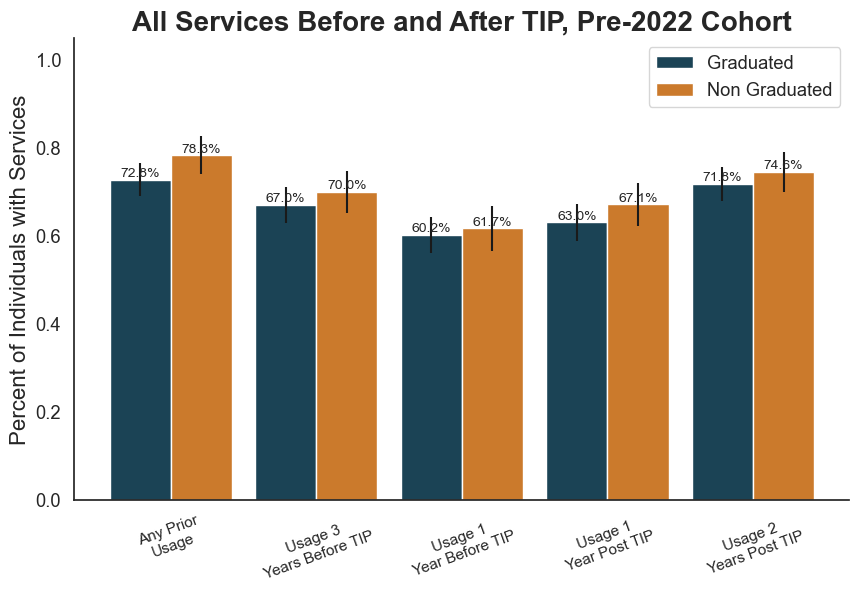

In [327]:
#repeat for cohort 1

# keep only Graduated / Non Graduated
svc_c1 = df_services.copy()
svc_c1 = svc_c1[
    (svc_c1["cohort_2022"] == 1) &
    (svc_c1["any_one"] == 1) &
    (svc_c1["Status"].isin(["Graduated","Non Graduated"]))
].copy()

# -----------------------------
#pre-TIP

pre_bins = {
    -1: [-1],             # 1 year pre
    -3: [-3, -2, -1],     # 1-3 years pre
    -30: list(range(-30, 0))  # any prior usage
}

svc_c1["YearsSinceTIP_int"] = svc_c1["YearsSinceTIP"].round().astype(int)

rows = []
for bin_edge, years in pre_bins.items():
    cur = svc_c1[svc_c1["YearsSinceTIP_int"].isin(years)]
    
    row = {"YearsSinceTIP": bin_edge}
    for status in ["Graduated", "Non Graduated"]:
        num = cur.loc[cur["Status"] == status, "tip_id"].nunique()
        row[status] = num
        
    rows.append(row)

pre_count = pd.DataFrame(rows)

# denominators for pre: total people per status

denom_pre = (
    df_student[(df_student["Status"].isin(["Graduated", "Non Graduated"])) & (df_student["cohort_2022"] == 1)]
    .groupby("Status")["tip_id"]
    .nunique()
    .to_dict()
)

z = 1.96
for status in ["Graduated", "Non Graduated"]:
    pre_count[f"{status} Percent"] = pre_count[status] / denom_pre.get(status, np.nan)
    p = pre_count[f"{status} Percent"]
    n = denom_pre.get(status, np.nan)
    se = np.sqrt(p * (1 - p) / n)
    pre_count[f"{status}_Upper_CI"] = (p + z * se).clip(0, 1)
    pre_count[f"{status}_Lower_CI"] = (p - z * se).clip(0, 1)

# -----------------------------
#post-TIP

post_points = [1, 2]
rows = []

for i in post_points:
    cur = svc_c1[(svc_c1["YearsSinceTIP"] >= 0) & (svc_c1["YearsSinceTIP"] < i) & (svc_c1["ValidYears"] > i)]

    row = {"YearsSinceTIP": i}
    for status in ["Graduated", "Non Graduated"]:
        num = cur.loc[cur["Status"] == status, "tip_id"].nunique()
        denom = df_student.loc[(df_student["Status"] == status) & (df_student["ValidYears"] > i) & (df_student["cohort_2022"] ==1), "tip_id"].nunique()

        p = (num / denom) if denom > 0 else 0
        se = np.sqrt(p * (1 - p) / denom) if denom > 0 else np.nan

        row[f"{status}"] = num
        row[f"{status} Percent"] = p
        row[f"{status}_Upper_CI"] = min(1, p + z * se) if denom > 0 else np.nan
        row[f"{status}_Lower_CI"] = max(0, p - z * se) if denom > 0 else np.nan

    rows.append(row)

post_df = pd.DataFrame(rows)

# -----------------------------
#combine and plot

label_map = {
    -30: "Any Prior\nUsage",
    -3:  "Usage 3\nYears Before TIP",
    -1:  "Usage 1\nYear Before TIP",
     1:  "Usage 1\nYear Post TIP",
     2:  "Usage 2\nYears Post TIP"
}
order = [-30, -3, -1, 1, 2]

pre_keep = pre_count[pre_count["YearsSinceTIP"].isin([-30, -3, -1])].copy()
data = pd.concat([pre_keep, post_df], ignore_index=True)

data["YearsSinceTIP"] = data["YearsSinceTIP"].astype(int)
data["YearsSinceTIP"] = pd.Categorical(data["YearsSinceTIP"], categories=order, ordered=True)
data = data.sort_values("YearsSinceTIP").reset_index(drop=True)
data["label"] = data["YearsSinceTIP"].astype(int).map(label_map)

grad_err = np.abs(
    data[["Graduated_Upper_CI", "Graduated_Lower_CI"]].T.values - data["Graduated Percent"].values
)
non_grad_err = np.abs(
    data[["Non Graduated_Upper_CI", "Non Graduated_Lower_CI"]].T.values - data["Non Graduated Percent"].values
)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(data))
width = 0.42

ax.bar(x - width/2, data["Graduated Percent"], width=width, label="Graduated", yerr=grad_err, capsize=0)
ax.bar(x + width/2, data["Non Graduated Percent"], width=width, label="Non Graduated", yerr=non_grad_err, capsize=0)

ax.set_xticks(x)
ax.set_xticklabels(data["label"], rotation=20, ha="center", fontsize=11)

for xi, yi in zip(x - width/2, data["Graduated Percent"]):
    ax.text(xi, yi, f"{yi:.1%}", ha="center", va="bottom", fontsize=10)
for xi, yi in zip(x + width/2, data["Non Graduated Percent"]):
    ax.text(xi, yi, f"{yi:.1%}", ha="center", va="bottom", fontsize=10)

sns.despine()
plt.title("All Services Before and After TIP, Pre-2022 Cohort", fontdict={"fontsize": 20, "fontweight": "semibold"})
plt.ylabel("Percent of Individuals with Services", fontdict={"fontsize": 16})
plt.ylim(0, 1.05)
plt.legend(loc="upper right")
plt.show()


C:\Users\sarah\AppData\Local\Temp\ipykernel_10680\1174808181.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Status")["tip_id"]


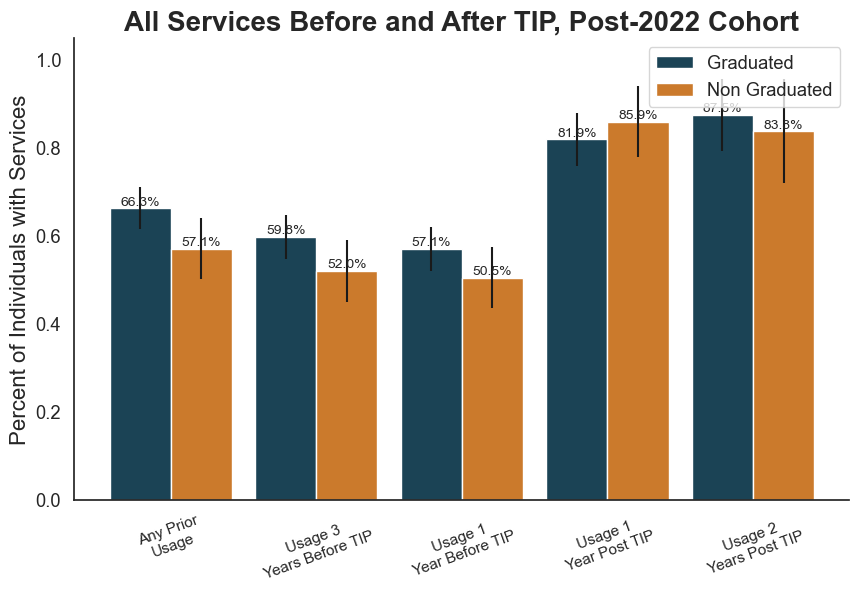

In [328]:
#repeat for cohort 2

# keep only Graduated / Non Graduated
svc_c1 = df_services.copy()
svc_c1 = svc_c1[
    (svc_c1["cohort_2022"] == 2) &
    (svc_c1["any_one"] == 1) &
    (svc_c1["Status"].isin(["Graduated","Non Graduated"]))
].copy()

# -----------------------------
#pre-TIP

pre_bins = {
    -1: [-1],             # 1 year pre
    -3: [-3, -2, -1],     # 1-3 years pre
    -30: list(range(-30, 0))  # any prior usage
}

svc_c1["YearsSinceTIP_int"] = svc_c1["YearsSinceTIP"].round().astype(int)

rows = []
for bin_edge, years in pre_bins.items():
    cur = svc_c1[svc_c1["YearsSinceTIP_int"].isin(years)]
    
    row = {"YearsSinceTIP": bin_edge}
    for status in ["Graduated", "Non Graduated"]:
        num = cur.loc[cur["Status"] == status, "tip_id"].nunique()
        row[status] = num
        
    rows.append(row)

pre_count = pd.DataFrame(rows)

# denominators for pre: total people per status

denom_pre = (
    df_student[(df_student["Status"].isin(["Graduated", "Non Graduated"])) & (df_student["cohort_2022"] == 2)]
    .groupby("Status")["tip_id"]
    .nunique()
    .to_dict()
)

z = 1.96
for status in ["Graduated", "Non Graduated"]:
    pre_count[f"{status} Percent"] = pre_count[status] / denom_pre.get(status, np.nan)
    p = pre_count[f"{status} Percent"]
    n = denom_pre.get(status, np.nan)
    se = np.sqrt(p * (1 - p) / n)
    pre_count[f"{status}_Upper_CI"] = (p + z * se).clip(0, 1)
    pre_count[f"{status}_Lower_CI"] = (p - z * se).clip(0, 1)

# -----------------------------
#post-TIP

post_points = [1, 2]
rows = []

for i in post_points:
    cur = svc_c1[(svc_c1["YearsSinceTIP"] >= 0) & (svc_c1["YearsSinceTIP"] < i+1) & (svc_c1["ValidYears"] >= i)]

    row = {"YearsSinceTIP": i}
    for status in ["Graduated", "Non Graduated"]:
        num = cur.loc[cur["Status"] == status, "tip_id"].nunique()
        denom = df_student.loc[(df_student["Status"] == status) & (df_student["ValidYears"] >= i) & (df_student["cohort_2022"] == 2), "tip_id"].nunique()

        p = (num / denom) if denom > 0 else 0
        se = np.sqrt(p * (1 - p) / denom) if denom > 0 else np.nan

        row[f"{status}"] = num
        row[f"{status} Percent"] = p
        row[f"{status}_Upper_CI"] = min(1, p + z * se) if denom > 0 else np.nan
        row[f"{status}_Lower_CI"] = max(0, p - z * se) if denom > 0 else np.nan

    rows.append(row)

post_df = pd.DataFrame(rows)

# -----------------------------
#combine and plot

label_map = {
    -30: "Any Prior\nUsage",
    -3:  "Usage 3\nYears Before TIP",
    -1:  "Usage 1\nYear Before TIP",
     1:  "Usage 1\nYear Post TIP",
     2:  "Usage 2\nYears Post TIP"
}
order = [-30, -3, -1, 1, 2]

pre_keep = pre_count[pre_count["YearsSinceTIP"].isin([-30, -3, -1])].copy()
data = pd.concat([pre_keep, post_df], ignore_index=True)

data["YearsSinceTIP"] = data["YearsSinceTIP"].astype(int)
data["YearsSinceTIP"] = pd.Categorical(data["YearsSinceTIP"], categories=order, ordered=True)
data = data.sort_values("YearsSinceTIP").reset_index(drop=True)
data["label"] = data["YearsSinceTIP"].astype(int).map(label_map)

grad_err = np.abs(
    data[["Graduated_Upper_CI", "Graduated_Lower_CI"]].T.values - data["Graduated Percent"].values
)
non_grad_err = np.abs(
    data[["Non Graduated_Upper_CI", "Non Graduated_Lower_CI"]].T.values - data["Non Graduated Percent"].values
)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(data))
width = 0.42

ax.bar(x - width/2, data["Graduated Percent"], width=width, label="Graduated", yerr=grad_err, capsize=0)
ax.bar(x + width/2, data["Non Graduated Percent"], width=width, label="Non Graduated", yerr=non_grad_err, capsize=0)

ax.set_xticks(x)
ax.set_xticklabels(data["label"], rotation=20, ha="center", fontsize=11)

for xi, yi in zip(x - width/2, data["Graduated Percent"]):
    ax.text(xi, yi, f"{yi:.1%}", ha="center", va="bottom", fontsize=10)
for xi, yi in zip(x + width/2, data["Non Graduated Percent"]):
    ax.text(xi, yi, f"{yi:.1%}", ha="center", va="bottom", fontsize=10)

sns.despine()
plt.title("All Services Before and After TIP, Post-2022 Cohort", fontdict={"fontsize": 20, "fontweight": "semibold"})
plt.ylabel("Percent of Individuals with Services", fontdict={"fontsize": 16})
plt.ylim(0, 1.05)
plt.legend(loc="upper right")
plt.show()


In [329]:
#Define function to cycle through multiple services and plot them each separately

def plot_service_usage(service_col, cohort, df_services, df):

    svc = df_services.copy()
    svc = svc[svc["Status"].isin(["Graduated", "Non Graduated"])]
    svc = svc[svc["cohort_2022"] == cohort]

    # keep only rows where service was used
    svc = svc[svc[service_col] == 1]

    svc["YearsSinceTIP_int"] = svc["YearsSinceTIP"].round().astype(int)

    pre_bins = {
        -1: [-1],
        -3: [-3, -2, -1],
        -30: list(range(-30, 0))
    }

    rows = []

    for bin_edge, years in pre_bins.items():

        cur = svc[svc["YearsSinceTIP_int"].isin(years)]

        row = {"YearsSinceTIP": bin_edge}

        for status in ["Graduated", "Non Graduated"]:
            num = cur.loc[cur["Status"] == status, "tip_id"].nunique()
            row[status] = num

        rows.append(row)

    pre_count = pd.DataFrame(rows)

    denom_pre = (
        df_student[(df_student["Status"].isin(["Graduated", "Non Graduated"])) &
           (df_student["cohort_2022"] == cohort)]
        .groupby("Status")["tip_id"]
        .nunique()
        .to_dict()
    )

    z = 1.96

    for status in ["Graduated", "Non Graduated"]:

        pre_count[f"{status} Percent"] = pre_count[status] / denom_pre.get(status, np.nan)

        p = pre_count[f"{status} Percent"]
        n = denom_pre.get(status, np.nan)

        se = np.sqrt(p * (1 - p) / n)

        pre_count[f"{status}_Upper_CI"] = (p + z * se).clip(0, 1)
        pre_count[f"{status}_Lower_CI"] = (p - z * se).clip(0, 1)


    post_points = [1, 2]
    rows = []

    for i in post_points:

        cur = svc[
            (svc["YearsSinceTIP"] >= 0) &
            (svc["YearsSinceTIP"] < i + 1) &
            (svc["ValidYears"] >= i)
        ]

        row = {"YearsSinceTIP": i}

        for status in ["Graduated", "Non Graduated"]:

            num = cur.loc[cur["Status"] == status, "tip_id"].nunique()

            denom = df.loc[
                (df_student["Status"] == status) &
                (df_student["ValidYears"] >= i) &
                (df_student["cohort_2022"] == cohort),
                "tip_id"
            ].nunique()

            p = (num / denom) if denom > 0 else 0
            se = np.sqrt(p * (1 - p) / denom) if denom > 0 else np.nan

            row[f"{status}"] = num
            row[f"{status} Percent"] = p
            row[f"{status}_Upper_CI"] = min(1, p + z * se) if denom > 0 else np.nan
            row[f"{status}_Lower_CI"] = max(0, p - z * se) if denom > 0 else np.nan

        rows.append(row)

    post_df = pd.DataFrame(rows)


    label_map = {
        -30: "Any Prior\nUsage",
        -3:  "Usage 3\nYears Before TIP",
        -1:  "Usage 1\nYear Before TIP",
         1:  "Usage 1\nYear Post TIP",
         2:  "Usage 2\nYears Post TIP"
    }

    order = [-30, -3, -1, 1, 2]

    pre_keep = pre_count[pre_count["YearsSinceTIP"].isin([-30, -3, -1])]
    data = pd.concat([pre_keep, post_df], ignore_index=True)

    data["YearsSinceTIP"] = pd.Categorical(
        data["YearsSinceTIP"],
        categories=order,
        ordered=True
    )

    data = data.sort_values("YearsSinceTIP")
    data["label"] = data["YearsSinceTIP"].astype(int).map(label_map)

    grad_err = np.abs(
        data[["Graduated_Upper_CI", "Graduated_Lower_CI"]].T.values -
        data["Graduated Percent"].values
    )

    non_grad_err = np.abs(
        data[["Non Graduated_Upper_CI", "Non Graduated_Lower_CI"]].T.values -
        data["Non Graduated Percent"].values
    )

    print(f"\n{service_col} usage counts (Cohort {cohort})")
    print(data[[
    "label",
    "Graduated",
    "Non Graduated"
    ]])

    fig, ax = plt.subplots(figsize=(10,6))

    x = np.arange(len(data))
    width = 0.42

    ax.bar(x - width/2, data["Graduated Percent"], width,
           label="Graduated", yerr=grad_err)

    ax.bar(x + width/2, data["Non Graduated Percent"], width,
           label="Non Graduated", yerr=non_grad_err)

    # Add percentage labels on bars
    for i, (grad, nongrad) in enumerate(zip(data["Graduated Percent"], data["Non Graduated Percent"])):
    
        # Graduated label
        ax.text(
            x[i] - width/2,
            grad + 0.005,
            f"{grad:.1%}",
            ha="center",
            va="bottom",
            fontsize=10
        )
    
        # Non-graduated label
        ax.text(
            x[i] + width/2,
            nongrad + 0.005,
            f"{nongrad:.1%}",
            ha="center",
            va="bottom",
            fontsize=10
        )


    ax.set_xticks(x)
    ax.set_xticklabels(data["label"], rotation=20)

    plt.title(f"{service_col} Usage Before and After TIP (Cohort {cohort})")
    plt.ylabel("Percent of Individuals with Service")

    sns.despine()

    plt.show()


drug_alcohol usage counts (Cohort 1)
                       label  Graduated  Non Graduated
2           Any Prior\nUsage        147             99
1  Usage 3\nYears Before TIP        109             59
0   Usage 1\nYear Before TIP         82             39
3     Usage 1\nYear Post TIP         84             59
4    Usage 2\nYears Post TIP        102             71


C:\Users\sarah\AppData\Local\Temp\ipykernel_10680\671565394.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Status")["tip_id"]


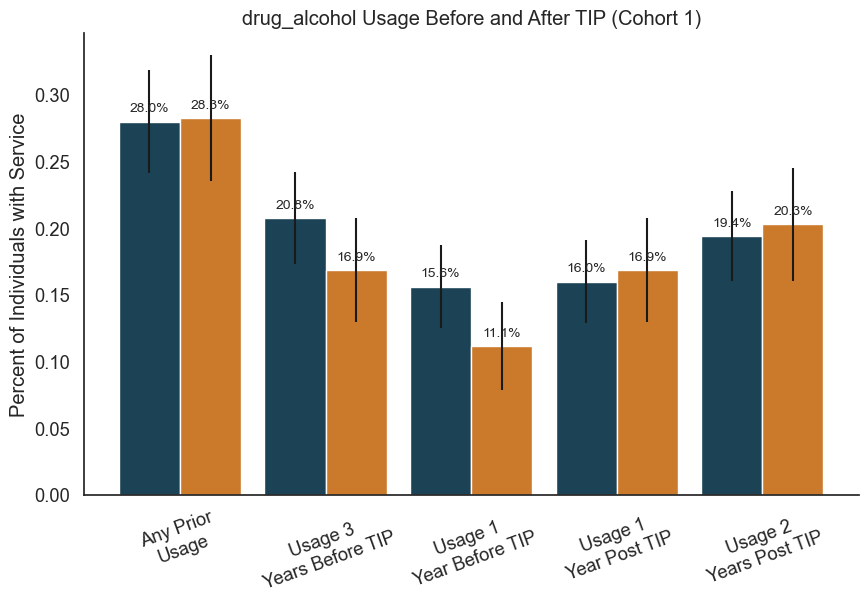

C:\Users\sarah\AppData\Local\Temp\ipykernel_10680\671565394.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Status")["tip_id"]



mental_health usage counts (Cohort 1)
                       label  Graduated  Non Graduated
2           Any Prior\nUsage        219            146
1  Usage 3\nYears Before TIP        161             98
0   Usage 1\nYear Before TIP        109             69
3     Usage 1\nYear Post TIP        143             98
4    Usage 2\nYears Post TIP        165            109


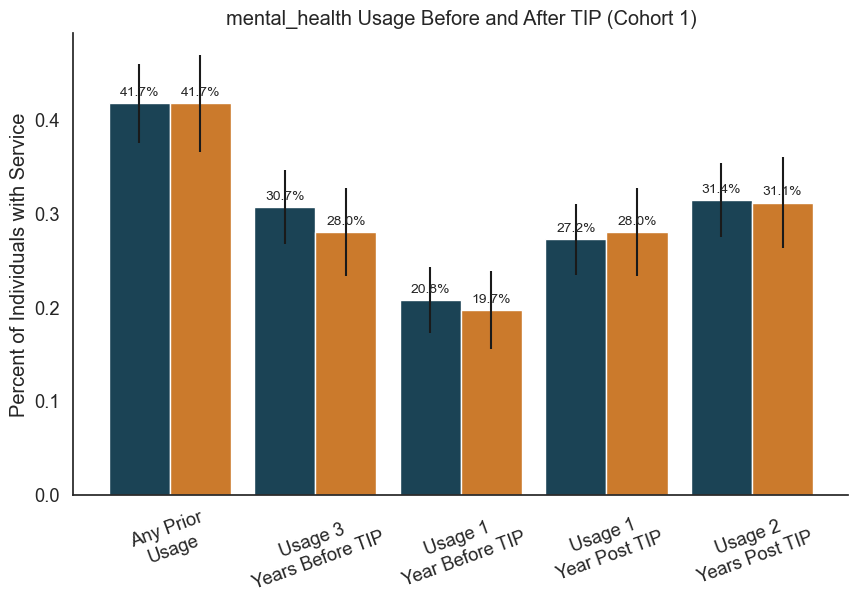


jail_collab usage counts (Cohort 1)
                       label  Graduated  Non Graduated
2           Any Prior\nUsage        132             89
1  Usage 3\nYears Before TIP        117             76
0   Usage 1\nYear Before TIP         90             56
3     Usage 1\nYear Post TIP         93             57
4    Usage 2\nYears Post TIP        106             70


C:\Users\sarah\AppData\Local\Temp\ipykernel_10680\671565394.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Status")["tip_id"]


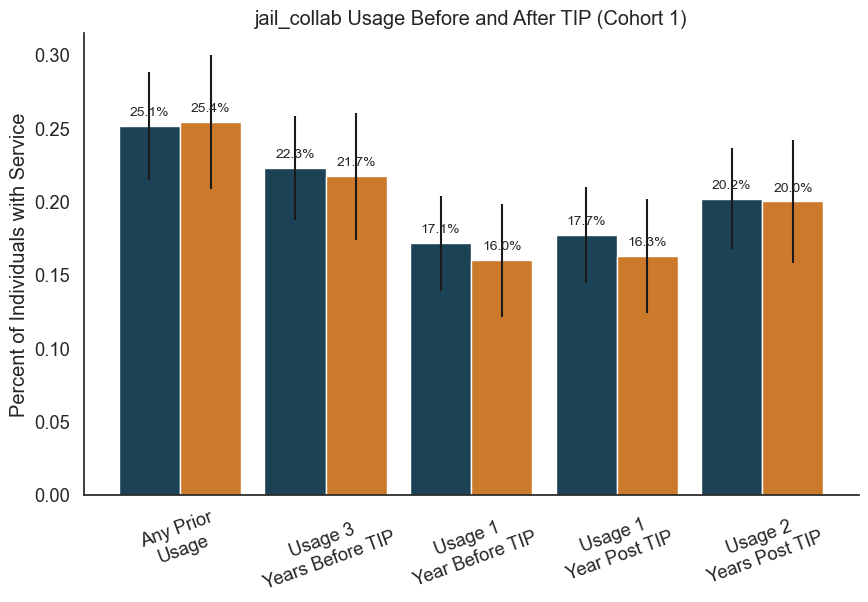

C:\Users\sarah\AppData\Local\Temp\ipykernel_10680\671565394.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Status")["tip_id"]



home_visiting usage counts (Cohort 1)
                       label  Graduated  Non Graduated
2           Any Prior\nUsage          1              3
1  Usage 3\nYears Before TIP          1              2
0   Usage 1\nYear Before TIP          0              1
3     Usage 1\nYear Post TIP          2              2
4    Usage 2\nYears Post TIP          4              3


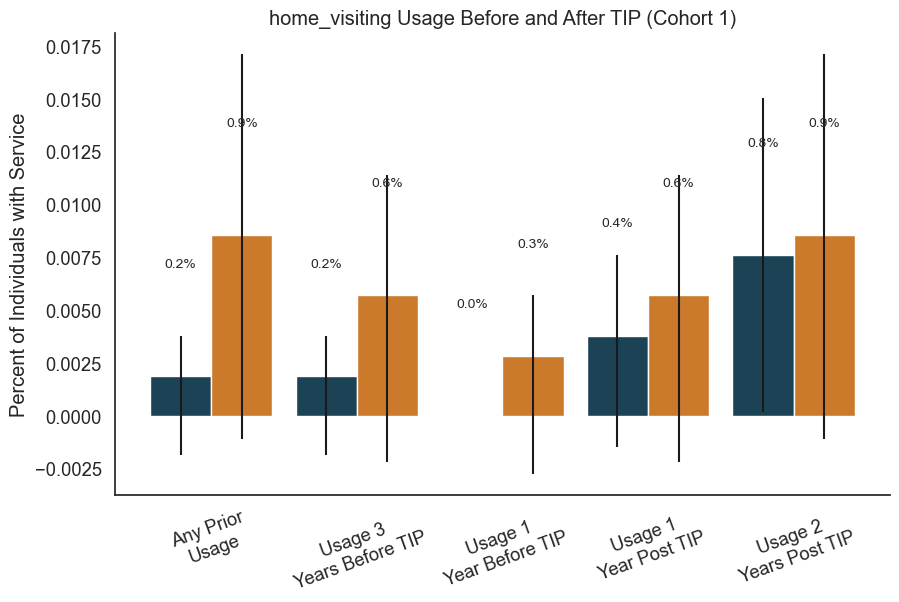

C:\Users\sarah\AppData\Local\Temp\ipykernel_10680\671565394.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Status")["tip_id"]



dhs_housing_supports usage counts (Cohort 1)
                       label  Graduated  Non Graduated
2           Any Prior\nUsage         42             30
1  Usage 3\nYears Before TIP         27             19
0   Usage 1\nYear Before TIP         17             12
3     Usage 1\nYear Post TIP         33             19
4    Usage 2\nYears Post TIP         46             28


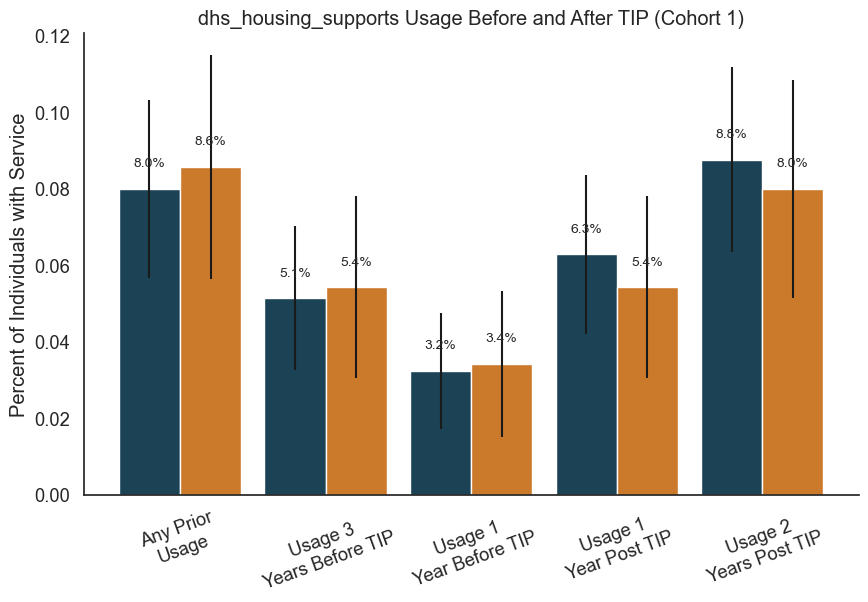

C:\Users\sarah\AppData\Local\Temp\ipykernel_10680\671565394.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Status")["tip_id"]



link_referral usage counts (Cohort 1)
                       label  Graduated  Non Graduated
2           Any Prior\nUsage         25             20
1  Usage 3\nYears Before TIP         20             12
0   Usage 1\nYear Before TIP          7              2
3     Usage 1\nYear Post TIP         13             10
4    Usage 2\nYears Post TIP         23             15


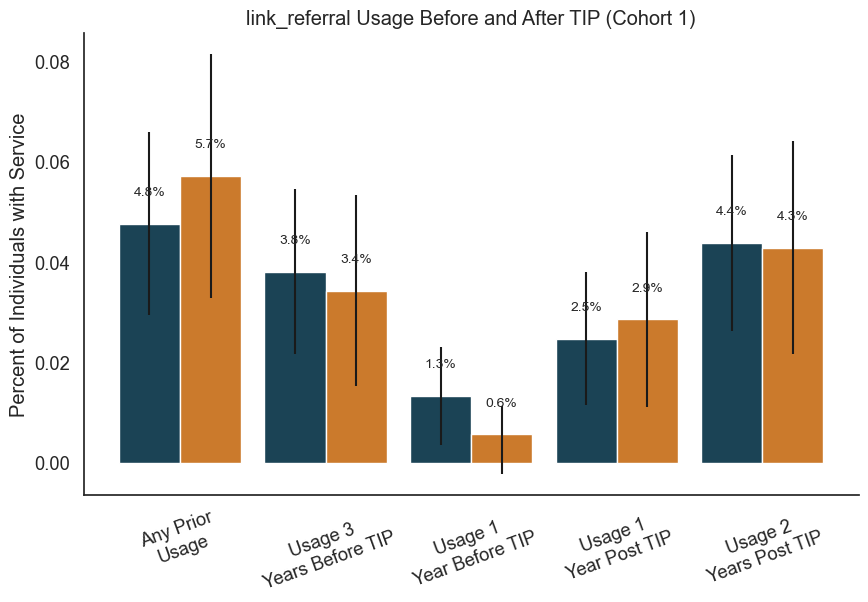

C:\Users\sarah\AppData\Local\Temp\ipykernel_10680\671565394.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Status")["tip_id"]



public_housing usage counts (Cohort 1)
                       label  Graduated  Non Graduated
2           Any Prior\nUsage         32             16
1  Usage 3\nYears Before TIP         15              7
0   Usage 1\nYear Before TIP         12              4
3     Usage 1\nYear Post TIP         12              7
4    Usage 2\nYears Post TIP         14              7


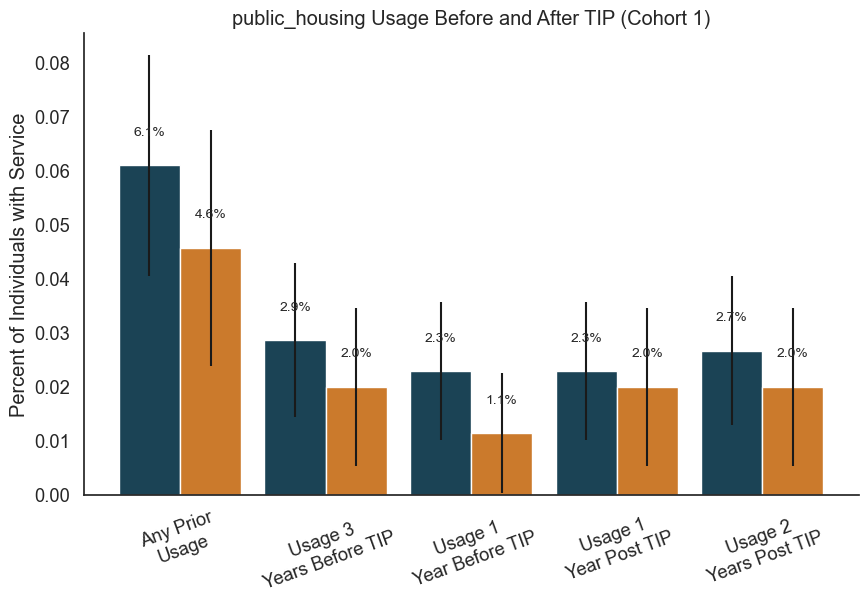

C:\Users\sarah\AppData\Local\Temp\ipykernel_10680\671565394.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Status")["tip_id"]



section8_housing usage counts (Cohort 1)
                       label  Graduated  Non Graduated
2           Any Prior\nUsage         79             58
1  Usage 3\nYears Before TIP         43             27
0   Usage 1\nYear Before TIP         28             21
3     Usage 1\nYear Post TIP         30             18
4    Usage 2\nYears Post TIP         31             18


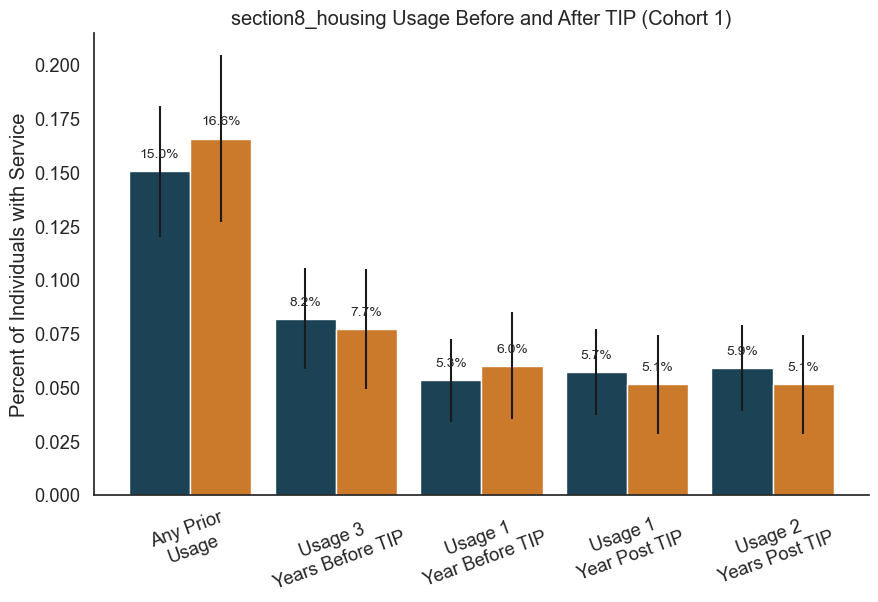

C:\Users\sarah\AppData\Local\Temp\ipykernel_10680\671565394.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Status")["tip_id"]



medicaid usage counts (Cohort 1)
                       label  Graduated  Non Graduated
2           Any Prior\nUsage        339            247
1  Usage 3\nYears Before TIP        301            206
0   Usage 1\nYear Before TIP        263            181
3     Usage 1\nYear Post TIP        336            223
4    Usage 2\nYears Post TIP        357            240


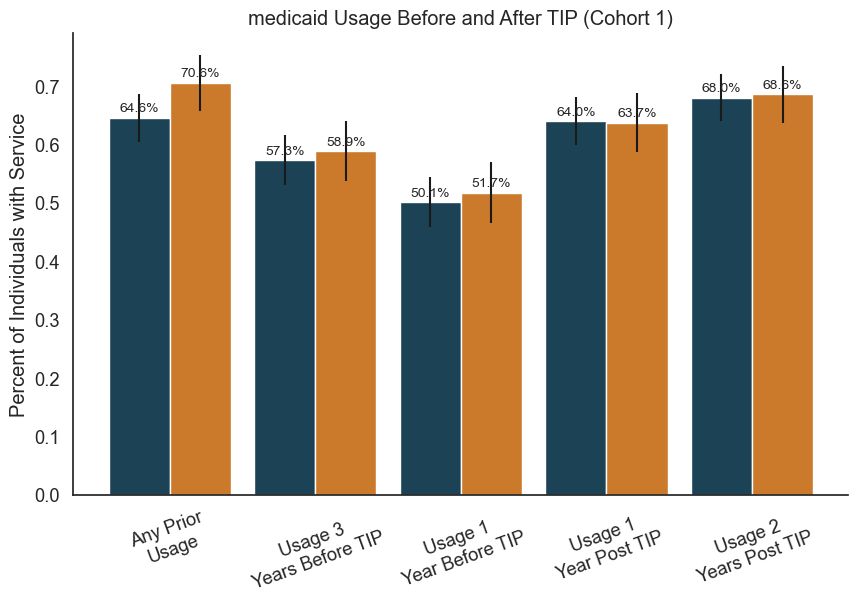

C:\Users\sarah\AppData\Local\Temp\ipykernel_10680\671565394.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Status")["tip_id"]



snap usage counts (Cohort 1)
                       label  Graduated  Non Graduated
2           Any Prior\nUsage        146            110
1  Usage 3\nYears Before TIP        141            106
0   Usage 1\nYear Before TIP        119             82
3     Usage 1\nYear Post TIP        213            145
4    Usage 2\nYears Post TIP        240            162


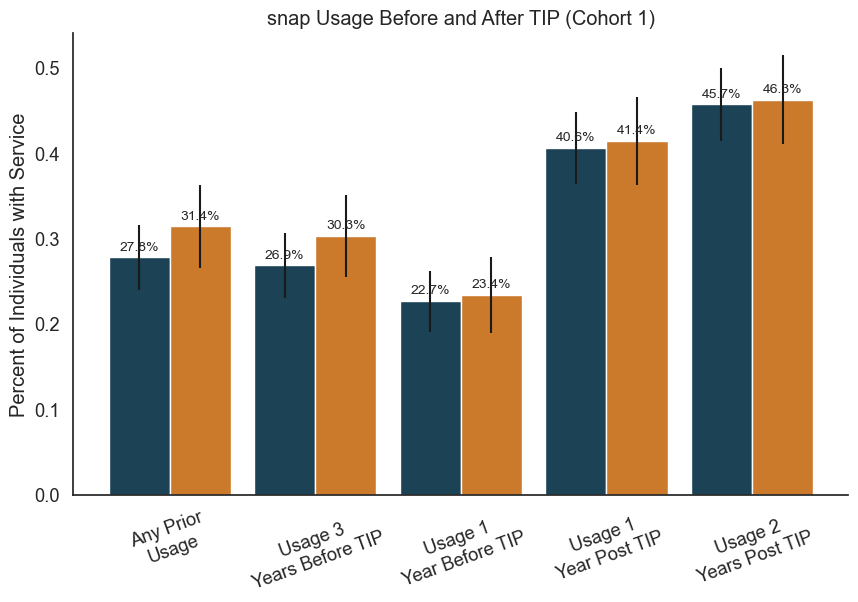

C:\Users\sarah\AppData\Local\Temp\ipykernel_10680\671565394.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Status")["tip_id"]



tanf usage counts (Cohort 1)
                       label  Graduated  Non Graduated
2           Any Prior\nUsage         11             12
1  Usage 3\nYears Before TIP          9             10
0   Usage 1\nYear Before TIP          4              2
3     Usage 1\nYear Post TIP          9              6
4    Usage 2\nYears Post TIP         10              7


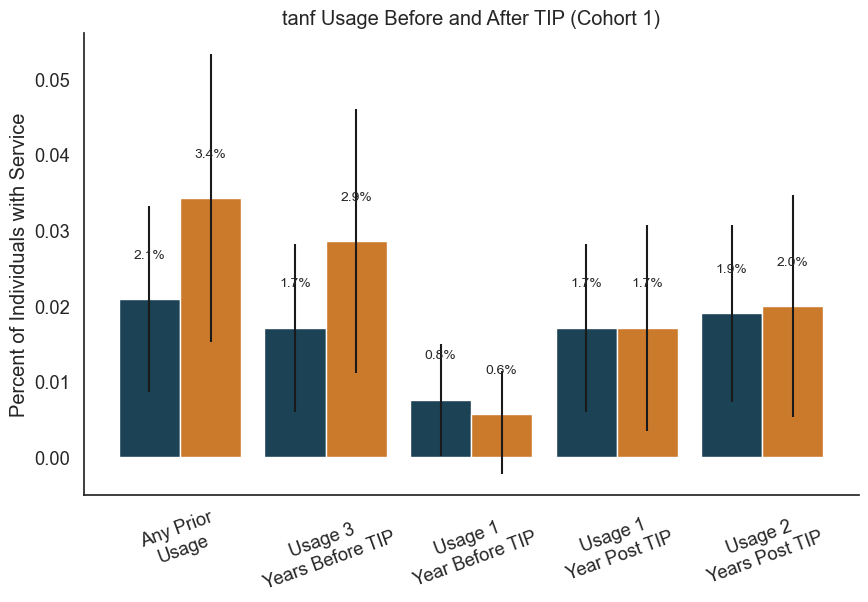

C:\Users\sarah\AppData\Local\Temp\ipykernel_10680\671565394.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Status")["tip_id"]



ssi usage counts (Cohort 1)
                       label  Graduated  Non Graduated
2           Any Prior\nUsage         30             18
1  Usage 3\nYears Before TIP         29             16
0   Usage 1\nYear Before TIP         25             14
3     Usage 1\nYear Post TIP         27             15
4    Usage 2\nYears Post TIP         29             15


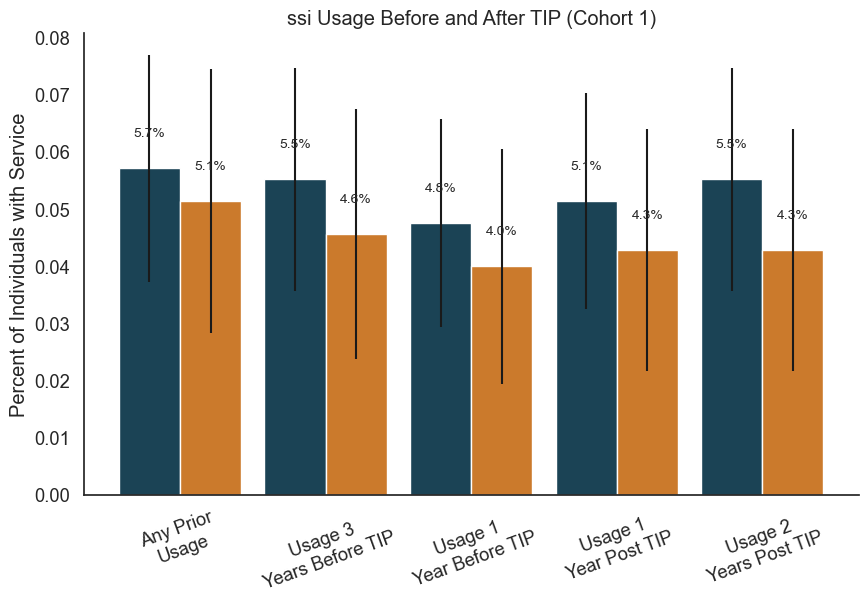

In [330]:
#Check the following individual service usage

service_cols = [
    "drug_alcohol",
    "mental_health",
    "jail_collab",
    "home_visiting",
    "dhs_housing_supports",
    "link_referral",
    "public_housing",
    "section8_housing",
    "medicaid",
    "snap",
    "tanf",
    "ssi"
]

for service in service_cols:
    plot_service_usage(service, 1, df_services, df_student)



drug_alcohol usage counts (Cohort 2)
                       label  Graduated  Non Graduated
2           Any Prior\nUsage         53             88
1  Usage 3\nYears Before TIP         28             53
0   Usage 1\nYear Before TIP         19             34
3     Usage 1\nYear Post TIP         10             23
4    Usage 2\nYears Post TIP         10             23


C:\Users\sarah\AppData\Local\Temp\ipykernel_7424\2806306999.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Status")["tip_id"]


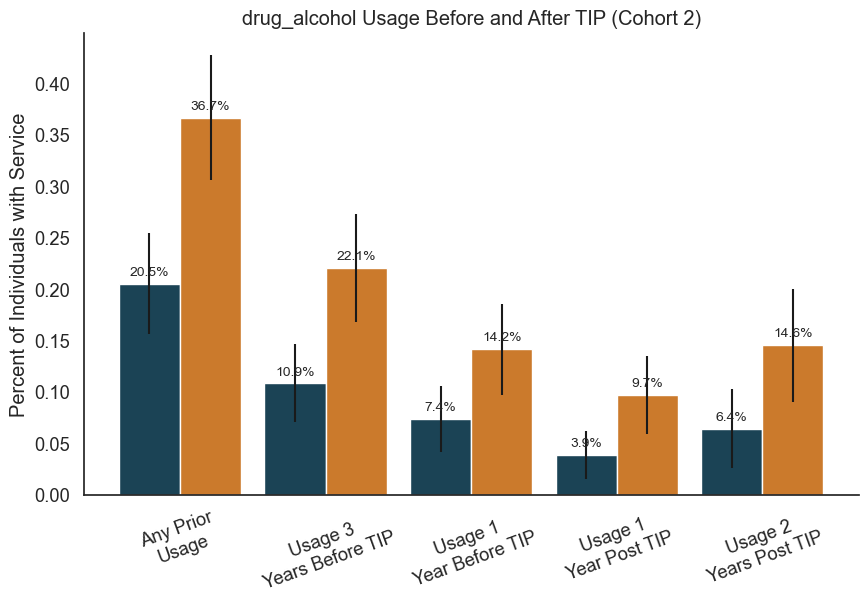

C:\Users\sarah\AppData\Local\Temp\ipykernel_7424\2806306999.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Status")["tip_id"]



mental_health usage counts (Cohort 2)
                       label  Graduated  Non Graduated
2           Any Prior\nUsage        111            154
1  Usage 3\nYears Before TIP         63             83
0   Usage 1\nYear Before TIP         44             49
3     Usage 1\nYear Post TIP         19             34
4    Usage 2\nYears Post TIP         19             34


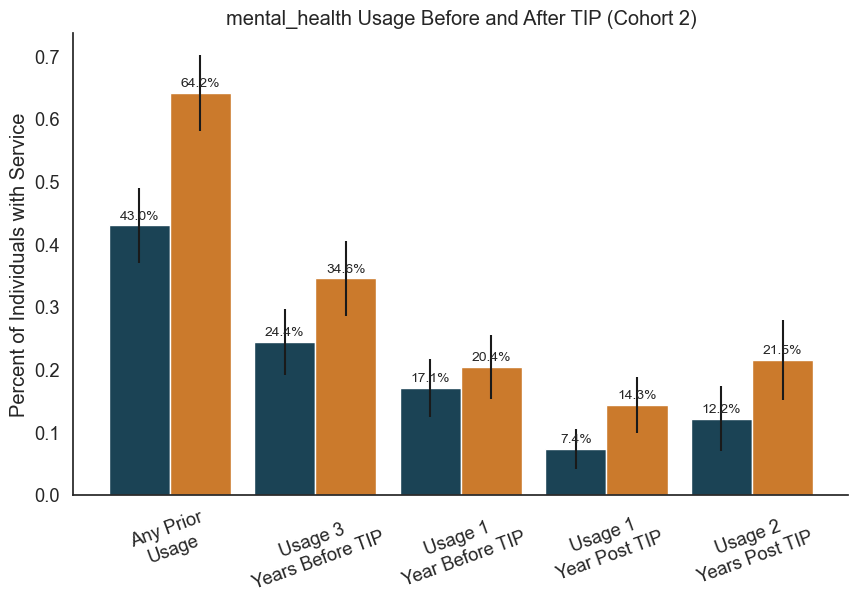

C:\Users\sarah\AppData\Local\Temp\ipykernel_7424\2806306999.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Status")["tip_id"]



jail_collab usage counts (Cohort 2)
                       label  Graduated  Non Graduated
2           Any Prior\nUsage         44             56
1  Usage 3\nYears Before TIP         24             29
0   Usage 1\nYear Before TIP         17             21
3     Usage 1\nYear Post TIP          4             15
4    Usage 2\nYears Post TIP          4             15


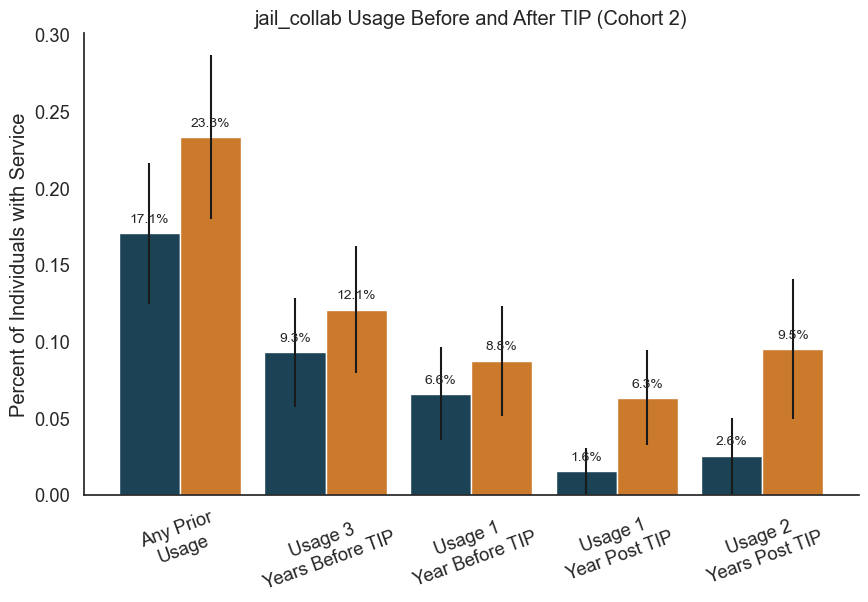

C:\Users\sarah\AppData\Local\Temp\ipykernel_7424\2806306999.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Status")["tip_id"]



home_visiting usage counts (Cohort 2)
                       label  Graduated  Non Graduated
2           Any Prior\nUsage         10              3
1  Usage 3\nYears Before TIP          6              2
0   Usage 1\nYear Before TIP          4              1
3     Usage 1\nYear Post TIP          2              1
4    Usage 2\nYears Post TIP          2              1


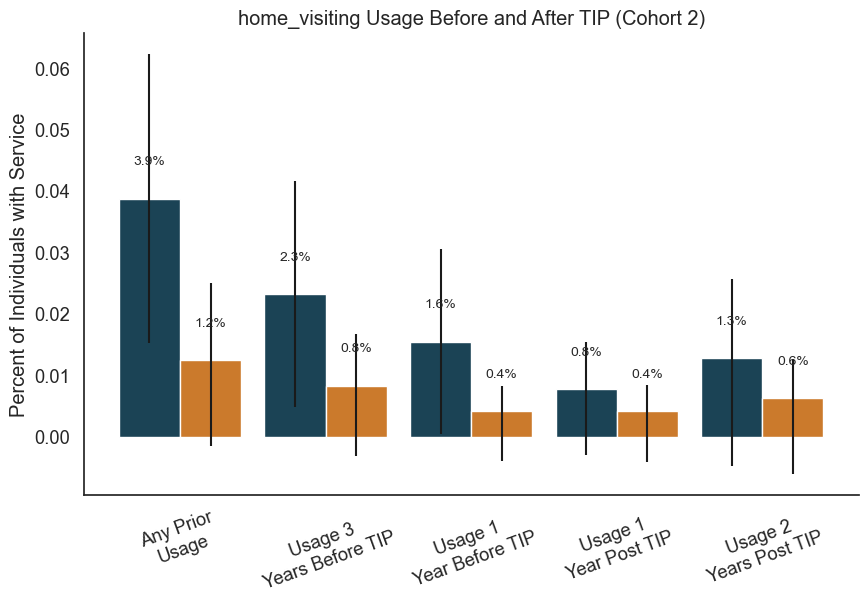

C:\Users\sarah\AppData\Local\Temp\ipykernel_7424\2806306999.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Status")["tip_id"]



dhs_housing_supports usage counts (Cohort 2)
                       label  Graduated  Non Graduated
2           Any Prior\nUsage         40             55
1  Usage 3\nYears Before TIP         22             28
0   Usage 1\nYear Before TIP          8             15
3     Usage 1\nYear Post TIP          3              8
4    Usage 2\nYears Post TIP          3              8


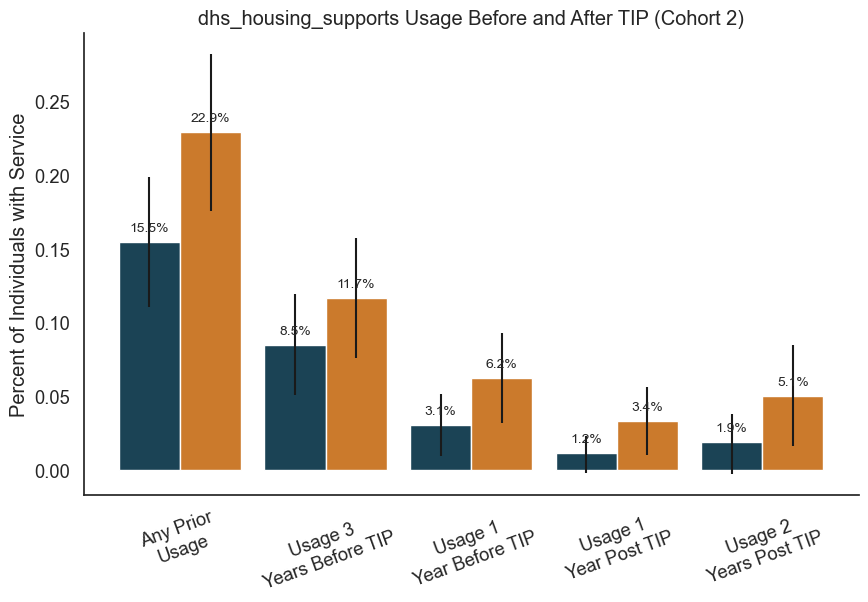

C:\Users\sarah\AppData\Local\Temp\ipykernel_7424\2806306999.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Status")["tip_id"]



link_referral usage counts (Cohort 2)
                       label  Graduated  Non Graduated
2           Any Prior\nUsage         31             39
1  Usage 3\nYears Before TIP         10             15
0   Usage 1\nYear Before TIP          3              8
3     Usage 1\nYear Post TIP          4             10
4    Usage 2\nYears Post TIP          4             10


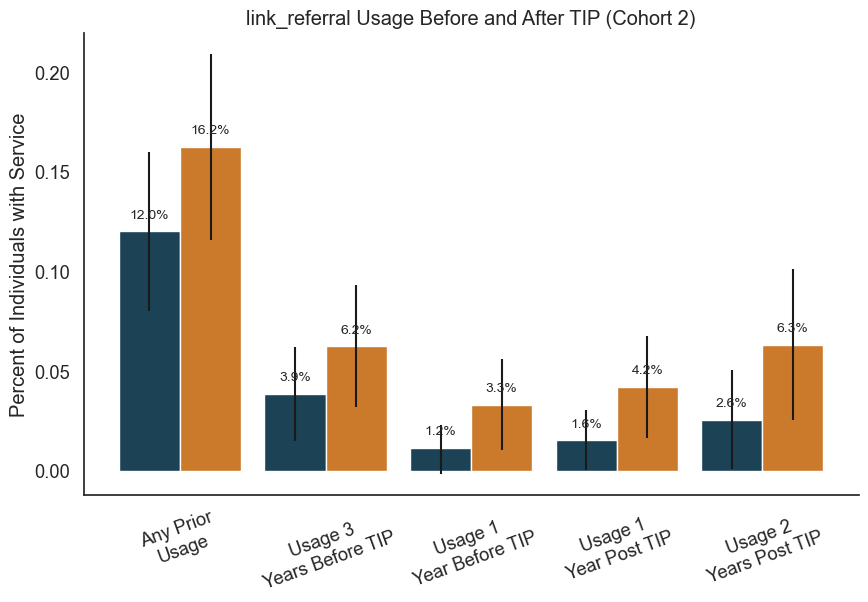

C:\Users\sarah\AppData\Local\Temp\ipykernel_7424\2806306999.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Status")["tip_id"]



public_housing usage counts (Cohort 2)
                       label  Graduated  Non Graduated
2           Any Prior\nUsage         28             26
1  Usage 3\nYears Before TIP         12              9
0   Usage 1\nYear Before TIP          8              5
3     Usage 1\nYear Post TIP          5              2
4    Usage 2\nYears Post TIP          5              2


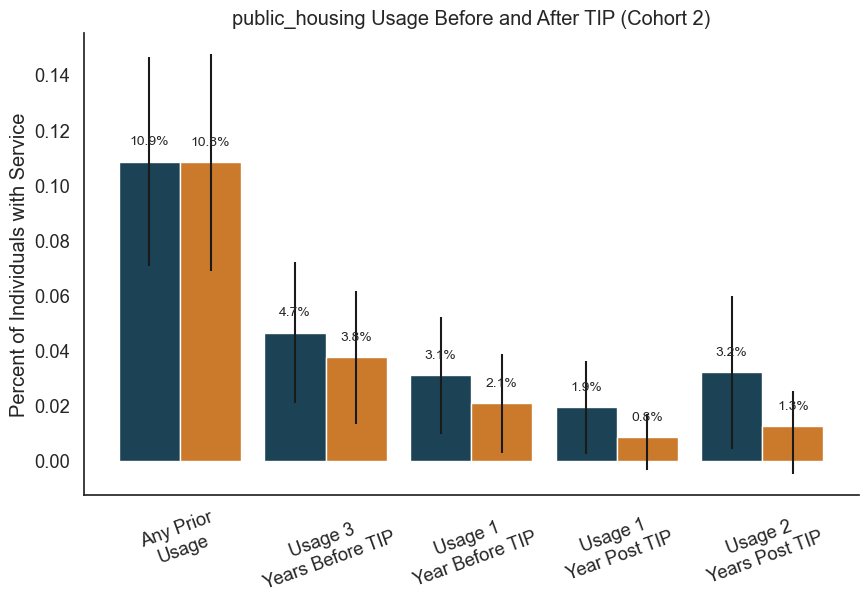

C:\Users\sarah\AppData\Local\Temp\ipykernel_7424\2806306999.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Status")["tip_id"]



section8_housing usage counts (Cohort 2)
                       label  Graduated  Non Graduated
2           Any Prior\nUsage         78             79
1  Usage 3\nYears Before TIP         31             23
0   Usage 1\nYear Before TIP         23             17
3     Usage 1\nYear Post TIP         13             10
4    Usage 2\nYears Post TIP         13             10


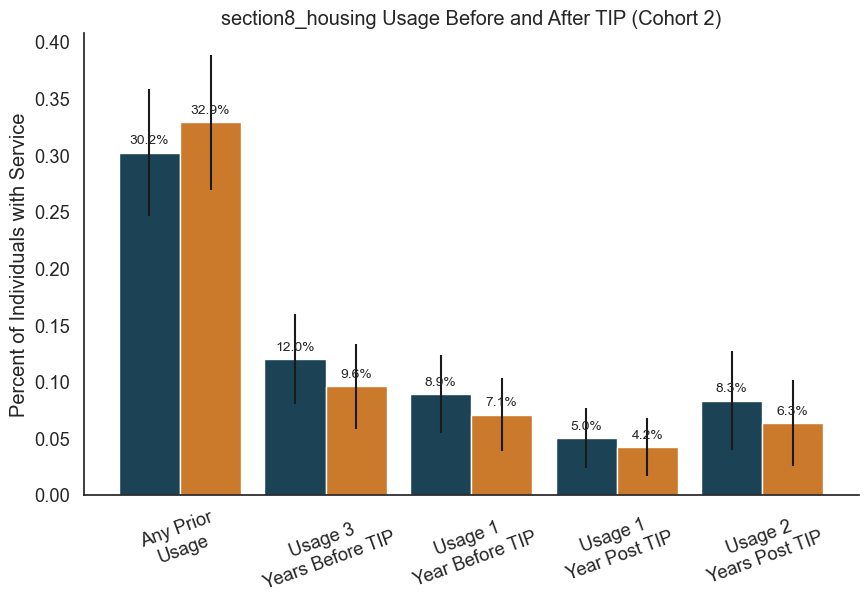

C:\Users\sarah\AppData\Local\Temp\ipykernel_7424\2806306999.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Status")["tip_id"]



medicaid usage counts (Cohort 2)
                       label  Graduated  Non Graduated
2           Any Prior\nUsage        219            214
1  Usage 3\nYears Before TIP        194            196
0   Usage 1\nYear Before TIP        182            190
3     Usage 1\nYear Post TIP        121            113
4    Usage 2\nYears Post TIP        121            113


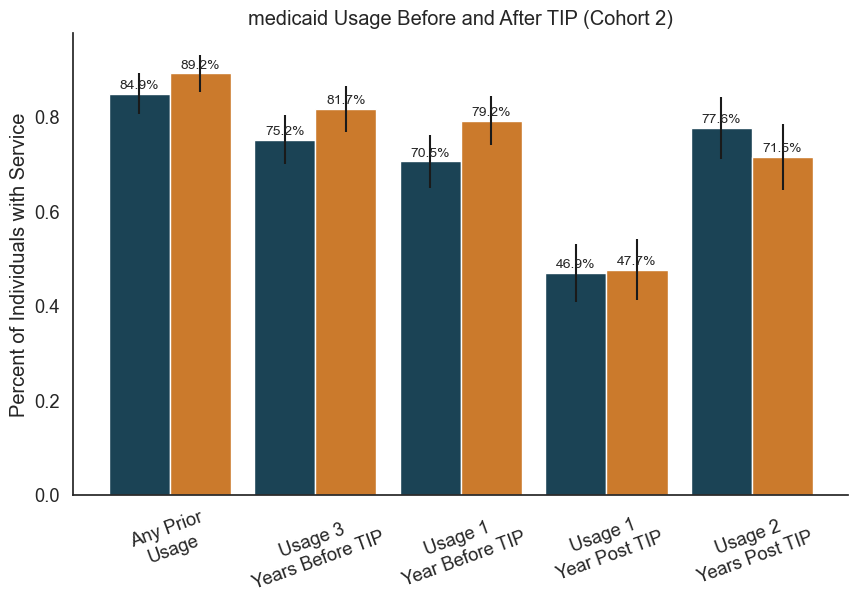

C:\Users\sarah\AppData\Local\Temp\ipykernel_7424\2806306999.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Status")["tip_id"]



snap usage counts (Cohort 2)
                       label  Graduated  Non Graduated
2           Any Prior\nUsage        203            193
1  Usage 3\nYears Before TIP        174            169
0   Usage 1\nYear Before TIP        139            141
3     Usage 1\nYear Post TIP         86             88
4    Usage 2\nYears Post TIP         86             88


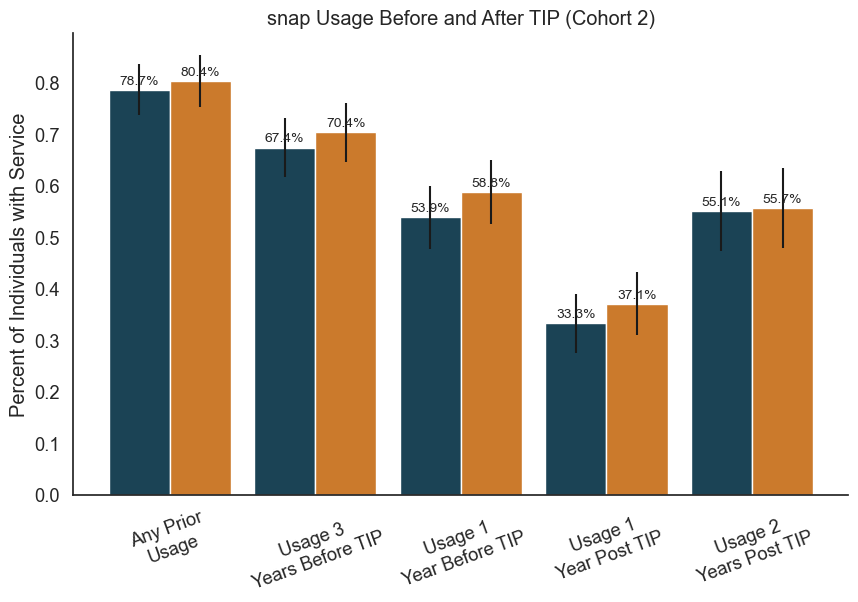

C:\Users\sarah\AppData\Local\Temp\ipykernel_7424\2806306999.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Status")["tip_id"]



tanf usage counts (Cohort 2)
                       label  Graduated  Non Graduated
2           Any Prior\nUsage         34             45
1  Usage 3\nYears Before TIP         15             18
0   Usage 1\nYear Before TIP          6              9
3     Usage 1\nYear Post TIP          0              1
4    Usage 2\nYears Post TIP          0              1


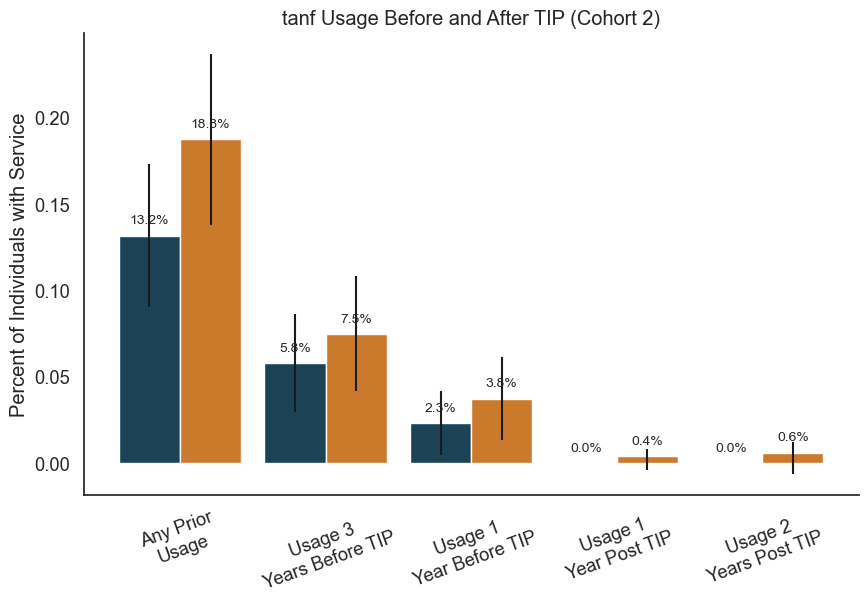

C:\Users\sarah\AppData\Local\Temp\ipykernel_7424\2806306999.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Status")["tip_id"]



ssi usage counts (Cohort 2)
                       label  Graduated  Non Graduated
2           Any Prior\nUsage         28             32
1  Usage 3\nYears Before TIP         20             18
0   Usage 1\nYear Before TIP         14             14
3     Usage 1\nYear Post TIP          7              5
4    Usage 2\nYears Post TIP          7              5


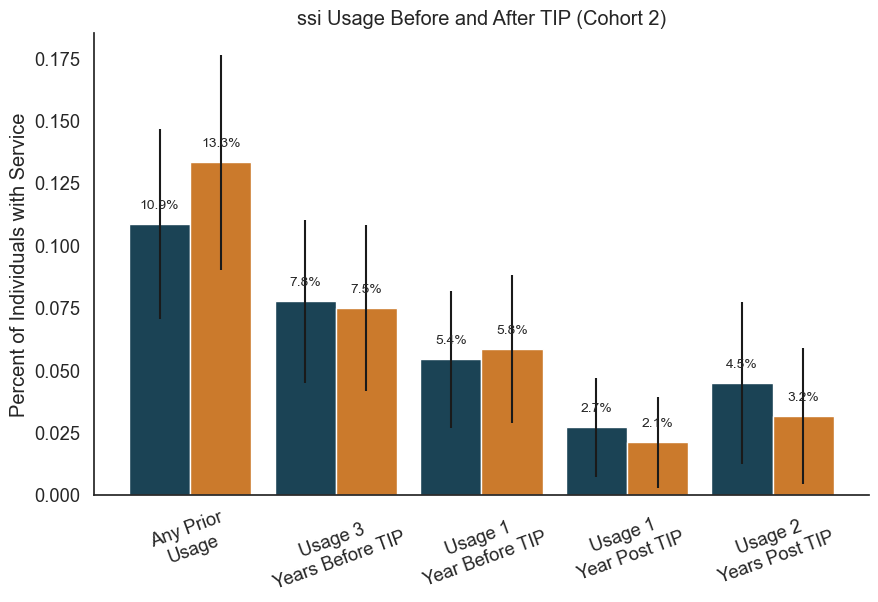

In [1862]:
for service in service_cols:
    plot_service_usage(service, 2, df_services, df_student)

C:\Users\sarah\AppData\Local\Temp\ipykernel_10680\247134817.py:41: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Status")["tip_id"]


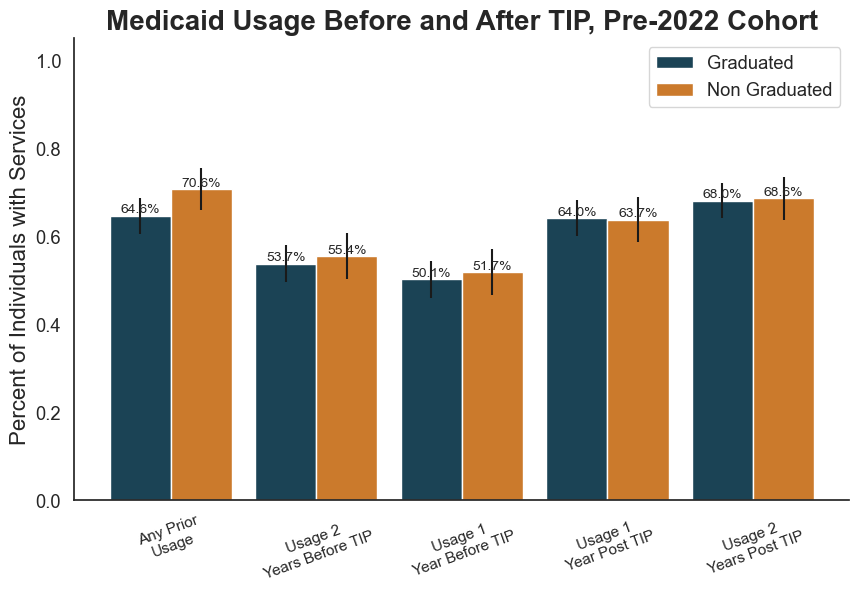

In [331]:
#Make more beautiful graphics for presentation, post-check

#Medicaid - Cohort 1

# keep only Graduated / Non Graduated
svc_c1 = df_services.copy()
svc_c1 = svc_c1[
    (svc_c1["cohort_2022"] == 1) &
    (svc_c1["medicaid"] == 1) &
    (svc_c1["Status"].isin(["Graduated","Non Graduated"]))
].copy()

# -----------------------------
#pre-TIP

pre_bins = {
    -1: [-1],             # 1 year pre
    -2: [-2, -1],     # 1-3 years pre
    -30: list(range(-30, 0))  # any prior usage
}

svc_c1["YearsSinceTIP_int"] = svc_c1["YearsSinceTIP"].round().astype(int)

rows = []
for bin_edge, years in pre_bins.items():
    cur = svc_c1[svc_c1["YearsSinceTIP_int"].isin(years)]
    
    row = {"YearsSinceTIP": bin_edge}
    for status in ["Graduated", "Non Graduated"]:
        num = cur.loc[cur["Status"] == status, "tip_id"].nunique()
        row[status] = num
        
    rows.append(row)

pre_count = pd.DataFrame(rows)

# denominators for pre: total people per status

denom_pre = (
    df_student[(df_student["Status"].isin(["Graduated", "Non Graduated"])) & (df_student["cohort_2022"] == 1)]
    .groupby("Status")["tip_id"]
    .nunique()
    .to_dict()
)

z = 1.96
for status in ["Graduated", "Non Graduated"]:
    pre_count[f"{status} Percent"] = pre_count[status] / denom_pre.get(status, np.nan)
    p = pre_count[f"{status} Percent"]
    n = denom_pre.get(status, np.nan)
    se = np.sqrt(p * (1 - p) / n)
    pre_count[f"{status}_Upper_CI"] = (p + z * se).clip(0, 1)
    pre_count[f"{status}_Lower_CI"] = (p - z * se).clip(0, 1)

# -----------------------------
#post-TIP

post_points = [1, 2]
rows = []

for i in post_points:
    cur = svc_c1[(svc_c1["YearsSinceTIP"] >= 0) & (svc_c1["YearsSinceTIP"] < i+1) & (svc_c1["ValidYears"] >= i)]

    row = {"YearsSinceTIP": i}
    for status in ["Graduated", "Non Graduated"]:
        num = cur.loc[cur["Status"] == status, "tip_id"].nunique()
        denom = df_student.loc[(df_student["Status"] == status) & (df_student["ValidYears"] >= i) & (df_student["cohort_2022"] == 1), "tip_id"].nunique()

        p = (num / denom) if denom > 0 else 0
        se = np.sqrt(p * (1 - p) / denom) if denom > 0 else np.nan

        row[f"{status}"] = num
        row[f"{status} Percent"] = p
        row[f"{status}_Upper_CI"] = min(1, p + z * se) if denom > 0 else np.nan
        row[f"{status}_Lower_CI"] = max(0, p - z * se) if denom > 0 else np.nan

    rows.append(row)

post_df = pd.DataFrame(rows)

# -----------------------------
#combine and plot

label_map = {
    -30: "Any Prior\nUsage",
    -2:  "Usage 2\nYears Before TIP",
    -1:  "Usage 1\nYear Before TIP",
     1:  "Usage 1\nYear Post TIP",
     2:  "Usage 2\nYears Post TIP"
}
order = [-30, -2, -1, 1, 2]

pre_keep = pre_count[pre_count["YearsSinceTIP"].isin([-30, -2, -1])].copy()
data = pd.concat([pre_keep, post_df], ignore_index=True)
medicaid_pre2022 = data.copy()

data["YearsSinceTIP"] = data["YearsSinceTIP"].astype(int)
data["YearsSinceTIP"] = pd.Categorical(data["YearsSinceTIP"], categories=order, ordered=True)
data = data.sort_values("YearsSinceTIP").reset_index(drop=True)
data["label"] = data["YearsSinceTIP"].astype(int).map(label_map)

grad_err = np.abs(
    data[["Graduated_Upper_CI", "Graduated_Lower_CI"]].T.values - data["Graduated Percent"].values
)
non_grad_err = np.abs(
    data[["Non Graduated_Upper_CI", "Non Graduated_Lower_CI"]].T.values - data["Non Graduated Percent"].values
)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(data))
width = 0.42

ax.bar(x - width/2, data["Graduated Percent"], width=width, label="Graduated", yerr=grad_err, capsize=0)
ax.bar(x + width/2, data["Non Graduated Percent"], width=width, label="Non Graduated", yerr=non_grad_err, capsize=0)

ax.set_xticks(x)
ax.set_xticklabels(data["label"], rotation=20, ha="center", fontsize=11)

for xi, yi in zip(x - width/2, data["Graduated Percent"]):
    ax.text(xi, yi, f"{yi:.1%}", ha="center", va="bottom", fontsize=10)
for xi, yi in zip(x + width/2, data["Non Graduated Percent"]):
    ax.text(xi, yi, f"{yi:.1%}", ha="center", va="bottom", fontsize=10)

sns.despine()
plt.title("Medicaid Usage Before and After TIP, Pre-2022 Cohort", fontdict={"fontsize": 20, "fontweight": "semibold"})
plt.ylabel("Percent of Individuals with Services", fontdict={"fontsize": 16})
plt.ylim(0, 1.05)
plt.legend(loc="upper right")
plt.show()


C:\Users\sarah\AppData\Local\Temp\ipykernel_10680\4239940009.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Status")["tip_id"]


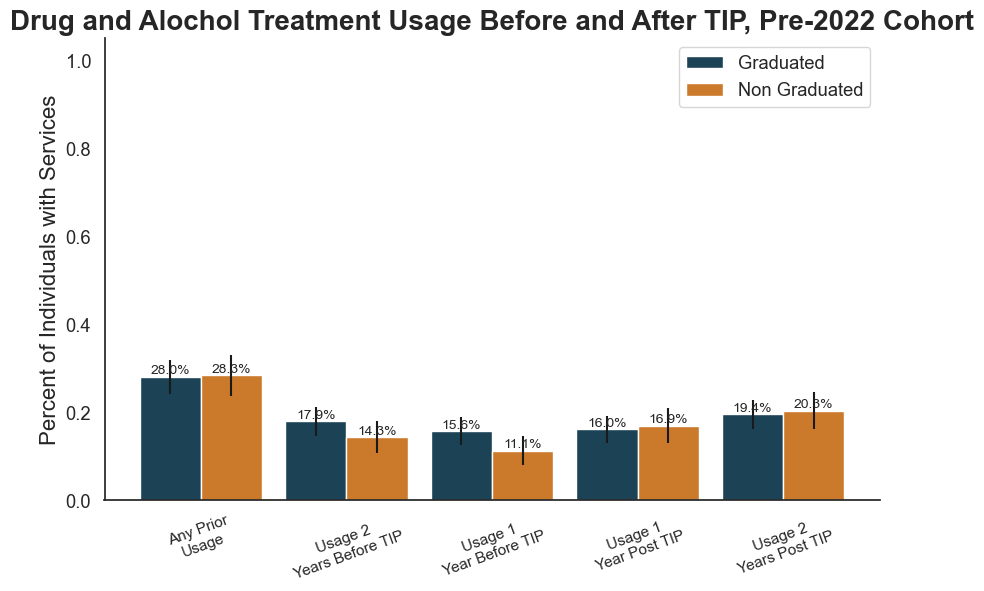

In [332]:
#Drug Alcohol - Cohort 1

# keep only Graduated / Non Graduated
svc_c1 = df_services.copy()
svc_c1 = svc_c1[
    (svc_c1["cohort_2022"] == 1) &
    (svc_c1["drug_alcohol"] == 1) &
    (svc_c1["Status"].isin(["Graduated","Non Graduated"]))
].copy()

# -----------------------------
#pre-TIP

pre_bins = {
    -1: [-1],             # 1 year pre
    -2: [-2, -1],     # 1-3 years pre
    -30: list(range(-30, 0))  # any prior usage
}

svc_c1["YearsSinceTIP_int"] = svc_c1["YearsSinceTIP"].round().astype(int)

rows = []
for bin_edge, years in pre_bins.items():
    cur = svc_c1[svc_c1["YearsSinceTIP_int"].isin(years)]
    
    row = {"YearsSinceTIP": bin_edge}
    for status in ["Graduated", "Non Graduated"]:
        num = cur.loc[cur["Status"] == status, "tip_id"].nunique()
        row[status] = num
        
    rows.append(row)

pre_count = pd.DataFrame(rows)

# denominators for pre: total people per status

denom_pre = (
    df_student[(df_student["Status"].isin(["Graduated", "Non Graduated"])) & (df_student["cohort_2022"] == 1)]
    .groupby("Status")["tip_id"]
    .nunique()
    .to_dict()
)

z = 1.96
for status in ["Graduated", "Non Graduated"]:
    pre_count[f"{status} Percent"] = pre_count[status] / denom_pre.get(status, np.nan)
    p = pre_count[f"{status} Percent"]
    n = denom_pre.get(status, np.nan)
    se = np.sqrt(p * (1 - p) / n)
    pre_count[f"{status}_Upper_CI"] = (p + z * se).clip(0, 1)
    pre_count[f"{status}_Lower_CI"] = (p - z * se).clip(0, 1)

# -----------------------------
#post-TIP

post_points = [1, 2]
rows = []

for i in post_points:
    cur = svc_c1[(svc_c1["YearsSinceTIP"] >= 0) & (svc_c1["YearsSinceTIP"] < i+1) & (svc_c1["ValidYears"] >= i)]

    row = {"YearsSinceTIP": i}
    for status in ["Graduated", "Non Graduated"]:
        num = cur.loc[cur["Status"] == status, "tip_id"].nunique()
        denom = df_student.loc[(df_student["Status"] == status) & (df_student["ValidYears"] >= i) & (df_student["cohort_2022"] == 1), "tip_id"].nunique()

        p = (num / denom) if denom > 0 else 0
        se = np.sqrt(p * (1 - p) / denom) if denom > 0 else np.nan

        row[f"{status}"] = num
        row[f"{status} Percent"] = p
        row[f"{status}_Upper_CI"] = min(1, p + z * se) if denom > 0 else np.nan
        row[f"{status}_Lower_CI"] = max(0, p - z * se) if denom > 0 else np.nan

    rows.append(row)

post_df = pd.DataFrame(rows)

# -----------------------------
#combine and plot

label_map = {
    -30: "Any Prior\nUsage",
    -2:  "Usage 2\nYears Before TIP",
    -1:  "Usage 1\nYear Before TIP",
     1:  "Usage 1\nYear Post TIP",
     2:  "Usage 2\nYears Post TIP"
}
order = [-30, -2, -1, 1, 2]

pre_keep = pre_count[pre_count["YearsSinceTIP"].isin([-30, -2, -1])].copy()
data = pd.concat([pre_keep, post_df], ignore_index=True)
drug_pre2022 = data.copy()

data["YearsSinceTIP"] = data["YearsSinceTIP"].astype(int)
data["YearsSinceTIP"] = pd.Categorical(data["YearsSinceTIP"], categories=order, ordered=True)
data = data.sort_values("YearsSinceTIP").reset_index(drop=True)
data["label"] = data["YearsSinceTIP"].astype(int).map(label_map)

grad_err = np.abs(
    data[["Graduated_Upper_CI", "Graduated_Lower_CI"]].T.values - data["Graduated Percent"].values
)
non_grad_err = np.abs(
    data[["Non Graduated_Upper_CI", "Non Graduated_Lower_CI"]].T.values - data["Non Graduated Percent"].values
)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(data))
width = 0.42

ax.bar(x - width/2, data["Graduated Percent"], width=width, label="Graduated", yerr=grad_err, capsize=0)
ax.bar(x + width/2, data["Non Graduated Percent"], width=width, label="Non Graduated", yerr=non_grad_err, capsize=0)

ax.set_xticks(x)
ax.set_xticklabels(data["label"], rotation=20, ha="center", fontsize=11)

for xi, yi in zip(x - width/2, data["Graduated Percent"]):
    ax.text(xi, yi, f"{yi:.1%}", ha="center", va="bottom", fontsize=10)
for xi, yi in zip(x + width/2, data["Non Graduated Percent"]):
    ax.text(xi, yi, f"{yi:.1%}", ha="center", va="bottom", fontsize=10)

sns.despine()
plt.title("Drug and Alochol Treatment Usage Before and After TIP, Pre-2022 Cohort", fontdict={"fontsize": 20, "fontweight": "semibold"})
plt.ylabel("Percent of Individuals with Services", fontdict={"fontsize": 16})
plt.ylim(0, 1.05)
plt.legend(loc="upper right")
plt.show()


C:\Users\sarah\AppData\Local\Temp\ipykernel_10680\3753756720.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Status")["tip_id"]


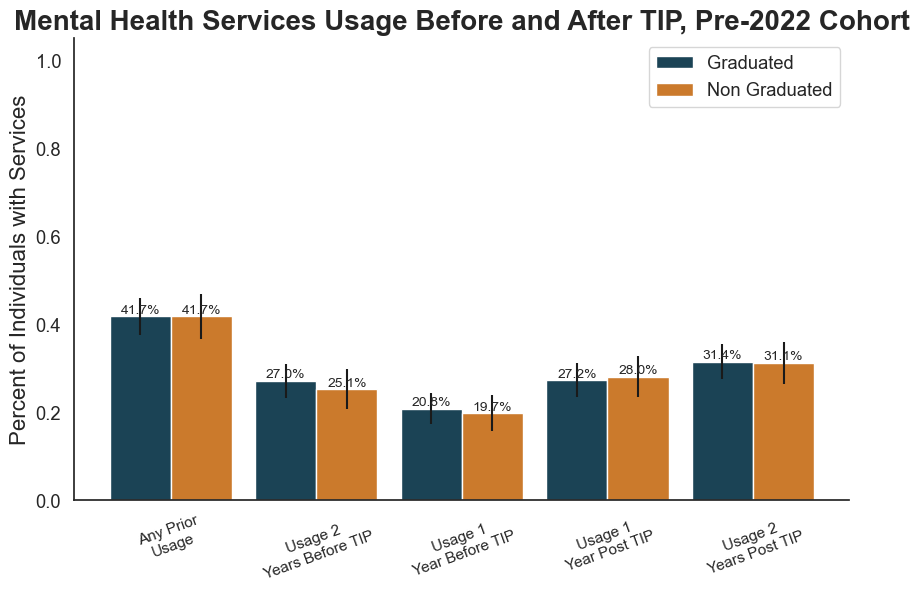

In [333]:
#Mental Health - Cohort 1

# keep only Graduated / Non Graduated
svc_c1 = df_services.copy()
svc_c1 = svc_c1[
    (svc_c1["cohort_2022"] == 1) &
    (svc_c1["mental_health"] == 1) &
    (svc_c1["Status"].isin(["Graduated","Non Graduated"]))
].copy()

# -----------------------------
#pre-TIP

pre_bins = {
    -1: [-1],             # 1 year pre
    -2: [ -2, -1],     # 1-3 years pre
    -30: list(range(-30, 0))  # any prior usage
}

svc_c1["YearsSinceTIP_int"] = svc_c1["YearsSinceTIP"].round().astype(int)

rows = []
for bin_edge, years in pre_bins.items():
    cur = svc_c1[svc_c1["YearsSinceTIP_int"].isin(years)]
    
    row = {"YearsSinceTIP": bin_edge}
    for status in ["Graduated", "Non Graduated"]:
        num = cur.loc[cur["Status"] == status, "tip_id"].nunique()
        row[status] = num
        
    rows.append(row)

pre_count = pd.DataFrame(rows)

# denominators for pre: total people per status

denom_pre = (
    df_student[(df_student["Status"].isin(["Graduated", "Non Graduated"])) & (df_student["cohort_2022"] == 1)]
    .groupby("Status")["tip_id"]
    .nunique()
    .to_dict()
)

z = 1.96
for status in ["Graduated", "Non Graduated"]:
    pre_count[f"{status} Percent"] = pre_count[status] / denom_pre.get(status, np.nan)
    p = pre_count[f"{status} Percent"]
    n = denom_pre.get(status, np.nan)
    se = np.sqrt(p * (1 - p) / n)
    pre_count[f"{status}_Upper_CI"] = (p + z * se).clip(0, 1)
    pre_count[f"{status}_Lower_CI"] = (p - z * se).clip(0, 1)

# -----------------------------
#post-TIP 

post_points = [1, 2]
rows = []

for i in post_points:
    cur = svc_c1[(svc_c1["YearsSinceTIP"] >= 0) & (svc_c1["YearsSinceTIP"] < i+1) & (svc_c1["ValidYears"] >= i)]

    row = {"YearsSinceTIP": i}
    for status in ["Graduated", "Non Graduated"]:
        num = cur.loc[cur["Status"] == status, "tip_id"].nunique()
        denom = df_student.loc[(df_student["Status"] == status) & (df_student["ValidYears"] >= i) & (df_student["cohort_2022"] == 1), "tip_id"].nunique()

        p = (num / denom) if denom > 0 else 0
        se = np.sqrt(p * (1 - p) / denom) if denom > 0 else np.nan

        row[f"{status}"] = num
        row[f"{status} Percent"] = p
        row[f"{status}_Upper_CI"] = min(1, p + z * se) if denom > 0 else np.nan
        row[f"{status}_Lower_CI"] = max(0, p - z * se) if denom > 0 else np.nan

    rows.append(row)

post_df = pd.DataFrame(rows)

# -----------------------------
#combine and plot

label_map = {
    -30: "Any Prior\nUsage",
    -2:  "Usage 2\nYears Before TIP",
    -1:  "Usage 1\nYear Before TIP",
     1:  "Usage 1\nYear Post TIP",
     2:  "Usage 2\nYears Post TIP"
}
order = [-30, -2, -1, 1, 2]

pre_keep = pre_count[pre_count["YearsSinceTIP"].isin([-30, -2, -1])].copy()
data = pd.concat([pre_keep, post_df], ignore_index=True)
mental_pre2022 = data.copy()

data["YearsSinceTIP"] = data["YearsSinceTIP"].astype(int)
data["YearsSinceTIP"] = pd.Categorical(data["YearsSinceTIP"], categories=order, ordered=True)
data = data.sort_values("YearsSinceTIP").reset_index(drop=True)
data["label"] = data["YearsSinceTIP"].astype(int).map(label_map)

grad_err = np.abs(
    data[["Graduated_Upper_CI", "Graduated_Lower_CI"]].T.values - data["Graduated Percent"].values
)
non_grad_err = np.abs(
    data[["Non Graduated_Upper_CI", "Non Graduated_Lower_CI"]].T.values - data["Non Graduated Percent"].values
)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(data))
width = 0.42

ax.bar(x - width/2, data["Graduated Percent"], width=width, label="Graduated", yerr=grad_err, capsize=0)
ax.bar(x + width/2, data["Non Graduated Percent"], width=width, label="Non Graduated", yerr=non_grad_err, capsize=0)

ax.set_xticks(x)
ax.set_xticklabels(data["label"], rotation=20, ha="center", fontsize=11)

for xi, yi in zip(x - width/2, data["Graduated Percent"]):
    ax.text(xi, yi, f"{yi:.1%}", ha="center", va="bottom", fontsize=10)
for xi, yi in zip(x + width/2, data["Non Graduated Percent"]):
    ax.text(xi, yi, f"{yi:.1%}", ha="center", va="bottom", fontsize=10)

sns.despine()
plt.title("Mental Health Services Usage Before and After TIP, Pre-2022 Cohort", fontdict={"fontsize": 20, "fontweight": "semibold"})
plt.ylabel("Percent of Individuals with Services", fontdict={"fontsize": 16})
plt.ylim(0, 1.05)
plt.legend(loc="upper right")
plt.show()


C:\Users\sarah\AppData\Local\Temp\ipykernel_10680\657846517.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Status")["tip_id"]


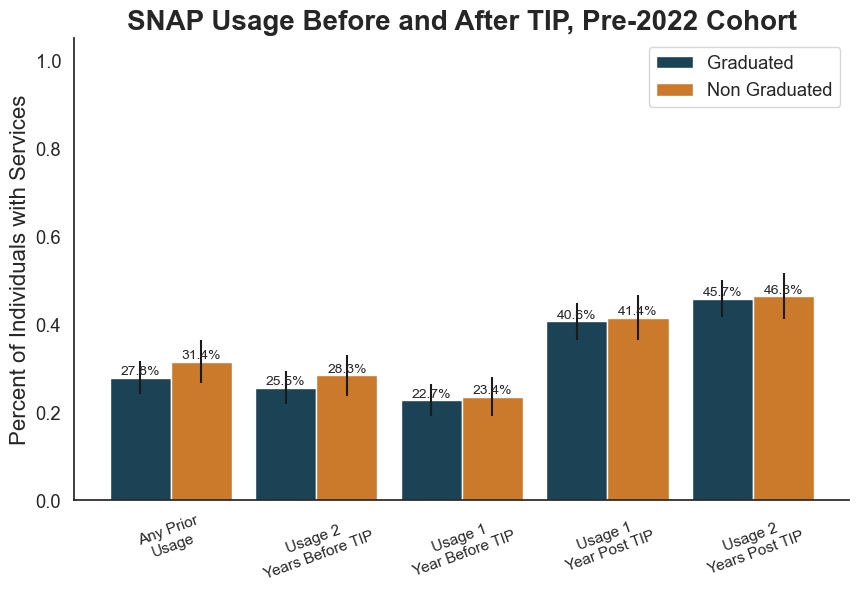

In [334]:
#SNAP - Cohort 1

# keep only Graduated / Non Graduated
svc_c1 = df_services.copy()
svc_c1 = svc_c1[
    (svc_c1["cohort_2022"] == 1) &
    (svc_c1["snap"] == 1) &
    (svc_c1["Status"].isin(["Graduated","Non Graduated"]))
].copy()

# -----------------------------
#pre-TIP

pre_bins = {
    -1: [-1],             # 1 year pre
    -2: [ -2, -1],     # 1-3 years pre
    -30: list(range(-30, 0))  # any prior usage
}

svc_c1["YearsSinceTIP_int"] = svc_c1["YearsSinceTIP"].round().astype(int)

rows = []
for bin_edge, years in pre_bins.items():
    cur = svc_c1[svc_c1["YearsSinceTIP_int"].isin(years)]
    
    row = {"YearsSinceTIP": bin_edge}
    for status in ["Graduated", "Non Graduated"]:
        num = cur.loc[cur["Status"] == status, "tip_id"].nunique()
        row[status] = num
        
    rows.append(row)

pre_count = pd.DataFrame(rows)

# denominators for pre: total people per status

denom_pre = (
    df_student[(df_student["Status"].isin(["Graduated", "Non Graduated"])) & (df_student["cohort_2022"] == 1)]
    .groupby("Status")["tip_id"]
    .nunique()
    .to_dict()
)

z = 1.96
for status in ["Graduated", "Non Graduated"]:
    pre_count[f"{status} Percent"] = pre_count[status] / denom_pre.get(status, np.nan)
    p = pre_count[f"{status} Percent"]
    n = denom_pre.get(status, np.nan)
    se = np.sqrt(p * (1 - p) / n)
    pre_count[f"{status}_Upper_CI"] = (p + z * se).clip(0, 1)
    pre_count[f"{status}_Lower_CI"] = (p - z * se).clip(0, 1)

# -----------------------------
#post-TIP

post_points = [1, 2]
rows = []

for i in post_points:
    cur = svc_c1[(svc_c1["YearsSinceTIP"] >= 0) & (svc_c1["YearsSinceTIP"] < i+1) & (svc_c1["ValidYears"] >= i)]

    row = {"YearsSinceTIP": i}
    for status in ["Graduated", "Non Graduated"]:
        num = cur.loc[cur["Status"] == status, "tip_id"].nunique()
        denom = df_student.loc[(df_student["Status"] == status) & (df_student["ValidYears"] >= i) & (df_student["cohort_2022"] == 1), "tip_id"].nunique()

        p = (num / denom) if denom > 0 else 0
        se = np.sqrt(p * (1 - p) / denom) if denom > 0 else np.nan

        row[f"{status}"] = num
        row[f"{status} Percent"] = p
        row[f"{status}_Upper_CI"] = min(1, p + z * se) if denom > 0 else np.nan
        row[f"{status}_Lower_CI"] = max(0, p - z * se) if denom > 0 else np.nan

    rows.append(row)

post_df = pd.DataFrame(rows)

# -----------------------------
#combine and plot

label_map = {
    -30: "Any Prior\nUsage",
    -2:  "Usage 2\nYears Before TIP",
    -1:  "Usage 1\nYear Before TIP",
     1:  "Usage 1\nYear Post TIP",
     2:  "Usage 2\nYears Post TIP"
}
order = [-30, -2, -1, 1, 2]

pre_keep = pre_count[pre_count["YearsSinceTIP"].isin([-30, -2, -1])].copy()
data = pd.concat([pre_keep, post_df], ignore_index=True)
snap_pre2022 = data.copy()

data["YearsSinceTIP"] = data["YearsSinceTIP"].astype(int)
data["YearsSinceTIP"] = pd.Categorical(data["YearsSinceTIP"], categories=order, ordered=True)
data = data.sort_values("YearsSinceTIP").reset_index(drop=True)
data["label"] = data["YearsSinceTIP"].astype(int).map(label_map)

grad_err = np.abs(
    data[["Graduated_Upper_CI", "Graduated_Lower_CI"]].T.values - data["Graduated Percent"].values
)
non_grad_err = np.abs(
    data[["Non Graduated_Upper_CI", "Non Graduated_Lower_CI"]].T.values - data["Non Graduated Percent"].values
)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(data))
width = 0.42

ax.bar(x - width/2, data["Graduated Percent"], width=width, label="Graduated", yerr=grad_err, capsize=0)
ax.bar(x + width/2, data["Non Graduated Percent"], width=width, label="Non Graduated", yerr=non_grad_err, capsize=0)

ax.set_xticks(x)
ax.set_xticklabels(data["label"], rotation=20, ha="center", fontsize=11)

for xi, yi in zip(x - width/2, data["Graduated Percent"]):
    ax.text(xi, yi, f"{yi:.1%}", ha="center", va="bottom", fontsize=10)
for xi, yi in zip(x + width/2, data["Non Graduated Percent"]):
    ax.text(xi, yi, f"{yi:.1%}", ha="center", va="bottom", fontsize=10)

sns.despine()
plt.title("SNAP Usage Before and After TIP, Pre-2022 Cohort", fontdict={"fontsize": 20, "fontweight": "semibold"})
plt.ylabel("Percent of Individuals with Services", fontdict={"fontsize": 16})
plt.ylim(0, 1.05)
plt.legend(loc="upper right")
plt.show()


C:\Users\sarah\AppData\Local\Temp\ipykernel_10680\2479932828.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Status")["tip_id"]


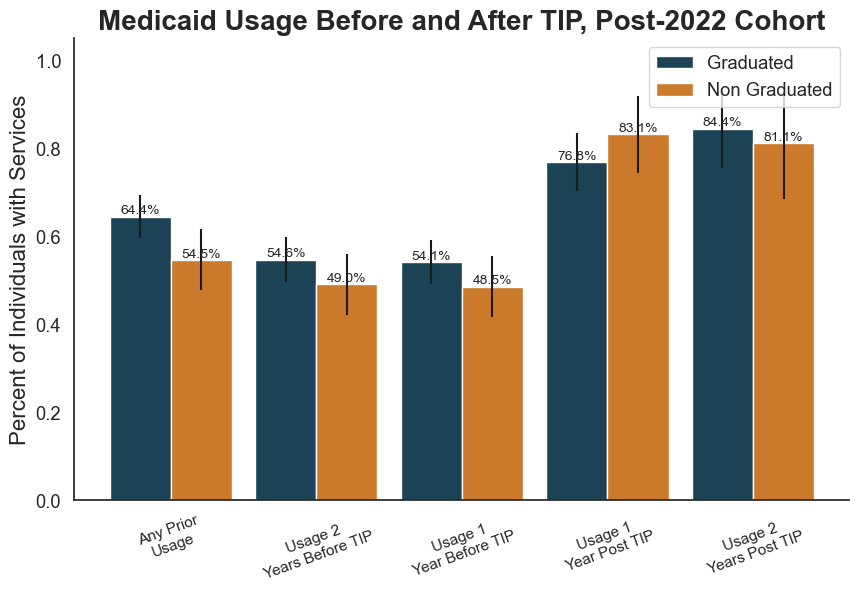

In [335]:
#Medicaid - Cohort 2

# keep only Graduated / Non Graduated
svc_c1 = df_services.copy()
svc_c1 = svc_c1[
    (svc_c1["cohort_2022"] == 2) &
    (svc_c1["medicaid"] == 1) &
    (svc_c1["Status"].isin(["Graduated","Non Graduated"]))
].copy()

# -----------------------------
#pre-TIP

pre_bins = {
    -1: [-1],             # 1 year pre
    -2: [-2, -1],     # 1-3 years pre
    -30: list(range(-30, 0))  # any prior usage
}

svc_c1["YearsSinceTIP_int"] = svc_c1["YearsSinceTIP"].round().astype(int)

rows = []
for bin_edge, years in pre_bins.items():
    cur = svc_c1[svc_c1["YearsSinceTIP_int"].isin(years)]
    
    row = {"YearsSinceTIP": bin_edge}
    for status in ["Graduated", "Non Graduated"]:
        num = cur.loc[cur["Status"] == status, "tip_id"].nunique()
        row[status] = num
        
    rows.append(row)

pre_count = pd.DataFrame(rows)

# denominators for pre: total people per status

denom_pre = (
    df_student[(df_student["Status"].isin(["Graduated", "Non Graduated"])) & (df_student["cohort_2022"] == 2)]
    .groupby("Status")["tip_id"]
    .nunique()
    .to_dict()
)

z = 1.96
for status in ["Graduated", "Non Graduated"]:
    pre_count[f"{status} Percent"] = pre_count[status] / denom_pre.get(status, np.nan)
    p = pre_count[f"{status} Percent"]
    n = denom_pre.get(status, np.nan)
    se = np.sqrt(p * (1 - p) / n)
    pre_count[f"{status}_Upper_CI"] = (p + z * se).clip(0, 1)
    pre_count[f"{status}_Lower_CI"] = (p - z * se).clip(0, 1)

# -----------------------------
#post-TIP

post_points = [1, 2]
rows = []

for i in post_points:
    cur = svc_c1[(svc_c1["YearsSinceTIP"] >= 0) & (svc_c1["YearsSinceTIP"] < i+1) & (svc_c1["ValidYears"] >= i)]

    row = {"YearsSinceTIP": i}
    for status in ["Graduated", "Non Graduated"]:
        num = cur.loc[cur["Status"] == status, "tip_id"].nunique()
        denom = df_student.loc[(df_student["Status"] == status) & (df_student["ValidYears"] >= i) & (df_student["cohort_2022"] == 2), "tip_id"].nunique()

        p = (num / denom) if denom > 0 else 0
        se = np.sqrt(p * (1 - p) / denom) if denom > 0 else np.nan

        row[f"{status}"] = num
        row[f"{status} Percent"] = p
        row[f"{status}_Upper_CI"] = min(1, p + z * se) if denom > 0 else np.nan
        row[f"{status}_Lower_CI"] = max(0, p - z * se) if denom > 0 else np.nan

    rows.append(row)

post_df = pd.DataFrame(rows)

# -----------------------------
#combine and plot

label_map = {
    -30: "Any Prior\nUsage",
    -2:  "Usage 2\nYears Before TIP",
    -1:  "Usage 1\nYear Before TIP",
     1:  "Usage 1\nYear Post TIP",
     2:  "Usage 2\nYears Post TIP"
}
order = [-30, -2, -1, 1, 2]

pre_keep = pre_count[pre_count["YearsSinceTIP"].isin([-30, -2, -1])].copy()
data = pd.concat([pre_keep, post_df], ignore_index=True)
medicaid_post2022 = data.copy()

data["YearsSinceTIP"] = data["YearsSinceTIP"].astype(int)
data["YearsSinceTIP"] = pd.Categorical(data["YearsSinceTIP"], categories=order, ordered=True)
data = data.sort_values("YearsSinceTIP").reset_index(drop=True)
data["label"] = data["YearsSinceTIP"].astype(int).map(label_map)

grad_err = np.abs(
    data[["Graduated_Upper_CI", "Graduated_Lower_CI"]].T.values - data["Graduated Percent"].values
)
non_grad_err = np.abs(
    data[["Non Graduated_Upper_CI", "Non Graduated_Lower_CI"]].T.values - data["Non Graduated Percent"].values
)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(data))
width = 0.42

ax.bar(x - width/2, data["Graduated Percent"], width=width, label="Graduated", yerr=grad_err, capsize=0)
ax.bar(x + width/2, data["Non Graduated Percent"], width=width, label="Non Graduated", yerr=non_grad_err, capsize=0)

ax.set_xticks(x)
ax.set_xticklabels(data["label"], rotation=20, ha="center", fontsize=11)

for xi, yi in zip(x - width/2, data["Graduated Percent"]):
    ax.text(xi, yi, f"{yi:.1%}", ha="center", va="bottom", fontsize=10)
for xi, yi in zip(x + width/2, data["Non Graduated Percent"]):
    ax.text(xi, yi, f"{yi:.1%}", ha="center", va="bottom", fontsize=10)

sns.despine()
plt.title("Medicaid Usage Before and After TIP, Post-2022 Cohort", fontdict={"fontsize": 20, "fontweight": "semibold"})
plt.ylabel("Percent of Individuals with Services", fontdict={"fontsize": 16})
plt.ylim(0, 1.05)
plt.legend(loc="upper right")
plt.show()


C:\Users\sarah\AppData\Local\Temp\ipykernel_10680\131510053.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Status")["tip_id"]


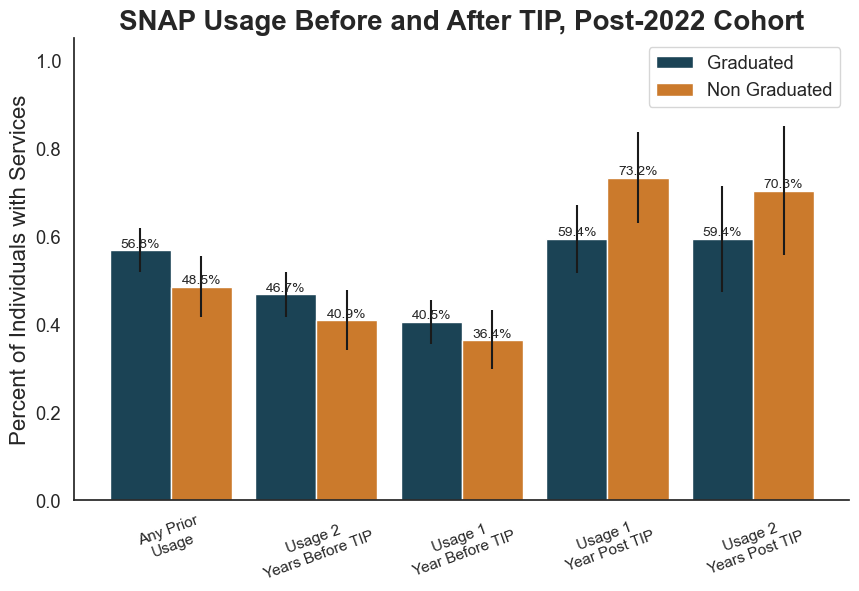

In [336]:
#SNAP - Cohort 2

# keep only Graduated / Non Graduated
svc_c1 = df_services.copy()
svc_c1 = svc_c1[
    (svc_c1["cohort_2022"] == 2) &
    (svc_c1["snap"] == 1) &
    (svc_c1["Status"].isin(["Graduated","Non Graduated"]))
].copy()

# -----------------------------
#pre-TIP

pre_bins = {
    -1: [-1],             # 1 year pre
    -2: [-2, -1],     # 1-3 years pre
    -30: list(range(-30, 0))  # any prior usage
}

svc_c1["YearsSinceTIP_int"] = svc_c1["YearsSinceTIP"].round().astype(int)

rows = []
for bin_edge, years in pre_bins.items():
    cur = svc_c1[svc_c1["YearsSinceTIP_int"].isin(years)]
    
    row = {"YearsSinceTIP": bin_edge}
    for status in ["Graduated", "Non Graduated"]:
        num = cur.loc[cur["Status"] == status, "tip_id"].nunique()
        row[status] = num
        
    rows.append(row)

pre_count = pd.DataFrame(rows)

# denominators for pre: total people per status

denom_pre = (
    df_student[(df_student["Status"].isin(["Graduated", "Non Graduated"])) & (df_student["cohort_2022"] == 2)]
    .groupby("Status")["tip_id"]
    .nunique()
    .to_dict()
)

z = 1.96
for status in ["Graduated", "Non Graduated"]:
    pre_count[f"{status} Percent"] = pre_count[status] / denom_pre.get(status, np.nan)
    p = pre_count[f"{status} Percent"]
    n = denom_pre.get(status, np.nan)
    se = np.sqrt(p * (1 - p) / n)
    pre_count[f"{status}_Upper_CI"] = (p + z * se).clip(0, 1)
    pre_count[f"{status}_Lower_CI"] = (p - z * se).clip(0, 1)

# -----------------------------
#post-TIP

post_points = [1, 2]
rows = []

for i in post_points:
    cur = svc_c1[(svc_c1["YearsSinceTIP"] >= 0) & (svc_c1["YearsSinceTIP"] < i+1) & (svc_c1["ValidYears"] >= i)]

    row = {"YearsSinceTIP": i}
    for status in ["Graduated", "Non Graduated"]:
        num = cur.loc[cur["Status"] == status, "tip_id"].nunique()
        denom = df_student.loc[(df_student["Status"] == status) & (df_student["ValidYears"] >= i) & (df_student["cohort_2022"] == 2), "tip_id"].nunique()

        p = (num / denom) if denom > 0 else 0
        se = np.sqrt(p * (1 - p) / denom) if denom > 0 else np.nan

        row[f"{status}"] = num
        row[f"{status} Percent"] = p
        row[f"{status}_Upper_CI"] = min(1, p + z * se) if denom > 0 else np.nan
        row[f"{status}_Lower_CI"] = max(0, p - z * se) if denom > 0 else np.nan

    rows.append(row)

post_df = pd.DataFrame(rows)

# -----------------------------
#combine and plot

label_map = {
    -30: "Any Prior\nUsage",
    -2:  "Usage 2\nYears Before TIP",
    -1:  "Usage 1\nYear Before TIP",
     1:  "Usage 1\nYear Post TIP",
     2:  "Usage 2\nYears Post TIP"
}
order = [-30, -2, -1, 1, 2]

pre_keep = pre_count[pre_count["YearsSinceTIP"].isin([-30, -2, -1])].copy()
data = pd.concat([pre_keep, post_df], ignore_index=True)
snap_post2022 = data.copy()

data["YearsSinceTIP"] = data["YearsSinceTIP"].astype(int)
data["YearsSinceTIP"] = pd.Categorical(data["YearsSinceTIP"], categories=order, ordered=True)
data = data.sort_values("YearsSinceTIP").reset_index(drop=True)
data["label"] = data["YearsSinceTIP"].astype(int).map(label_map)

grad_err = np.abs(
    data[["Graduated_Upper_CI", "Graduated_Lower_CI"]].T.values - data["Graduated Percent"].values
)
non_grad_err = np.abs(
    data[["Non Graduated_Upper_CI", "Non Graduated_Lower_CI"]].T.values - data["Non Graduated Percent"].values
)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(data))
width = 0.42

ax.bar(x - width/2, data["Graduated Percent"], width=width, label="Graduated", yerr=grad_err, capsize=0)
ax.bar(x + width/2, data["Non Graduated Percent"], width=width, label="Non Graduated", yerr=non_grad_err, capsize=0)

ax.set_xticks(x)
ax.set_xticklabels(data["label"], rotation=20, ha="center", fontsize=11)

for xi, yi in zip(x - width/2, data["Graduated Percent"]):
    ax.text(xi, yi, f"{yi:.1%}", ha="center", va="bottom", fontsize=10)
for xi, yi in zip(x + width/2, data["Non Graduated Percent"]):
    ax.text(xi, yi, f"{yi:.1%}", ha="center", va="bottom", fontsize=10)

sns.despine()
plt.title("SNAP Usage Before and After TIP, Post-2022 Cohort", fontdict={"fontsize": 20, "fontweight": "semibold"})
plt.ylabel("Percent of Individuals with Services", fontdict={"fontsize": 16})
plt.ylim(0, 1.05)
plt.legend(loc="upper right")
plt.show()


C:\Users\sarah\AppData\Local\Temp\ipykernel_10680\3798574219.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Status")["tip_id"]


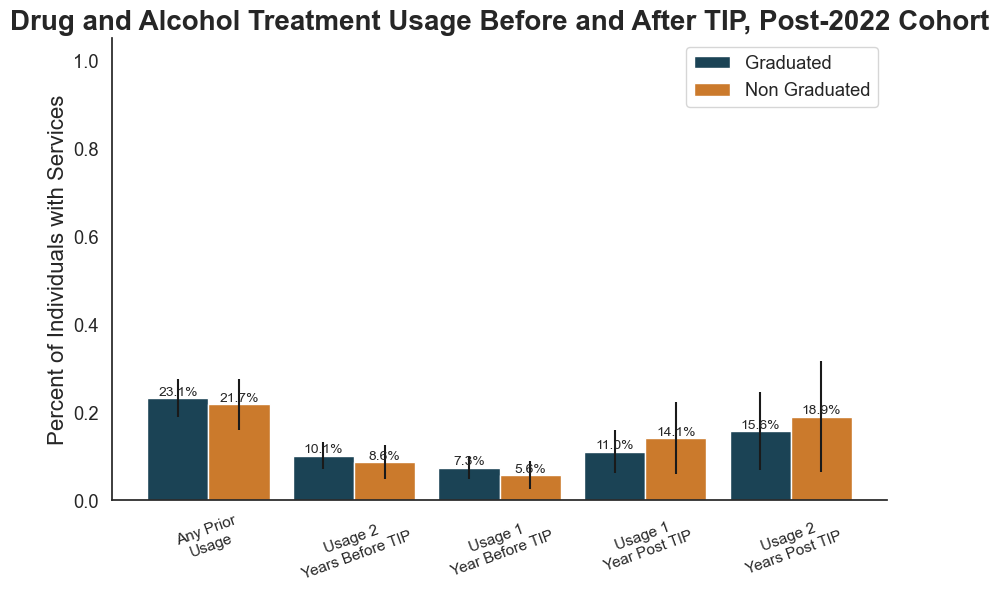

In [337]:
#Drug Alcohol - Cohort 2

# keep only Graduated / Non Graduated
svc_c1 = df_services.copy()
svc_c1 = svc_c1[
    (svc_c1["cohort_2022"] == 2) &
    (svc_c1["drug_alcohol"] == 1) &
    (svc_c1["Status"].isin(["Graduated","Non Graduated"]))
].copy()

# -----------------------------
# pre-TIP

pre_bins = {
    -1: [-1],             # 1 year pre
    -2: [-2, -1],     # 1-3 years pre
    -30: list(range(-30, 0))  # any prior usage
}

svc_c1["YearsSinceTIP_int"] = svc_c1["YearsSinceTIP"].round().astype(int)

rows = []
for bin_edge, years in pre_bins.items():
    cur = svc_c1[svc_c1["YearsSinceTIP_int"].isin(years)]
    
    row = {"YearsSinceTIP": bin_edge}
    for status in ["Graduated", "Non Graduated"]:
        num = cur.loc[cur["Status"] == status, "tip_id"].nunique()
        row[status] = num
        
    rows.append(row)

pre_count = pd.DataFrame(rows)

# denominators for pre: total people per status

denom_pre = (
    df_student[(df_student["Status"].isin(["Graduated", "Non Graduated"])) & (df_student["cohort_2022"] == 2)]
    .groupby("Status")["tip_id"]
    .nunique()
    .to_dict()
)

z = 1.96
for status in ["Graduated", "Non Graduated"]:
    pre_count[f"{status} Percent"] = pre_count[status] / denom_pre.get(status, np.nan)
    p = pre_count[f"{status} Percent"]
    n = denom_pre.get(status, np.nan)
    se = np.sqrt(p * (1 - p) / n)
    pre_count[f"{status}_Upper_CI"] = (p + z * se).clip(0, 1)
    pre_count[f"{status}_Lower_CI"] = (p - z * se).clip(0, 1)

# -----------------------------
#post-TIP

post_points = [1, 2]
rows = []

for i in post_points:
    cur = svc_c1[(svc_c1["YearsSinceTIP"] >= 0) & (svc_c1["YearsSinceTIP"] < i+1) & (svc_c1["ValidYears"] >= i)]

    row = {"YearsSinceTIP": i}
    for status in ["Graduated", "Non Graduated"]:
        num = cur.loc[cur["Status"] == status, "tip_id"].nunique()
        denom = df_student.loc[(df_student["Status"] == status) & (df_student["ValidYears"] >= i) & (df_student["cohort_2022"] == 2), "tip_id"].nunique()

        p = (num / denom) if denom > 0 else 0
        se = np.sqrt(p * (1 - p) / denom) if denom > 0 else np.nan

        row[f"{status}"] = num
        row[f"{status} Percent"] = p
        row[f"{status}_Upper_CI"] = min(1, p + z * se) if denom > 0 else np.nan
        row[f"{status}_Lower_CI"] = max(0, p - z * se) if denom > 0 else np.nan

    rows.append(row)

post_df = pd.DataFrame(rows)

# -----------------------------
#combine and plot

label_map = {
    -30: "Any Prior\nUsage",
    -2:  "Usage 2\nYears Before TIP",
    -1:  "Usage 1\nYear Before TIP",
     1:  "Usage 1\nYear Post TIP",
     2:  "Usage 2\nYears Post TIP"
}
order = [-30, -2, -1, 1, 2]

pre_keep = pre_count[pre_count["YearsSinceTIP"].isin([-30, -2, -1])].copy()
data = pd.concat([pre_keep, post_df], ignore_index=True)
drug_post2022 = data.copy()

data["YearsSinceTIP"] = data["YearsSinceTIP"].astype(int)
data["YearsSinceTIP"] = pd.Categorical(data["YearsSinceTIP"], categories=order, ordered=True)
data = data.sort_values("YearsSinceTIP").reset_index(drop=True)
data["label"] = data["YearsSinceTIP"].astype(int).map(label_map)

grad_err = np.abs(
    data[["Graduated_Upper_CI", "Graduated_Lower_CI"]].T.values - data["Graduated Percent"].values
)
non_grad_err = np.abs(
    data[["Non Graduated_Upper_CI", "Non Graduated_Lower_CI"]].T.values - data["Non Graduated Percent"].values
)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(data))
width = 0.42

ax.bar(x - width/2, data["Graduated Percent"], width=width, label="Graduated", yerr=grad_err, capsize=0)
ax.bar(x + width/2, data["Non Graduated Percent"], width=width, label="Non Graduated", yerr=non_grad_err, capsize=0)

ax.set_xticks(x)
ax.set_xticklabels(data["label"], rotation=20, ha="center", fontsize=11)

for xi, yi in zip(x - width/2, data["Graduated Percent"]):
    ax.text(xi, yi, f"{yi:.1%}", ha="center", va="bottom", fontsize=10)
for xi, yi in zip(x + width/2, data["Non Graduated Percent"]):
    ax.text(xi, yi, f"{yi:.1%}", ha="center", va="bottom", fontsize=10)

sns.despine()
plt.title("Drug and Alcohol Treatment Usage Before and After TIP, Post-2022 Cohort", fontdict={"fontsize": 20, "fontweight": "semibold"})
plt.ylabel("Percent of Individuals with Services", fontdict={"fontsize": 16})
plt.ylim(0, 1.05)
plt.legend(loc="upper right")
plt.show()


C:\Users\sarah\AppData\Local\Temp\ipykernel_10680\2593936234.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Status")["tip_id"]


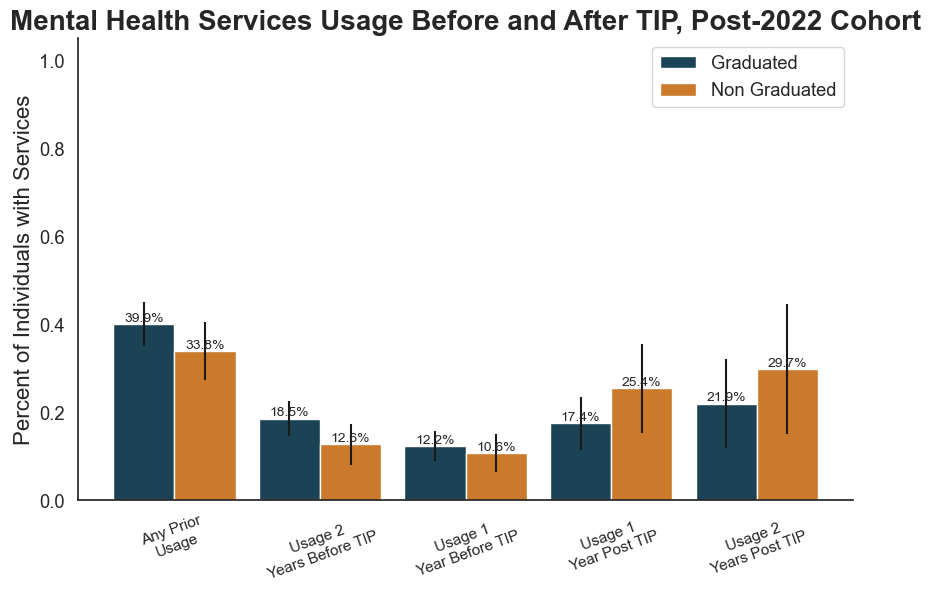

In [338]:
#Mental Health - Cohort 2

# keep only Graduated / Non Graduated
svc_c1 = df_services.copy()
svc_c1 = svc_c1[
    (svc_c1["cohort_2022"] == 2) &
    (svc_c1["mental_health"] == 1) &
    (svc_c1["Status"].isin(["Graduated","Non Graduated"]))
].copy()

# -----------------------------
#pre-TIP

pre_bins = {
    -1: [-1],             # 1 year pre
    -2: [-2, -1],     # 1-3 years pre
    -30: list(range(-30, 0))  # any prior usage
}

svc_c1["YearsSinceTIP_int"] = svc_c1["YearsSinceTIP"].round().astype(int)

rows = []
for bin_edge, years in pre_bins.items():
    cur = svc_c1[svc_c1["YearsSinceTIP_int"].isin(years)]
    
    row = {"YearsSinceTIP": bin_edge}
    for status in ["Graduated", "Non Graduated"]:
        num = cur.loc[cur["Status"] == status, "tip_id"].nunique()
        row[status] = num
        
    rows.append(row)

pre_count = pd.DataFrame(rows)

# denominators for pre: total people per status

denom_pre = (
    df_student[(df_student["Status"].isin(["Graduated", "Non Graduated"])) & (df_student["cohort_2022"] == 2)]
    .groupby("Status")["tip_id"]
    .nunique()
    .to_dict()
)

z = 1.96
for status in ["Graduated", "Non Graduated"]:
    pre_count[f"{status} Percent"] = pre_count[status] / denom_pre.get(status, np.nan)
    p = pre_count[f"{status} Percent"]
    n = denom_pre.get(status, np.nan)
    se = np.sqrt(p * (1 - p) / n)
    pre_count[f"{status}_Upper_CI"] = (p + z * se).clip(0, 1)
    pre_count[f"{status}_Lower_CI"] = (p - z * se).clip(0, 1)

# -----------------------------
#post-TIP

post_points = [1, 2]
rows = []

for i in post_points:
    cur = svc_c1[(svc_c1["YearsSinceTIP"] >= 0) & (svc_c1["YearsSinceTIP"] < i+1) & (svc_c1["ValidYears"] >= i)]

    row = {"YearsSinceTIP": i}
    for status in ["Graduated", "Non Graduated"]:
        num = cur.loc[cur["Status"] == status, "tip_id"].nunique()
        denom = df_student.loc[(df_student["Status"] == status) & (df_student["ValidYears"] >= i) & (df_student["cohort_2022"] == 2), "tip_id"].nunique()

        p = (num / denom) if denom > 0 else 0
        se = np.sqrt(p * (1 - p) / denom) if denom > 0 else np.nan

        row[f"{status}"] = num
        row[f"{status} Percent"] = p
        row[f"{status}_Upper_CI"] = min(1, p + z * se) if denom > 0 else np.nan
        row[f"{status}_Lower_CI"] = max(0, p - z * se) if denom > 0 else np.nan

    rows.append(row)

post_df = pd.DataFrame(rows)

# -----------------------------
#combine and plot

label_map = {
    -30: "Any Prior\nUsage",
    -2:  "Usage 2\nYears Before TIP",
    -1:  "Usage 1\nYear Before TIP",
     1:  "Usage 1\nYear Post TIP",
     2:  "Usage 2\nYears Post TIP"
}
order = [-30, -2, -1, 1, 2]

pre_keep = pre_count[pre_count["YearsSinceTIP"].isin([-30, -2, -1])].copy()
data = pd.concat([pre_keep, post_df], ignore_index=True)
mental_post2022 = data.copy()

data["YearsSinceTIP"] = data["YearsSinceTIP"].astype(int)
data["YearsSinceTIP"] = pd.Categorical(data["YearsSinceTIP"], categories=order, ordered=True)
data = data.sort_values("YearsSinceTIP").reset_index(drop=True)
data["label"] = data["YearsSinceTIP"].astype(int).map(label_map)

grad_err = np.abs(
    data[["Graduated_Upper_CI", "Graduated_Lower_CI"]].T.values - data["Graduated Percent"].values
)
non_grad_err = np.abs(
    data[["Non Graduated_Upper_CI", "Non Graduated_Lower_CI"]].T.values - data["Non Graduated Percent"].values
)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(data))
width = 0.42

ax.bar(x - width/2, data["Graduated Percent"], width=width, label="Graduated", yerr=grad_err, capsize=0)
ax.bar(x + width/2, data["Non Graduated Percent"], width=width, label="Non Graduated", yerr=non_grad_err, capsize=0)

ax.set_xticks(x)
ax.set_xticklabels(data["label"], rotation=20, ha="center", fontsize=11)

for xi, yi in zip(x - width/2, data["Graduated Percent"]):
    ax.text(xi, yi, f"{yi:.1%}", ha="center", va="bottom", fontsize=10)
for xi, yi in zip(x + width/2, data["Non Graduated Percent"]):
    ax.text(xi, yi, f"{yi:.1%}", ha="center", va="bottom", fontsize=10)

sns.despine()
plt.title("Mental Health Services Usage Before and After TIP, Post-2022 Cohort", fontdict={"fontsize": 20, "fontweight": "semibold"})
plt.ylabel("Percent of Individuals with Services", fontdict={"fontsize": 16})
plt.ylim(0, 1.05)
plt.legend(loc="upper right")
plt.show()


In [339]:
#Significance testing for differences within the same bar across different cohorts - Medicaid
#E.G. - This will test whether graduated proportion in YearsSinceTIP of -3 in the pre-2022 cohort is significantly different than
#the graduated proportion in YearsSinceTIP of -3 in the post-2022 cohort

from scipy.stats import norm


for df in [medicaid_pre2022, medicaid_post2022]:
    df["Graduated_denom"] = df["Graduated"] / df["Graduated Percent"]
    df["Non Graduated_denom"] = df["Non Graduated"] / df["Non Graduated Percent"]


statuses = ["Graduated", "Non Graduated"]
years = [-30, -2, -1, 1, 2]

ztest_rows = []

for year in years:
    pre_row = medicaid_pre2022[medicaid_pre2022["YearsSinceTIP"] == year].iloc[0]
    post_row = medicaid_post2022[medicaid_post2022["YearsSinceTIP"] == year].iloc[0]
    
    for status in statuses:
        p1 = float(pre_row[f"{status} Percent"])
        n1 = float(pre_row[f"{status}_denom"])
        p2 = float(post_row[f"{status} Percent"])
        n2 = float(post_row[f"{status}_denom"])
        
        # z-score formula for difference in proportions
        pooled_se = ((p1 * (1 - p1) / n1) + (p2 * (1 - p2) / n2)) ** 0.5
        z = (p1 - p2) / pooled_se if pooled_se > 0 else 0
        p_val = 2 * (1 - norm.cdf(abs(z)))  # two-tailed
        
        ztest_rows.append({
            "YearsSinceTIP": year,
            "Status": status,
            "Pre Percent": p1,
            "Post Percent": p2,
            "Pre N": n1,
            "Post N": n2,
            "z_score": z,
            "p_value": p_val
        })

ztest_df = pd.DataFrame(ztest_rows)
ztest_df

,YearsSinceTIP,Status,Pre Percent,Post Percent,Pre N,Post N,z_score,p_value
0,-30,Graduated,0.645714,0.644022,525.0,368.0,0.052017,0.958515
1,-30,Non Graduated,0.705714,0.545455,350.0,198.0,3.730435,0.000191
2,-2,Graduated,0.537143,0.546196,525.0,368.0,-0.267288,0.789247
3,-2,Non Graduated,0.554286,0.489899,350.0,198.0,1.451397,0.146669
4,-1,Graduated,0.500952,0.540761,525.0,368.0,-1.173367,0.240649
5,-1,Non Graduated,0.517143,0.484848,350.0,198.0,0.726696,0.467412
6,1,Graduated,0.640000,0.767742,525.0,155.0,-3.204309,0.001354
7,1,Non Graduated,0.637143,0.830986,350.0,71.0,-3.773599,0.000161
8,2,Graduated,0.680000,0.843750,525.0,64.0,-3.291889,0.000995
9,2,Non Graduated,0.685714,0.810811,350.0,37.0,-1.812879,0.069850


In [340]:
#Significance testing for differences within the same bar across different cohorts - Mental health
#E.G. - This will test whether graduated proportion in YearsSinceTIP of -3 in the pre-2022 cohort is significantly different than
#the graduated proportion in YearsSinceTIP of -3 in the post-2022 cohort

for df in [mental_pre2022, mental_post2022]:
    df["Graduated_denom"] = df["Graduated"] / df["Graduated Percent"]
    df["Non Graduated_denom"] = df["Non Graduated"] / df["Non Graduated Percent"]

statuses = ["Graduated", "Non Graduated"]
years = [-30, -2, -1, 1, 2]

ztest_rows = []

for year in years:
    pre_row = mental_pre2022[mental_pre2022["YearsSinceTIP"] == year].iloc[0]
    post_row = mental_post2022[mental_post2022["YearsSinceTIP"] == year].iloc[0]
    
    for status in statuses:
        p1 = float(pre_row[f"{status} Percent"])
        n1 = float(pre_row[f"{status}_denom"])
        p2 = float(post_row[f"{status} Percent"])
        n2 = float(post_row[f"{status}_denom"])
        
        # z-score formula for difference in proportions
        pooled_se = ((p1 * (1 - p1) / n1) + (p2 * (1 - p2) / n2)) ** 0.5
        z = (p1 - p2) / pooled_se if pooled_se > 0 else 0
        p_val = 2 * (1 - norm.cdf(abs(z)))  # two-tailed
        
        ztest_rows.append({
            "YearsSinceTIP": year,
            "Status": status,
            "Pre Percent": p1,
            "Post Percent": p2,
            "Pre N": n1,
            "Post N": n2,
            "z_score": z,
            "p_value": p_val
        })

ztest_df = pd.DataFrame(ztest_rows)
ztest_df

,YearsSinceTIP,Status,Pre Percent,Post Percent,Pre N,Post N,z_score,p_value
0,-30,Graduated,0.417143,0.399457,525.0,368.0,0.529666,0.596344
1,-30,Non Graduated,0.417143,0.338384,350.0,198.0,1.843418,0.065268
2,-2,Graduated,0.270476,0.184783,525.0,368.0,3.058169,0.002227
3,-2,Non Graduated,0.251429,0.126263,350.0,198.0,3.782635,0.000155
4,-1,Graduated,0.207619,0.122283,525.0,368.0,3.469376,0.000522
5,-1,Non Graduated,0.197143,0.106061,350.0,198.0,2.984990,0.002836
6,1,Graduated,0.272381,0.174194,525.0,155.0,2.717414,0.006579
7,1,Non Graduated,0.280000,0.253521,350.0,71.0,0.465081,0.641873
8,2,Graduated,0.314286,0.218750,525.0,64.0,1.721215,0.085212
9,2,Non Graduated,0.311429,0.297297,350.0,37.0,0.178620,0.858236


In [342]:
#Significance testing for differences within the same bar across different cohorts - Drug and Alcohol Use
#E.G. - This will test whether graduated proportion in YearsSinceTIP of -3 in the pre-2022 cohort is significantly different than
#the graduated proportion in YearsSinceTIP of -3 in the post-2022 cohort

for df in [drug_pre2022, drug_post2022]:
    df["Graduated_denom"] = df["Graduated"] / df["Graduated Percent"]
    df["Non Graduated_denom"] = df["Non Graduated"] / df["Non Graduated Percent"]

statuses = ["Graduated", "Non Graduated"]
years = [-30, -2, -1, 1, 2]

ztest_rows = []

for year in years:
    pre_row = drug_pre2022[drug_pre2022["YearsSinceTIP"] == year].iloc[0]
    post_row = drug_post2022[drug_post2022["YearsSinceTIP"] == year].iloc[0]
    
    for status in statuses:
        p1 = float(pre_row[f"{status} Percent"])
        n1 = float(pre_row[f"{status}_denom"])
        p2 = float(post_row[f"{status} Percent"])
        n2 = float(post_row[f"{status}_denom"])
        
        # z-score formula for difference in proportions
        pooled_se = ((p1 * (1 - p1) / n1) + (p2 * (1 - p2) / n2)) ** 0.5
        z = (p1 - p2) / pooled_se if pooled_se > 0 else 0
        p_val = 2 * (1 - norm.cdf(abs(z)))  # two-tailed
        
        ztest_rows.append({
            "YearsSinceTIP": year,
            "Status": status,
            "Pre Percent": p1,
            "Post Percent": p2,
            "Pre N": n1,
            "Post N": n2,
            "z_score": z,
            "p_value": p_val
        })

ztest_df = pd.DataFrame(ztest_rows)
ztest_df

,YearsSinceTIP,Status,Pre Percent,Post Percent,Pre N,Post N,z_score,p_value
0,-30,Graduated,0.280000,0.230978,525.0,368.0,1.665170,0.095879
1,-30,Non Graduated,0.282857,0.217172,350.0,198.0,1.732048,0.083265
2,-2,Graduated,0.179048,0.100543,525.0,368.0,3.423835,0.000617
3,-2,Non Graduated,0.142857,0.085859,350.0,198.0,2.086512,0.036932
4,-1,Graduated,0.156190,0.073370,525.0,368.0,3.967385,0.000073
5,-1,Non Graduated,0.111429,0.055556,350.0,198.0,2.387021,0.016986
6,1,Graduated,0.160000,0.109677,525.0,155.0,1.690631,0.090907
7,1,Non Graduated,0.168571,0.140845,350.0,71.0,0.604352,0.545610
8,2,Graduated,0.194286,0.156250,525.0,64.0,0.783267,0.433470
9,2,Non Graduated,0.202857,0.189189,350.0,37.0,0.201351,0.840424


In [343]:
#Significance testing for differences within the same bar across different cohorts - SNAP
#E.G. - This will test whether graduated proportion in YearsSinceTIP of -3 in the pre-2022 cohort is significantly different than
#the graduated proportion in YearsSinceTIP of -3 in the post-2022 cohort

for df in [snap_pre2022, snap_post2022]:
    df["Graduated_denom"] = df["Graduated"] / df["Graduated Percent"]
    df["Non Graduated_denom"] = df["Non Graduated"] / df["Non Graduated Percent"]

statuses = ["Graduated", "Non Graduated"]
years = [-30, -2, -1, 1, 2]

ztest_rows = []

for year in years:
    pre_row = snap_pre2022[snap_pre2022["YearsSinceTIP"] == year].iloc[0]
    post_row = snap_post2022[snap_post2022["YearsSinceTIP"] == year].iloc[0]
    
    for status in statuses:
        p1 = float(pre_row[f"{status} Percent"])
        n1 = float(pre_row[f"{status}_denom"])
        p2 = float(post_row[f"{status} Percent"])
        n2 = float(post_row[f"{status}_denom"])
        
        # z-score formula for difference in proportions
        pooled_se = ((p1 * (1 - p1) / n1) + (p2 * (1 - p2) / n2)) ** 0.5
        z = (p1 - p2) / pooled_se if pooled_se > 0 else 0
        p_val = 2 * (1 - norm.cdf(abs(z)))  # two-tailed
        
        ztest_rows.append({
            "YearsSinceTIP": year,
            "Status": status,
            "Pre Percent": p1,
            "Post Percent": p2,
            "Pre N": n1,
            "Post N": n2,
            "z_score": z,
            "p_value": p_val
        })

ztest_df = pd.DataFrame(ztest_rows)
ztest_df

,YearsSinceTIP,Status,Pre Percent,Post Percent,Pre N,Post N,z_score,p_value
0,-30,Graduated,0.278095,0.567935,525.0,368.0,-8.948037,0.000000e+00
1,-30,Non Graduated,0.314286,0.484848,350.0,198.0,-3.936659,8.262393e-05
2,-2,Graduated,0.255238,0.467391,525.0,368.0,-6.583222,4.603606e-11
3,-2,Non Graduated,0.282857,0.409091,350.0,198.0,-2.974982,2.930054e-03
4,-1,Graduated,0.226667,0.404891,525.0,368.0,-5.668214,1.442933e-08
5,-1,Non Graduated,0.234286,0.363636,350.0,198.0,-3.154639,1.606968e-03
6,1,Graduated,0.405714,0.593548,525.0,155.0,-4.183708,2.867919e-05
7,1,Non Graduated,0.414286,0.732394,350.0,71.0,-5.412895,6.201397e-08
8,2,Graduated,0.457143,0.593750,525.0,64.0,-2.097529,3.594681e-02
9,2,Non Graduated,0.462857,0.702703,350.0,37.0,-3.008286,2.627258e-03


In [344]:
#To better understand our potential denominator pool for employment analysis, we'll use the pool of IDs present in our social services dataset
#We'll limit to people who were recorded as using a service within that time period, as we can then assume that they were present in Allegheny County

ac_ss_records = df_services.copy()

ac_ss_records = ac_ss_records[ac_ss_records["any_one_plus_ui"] == 1]

ac_ss_records.head()

ac_ss_records = ac_ss_records.loc[:, ['tip_id', 'year'], ]

ac_ss_records.head()


,tip_id,year
0,1,2010
1,1,2011
2,1,2012
3,1,2013
4,1,2014


## Data cleaning of employment and earnings data, employment and earnings Descriptive Analysis

In [358]:
df_earnings = pd.read_csv(r'C:\Users\sarah\Documents\CMU\Spring 2026\Systems Synthesis\Data\Post-Cleaning\tip_earn.csv')
df_inflation = pd.read_csv(r'C:\Users\sarah\Downloads\inflation_data.csv')

df_earnings["tip_id"].nunique()

C:\Users\sarah\AppData\Local\Temp\ipykernel_10680\761999325.py:1: DtypeWarning: Columns (3,6,7,8,9,10,11) have mixed types. Specify dtype option on import or set low_memory=False.
  df_earnings = pd.read_csv(r'C:\Users\sarah\Documents\CMU\Spring 2026\Systems Synthesis\Data\Post-Cleaning\tip_earn.csv')


2142

In [359]:
# process quarter to datetime
q_str = df_earnings["quarter"].astype(str).str.strip()

df_earnings["year"] = q_str.str[:4].astype(int)
df_earnings["qnum"] = q_str.str[-1].astype(int)  # 1-4

# map to calendar quarter end month/day
# Q1 -> 03/31
# Q2 -> 06/30
# Q3 -> 09/30
# Q4 -> 12/31 
month_map = {1: 3, 2: 6, 3: 9, 4: 12}
day_map   = {1: 31, 2: 30, 3: 30, 4: 31}

df_earnings["cal_end_year"] = df_earnings["year"]
df_earnings["cal_end_month"] = df_earnings["qnum"].map(month_map)
df_earnings["cal_end_day"] = df_earnings["qnum"].map(day_map)

df_earnings["year_quarter_dt"] = pd.to_datetime(
    dict(
        year=df_earnings["cal_end_year"],
        month=df_earnings["cal_end_month"],
        day=df_earnings["cal_end_day"],
    ),
    errors="coerce",
)

df_earnings["year_month"] = df_earnings["year_quarter_dt"].dt.to_period("M")
df_earnings.drop(columns=["Unnamed: 0", "qnum", "cal_end_year", "cal_end_month", "cal_end_day"], errors="ignore", inplace=True)

In [360]:
df_earnings.head()

,tip_id,quarter,employer_legal_name,earnings,naics_code,naics_sector_2017,naics_subsector_2017,naics_industry_2017,naics_sector_2022,naics_subsector_2022,naics_industry_2022,year,year_quarter_dt,year_month
0,655,20182,LEHIGH VALLEY RESTAURANT GROUP INC,1434,722511.0,Accommodation and food services,Food services and drinking places,Full-Service Restaurants,Accommodation and Food Services,Food Services and Drinking Places,Full-Service Restaurants,2018,2018-06-30,2018-06
1,556,20174,COST COMPANY,3147,238142.0,Construction,Specialty trade contractors,Masonry Contractors - Nonresidential,Construction,Specialty Trade Contractors,Masonry Contractors (non-residential),2017,2017-12-31,2017-12
2,556,20174,FRANCO,4654,238142.0,Construction,Specialty trade contractors,Masonry Contractors - Nonresidential,Construction,Specialty Trade Contractors,Masonry Contractors (non-residential),2017,2017-12-31,2017-12
3,556,20181,COST COMPANY,1908,238142.0,Construction,Specialty trade contractors,Masonry Contractors - Nonresidential,Construction,Specialty Trade Contractors,Masonry Contractors (non-residential),2018,2018-03-31,2018-03
4,556,20181,FRANCO,7165,238142.0,Construction,Specialty trade contractors,Masonry Contractors - Nonresidential,Construction,Specialty Trade Contractors,Masonry Contractors (non-residential),2018,2018-03-31,2018-03


In [361]:
# adjust income data for inflation
df_inflation.drop(columns=['HALF1', 'HALF2'], inplace=True)
df_inflation = df_inflation.melt(id_vars='Year', var_name='Month', value_name='CPI')

month_map = {'Jan':'01','Feb':'02','Mar':'03','Apr':'04','May':'05','Jun':'06',
             'Jul':'07','Aug':'08','Sep':'09','Oct':'10','Nov':'11','Dec':'12'}
df_inflation["year_month"] = (
    df_inflation["Year"].astype(str) + "-" + df_inflation["Month"].map(month_map)
)
# sort by date to ensure that the latest CPI value is at the end of the DataFrame
df_inflation = df_inflation.sort_values("year_month").reset_index(drop=True)
latest_cpi = df_inflation.loc[df_inflation["year_month"] == "2025-12", "CPI"].iloc[0]

df_earnings["year_month"] = df_earnings["year_month"].astype(str)

cpi_map = df_inflation.drop_duplicates("year_month").set_index("year_month")["CPI"]
df_earnings["CPI"] = df_earnings["year_month"].map(cpi_map)

df_earnings["adjusted_earnings"] = df_earnings["earnings"] * (latest_cpi / df_earnings["CPI"])

In [362]:
##Drop anyone with NA in employer legal name or NAICS subsector 2022
df_earnings = df_earnings.dropna(subset=['employer_legal_name', 'naics_subsector_2022']).reset_index(drop=True)
df_earnings.head()

,tip_id,quarter,employer_legal_name,earnings,naics_code,naics_sector_2017,naics_subsector_2017,naics_industry_2017,naics_sector_2022,naics_subsector_2022,naics_industry_2022,year,year_quarter_dt,year_month,CPI,adjusted_earnings
0,655,20182,LEHIGH VALLEY RESTAURANT GROUP INC,1434,722511.0,Accommodation and food services,Food services and drinking places,Full-Service Restaurants,Accommodation and Food Services,Food Services and Drinking Places,Full-Service Restaurants,2018,2018-06-30,2018-06,251.989,1844.102068
1,556,20174,COST COMPANY,3147,238142.0,Construction,Specialty trade contractors,Masonry Contractors - Nonresidential,Construction,Specialty Trade Contractors,Masonry Contractors (non-residential),2017,2017-12-31,2017-12,246.524,4136.708548
2,556,20174,FRANCO,4654,238142.0,Construction,Specialty trade contractors,Masonry Contractors - Nonresidential,Construction,Specialty Trade Contractors,Masonry Contractors (non-residential),2017,2017-12-31,2017-12,246.524,6117.649056
3,556,20181,COST COMPANY,1908,238142.0,Construction,Specialty trade contractors,Masonry Contractors - Nonresidential,Construction,Specialty Trade Contractors,Masonry Contractors (non-residential),2018,2018-03-31,2018-03,249.554,2477.600167
4,556,20181,FRANCO,7165,238142.0,Construction,Specialty trade contractors,Masonry Contractors - Nonresidential,Construction,Specialty Trade Contractors,Masonry Contractors (non-residential),2018,2018-03-31,2018-03,249.554,9303.985951


In [363]:
df_student.head()

,tip_id,CreatedDate,tip_status,Course,StartDate,EndDate,InterviewedDate,Interviewed Only Date,DriversLicense,EndDriversLicense,...,StartYear,census_tract,gender,race,age_band,ValidYears,ValidYearsPre_UI,ValidYearsPre_Arrests,OffenseBeforeStart,ArrestBeforeStart
0,1,2018-07-11 00:00:00+00:00,DNF: Dropped Out,Introduction to Masonry,2018-07-12,2018-08-01,NaT,NaT,No,NaN,...,2018,4.200356e+10,Male,Black,25-34,6.417522,-1.524983,-4.525667,True,True
1,2,2018-07-11 00:00:00+00:00,DNF: Asked to Leave,Introduction to Masonry,2018-07-12,NaT,NaT,NaT,No,NaN,...,2018,4.200352e+10,Male,Black,<=24,6.472279,-1.524983,-4.525667,True,True
2,3,2018-07-11 00:00:00+00:00,DNF: Asked to Leave,Introduction to Masonry,2018-07-23,NaT,NaT,NaT,NaN,NaN,...,2018,4.200356e+10,Male,Black,<=24,6.442163,-1.555099,-4.555784,False,False
3,4,2018-07-12 00:00:00+00:00,Graduated-Employed,Introduction to Masonry,2013-08-12,2013-10-16,NaT,NaT,NaN,NaN,...,2013,4.200313e+10,Male,Black,25-34,11.208761,3.389459,0.388775,False,False
4,5,2018-07-12 00:00:00+00:00,Graduated-Employed,Introduction to Masonry,2010-11-29,2011-02-04,NaT,NaT,NaN,NaN,...,2010,NaN,NaN,NaN,<=24,13.905544,6.091718,3.091034,False,False


In [364]:
df_e = df_earnings.merge(
    df_student[["tip_id", "StartDate", "StartYear", 'EndDate', 'InterviewedDate', "Status", "cohort_2022"]],
    on="tip_id",
    how="left"
)

df_e['YearsSinceTIP'] = df_e.apply(lambda row: years_since_TIP(row, 'year_quarter_dt'), axis=1)

# pre/post per quarter
# StartDate <= year_quarter_dt -> post
# StartDate > year_quarter_dt -> pre
df_e["pre_post_q"] = np.where(
    df_e["StartDate"].isna() | df_e["year_quarter_dt"].isna(),
    "N/A",
    np.where(df_e["StartDate"] < df_e["year_quarter_dt"], "post", "pre")
)

df_e = df_e.dropna(subset=['Status']).reset_index(drop=True)
df_e.head()


,tip_id,quarter,employer_legal_name,earnings,naics_code,naics_sector_2017,naics_subsector_2017,naics_industry_2017,naics_sector_2022,naics_subsector_2022,...,CPI,adjusted_earnings,StartDate,StartYear,EndDate,InterviewedDate,Status,cohort_2022,YearsSinceTIP,pre_post_q
0,655,20182,LEHIGH VALLEY RESTAURANT GROUP INC,1434,722511.0,Accommodation and food services,Food services and drinking places,Full-Service Restaurants,Accommodation and Food Services,Food Services and Drinking Places,...,251.989,1844.102068,2021-06-03,2021.0,2021-06-11,2021-06-01,Non Graduated,1.0,-2.926823,pre
1,556,20174,COST COMPANY,3147,238142.0,Construction,Specialty trade contractors,Masonry Contractors - Nonresidential,Construction,Specialty Trade Contractors,...,246.524,4136.708548,2017-03-29,2017.0,2017-05-01,NaT,Graduated,1.0,0.668049,post
2,556,20174,FRANCO,4654,238142.0,Construction,Specialty trade contractors,Masonry Contractors - Nonresidential,Construction,Specialty Trade Contractors,...,246.524,6117.649056,2017-03-29,2017.0,2017-05-01,NaT,Graduated,1.0,0.668049,post
3,556,20181,COST COMPANY,1908,238142.0,Construction,Specialty trade contractors,Masonry Contractors - Nonresidential,Construction,Specialty Trade Contractors,...,249.554,2477.600167,2017-03-29,2017.0,2017-05-01,NaT,Graduated,1.0,0.914461,post
4,556,20181,FRANCO,7165,238142.0,Construction,Specialty trade contractors,Masonry Contractors - Nonresidential,Construction,Specialty Trade Contractors,...,249.554,9303.985951,2017-03-29,2017.0,2017-05-01,NaT,Graduated,1.0,0.914461,post


In [365]:
#Narrow dataframe to just graduates and non graduates
df_e = df_e[(df_e['Status'] == 'Graduated') | (df_e['Status'] == 'Non Graduated')]

#Create a pre-TIP earnings data frame
df_e_pre = df_e[df_e['year_quarter_dt'] < df_e['StartDate']]
df_e_pre.reset_index(drop=True, inplace=True)

#calculate the pre-TIP annual earnings for each year for TIP participants
df_e_pre = df_e_pre.groupby(['tip_id', 'year'])['adjusted_earnings'].sum().reset_index()
#take the mean across years for each TIP participant (will average based on how many years of pre-period 
df_e_pre = df_e_pre.groupby('tip_id', as_index=False)['adjusted_earnings'].mean()

df_e_pre = df_e_pre.rename(columns={'adjusted_earnings':'adjusted_earnings_pre'})

df_e_pre.head()

,tip_id,adjusted_earnings_pre
0,1,410.102835
1,2,23337.454122
2,29,15283.175590
3,210,3410.338381
4,216,23990.111085


In [366]:
#Create the post-TIP earnings data frame
df_e_post = df_e[df_e['year_quarter_dt'] > df_e['StartDate']]
df_e_post.reset_index(drop=True, inplace=True)

#sums earnings in the post-period for each participant by year
df_e_post = df_e_post.groupby(['tip_id', 'year'])['adjusted_earnings'].sum().reset_index()
#takes the mean of those years for each participant for an average post-TIP annual earnings
df_e_post = df_e_post.groupby('tip_id', as_index=False)['adjusted_earnings'].mean()

df_e_post = df_e_post.rename(columns={'adjusted_earnings':'adjusted_earnings_post'})

df_e_post.head()

,tip_id,adjusted_earnings_post
0,1,32685.431100
1,2,20091.717502
2,4,21128.303574
3,6,1299.286246
4,7,7552.271399


In [371]:
#Create a combined pre/post earnings data frame
df_e_combined = df_e.loc[:, ['tip_id', 'StartDate', 'StartYear', 'Status', 'cohort_2022'],].drop_duplicates(subset='tip_id')
df_e_combined.head()

df_e_combined = df_e_combined.merge(
    df_e_pre[["tip_id", "adjusted_earnings_pre"]],
    on="tip_id",
    how="left"
)

df_e_combined = df_e_combined.merge(
    df_e_post[["tip_id", "adjusted_earnings_post"]],
    on="tip_id",
    how="left"
)

df_e_combined.head()


,tip_id,StartDate,StartYear,Status,cohort_2022,adjusted_earnings_pre,adjusted_earnings_post
0,655,2021-06-03,2021.0,Non Graduated,1.0,5200.621264,NaN
1,556,2017-03-29,2017.0,Graduated,1.0,NaN,33522.178490
2,308,2015-07-20,2015.0,Non Graduated,1.0,NaN,108.283568
3,747,2018-03-26,2018.0,Non Graduated,1.0,NaN,7168.375791
4,1340,2021-04-26,2021.0,Non Graduated,1.0,3336.710550,2714.169541


In [373]:
#create a dataframe that only includes individuals with both pre and post earnings, so we can calcuate change within an individual
earn_change = df_e_combined.dropna(subset=['adjusted_earnings_pre', 'adjusted_earnings_post']).reset_index(drop=True)
earn_change.head()

,tip_id,StartDate,StartYear,Status,cohort_2022,adjusted_earnings_pre,adjusted_earnings_post
0,1340,2021-04-26,2021.0,Non Graduated,1.0,3336.710550,2714.169541
1,864,2018-10-22,2018.0,Graduated,1.0,22585.978009,4402.457858
2,1050,2019-09-03,2019.0,Non Graduated,1.0,1290.462789,8420.943289
3,1551,2022-04-11,2022.0,Non Graduated,2.0,3335.862395,8069.278443
4,1752,2023-01-17,2023.0,Graduated,2.0,16268.770593,53841.554572


In [374]:
#Calculate the change in earnings from pre-to-post
earn_change['delta'] = earn_change['adjusted_earnings_post'] - earn_change['adjusted_earnings_pre']
earn_change.head()

,tip_id,StartDate,StartYear,Status,cohort_2022,adjusted_earnings_pre,adjusted_earnings_post,delta
0,1340,2021-04-26,2021.0,Non Graduated,1.0,3336.710550,2714.169541,-622.541009
1,864,2018-10-22,2018.0,Graduated,1.0,22585.978009,4402.457858,-18183.520151
2,1050,2019-09-03,2019.0,Non Graduated,1.0,1290.462789,8420.943289,7130.480501
3,1551,2022-04-11,2022.0,Non Graduated,2.0,3335.862395,8069.278443,4733.416048
4,1752,2023-01-17,2023.0,Graduated,2.0,16268.770593,53841.554572,37572.783980


In [375]:
# define employment status based on whether tip_id exists in df_earnings
#def has_employment(tip_id):
 #   return tip_id in df_earnings['tip_id'].unique()

#df['has_employment'] = df['tip_id'].apply(has_employment)

In [376]:
df_grad_earn = df_e_combined[df_e_combined["Status"] == "Graduated"].copy()
df_non_grad_earn = df_e_combined[df_e_combined["Status"] == "Non Graduated"].copy()
df_grad_earn.head()

,tip_id,StartDate,StartYear,Status,cohort_2022,adjusted_earnings_pre,adjusted_earnings_post
1,556,2017-03-29,2017.0,Graduated,1.0,NaN,33522.178490
5,274,2015-05-18,2015.0,Graduated,1.0,NaN,14239.960047
6,864,2018-10-22,2018.0,Graduated,1.0,22585.978009,4402.457858
7,406,2016-04-04,2016.0,Graduated,1.0,NaN,28459.225905
12,1752,2023-01-17,2023.0,Graduated,2.0,16268.770593,53841.554572


In [377]:
for name, target_df in [("Graduated", df_grad_earn), ("Non Graduated", df_non_grad_earn)]:
    print("\n" + "=" * 30)
    print(f"{name}: pre-TIP annual earnings (earnings_pre)")
    print("=" * 30)

    s = pd.to_numeric(target_df["adjusted_earnings_pre"], errors="coerce").dropna()

    stats = pd.Series(
        {
            "N (non-missing)": int(s.shape[0]),
            "Mean": round(s.mean(), 2) if s.shape[0] else np.nan,
            "Median": round(s.median(), 2) if s.shape[0] else np.nan,
        }
    )
    print(stats)


Graduated: pre-TIP annual earnings (earnings_pre)
N (non-missing)      391.00
Mean               10330.67
Median              7042.16
dtype: float64

Non Graduated: pre-TIP annual earnings (earnings_pre)
N (non-missing)     259.00
Mean               8543.41
Median             5295.55
dtype: float64


In [378]:
df_grad_c1 = df_grad_earn[df_grad_earn["cohort_2022"] == 1].copy()
df_nongrad_c1 = df_non_grad_earn[df_non_grad_earn["cohort_2022"] == 1].copy()

print("\n" + "#" * 40)
print("PRE-2022 COHORT")
print("#" * 40)

for name, target_df in [("Graduated", df_grad_c1), ("Non Graduated", df_nongrad_c1)]:
    print("\n" + "=" * 30)
    print(f"{name}: pre-TIP annual earnings (earnings_pre)")
    print("=" * 30)

    s = pd.to_numeric(target_df["adjusted_earnings_pre"], errors="coerce").dropna()

    stats = pd.Series(
        {
            "N (non-missing)": int(s.shape[0]),
            "Mean": round(s.mean(), 2) if s.shape[0] else np.nan,
            "Median": round(s.median(), 2) if s.shape[0] else np.nan,
        }
    )
    print(stats)


########################################
PRE-2022 COHORT
########################################

Graduated: pre-TIP annual earnings (earnings_pre)
N (non-missing)     175.00
Mean               9896.68
Median             6064.53
dtype: float64

Non Graduated: pre-TIP annual earnings (earnings_pre)
N (non-missing)     152.00
Mean               8392.42
Median             4967.95
dtype: float64


In [379]:
print("\n" + "#" * 40)
print("PRE-2022 COHORT")
print("#" * 40)

for name, target_df in [("Graduated", df_grad_c1), ("Non Graduated", df_nongrad_c1)]:
    print("\n" + "=" * 30)
    print(f"{name}: post-TIP annual earnings (earnings_pre)")
    print("=" * 30)

    s = pd.to_numeric(target_df["adjusted_earnings_post"], errors="coerce").dropna()

    stats = pd.Series(
        {
            "N (non-missing)": int(s.shape[0]),
            "Mean": round(s.mean(), 2) if s.shape[0] else np.nan,
            "Median": round(s.median(), 2) if s.shape[0] else np.nan,
        }
    )
    print(stats)


########################################
PRE-2022 COHORT
########################################

Graduated: post-TIP annual earnings (earnings_pre)
N (non-missing)      446.00
Mean               17310.86
Median             12995.38
dtype: float64

Non Graduated: post-TIP annual earnings (earnings_pre)
N (non-missing)      310.00
Mean               15215.96
Median             12072.74
dtype: float64


In [380]:
df_grad_c2 = df_grad_earn[df_grad_earn["cohort_2022"] == 2].copy()
df_nongrad_c2 = df_non_grad_earn[df_non_grad_earn["cohort_2022"] == 2].copy()

print("\n" + "#" * 40)
print("POST-2022 COHORT")
print("#" * 40)

for name, target_df in [("Graduated", df_grad_c2), ("Non Graduated", df_nongrad_c2)]:
    print("\n" + "=" * 30)
    print(f"{name}: pre-TIP annual earnings (earnings_pre)")
    print("=" * 30)

    s = pd.to_numeric(target_df["adjusted_earnings_pre"], errors="coerce").dropna()

    stats = pd.Series(
        {
            "N (non-missing)": int(s.shape[0]),
            "Mean": round(s.mean(), 2) if s.shape[0] else np.nan,
            "Median": round(s.median(), 2) if s.shape[0] else np.nan,
        }
    )
    print(stats)


########################################
POST-2022 COHORT
########################################

Graduated: pre-TIP annual earnings (earnings_pre)
N (non-missing)      216.00
Mean               10682.28
Median              7591.97
dtype: float64

Non Graduated: pre-TIP annual earnings (earnings_pre)
N (non-missing)     107.00
Mean               8757.89
Median             5603.32
dtype: float64


In [381]:
print("\n" + "#" * 40)
print("POST-2022 COHORT")
print("#" * 40)

for name, target_df in [("Graduated", df_grad_c2), ("Non Graduated", df_nongrad_c2)]:
    print("\n" + "=" * 30)
    print(f"{name}: post-TIP annual earnings (earnings_pre)")
    print("=" * 30)

    s = pd.to_numeric(target_df["adjusted_earnings_post"], errors="coerce").dropna()

    stats = pd.Series(
        {
            "N (non-missing)": int(s.shape[0]),
            "Mean": round(s.mean(), 2) if s.shape[0] else np.nan,
            "Median": round(s.median(), 2) if s.shape[0] else np.nan,
        }
    )
    print(stats)


########################################
POST-2022 COHORT
########################################

Graduated: post-TIP annual earnings (earnings_pre)
N (non-missing)      184.00
Mean               12245.14
Median              7785.64
dtype: float64

Non Graduated: post-TIP annual earnings (earnings_pre)
N (non-missing)      83.00
Mean               9541.02
Median             6736.47
dtype: float64


In [382]:
summary = []

for cohort, label in [(1, "Pre-2022"), (2, "Post-2022")]:
    subset = df_e_combined[df_e_combined["cohort_2022"] == cohort]
    s = pd.to_numeric(subset["adjusted_earnings_pre"], errors="coerce").dropna()
    
    summary.append({
        "Cohort": label,
        "N (non-missing)": int(s.shape[0]),
        "Mean": round(s.mean(), 2) if s.shape[0] else np.nan,
        "Median": round(s.median(), 2) if s.shape[0] else np.nan
    })

summary_df = pd.DataFrame(summary)
summary_df

,Cohort,N (non-missing),Mean,Median
0,Pre-2022,327,9197.45,5583.53
1,Post-2022,323,10044.79,6831.45


In [383]:
summary = []

for cohort, label in [(1, "Pre-2022"), (2, "Post-2022")]:
    subset = df_e_combined[df_e_combined["cohort_2022"] == cohort]
    s = pd.to_numeric(subset["adjusted_earnings_post"], errors="coerce").dropna()
    
    summary.append({
        "Cohort": label,
        "N (non-missing)": int(s.shape[0]),
        "Mean": round(s.mean(), 2) if s.shape[0] else np.nan,
        "Median": round(s.median(), 2) if s.shape[0] else np.nan
    })

summary_df = pd.DataFrame(summary)
summary_df

,Cohort,N (non-missing),Mean,Median
0,Pre-2022,756,16451.84,12681.95
1,Post-2022,267,11404.53,7683.17


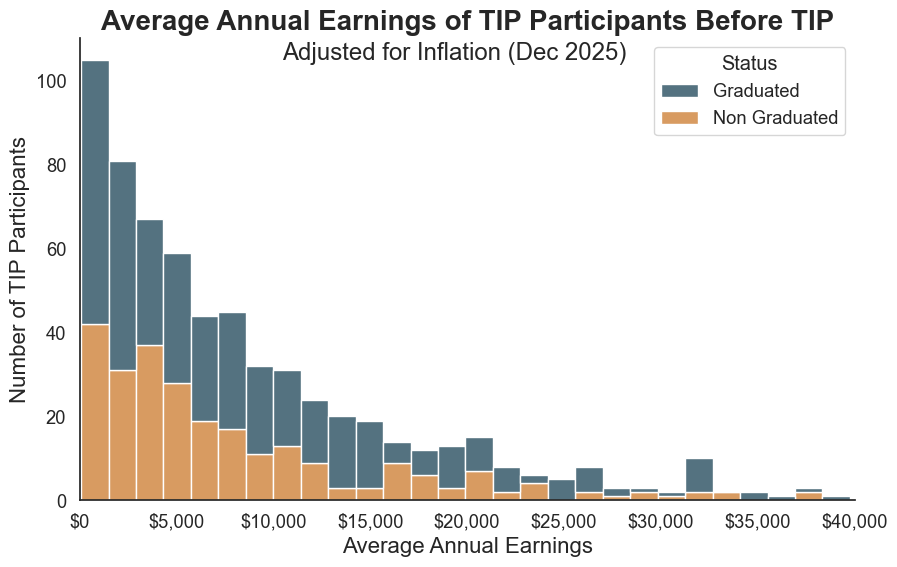

In [384]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(
    data=df_e_combined[
        (df_e_combined["adjusted_earnings_pre"] > 0) & (df_e_combined["adjusted_earnings_pre"] < 40000)
    ],
    x="adjusted_earnings_pre",
    bins=28,
    hue="Status",
    multiple="stack"
)

sns.despine()
plt.xlim(0, 40000)
ax.xaxis.set_major_formatter('${x:,.0f}')

plt.ylabel("Number of TIP Participants", fontdict={"fontsize": 16})
plt.xlabel("Average Annual Earnings", fontdict={"fontsize": 16})
plt.title(
    "Average Annual Earnings of TIP Participants Before TIP",
    fontdict={"fontsize": 20, "fontweight": "semibold"}
)
plt.suptitle("Adjusted for Inflation (Dec 2025)", fontdict={"fontsize": 14}, y=0.875)

plt.show()

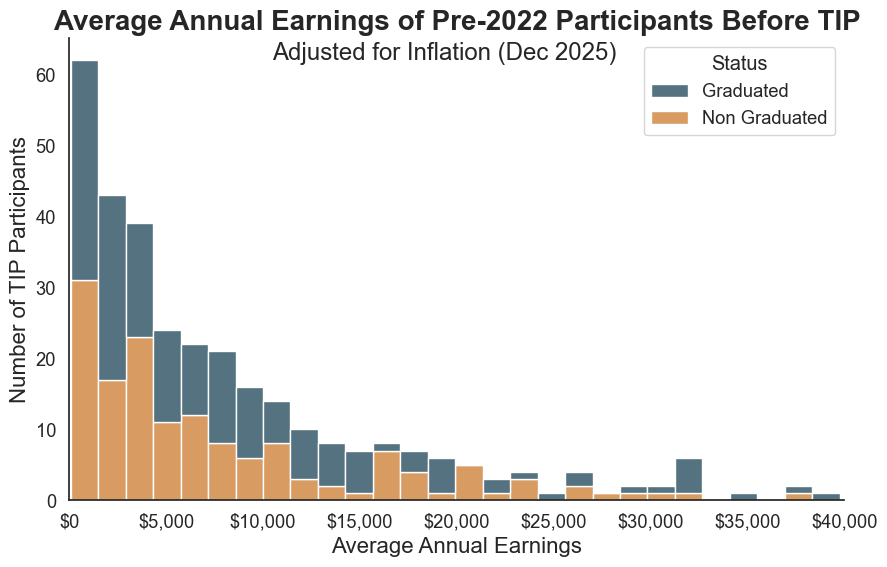

In [385]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(
    data=df_e_combined[
        (df_e_combined["cohort_2022"] == 1) & (df_e_combined["adjusted_earnings_pre"] > 0) & (df_e_combined["adjusted_earnings_pre"] < 40000)
    ],
    x="adjusted_earnings_pre",
    bins=28,
    hue="Status",
    multiple="stack"
)

sns.despine()
plt.xlim(0, 40000)
ax.xaxis.set_major_formatter('${x:,.0f}')

plt.ylabel("Number of TIP Participants", fontdict={"fontsize": 16})
plt.xlabel("Average Annual Earnings", fontdict={"fontsize": 16})
plt.title(
    "Average Annual Earnings of Pre-2022 Participants Before TIP",
    fontdict={"fontsize": 20, "fontweight": "semibold"}
)
plt.suptitle("Adjusted for Inflation (Dec 2025)", fontdict={"fontsize": 14}, y=0.875)

plt.show()

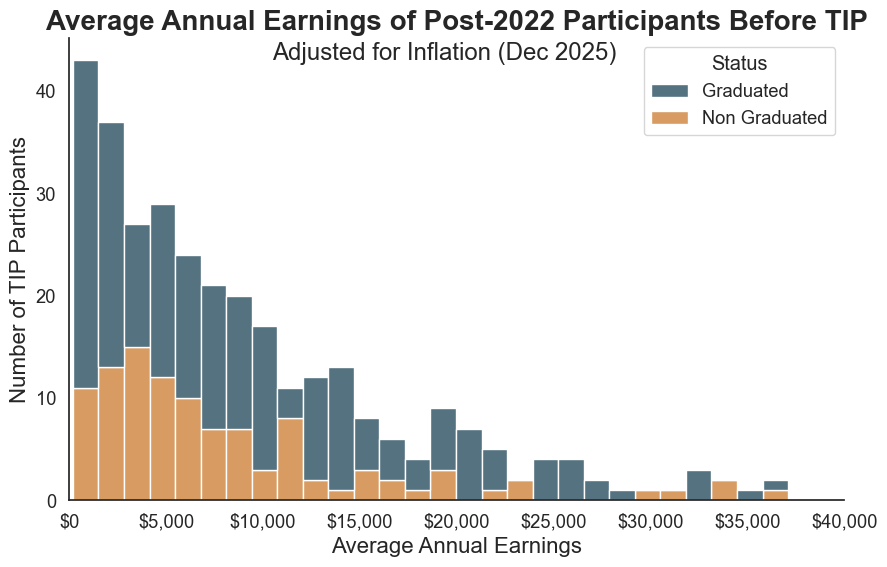

In [386]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(
    data=df_e_combined[
        (df_e_combined["cohort_2022"] == 2) & (df_e_combined["adjusted_earnings_pre"] > 0) & (df_e_combined["adjusted_earnings_pre"] < 40000)
    ],
    x="adjusted_earnings_pre",
    bins=28,
    hue="Status",
    multiple="stack"
)

sns.despine()
plt.xlim(0, 40000)
ax.xaxis.set_major_formatter('${x:,.0f}')

plt.ylabel("Number of TIP Participants", fontdict={"fontsize": 16})
plt.xlabel("Average Annual Earnings", fontdict={"fontsize": 16})
plt.title(
    "Average Annual Earnings of Post-2022 Participants Before TIP",
    fontdict={"fontsize": 20, "fontweight": "semibold"}
)
plt.suptitle("Adjusted for Inflation (Dec 2025)", fontdict={"fontsize": 14}, y=0.875)

plt.show()

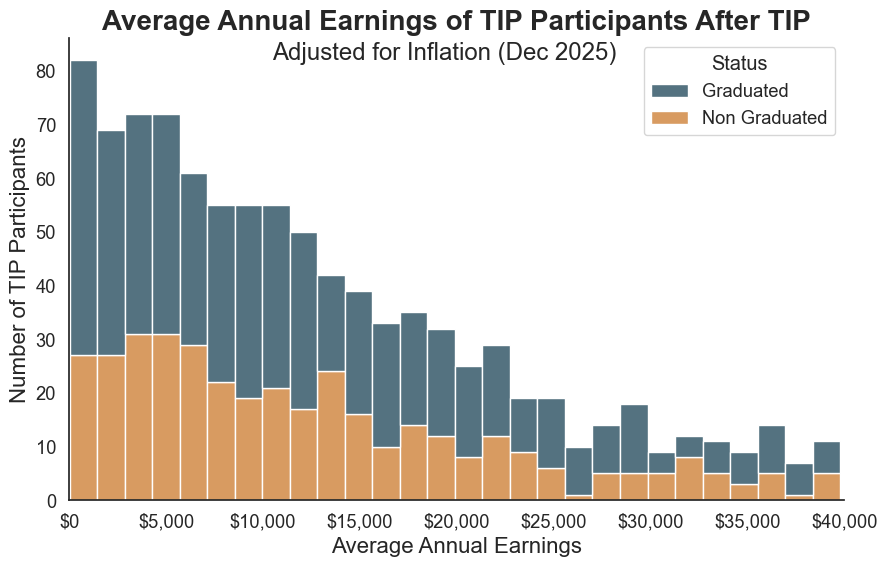

In [387]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(
    data=df_e_combined[
        (df_e_combined["adjusted_earnings_post"] > 0) & (df_e_combined["adjusted_earnings_post"] < 40000)
    ],
    x="adjusted_earnings_post",
    bins=28,
    hue="Status",
    multiple="stack"
)

sns.despine()
plt.xlim(0, 40000)
ax.xaxis.set_major_formatter('${x:,.0f}')

plt.ylabel("Number of TIP Participants", fontdict={"fontsize": 16})
plt.xlabel("Average Annual Earnings", fontdict={"fontsize": 16})
plt.title(
    "Average Annual Earnings of TIP Participants After TIP",
    fontdict={"fontsize": 20, "fontweight": "semibold"}
)
plt.suptitle("Adjusted for Inflation (Dec 2025)", fontdict={"fontsize": 14}, y=0.875)

plt.show()

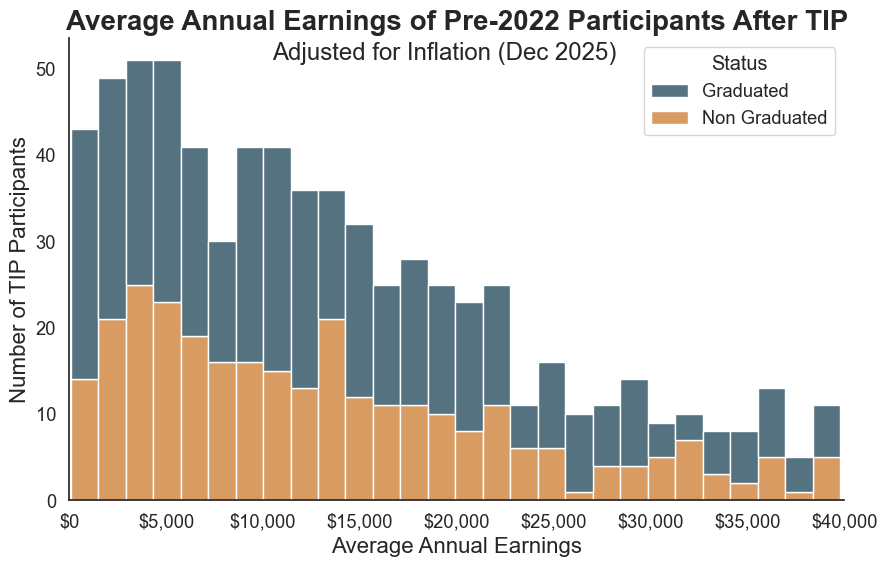

In [388]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(
    data=df_e_combined[
        (df_e_combined["cohort_2022"] == 1) &
        (df_e_combined["adjusted_earnings_post"] > 0) & (df_e_combined["adjusted_earnings_post"] < 40000)
    ],
    x="adjusted_earnings_post",
    bins=28,
    hue="Status",
    multiple="stack"
)

sns.despine()
plt.xlim(0, 40000)
ax.xaxis.set_major_formatter('${x:,.0f}')

plt.ylabel("Number of TIP Participants", fontdict={"fontsize": 16})
plt.xlabel("Average Annual Earnings", fontdict={"fontsize": 16})
plt.title(
    "Average Annual Earnings of Pre-2022 Participants After TIP",
    fontdict={"fontsize": 20, "fontweight": "semibold"}
)
plt.suptitle("Adjusted for Inflation (Dec 2025)", fontdict={"fontsize": 14}, y=0.875)

plt.show()

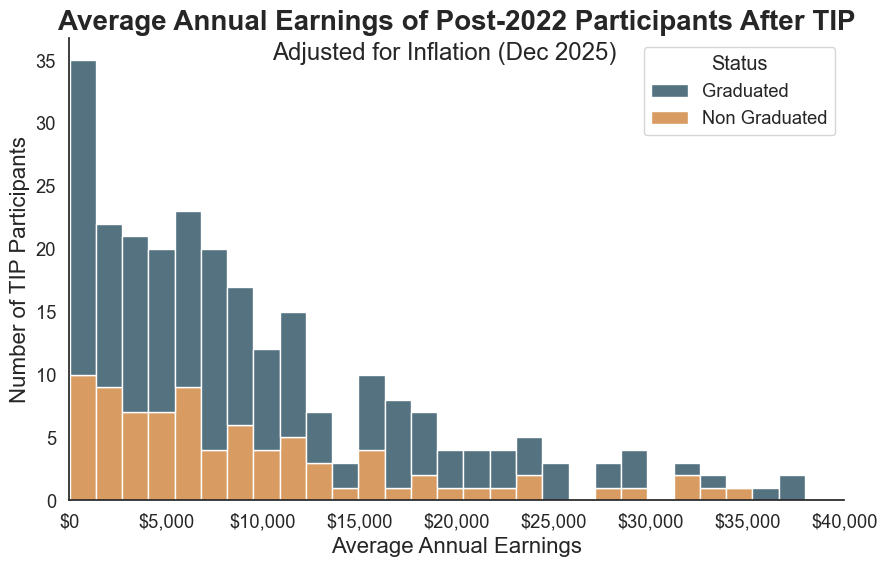

In [389]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(
    data=df_e_combined[
         (df_e_combined["cohort_2022"] == 2) &
        (df_e_combined["adjusted_earnings_post"] > 0) & (df_e_combined["adjusted_earnings_post"] < 40000)
    ],
    x="adjusted_earnings_post",
    bins=28,
    hue="Status",
    multiple="stack"
)

sns.despine()
plt.xlim(0, 40000)
ax.xaxis.set_major_formatter('${x:,.0f}')

plt.ylabel("Number of TIP Participants", fontdict={"fontsize": 16})
plt.xlabel("Average Annual Earnings", fontdict={"fontsize": 16})
plt.title(
    "Average Annual Earnings of Post-2022 Participants After TIP",
    fontdict={"fontsize": 20, "fontweight": "semibold"}
)
plt.suptitle("Adjusted for Inflation (Dec 2025)", fontdict={"fontsize": 14}, y=0.875)

plt.show()

In [390]:
df_earnings.columns

Index(['tip_id', 'quarter', 'employer_legal_name', 'earnings', 'naics_code',
       'naics_sector_2017', 'naics_subsector_2017', 'naics_industry_2017',
       'naics_sector_2022', 'naics_subsector_2022', 'naics_industry_2022',
       'year', 'year_quarter_dt', 'year_month', 'CPI', 'adjusted_earnings'],
      dtype='object')

In [399]:
e = df_earnings.merge(
    df_student[["tip_id", "StartDate", "ValidYears", "Status", 'ValidYearsPre_UI', 'cohort_2022']],
    on="tip_id",
    how="left"
)

# keep only Graduated / Non Graduated
e = e[e["Status"].isin(["Graduated", "Non Graduated"])].copy()


e["YearsSinceTIP"] = (e["year_quarter_dt"] - e["StartDate"]).dt.days / 365.25

# "employment in quarter" indicator: has employer legal name in that quarter
e["employed_quarter"] = e["employer_legal_name"].notna() & (e["employer_legal_name"].astype(str).str.strip() != "")

# integer bin for pre buckets: >0 -> ceil, <0 -> floor, 0 -> 0
y = e["YearsSinceTIP"]
e["YearsSinceTIP_int"] = np.where(y > 0, np.ceil(y), np.where(y < 0, np.floor(y), 0)).astype(int)

e.head()

,tip_id,quarter,employer_legal_name,earnings,naics_code,naics_sector_2017,naics_subsector_2017,naics_industry_2017,naics_sector_2022,naics_subsector_2022,...,CPI,adjusted_earnings,StartDate,ValidYears,Status,ValidYearsPre_UI,cohort_2022,YearsSinceTIP,employed_quarter,YearsSinceTIP_int
0,655,20182,LEHIGH VALLEY RESTAURANT GROUP INC,1434,722511.0,Accommodation and food services,Food services and drinking places,Full-Service Restaurants,Accommodation and Food Services,Food Services and Drinking Places,...,251.989,1844.102068,2021-06-03,3.556468,Non Graduated,-4.418891,1.0,-2.926762,True,-3
1,556,20174,COST COMPANY,3147,238142.0,Construction,Specialty trade contractors,Masonry Contractors - Nonresidential,Construction,Specialty Trade Contractors,...,246.524,4136.708548,2017-03-29,7.668720,Graduated,-0.238193,1.0,0.758385,True,1
2,556,20174,FRANCO,4654,238142.0,Construction,Specialty trade contractors,Masonry Contractors - Nonresidential,Construction,Specialty Trade Contractors,...,246.524,6117.649056,2017-03-29,7.668720,Graduated,-0.238193,1.0,0.758385,True,1
3,556,20181,COST COMPANY,1908,238142.0,Construction,Specialty trade contractors,Masonry Contractors - Nonresidential,Construction,Specialty Trade Contractors,...,249.554,2477.600167,2017-03-29,7.668720,Graduated,-0.238193,1.0,1.004791,True,2
4,556,20181,FRANCO,7165,238142.0,Construction,Specialty trade contractors,Masonry Contractors - Nonresidential,Construction,Specialty Trade Contractors,...,249.554,9303.985951,2017-03-29,7.668720,Graduated,-0.238193,1.0,1.004791,True,2


In [400]:
#Create a yearly employment data frame
# extract year from quarter date
e['year'] = e['year_quarter_dt'].dt.year

# aggregate to tip_id + year level
e_yearly = (
    e.groupby(['tip_id', 'year'])
     .agg(
         employed_year=('employed_quarter', 'any'),  
         Status=('Status', 'first'),               
         StartDate=('StartDate', 'first'),
         ValidYears=('ValidYears', 'first'),
         ValidYearsPre=('ValidYearsPre_UI', 'first')
     )
     .reset_index()
)

e_yearly.head()

,tip_id,year,employed_year,Status,StartDate,ValidYears,ValidYearsPre
0,1,2017,True,Non Graduated,2018-07-12,6.417522,-1.524983
1,1,2018,True,Non Graduated,2018-07-12,6.417522,-1.524983
2,1,2019,True,Non Graduated,2018-07-12,6.417522,-1.524983
3,1,2020,True,Non Graduated,2018-07-12,6.417522,-1.524983
4,1,2021,True,Non Graduated,2018-07-12,6.417522,-1.524983


In [401]:
e_yearly = e_yearly[e_yearly["employed_year"] == True]

e_yearly_yes = e_yearly.loc[:, ['tip_id', 'year'], ]

##merge the yearly employment database with our Allegheny County social service usage records
##rather than left join, we did an outer join here to keep anyone with employment and add in those from the social service records who were not present
##in the employment data, as we will assume their employment then is 0 at the time of the benefits record
ac_records = ac_ss_records.merge(
    e_yearly_yes[["tip_id", "year"]],
    on=["tip_id", "year"],
    how="outer"
)

ac_records.head()

ac_records = ac_records.merge(
    df_student[["tip_id", "ValidYears", "ValidYearsPre_UI", "Status", "StartDate", "cohort_2022"]],
    on = ["tip_id"],
    how = "left"
)

ac_records.head()

,tip_id,year,ValidYears,ValidYearsPre_UI,Status,StartDate,cohort_2022
0,1,2010,6.417522,-1.524983,Non Graduated,2018-07-12,1.0
1,1,2011,6.417522,-1.524983,Non Graduated,2018-07-12,1.0
2,1,2012,6.417522,-1.524983,Non Graduated,2018-07-12,1.0
3,1,2013,6.417522,-1.524983,Non Graduated,2018-07-12,1.0
4,1,2014,6.417522,-1.524983,Non Graduated,2018-07-12,1.0


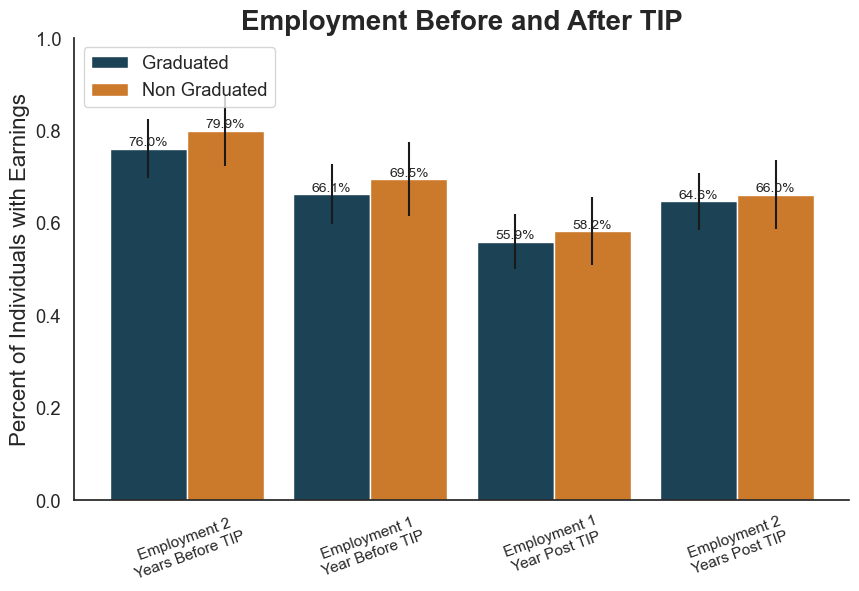

In [402]:
#Examine employment across both cohorts by status type

##pre-TIP
pre_points = [-1, -2]
rows = []
for i in pre_points:
    cur = e[(e["YearsSinceTIP"] < 0) & (e["YearsSinceTIP"] >= i) & (e["ValidYearsPre_UI"] <= i)]

    row = {"YearsSinceTIP": i}
    for status in ["Graduated", "Non Graduated"]:
        num = (cur.loc[(cur["Status"] == status) & (cur["employed_quarter"])]
       ["tip_id"]
       .nunique())
        denom = ac_records.loc[(ac_records["Status"] == status) & (ac_records["ValidYearsPre_UI"] <= i), "tip_id"].nunique()

        p = (num / denom) if denom > 0 else 0
        se = np.sqrt(p * (1 - p) / denom) if denom > 0 else np.nan

        row[f"{status}"] = num
        row[f"{status} Percent"] = p
        row[f"{status}_Upper_CI"] = min(1, p + z * se) if denom > 0 else np.nan
        row[f"{status}_Lower_CI"] = max(0, p - z * se) if denom > 0 else np.nan

    rows.append(row)

pre_df = pd.DataFrame(rows)

# -----------------------------
#post-TIP
post_points = [1, 2]
rows = []

for i in post_points:
    cur = e[(e["YearsSinceTIP"] >= 0) & (e["YearsSinceTIP"] < i) & (e["ValidYears"] > i)]

    row = {"YearsSinceTIP": i}
    for status in ["Graduated", "Non Graduated"]:
        num = ( cur.loc[(cur["Status"] == status) & (cur["employed_quarter"])]
       ["tip_id"]
       .nunique())
        denom = ac_records.loc[(ac_records["Status"] == status) & (ac_records["ValidYears"] > i), "tip_id"].nunique()

        p = (num / denom) if denom > 0 else 0
        se = np.sqrt(p * (1 - p) / denom) if denom > 0 else np.nan

        row[f"{status}"] = num
        row[f"{status} Percent"] = p
        row[f"{status}_Upper_CI"] = min(1, p + z * se) if denom > 0 else np.nan
        row[f"{status}_Lower_CI"] = max(0, p - z * se) if denom > 0 else np.nan

    rows.append(row)

post_df = pd.DataFrame(rows)

# -----------------------------
#combine and plot

label_map = {
    -2:  "Employment 2\nYears Before TIP",
    -1:  "Employment 1\nYear Before TIP",
     1:  "Employment 1\nYear Post TIP",
     2:  "Employment 2\nYears Post TIP"
}

order = [-2, -1, 1, 2]

pre_keep = pre_df[pre_df["YearsSinceTIP"].isin([-2, -1])].copy()

data = pd.concat([pre_keep, post_df], ignore_index=True)

data["YearsSinceTIP"] = pd.to_numeric(data["YearsSinceTIP"])

data["YearsSinceTIP"] = pd.Categorical(
    data["YearsSinceTIP"],
    categories=order,
    ordered=True
)

data = data.sort_values("YearsSinceTIP").reset_index(drop=True)


data["label"] = data["YearsSinceTIP"].map(label_map)

grad_err = np.abs(
    data[["Graduated_Upper_CI", "Graduated_Lower_CI"]].T.values - data["Graduated Percent"].values
)
non_grad_err = np.abs(
    data[["Non Graduated_Upper_CI", "Non Graduated_Lower_CI"]].T.values - data["Non Graduated Percent"].values
)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(data))
width = 0.42

ax.bar(x - width/2, data["Graduated Percent"], width=width, label="Graduated", yerr=grad_err, capsize=0)
ax.bar(x + width/2, data["Non Graduated Percent"], width=width, label="Non Graduated", yerr=non_grad_err, capsize=0)

ax.set_xticks(x)
ax.set_xticklabels(data["label"], rotation=20, ha="center", fontsize=11)

for xi, yi in zip(x - width/2, data["Graduated Percent"]):
    ax.text(xi, yi, f"{yi:.1%}", ha="center", va="bottom", fontsize=10)
for xi, yi in zip(x + width/2, data["Non Graduated Percent"]):
    ax.text(xi, yi, f"{yi:.1%}", ha="center", va="bottom", fontsize=10)

sns.despine()
plt.title("Employment Before and After TIP", fontdict={"fontsize": 20, "fontweight": "semibold"})
plt.ylabel("Percent of Individuals with Earnings", fontdict={"fontsize": 16})
plt.ylim(0, 1.0)
plt.legend(loc="upper left")
plt.show()


In [403]:
e.head()

,tip_id,quarter,employer_legal_name,earnings,naics_code,naics_sector_2017,naics_subsector_2017,naics_industry_2017,naics_sector_2022,naics_subsector_2022,...,CPI,adjusted_earnings,StartDate,ValidYears,Status,ValidYearsPre_UI,cohort_2022,YearsSinceTIP,employed_quarter,YearsSinceTIP_int
0,655,20182,LEHIGH VALLEY RESTAURANT GROUP INC,1434,722511.0,Accommodation and food services,Food services and drinking places,Full-Service Restaurants,Accommodation and Food Services,Food Services and Drinking Places,...,251.989,1844.102068,2021-06-03,3.556468,Non Graduated,-4.418891,1.0,-2.926762,True,-3
1,556,20174,COST COMPANY,3147,238142.0,Construction,Specialty trade contractors,Masonry Contractors - Nonresidential,Construction,Specialty Trade Contractors,...,246.524,4136.708548,2017-03-29,7.668720,Graduated,-0.238193,1.0,0.758385,True,1
2,556,20174,FRANCO,4654,238142.0,Construction,Specialty trade contractors,Masonry Contractors - Nonresidential,Construction,Specialty Trade Contractors,...,246.524,6117.649056,2017-03-29,7.668720,Graduated,-0.238193,1.0,0.758385,True,1
3,556,20181,COST COMPANY,1908,238142.0,Construction,Specialty trade contractors,Masonry Contractors - Nonresidential,Construction,Specialty Trade Contractors,...,249.554,2477.600167,2017-03-29,7.668720,Graduated,-0.238193,1.0,1.004791,True,2
4,556,20181,FRANCO,7165,238142.0,Construction,Specialty trade contractors,Masonry Contractors - Nonresidential,Construction,Specialty Trade Contractors,...,249.554,9303.985951,2017-03-29,7.668720,Graduated,-0.238193,1.0,1.004791,True,2


In [404]:
#repeat for cohort 1

#pre-TIP
pre_points = [-1, -2]
rows = []
for i in pre_points:
    cur = e[(e["YearsSinceTIP"] < 0) & (e["YearsSinceTIP"] >= i) & (e["ValidYearsPre_UI"] <= i) & (e["cohort_2022"] == 1)]

    row = {"YearsSinceTIP": i}
    for status in ["Graduated", "Non Graduated"]:
        num = (cur.loc[(cur["Status"] == status) & (cur["employed_quarter"])]
       ["tip_id"]
       .nunique())
        denom = ac_records.loc[(ac_records["Status"] == status) & (ac_records["ValidYearsPre_UI"] <= i) & (ac_records["cohort_2022"]==1), "tip_id"].nunique()

        p = (num / denom) if denom > 0 else 0
        se = np.sqrt(p * (1 - p) / denom) if denom > 0 else np.nan

        row[f"{status}_num"] = num
        row[f"{status}_denom"] = denom

        row[f"{status}"] = num
        row[f"{status} Percent"] = p
        row[f"{status}_Upper_CI"] = min(1, p + z * se) if denom > 0 else np.nan
        row[f"{status}_Lower_CI"] = max(0, p - z * se) if denom > 0 else np.nan

    rows.append(row)

pre_df = pd.DataFrame(rows)

# -----------------------------
#post-TIP

post_points = [1, 2]
rows = []

for i in post_points:
    cur = e[
    (e["YearsSinceTIP"] >= 0) &
    (e["YearsSinceTIP"] < i) &
    (e["ValidYears"] > i) &
    (e["employed_quarter"]) &
    (e["cohort_2022"] == 1)
]

    row = {"YearsSinceTIP": i}
    for status in ["Graduated", "Non Graduated"]:
        num = cur.loc[cur["Status"] == status, "tip_id"].nunique()
        denom = ac_records.loc[(ac_records["Status"] == status) & (ac_records["ValidYears"] > i) & (ac_records["cohort_2022"]==1), "tip_id"].nunique()

        p = (num / denom) if denom > 0 else 0
        se = np.sqrt(p * (1 - p) / denom) if denom > 0 else np.nan

        row[f"{status}_num"] = num
        row[f"{status}_denom"] = denom
    
        row[f"{status}"] = num
        row[f"{status} Percent"] = p
        row[f"{status}_Upper_CI"] = min(1, p + z * se) if denom > 0 else np.nan
        row[f"{status}_Lower_CI"] = max(0, p - z * se) if denom > 0 else np.nan

    rows.append(row)

post_df = pd.DataFrame(rows)

# -----------------------------
#combine and plot

label_map = {
    -2:  "Employment 2\nYears Before TIP",
    -1:  "Employment 1\nYear Before TIP",
     1:  "Employment 1\nYear Post TIP",
     2:  "Employment 2\nYears Post TIP",
}
order = [-2, -1, 1, 2]

pre_keep = pre_df[pre_df["YearsSinceTIP"].isin([-2, -1])].copy()

data = pd.concat([pre_keep, post_df], ignore_index=True)

data["YearsSinceTIP"] = pd.to_numeric(data["YearsSinceTIP"])

data["YearsSinceTIP"] = pd.Categorical(
    data["YearsSinceTIP"],
    categories=order,
    ordered=True
)

data = data.sort_values("YearsSinceTIP").reset_index(drop=True)


data["label"] = data["YearsSinceTIP"].map(label_map)

grad_err = np.abs(
    data[["Graduated_Upper_CI", "Graduated_Lower_CI"]].T.values - data["Graduated Percent"].values
)
non_grad_err = np.abs(
    data[["Non Graduated_Upper_CI", "Non Graduated_Lower_CI"]].T.values - data["Non Graduated Percent"].values
)

employment_pre2022 = data.copy()


In [407]:
#Repeat for post-2022 cohort

# pre-TIP

pre_points = [-1, -2]
rows = []
for i in pre_points:
    cur = e[(e["YearsSinceTIP"] < 0) & (e["YearsSinceTIP"] >= i) & (e["ValidYearsPre_UI"] <= i) & (e['cohort_2022'] == 2)]

    row = {"YearsSinceTIP": i}
    for status in ["Graduated", "Non Graduated"]:
        num = (cur.loc[(cur["Status"] == status) & (cur["employed_quarter"])]
       ["tip_id"]
       .nunique())
        denom = ac_records.loc[(ac_records["Status"] == status) & (ac_records["ValidYearsPre_UI"] <= i) & (ac_records["cohort_2022"]==2), "tip_id"].nunique()

        p = (num / denom) if denom > 0 else 0
        se = np.sqrt(p * (1 - p) / denom) if denom > 0 else np.nan

        row[f"{status}_num"] = num
        row[f"{status}_denom"] = denom

        row[f"{status}"] = num
        row[f"{status} Percent"] = p
        row[f"{status}_Upper_CI"] = min(1, p + z * se) if denom > 0 else np.nan
        row[f"{status}_Lower_CI"] = max(0, p - z * se) if denom > 0 else np.nan

    rows.append(row)

pre_df = pd.DataFrame(rows)

# -----------------------------
#post-TIP

post_points = [1, 2]
rows = []

for i in post_points:
    cur = e[
    (e["YearsSinceTIP"] >= 0) &
    (e["YearsSinceTIP"] < i) &
    (e["ValidYears"] > i) &
    (e["employed_quarter"]) &
    (e['cohort_2022'] == 2)
]

    row = {"YearsSinceTIP": i}
    for status in ["Graduated", "Non Graduated"]:
        num = cur.loc[cur["Status"] == status, "tip_id"].nunique()
        denom = ac_records.loc[(ac_records["Status"] == status) & (ac_records["ValidYears"] > i) & (ac_records["cohort_2022"]==2), "tip_id"].nunique()

        p = (num / denom) if denom > 0 else 0
        se = np.sqrt(p * (1 - p) / denom) if denom > 0 else np.nan

        row[f"{status}_num"] = num
        row[f"{status}_denom"] = denom
    
        row[f"{status}"] = num
        row[f"{status} Percent"] = p
        row[f"{status}_Upper_CI"] = min(1, p + z * se) if denom > 0 else np.nan
        row[f"{status}_Lower_CI"] = max(0, p - z * se) if denom > 0 else np.nan

    rows.append(row)

post_df = pd.DataFrame(rows)

# -----------------------------
#combine and plot

label_map = {
    -2:  "Employment 2\nYears Before TIP",
    -1:  "Employment 1\nYear Before TIP",
     1:  "Employment 1\nYear Post TIP",
     2:  "Employment 2\nYears Post TIP",
}
order = [-2, -1, 1, 2]

pre_keep = pre_df[pre_df["YearsSinceTIP"].isin([-2, -1])].copy()

data = pd.concat([pre_keep, post_df], ignore_index=True)

data["YearsSinceTIP"] = pd.to_numeric(data["YearsSinceTIP"])

data["YearsSinceTIP"] = pd.Categorical(
    data["YearsSinceTIP"],
    categories=order,
    ordered=True
)

data = data.sort_values("YearsSinceTIP").reset_index(drop=True)

data["label"] = data["YearsSinceTIP"].map(label_map)

grad_err = np.abs(
    data[["Graduated_Upper_CI", "Graduated_Lower_CI"]].T.values - data["Graduated Percent"].values
)
non_grad_err = np.abs(
    data[["Non Graduated_Upper_CI", "Non Graduated_Lower_CI"]].T.values - data["Non Graduated Percent"].values
)

employment_post2022 = data.copy()


In [408]:
#Significance testing for differences within the same bar across different cohorts
#E.G. - This will test whether graduated proportion in YearsSinceTIP of -3 in the pre-2022 cohort is significantly different than
#the graduated proportion in YearsSinceTIP of -3 in the post-2022 cohort

year_comp = [-2,-1,1,2]
sig_results_emp = compute_significance(employment_pre2022, employment_post2022, year_comp)
sig_results_emp["star"] = sig_results_emp["p_value"].apply(star)
print(sig_results_emp)

   YearsSinceTIP         Status       p_value star
0             -2      Graduated  3.045609e-02    *
1             -2  Non Graduated  5.015149e-01     
2             -1      Graduated  1.956524e-03   **
3             -1  Non Graduated  2.497027e-01     
4              1      Graduated  1.946579e-12  ***
5              1  Non Graduated  2.588012e-06  ***
6              2      Graduated  1.170104e-04  ***
7              2  Non Graduated  5.781965e-03   **


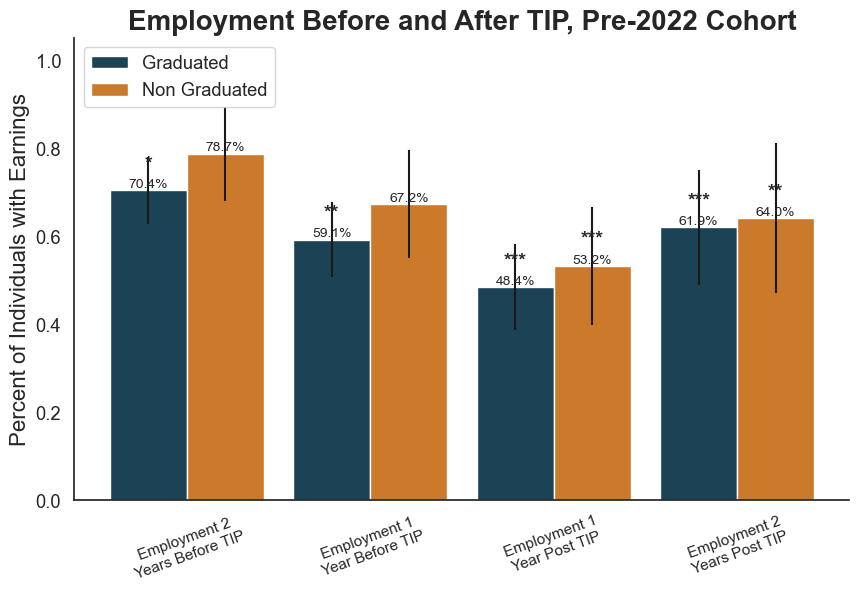

In [409]:

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(employment_pre2022))
width = 0.42

ax.bar(x - width/2, employment_pre2022["Graduated Percent"], width=width, label="Graduated", yerr=grad_err, capsize=0)
ax.bar(x + width/2, employment_pre2022["Non Graduated Percent"], width=width, label="Non Graduated", yerr=non_grad_err, capsize=0)

ax.set_xticks(x)
ax.set_xticklabels(employment_pre2022["label"], rotation=20, ha="center", fontsize=11)

for xi, yi in zip(x - width/2, employment_pre2022["Graduated Percent"]):
    ax.text(xi, yi, f"{yi:.1%}", ha="center", va="bottom", fontsize=10)
for xi, yi in zip(x + width/2, employment_pre2022["Non Graduated Percent"]):
    ax.text(xi, yi, f"{yi:.1%}", ha="center", va="bottom", fontsize=10)


sns.despine()
plt.title("Employment Before and After TIP, Pre-2022 Cohort", fontdict={"fontsize": 20, "fontweight": "semibold"})
plt.ylabel("Percent of Individuals with Earnings", fontdict={"fontsize": 16})
add_sig_stars(ax, employment_pre2022, sig_results_emp, width)
plt.ylim(0, 1.05)
plt.legend(loc="upper left")
plt.show()

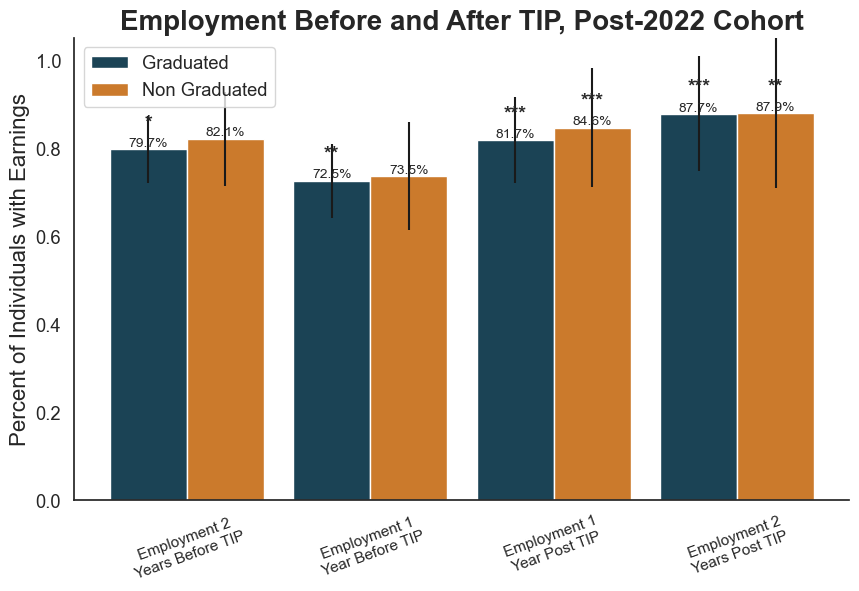

In [410]:
#employment post-2022 figure


fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(data))
width = 0.42

ax.bar(x - width/2, employment_post2022["Graduated Percent"], width=width, label="Graduated", yerr=grad_err, capsize=0)
ax.bar(x + width/2, employment_post2022["Non Graduated Percent"], width=width, label="Non Graduated", yerr=non_grad_err, capsize=0)

ax.set_xticks(x)
ax.set_xticklabels(employment_post2022["label"], rotation=20, ha="center", fontsize=11)

for xi, yi in zip(x - width/2, employment_post2022["Graduated Percent"]):
    ax.text(xi, yi, f"{yi:.1%}", ha="center", va="bottom", fontsize=10)
for xi, yi in zip(x + width/2, data["Non Graduated Percent"]):
    ax.text(xi, yi, f"{yi:.1%}", ha="center", va="bottom", fontsize=10)

sns.despine()
plt.title("Employment Before and After TIP, Post-2022 Cohort", fontdict={"fontsize": 20, "fontweight": "semibold"})
plt.ylabel("Percent of Individuals with Earnings", fontdict={"fontsize": 16})
add_sig_stars(ax, employment_post2022, sig_results_emp, width)
plt.ylim(0, 1.05)
plt.legend(loc="upper left")
plt.show()

C:\Users\sarah\AppData\Local\Temp\ipykernel_10680\4248609987.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  e.groupby(["naics_subsector_2017", "Status"])["tip_id"]


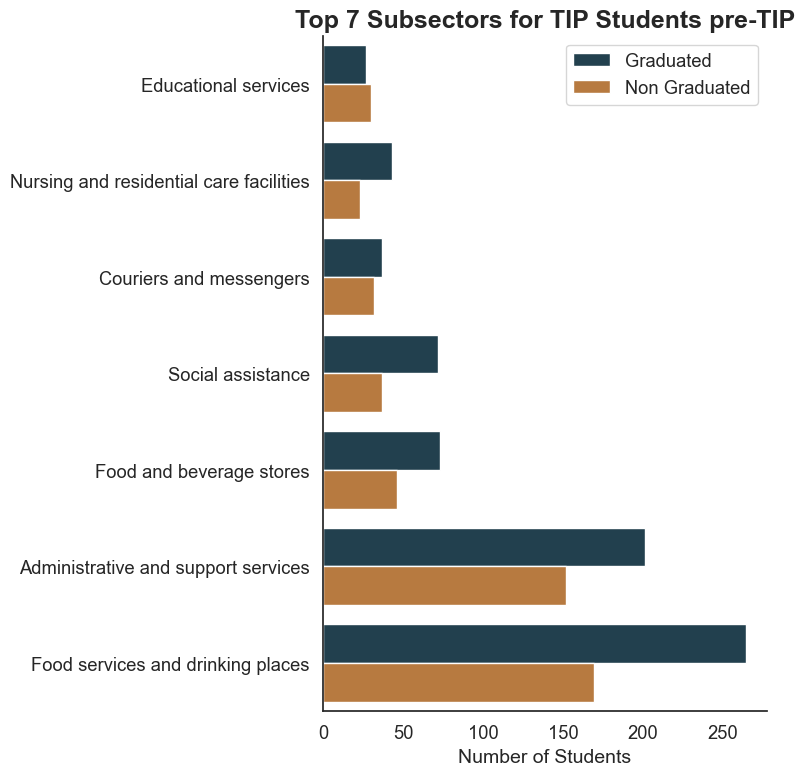

In [412]:
#Industry analysis pre-TIP

# 1) join StartDate + Status
e = df_earnings.merge(
    df_student[["tip_id", "StartDate", "Status"]],
    on="tip_id",
    how="left"
)

# 2) keep only Grad / Non Grad + pre-TIP quarters + non-missing subsector
e = e[
    e["Status"].isin(["Graduated", "Non Graduated"]) &
    (e["year_quarter_dt"] < e["StartDate"]) &
    e["naics_subsector_2017"].notna()
].copy()

#drop blank strings just in case
e = e[e["naics_subsector_2017"].astype(str).str.strip() != ""]



# 3) count unique students (tip_id) by subsector and status
counts = (
    e.groupby(["naics_subsector_2017", "Status"])["tip_id"]
    .nunique()
    .reset_index(name="count")
)

# 4) pick overall top 7 subsectors by total students (across both statuses)
top7 = (
    counts.groupby("naics_subsector_2017")["count"]
    .sum()
    .sort_values(ascending=False)
    .head(7)
    .index
)

plot_df = counts[counts["naics_subsector_2017"].isin(top7)].copy()

# order y-axis by total (top to bottom)
order = (
    plot_df.groupby("naics_subsector_2017")["count"]
    .sum()
    .sort_values(ascending=True)   # ascending so biggest ends up on top after barh
    .index
)

# 5) plot
plt.figure(figsize=(8, 8))
ax = sns.barplot(
    data=plot_df,
    y="naics_subsector_2017",
    x="count",
    hue="Status",
    order=order,
    orient="h"
)

sns.despine()
plt.title("Top 7 Subsectors for TIP Students pre-TIP", fontdict={"fontsize": 18, "fontweight": "semibold"})
plt.xlabel("Number of Students", fontdict={"fontsize": 14})
plt.ylabel("")

# make legend look like screenshot order
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, title=None, loc="upper right")

plt.tight_layout()
plt.show()


C:\Users\sarah\AppData\Local\Temp\ipykernel_10680\2337386257.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  e.groupby(["naics_subsector_2017", "Status"])["tip_id"]


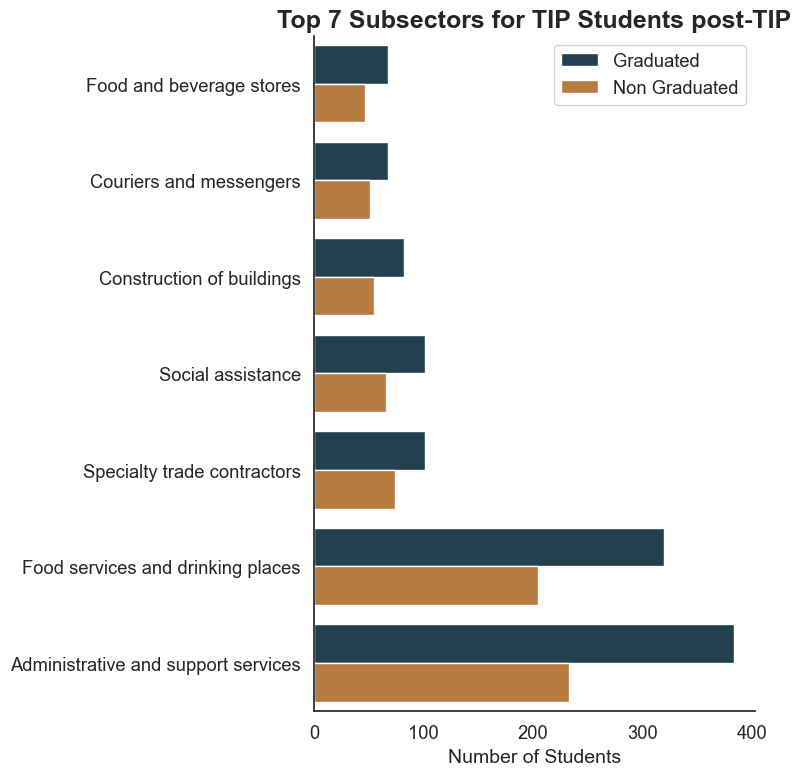

In [413]:
#Industry analysis post-TIP

# 1) join StartDate + Status
e = df_earnings.merge(
    df_student[["tip_id", "StartDate", "Status"]],
    on="tip_id",
    how="left"
)

# 2) keep only Grad / Non Grad + pre-TIP quarters + non-missing subsector
e = e[
    e["Status"].isin(["Graduated", "Non Graduated"]) &
    (e["year_quarter_dt"] > e["StartDate"]) &
    e["naics_subsector_2017"].notna()
].copy()

#drop blank strings just in case
e = e[e["naics_subsector_2017"].astype(str).str.strip() != ""]



# 3) count unique students (tip_id) by subsector and status
counts = (
    e.groupby(["naics_subsector_2017", "Status"])["tip_id"]
    .nunique()
    .reset_index(name="count")
)

# 4) pick overall top 7 subsectors by total students (across both statuses)
top7 = (
    counts.groupby("naics_subsector_2017")["count"]
    .sum()
    .sort_values(ascending=False)
    .head(7)
    .index
)

plot_df = counts[counts["naics_subsector_2017"].isin(top7)].copy()

# order y-axis by total (top to bottom)
order = (
    plot_df.groupby("naics_subsector_2017")["count"]
    .sum()
    .sort_values(ascending=True)   # ascending so biggest ends up on top after barh
    .index
)

# 5) plot
plt.figure(figsize=(8, 8))
ax = sns.barplot(
    data=plot_df,
    y="naics_subsector_2017",
    x="count",
    hue="Status",
    order=order,
    orient="h"
)

sns.despine()
plt.title("Top 7 Subsectors for TIP Students post-TIP", fontdict={"fontsize": 18, "fontweight": "semibold"})
plt.xlabel("Number of Students", fontdict={"fontsize": 14})
plt.ylabel("")

# make legend look like screenshot order
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, title=None, loc="upper right")

plt.tight_layout()
plt.show()


C:\Users\sarah\AppData\Local\Temp\ipykernel_10680\3480732915.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  e.groupby("Status")["tip_id"]
C:\Users\sarah\AppData\Local\Temp\ipykernel_10680\3480732915.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  e.groupby(["naics_subsector_2017", "Status"])["tip_id"]


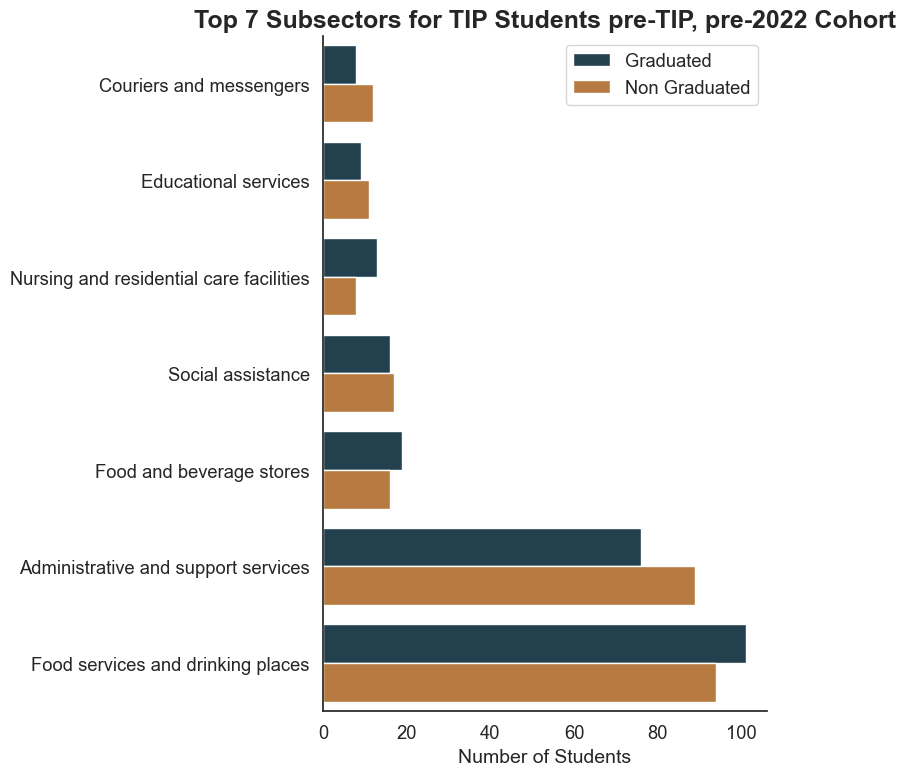

In [414]:
##repeat for pre-2022 cohort, pre-TIP

# 1) join StartDate + Status
e = df_earnings.merge(
    df_student[["tip_id", "StartDate", "Status", "cohort_2022"]],
    on="tip_id",
    how="left"
)

# 2) keep only Grad / Non Grad + pre-TIP quarters + non-missing subsector, cohort =1
e = e[
    e["Status"].isin(["Graduated", "Non Graduated"]) &
    (e["year_quarter_dt"] < e["StartDate"]) &
    e["naics_subsector_2017"].notna() &
    (e["cohort_2022"] == 1)
].copy()

e = e[e["naics_subsector_2017"].astype(str).str.strip() != ""]

#save denominators for significance testing
denoms = (
    e.groupby("Status")["tip_id"]
    .nunique()
    .reset_index(name="denom")
)

# 3) count unique students (tip_id) by subsector and status
counts = (
    e.groupby(["naics_subsector_2017", "Status"])["tip_id"]
    .nunique()
    .reset_index(name="count")
)

subsector_pre2022_pre = counts.merge(denoms, on="Status", how="left")

subsector_pre2022_pre["percent"] = subsector_pre2022_pre["count"] / subsector_pre2022_pre["denom"]


# 4) pick overall top 7 subsectors by total students (across both statuses)
top7 = (
    subsector_pre2022_pre.groupby("naics_subsector_2017")["count"]
    .sum()
    .sort_values(ascending=False)
    .head(7)
    .index
)

subsector_pre2022_pre_7 = subsector_pre2022_pre[subsector_pre2022_pre["naics_subsector_2017"].isin(top7)].copy()

# order y-axis by total (top to bottom)
order = (
    subsector_pre2022_pre_7.groupby("naics_subsector_2017")["count"]
    .sum()
    .sort_values(ascending=True)   # ascending so biggest ends up on top after barh
    .index
)

# 5) plot
plt.figure(figsize=(8, 8))
ax = sns.barplot(
    data=subsector_pre2022_pre_7,
    y="naics_subsector_2017",
    x="count",
    hue="Status",
    order=order,
    orient="h"
)

sns.despine()
plt.title("Top 7 Subsectors for TIP Students pre-TIP, pre-2022 Cohort", fontdict={"fontsize": 18, "fontweight": "semibold"})
plt.xlabel("Number of Students", fontdict={"fontsize": 14})
plt.ylabel("")

# make legend look like screenshot order
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, title=None, loc="upper right")

plt.tight_layout()
plt.show()


C:\Users\sarah\AppData\Local\Temp\ipykernel_10680\2371261202.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  e.groupby("Status")["tip_id"]
C:\Users\sarah\AppData\Local\Temp\ipykernel_10680\2371261202.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  e.groupby(["naics_subsector_2017", "Status"])["tip_id"]


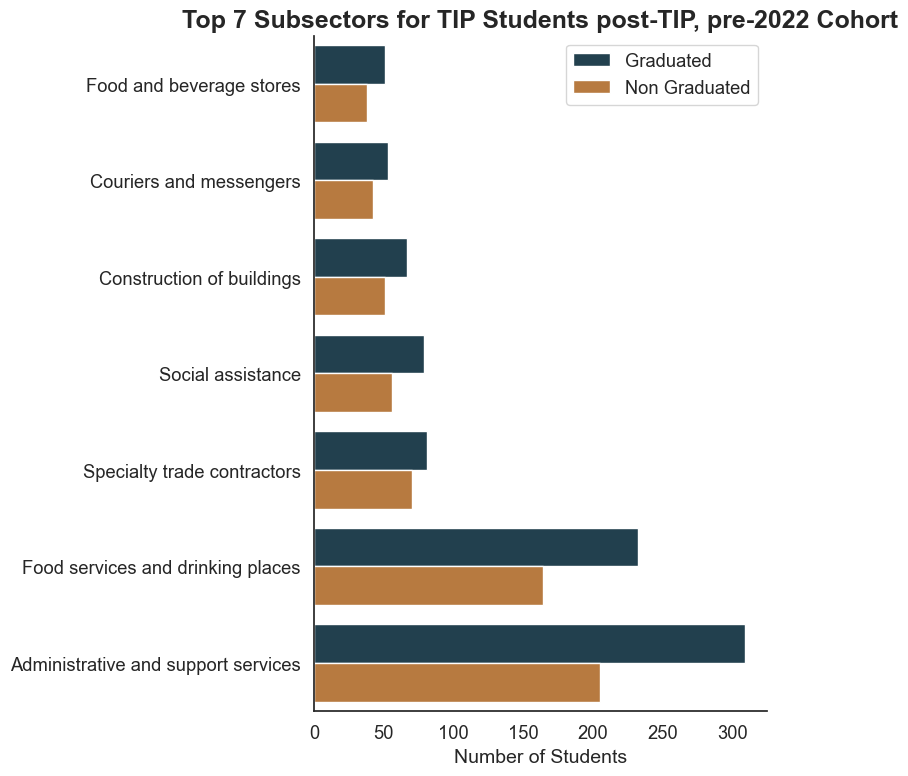

In [415]:
#repeat for pre-2022 cohort, post-TIP
# 1) join StartDate + Status
e = df_earnings.merge(
    df_student[["tip_id", "StartDate", "Status", "cohort_2022"]],
    on="tip_id",
    how="left"
)

# 2) keep only Grad / Non Grad + post-TIP quarters + non-missing subsector, cohort =1
e = e[
    e["Status"].isin(["Graduated", "Non Graduated"]) &
    (e["year_quarter_dt"] > e["StartDate"]) &
    e["naics_subsector_2017"].notna() &
    (e["cohort_2022"] == 1)
].copy()


e = e[e["naics_subsector_2017"].astype(str).str.strip() != ""]

#save denominators for significance testing
denoms = (
    e.groupby("Status")["tip_id"]
    .nunique()
    .reset_index(name="denom")
)

# 3) count unique students (tip_id) by subsector and status
counts = (
    e.groupby(["naics_subsector_2017", "Status"])["tip_id"]
    .nunique()
    .reset_index(name="count")
)

subsector_pre2022_post = counts.merge(denoms, on="Status", how="left")

subsector_pre2022_post["percent"] = subsector_pre2022_post["count"] / subsector_pre2022_post["denom"]
# 4) pick overall top 7 subsectors by total students (across both statuses)
top7 = (
    subsector_pre2022_post.groupby("naics_subsector_2017")["count"]
    .sum()
    .sort_values(ascending=False)
    .head(7)
    .index
)

subsector_pre2022_post_7 = subsector_pre2022_post[subsector_pre2022_post["naics_subsector_2017"].isin(top7)].copy()

# order y-axis by total (top to bottom)
order = (
    subsector_pre2022_post_7.groupby("naics_subsector_2017")["count"]
    .sum()
    .sort_values(ascending=True)   # ascending so biggest ends up on top after barh
    .index
)

# 5) plot
plt.figure(figsize=(8, 8))
ax = sns.barplot(
    data=subsector_pre2022_post_7,
    y="naics_subsector_2017",
    x="count",
    hue="Status",
    order=order,
    orient="h"
)

sns.despine()
plt.title("Top 7 Subsectors for TIP Students post-TIP, pre-2022 Cohort", fontdict={"fontsize": 18, "fontweight": "semibold"})
plt.xlabel("Number of Students", fontdict={"fontsize": 14})
plt.ylabel("")

# make legend look like screenshot order
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, title=None, loc="upper right")

plt.tight_layout()
plt.show()


C:\Users\sarah\AppData\Local\Temp\ipykernel_10680\2996953758.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  e.groupby("Status")["tip_id"]
C:\Users\sarah\AppData\Local\Temp\ipykernel_10680\2996953758.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  e.groupby(["naics_subsector_2017", "Status"])["tip_id"]


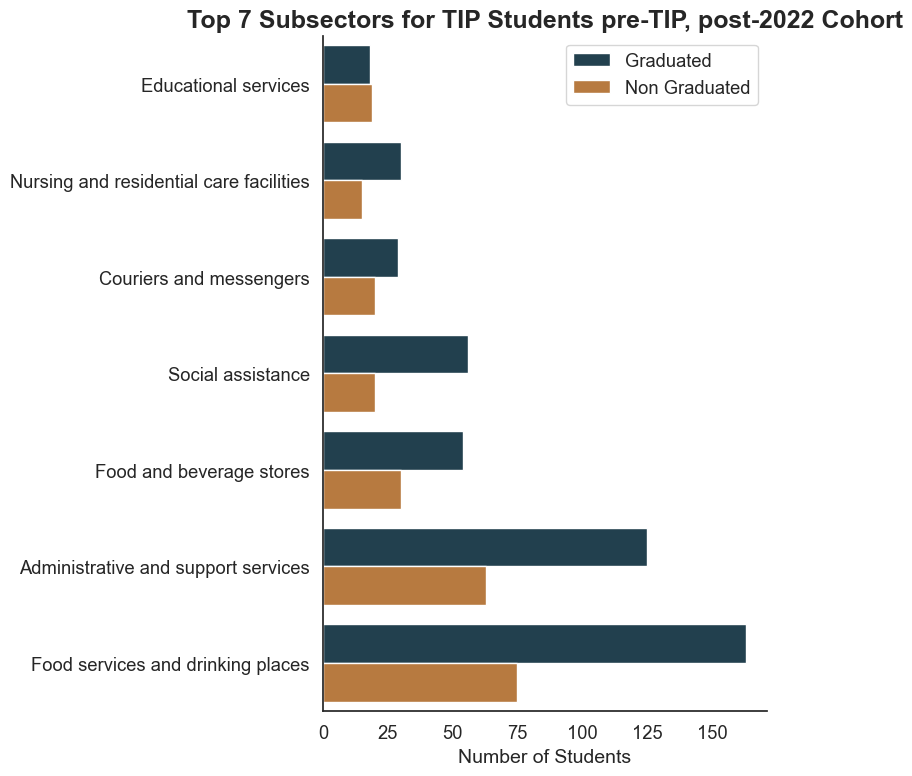

In [416]:
#post-2022 cohort, pre-TIP
# 1) join StartDate + Status
e = df_earnings.merge(
    df_student[["tip_id", "StartDate", "Status", "cohort_2022"]],
    on="tip_id",
    how="left"
)

# 2) keep only Grad / Non Grad + pre-TIP quarters + non-missing subsector, cohort =1
e = e[
    e["Status"].isin(["Graduated", "Non Graduated"]) &
    (e["year_quarter_dt"] < e["StartDate"]) &
    e["naics_subsector_2017"].notna() &
    (e["cohort_2022"] == 2)
].copy()

e = e[e["naics_subsector_2017"].astype(str).str.strip() != ""]

#save denominators for significance testing
denoms = (
    e.groupby("Status")["tip_id"]
    .nunique()
    .reset_index(name="denom")
)

# 3) count unique students (tip_id) by subsector and status
counts = (
    e.groupby(["naics_subsector_2017", "Status"])["tip_id"]
    .nunique()
    .reset_index(name="count")
)

subsector_post2022_pre = counts.merge(denoms, on="Status", how="left")

subsector_post2022_pre["percent"] = subsector_post2022_pre["count"] / subsector_post2022_pre["denom"]

# 4) pick overall top 7 subsectors by total students (across both statuses)
top7 = (
    counts.groupby("naics_subsector_2017")["count"]
    .sum()
    .sort_values(ascending=False)
    .head(7)
    .index
)

subsector_post2022_pre_7 = subsector_post2022_pre[subsector_post2022_pre["naics_subsector_2017"].isin(top7)].copy()

# order y-axis by total (top to bottom)
order = (
    subsector_post2022_pre_7.groupby("naics_subsector_2017")["count"]
    .sum()
    .sort_values(ascending=True)   # ascending so biggest ends up on top after barh
    .index
)

# 5) plot
plt.figure(figsize=(8, 8))
ax = sns.barplot(
    data=subsector_post2022_pre_7,
    y="naics_subsector_2017",
    x="count",
    hue="Status",
    order=order,
    orient="h"
)

sns.despine()
plt.title("Top 7 Subsectors for TIP Students pre-TIP, post-2022 Cohort", fontdict={"fontsize": 18, "fontweight": "semibold"})
plt.xlabel("Number of Students", fontdict={"fontsize": 14})
plt.ylabel("")

# make legend look like screenshot order
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, title=None, loc="upper right")

plt.tight_layout()
plt.show()


C:\Users\sarah\AppData\Local\Temp\ipykernel_10680\1376503623.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  e.groupby("Status")["tip_id"]
C:\Users\sarah\AppData\Local\Temp\ipykernel_10680\1376503623.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  e.groupby(["naics_subsector_2017", "Status"])["tip_id"]


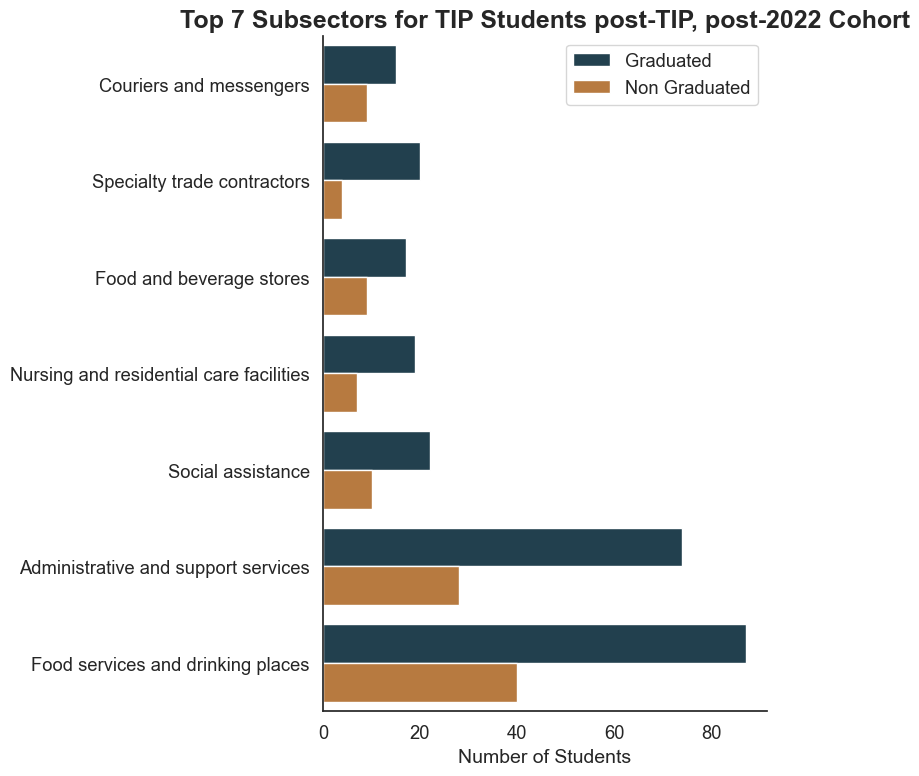

In [417]:
#post-2022 cohort, post-TIP
# 1) join StartDate + Status
e = df_earnings.merge(
    df_student[["tip_id", "StartDate", "Status", "cohort_2022"]],
    on="tip_id",
    how="left"
)

# 2) keep only Grad / Non Grad + post-TIP quarters + non-missing subsector, cohort =1
e = e[
    e["Status"].isin(["Graduated", "Non Graduated"]) &
    (e["year_quarter_dt"] > e["StartDate"]) &
    e["naics_subsector_2017"].notna() &
    (e["cohort_2022"] == 2)
].copy()

e = e[e["naics_subsector_2017"].astype(str).str.strip() != ""]

#save denominators for significance testing
denoms = (
    e.groupby("Status")["tip_id"]
    .nunique()
    .reset_index(name="denom")
)

# 3) count unique students (tip_id) by subsector and status
counts = (
    e.groupby(["naics_subsector_2017", "Status"])["tip_id"]
    .nunique()
    .reset_index(name="count")
)

subsector_post2022_post = counts.merge(denoms, on="Status", how="left")

subsector_post2022_post["percent"] = subsector_post2022_post["count"] / subsector_post2022_post["denom"]

# 4) pick overall top 7 subsectors by total students (across both statuses)
top7 = (
    subsector_post2022_post.groupby("naics_subsector_2017")["count"]
    .sum()
    .sort_values(ascending=False)
    .head(7)
    .index
)

subsector_post2022_post_7 = subsector_post2022_post[subsector_post2022_post["naics_subsector_2017"].isin(top7)].copy()

# order y-axis by total (top to bottom)
order = (
    subsector_post2022_post_7.groupby("naics_subsector_2017")["count"]
    .sum()
    .sort_values(ascending=True)   # ascending so biggest ends up on top after barh
    .index
)

# 5) plot
plt.figure(figsize=(8, 8))
ax = sns.barplot(
    data=subsector_post2022_post_7,
    y="naics_subsector_2017",
    x="count",
    hue="Status",
    order=order,
    orient="h"
)

sns.despine()
plt.title("Top 7 Subsectors for TIP Students post-TIP, post-2022 Cohort", fontdict={"fontsize": 18, "fontweight": "semibold"})
plt.xlabel("Number of Students", fontdict={"fontsize": 14})
plt.ylabel("")

# make legend look like screenshot order
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, title=None, loc="upper right")

plt.tight_layout()
plt.show()


In [418]:
#Define a function to test the differences between sectors across cohorts pre/post

import itertools
from statsmodels.stats.proportion import proportions_ztest

def run_subsector_tests(pre_df, post_df, pre_label="PreTIP", post_label="PostTIP"):
    """
    Run z-tests for employment share differences between pre and post periods,
    ensuring all industry × status combinations are included.
    """
    
    #All unique industries and statuses
    industries = pre_df["naics_subsector_2017"].unique()
    statuses = ["Graduated", "Non Graduated"]
    
    #Create full grid
    full_grid = pd.DataFrame(list(itertools.product(industries, statuses)),
                             columns=["naics_subsector_2017", "Status"])
    
    #Merge pre_df and post_df onto grid
    pre_full = full_grid.merge(pre_df, on=["naics_subsector_2017", "Status"], how="left")
    post_full = full_grid.merge(post_df, on=["naics_subsector_2017", "Status"], how="left")
    
    #Fill missing counts with 0
    pre_full[["count", "denom"]] = pre_full[["count", "denom"]].fillna(0)
    post_full[["count", "denom"]] = post_full[["count", "denom"]].fillna(0)
    
    #Compute shares
    pre_full["share"] = pre_full["count"] / pre_full["denom"].replace(0, 1)
    post_full["share"] = post_full["count"] / post_full["denom"].replace(0, 1)
    
    #Run z-test for each industry × status
    results = []
    for ind, status in itertools.product(industries, statuses):
        n1 = pre_full.loc[(pre_full["naics_subsector_2017"]==ind) & (pre_full["Status"]==status), "count"].values[0]
        N1 = pre_full.loc[(pre_full["naics_subsector_2017"]==ind) & (pre_full["Status"]==status), "denom"].values[0]
        n2 = post_full.loc[(post_full["naics_subsector_2017"]==ind) & (post_full["Status"]==status), "count"].values[0]
        N2 = post_full.loc[(post_full["naics_subsector_2017"]==ind) & (post_full["Status"]==status), "denom"].values[0]
        
        if N1 == 0 or N2 == 0:
            p_value = None
        else:
            stat, p_value = proportions_ztest([n1, n2], [N1, N2])
        
        results.append({
            "naics_subsector_2017": ind,
            "Status": status,
            "group1": pre_label,
            "group2": post_label,
            "p_value": p_value,
            "share1": n1/N1 if N1>0 else 0,
            "share2": n2/N2 if N2>0 else 0
        })
    
    return pd.DataFrame(results)

In [419]:
#Establish the top 7 industries to go into after completing TIP in each cohort
pre_top7 = subsector_pre2022_post[subsector_pre2022_post["naics_subsector_2017"].isin(top7)].copy()
post_top7 = subsector_post2022_post[subsector_post2022_post["naics_subsector_2017"].isin(top7)].copy()

# run z-tests on filtered data
pre2022_prepost = run_subsector_tests(pre_top7, post_top7, "Pre2022", "Post2022")

pd.set_option("display.max_rows", 15)

pre2022_prepost.iloc[0:20]

,naics_subsector_2017,Status,group1,group2,p_value,share1,share2
0,Administrative and support services,Graduated,Pre2022,Post2022,1.804039e-11,0.697517,0.408840
1,Administrative and support services,Non Graduated,Pre2022,Post2022,3.432589e-07,0.663430,0.350000
2,Couriers and messengers,Graduated,Pre2022,Post2022,1.810665e-01,0.119639,0.082873
3,Couriers and messengers,Non Graduated,Pre2022,Post2022,5.801234e-01,0.135922,0.112500
4,Food and beverage stores,Graduated,Pre2022,Post2022,4.405450e-01,0.115124,0.093923
5,Food and beverage stores,Non Graduated,Pre2022,Post2022,7.977467e-01,0.122977,0.112500
6,Food services and drinking places,Graduated,Pre2022,Post2022,3.290633e-01,0.523702,0.480663
7,Food services and drinking places,Non Graduated,Pre2022,Post2022,6.236010e-01,0.530744,0.500000
8,Nursing and residential care facilities,Graduated,Pre2022,Post2022,9.669995e-01,0.106095,0.104972
9,Nursing and residential care facilities,Non Graduated,Pre2022,Post2022,3.765727e-01,0.122977,0.087500


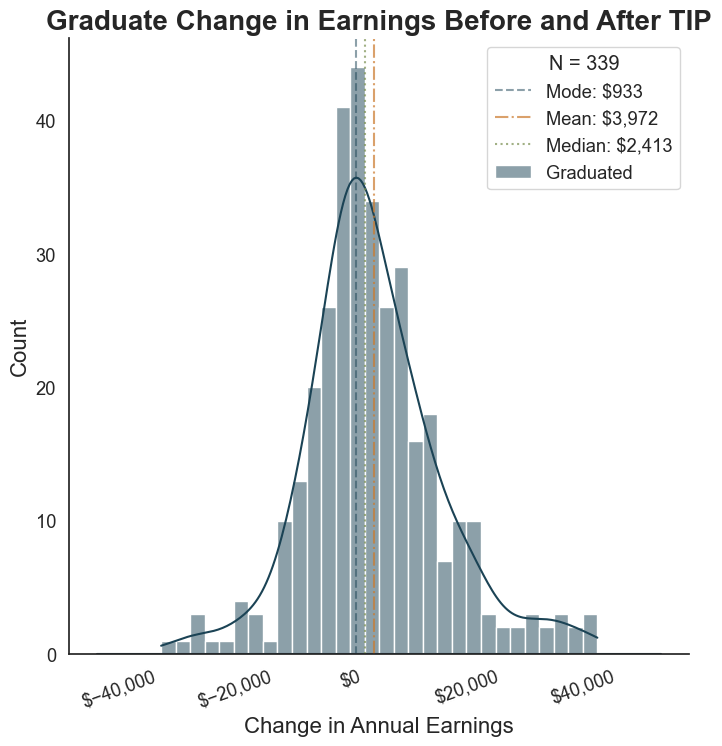

In [420]:
#Examine graduate change in earnings (among graduates with both pre and post data)

# Compute statistics
earn_change_grad = earn_change[earn_change['Status'] == 'Graduated'].copy()
mean_delta = earn_change_grad["delta"].mean()
median_delta = earn_change_grad["delta"].median()

#plot
fig, ax = plt.subplots(figsize=(8, 8))

sns.histplot(
    data=earn_change_grad,
    x="delta",
    kde=True,
    bins=30,
    ax=ax,
    label="Graduated"
)

# KDE peak
kde = sns.kdeplot(data=earn_change_grad, x="delta", ax=ax)
x_vals, y_vals = kde.get_lines()[0].get_data()
peak_idx = y_vals.argmax()
peak_x = x_vals[peak_idx]

ax.axvline(peak_x, linestyle="--", color="C0", alpha=0.5, label=f"Mode: ${peak_x:,.0f}")
ax.axvline(mean_delta, linestyle="-.", color="C1", alpha=0.7, label=f"Mean: ${mean_delta:,.0f}")
ax.axvline(median_delta, linestyle=":", color="C2", alpha=0.7, label=f"Median: ${median_delta:,.0f}")

sns.despine()
plt.title("Graduate Change in Earnings Before and After TIP", fontdict={"fontsize": 20, "fontweight": "semibold"})
ax.xaxis.set_major_formatter("${x:,.0f}")
plt.xticks(rotation=20)
plt.xlabel("Change in Annual Earnings", fontdict={"fontsize": 16})
plt.ylabel("Count", fontdict={"fontsize": 16})
plt.legend(title=f"N = {earn_change_grad.shape[0]}")
plt.show()


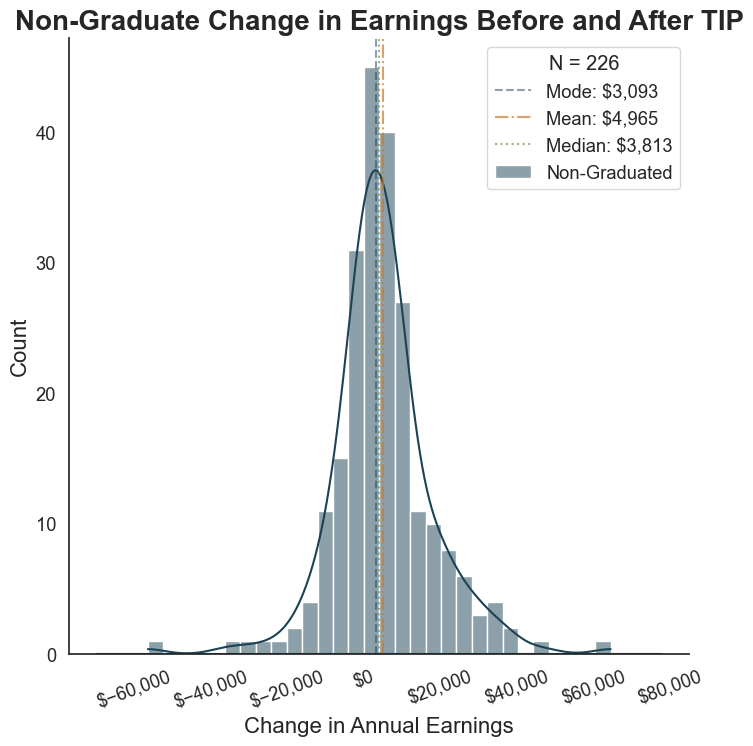

In [421]:
#Repeat for non-grads (among non grads that had both pre- and post- data)
earn_change_non_grad = earn_change[earn_change['Status'] == 'Non Graduated'].copy()
mean_delta = earn_change_non_grad["delta"].mean()
median_delta = earn_change_non_grad["delta"].median()


# plot
fig, ax = plt.subplots(figsize=(8, 8))

sns.histplot(
    data=earn_change_non_grad,
    x="delta",
    kde=True,
    bins=30,
    ax=ax,
    label="Non-Graduated"
)

# KDE peak
kde = sns.kdeplot(data=earn_change_non_grad, x="delta", ax=ax)
x_vals, y_vals = kde.get_lines()[0].get_data()
peak_idx = y_vals.argmax()
peak_x = x_vals[peak_idx]

ax.axvline(peak_x, linestyle="--", color="C0", alpha=0.5, label=f"Mode: ${peak_x:,.0f}")
ax.axvline(mean_delta, linestyle="-.", color="C1", alpha=0.7, label=f"Mean: ${mean_delta:,.0f}")
ax.axvline(median_delta, linestyle=":", color="C2", alpha=0.7, label=f"Median: ${median_delta:,.0f}")

sns.despine()
plt.title("Non-Graduate Change in Earnings Before and After TIP", fontdict={"fontsize": 20, "fontweight": "semibold"})
ax.xaxis.set_major_formatter("${x:,.0f}")
plt.xticks(rotation=20)
plt.xlabel("Change in Annual Earnings", fontdict={"fontsize": 16})
plt.ylabel("Count", fontdict={"fontsize": 16})
plt.legend(title=f"N = {earn_change_non_grad.shape[0]}")
plt.show()


In [422]:
earn_change_grad.describe()

,tip_id,StartDate,StartYear,cohort_2022,adjusted_earnings_pre,adjusted_earnings_post,delta
count,339.000000,339,339.000000,339.000000,339.000000,339.000000,339.000000
mean,1439.722714,2021-08-03 21:14:20.176991232,2021.135693,1.504425,10239.318995,14211.458617,3972.139622
min,501.000000,2017-05-01 00:00:00,2017.000000,1.000000,163.488427,14.789943,-32732.647800
25%,1033.000000,2019-09-12 12:00:00,2019.000000,1.000000,2473.366576,4336.052724,-2383.334618
50%,1477.000000,2022-01-18 00:00:00,2022.000000,2.000000,7181.528222,9640.876080,2413.199982
75%,1832.000000,2023-05-26 00:00:00,2023.000000,2.000000,13609.560752,20165.386979,9633.102334
max,2259.000000,2024-09-23 00:00:00,2024.000000,2.000000,68652.459148,81054.590151,42542.816127
std,468.232797,NaN,2.127419,0.500719,11035.610414,14034.436676,11750.804848


In [423]:
earn_change_non_grad.describe()

,tip_id,StartDate,StartYear,cohort_2022,adjusted_earnings_pre,adjusted_earnings_post,delta
count,226.000000,226,226.000000,226.000000,226.000000,226.000000,226.000000
mean,1302.464602,2021-02-04 14:13:48.318584064,2020.584071,1.345133,8661.672044,13626.549557,4964.877513
min,1.000000,2017-09-18 00:00:00,2017.000000,1.000000,77.159082,90.720252,-56421.345922
25%,976.000000,2019-05-28 00:00:00,2019.000000,1.000000,2569.701387,4992.138679,-872.455999
50%,1259.000000,2020-11-23 12:00:00,2020.000000,1.000000,5497.373685,10572.570837,3812.700479
75%,1610.750000,2022-09-06 00:00:00,2022.000000,2.000000,11197.204420,18946.009755,9792.332441
max,2254.000000,2024-09-09 00:00:00,2024.000000,2.000000,65794.707209,78585.784133,64428.346159
std,446.460690,NaN,1.953803,0.476467,9532.451255,11678.378807,12990.116078


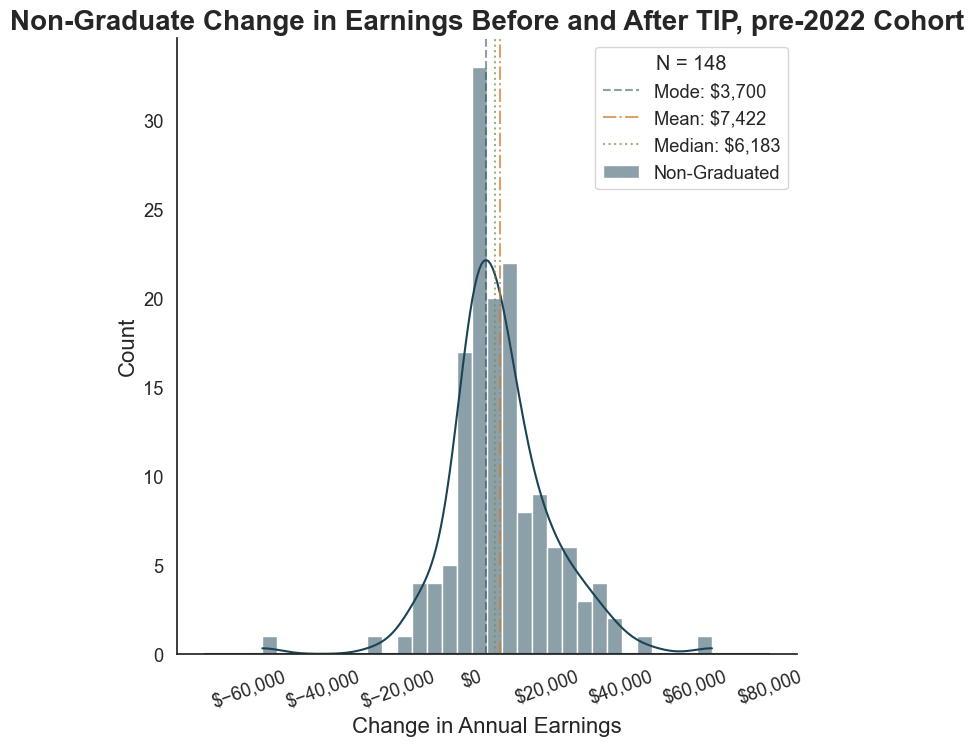

In [424]:
#repeat for cohort 1
earn_change_non_grad_c1 = earn_change_non_grad[earn_change_non_grad['cohort_2022'] == 1].copy()
mean_delta = earn_change_non_grad_c1["delta"].mean()
median_delta = earn_change_non_grad_c1["delta"].median()


# plot
fig, ax = plt.subplots(figsize=(8, 8))

sns.histplot(
    data=earn_change_non_grad_c1,
    x="delta",
    kde=True,
    bins=30,
    ax=ax,
    label="Non-Graduated"
)

# KDE peak
kde = sns.kdeplot(data=earn_change_non_grad_c1, x="delta", ax=ax)
x_vals, y_vals = kde.get_lines()[0].get_data()
peak_idx = y_vals.argmax()
peak_x = x_vals[peak_idx]

ax.axvline(peak_x, linestyle="--", color="C0", alpha=0.5, label=f"Mode: ${peak_x:,.0f}")
ax.axvline(mean_delta, linestyle="-.", color="C1", alpha=0.7, label=f"Mean: ${mean_delta:,.0f}")
ax.axvline(median_delta, linestyle=":", color="C2", alpha=0.7, label=f"Median: ${median_delta:,.0f}")

sns.despine()
plt.title("Non-Graduate Change in Earnings Before and After TIP, pre-2022 Cohort", fontdict={"fontsize": 20, "fontweight": "semibold"})
ax.xaxis.set_major_formatter("${x:,.0f}")
plt.xticks(rotation=20)
plt.xlabel("Change in Annual Earnings", fontdict={"fontsize": 16})
plt.ylabel("Count", fontdict={"fontsize": 16})
plt.legend(title=f"N = {earn_change_non_grad_c1.shape[0]}")
plt.show()


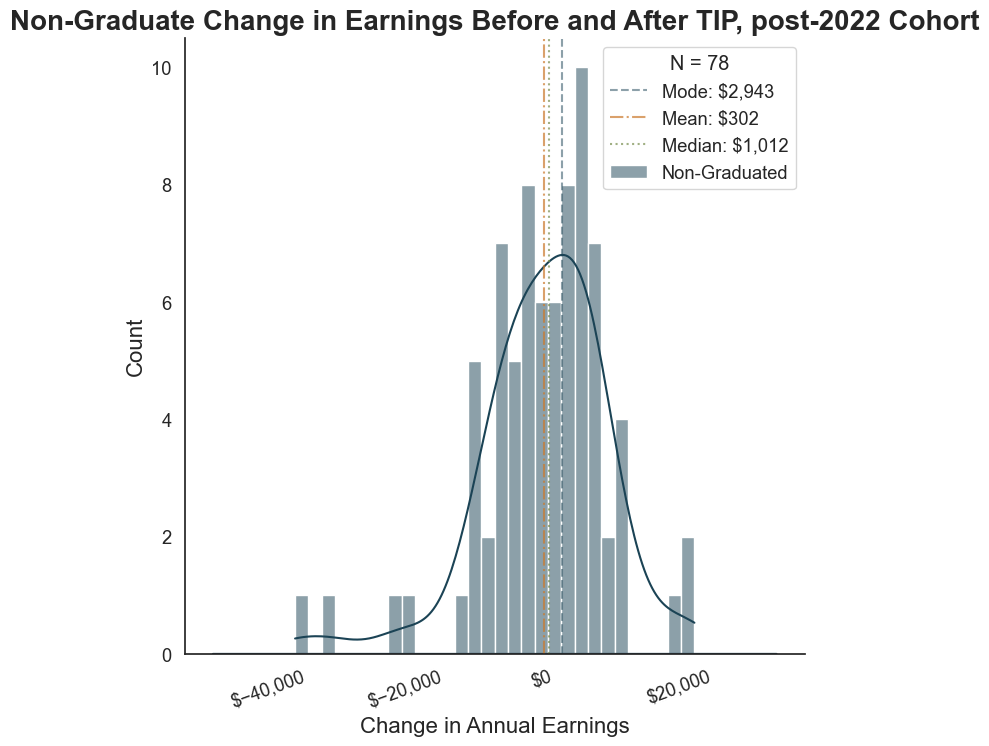

In [425]:
#repeat for cohort 2
earn_change_non_grad_c2 = earn_change_non_grad[earn_change_non_grad['cohort_2022'] == 2].copy()
mean_delta = earn_change_non_grad_c2["delta"].mean()
median_delta = earn_change_non_grad_c2["delta"].median()


# plot
fig, ax = plt.subplots(figsize=(8, 8))

sns.histplot(
    data=earn_change_non_grad_c2,
    x="delta",
    kde=True,
    bins=30,
    ax=ax,
    label="Non-Graduated"
)

# KDE peak
kde = sns.kdeplot(data=earn_change_non_grad_c2, x="delta", ax=ax)
x_vals, y_vals = kde.get_lines()[0].get_data()
peak_idx = y_vals.argmax()
peak_x = x_vals[peak_idx]

ax.axvline(peak_x, linestyle="--", color="C0", alpha=0.5, label=f"Mode: ${peak_x:,.0f}")
ax.axvline(mean_delta, linestyle="-.", color="C1", alpha=0.7, label=f"Mean: ${mean_delta:,.0f}")
ax.axvline(median_delta, linestyle=":", color="C2", alpha=0.7, label=f"Median: ${median_delta:,.0f}")

sns.despine()
plt.title("Non-Graduate Change in Earnings Before and After TIP, post-2022 Cohort", fontdict={"fontsize": 20, "fontweight": "semibold"})
ax.xaxis.set_major_formatter("${x:,.0f}")
plt.xticks(rotation=20)
plt.xlabel("Change in Annual Earnings", fontdict={"fontsize": 16})
plt.ylabel("Count", fontdict={"fontsize": 16})
plt.legend(title=f"N = {earn_change_non_grad_c2.shape[0]}")
plt.show()


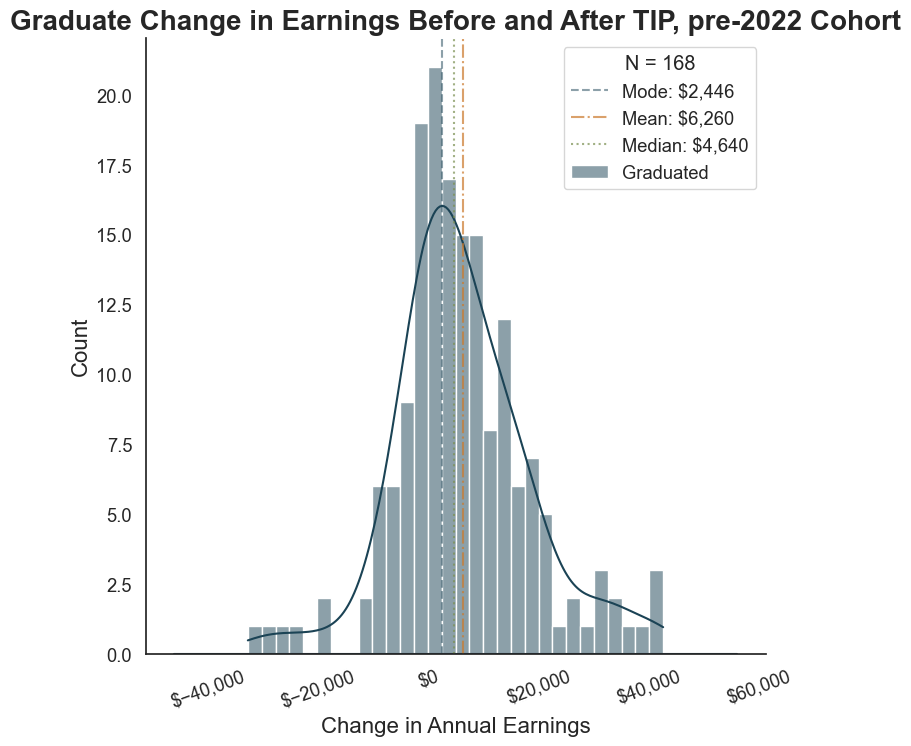

In [426]:
#repeat for cohort 1
earn_change_grad_c1 = earn_change_grad[earn_change_grad['cohort_2022'] == 1].copy()
mean_delta = earn_change_grad_c1["delta"].mean()
median_delta = earn_change_grad_c1["delta"].median()


# plot
fig, ax = plt.subplots(figsize=(8, 8))

sns.histplot(
    data=earn_change_grad_c1,
    x="delta",
    kde=True,
    bins=30,
    ax=ax,
    label="Graduated"
)

# KDE peak
kde = sns.kdeplot(data=earn_change_grad_c1, x="delta", ax=ax)
x_vals, y_vals = kde.get_lines()[0].get_data()
peak_idx = y_vals.argmax()
peak_x = x_vals[peak_idx]

ax.axvline(peak_x, linestyle="--", color="C0", alpha=0.5, label=f"Mode: ${peak_x:,.0f}")
ax.axvline(mean_delta, linestyle="-.", color="C1", alpha=0.7, label=f"Mean: ${mean_delta:,.0f}")
ax.axvline(median_delta, linestyle=":", color="C2", alpha=0.7, label=f"Median: ${median_delta:,.0f}")

sns.despine()
plt.title("Graduate Change in Earnings Before and After TIP, pre-2022 Cohort", fontdict={"fontsize": 20, "fontweight": "semibold"})
ax.xaxis.set_major_formatter("${x:,.0f}")
plt.xticks(rotation=20)
plt.xlabel("Change in Annual Earnings", fontdict={"fontsize": 16})
plt.ylabel("Count", fontdict={"fontsize": 16})
plt.legend(title=f"N = {earn_change_grad_c1.shape[0]}")
plt.show()


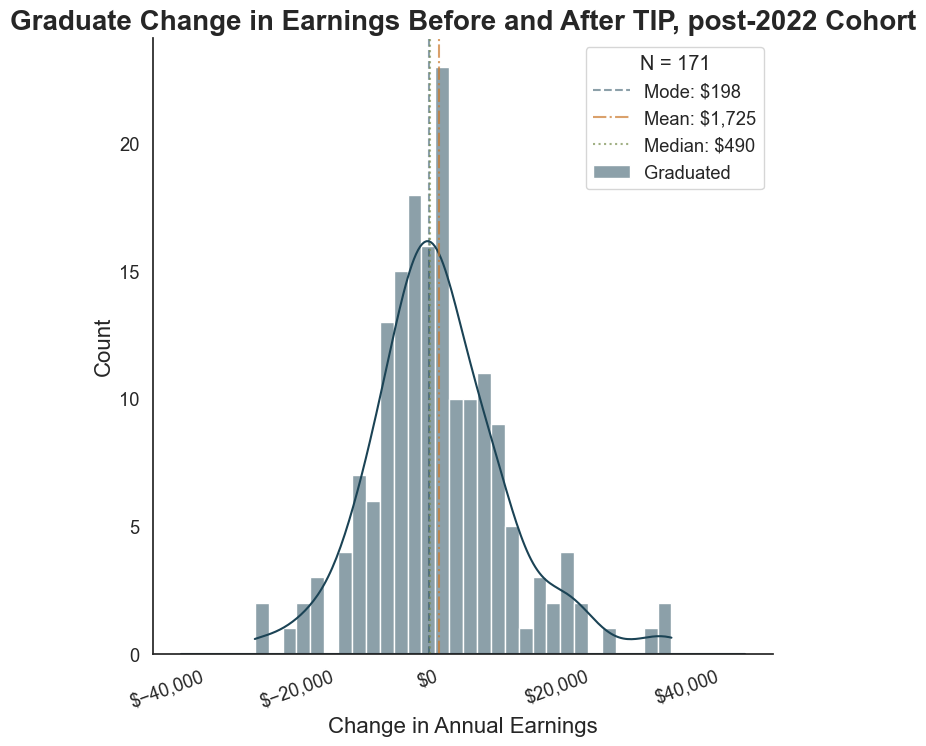

In [427]:
#repeat for cohort 2
earn_change_grad_c2 = earn_change_grad[earn_change_grad['cohort_2022'] == 2].copy()
mean_delta = earn_change_grad_c2["delta"].mean()
median_delta = earn_change_grad_c2["delta"].median()


# plot
fig, ax = plt.subplots(figsize=(8, 8))

sns.histplot(
    data=earn_change_grad_c2,
    x="delta",
    kde=True,
    bins=30,
    ax=ax,
    label="Graduated"
)

# KDE peak
kde = sns.kdeplot(data=earn_change_grad_c2, x="delta", ax=ax)
x_vals, y_vals = kde.get_lines()[0].get_data()
peak_idx = y_vals.argmax()
peak_x = x_vals[peak_idx]

ax.axvline(peak_x, linestyle="--", color="C0", alpha=0.5, label=f"Mode: ${peak_x:,.0f}")
ax.axvline(mean_delta, linestyle="-.", color="C1", alpha=0.7, label=f"Mean: ${mean_delta:,.0f}")
ax.axvline(median_delta, linestyle=":", color="C2", alpha=0.7, label=f"Median: ${median_delta:,.0f}")

sns.despine()
plt.title("Graduate Change in Earnings Before and After TIP, post-2022 Cohort", fontdict={"fontsize": 20, "fontweight": "semibold"})
ax.xaxis.set_major_formatter("${x:,.0f}")
plt.xticks(rotation=20)
plt.xlabel("Change in Annual Earnings", fontdict={"fontsize": 16})
plt.ylabel("Count", fontdict={"fontsize": 16})
plt.legend(title=f"N = {earn_change_grad_c2.shape[0]}")
plt.show()


In [428]:
earn_change_non_grad_c1.describe()

,tip_id,StartDate,StartYear,cohort_2022,adjusted_earnings_pre,adjusted_earnings_post,delta
count,148.000000,148,148.000000,148.0,148.000000,148.000000,148.000000
mean,1055.925676,2019-11-29 14:25:56.756756736,2019.385135,1.0,8515.022315,15937.354421,7422.332106
min,1.000000,2017-09-18 00:00:00,2017.000000,1.0,77.159082,318.453043,-56421.345922
25%,881.000000,2018-12-13 12:00:00,2018.000000,1.0,2000.158309,6414.448149,449.396253
50%,1052.500000,2019-10-17 12:00:00,2019.000000,1.0,4967.953850,13118.740795,6182.837310
75%,1264.250000,2020-10-24 06:00:00,2020.000000,1.0,11301.543925,21917.851457,13302.998822
max,1484.000000,2021-12-13 00:00:00,2021.000000,1.0,62634.426890,78585.784133,64428.346159
std,278.981166,NaN,1.151891,0.0,9492.377276,12565.048872,13880.205045


In [429]:
earn_change_non_grad_c2.describe()

,tip_id,StartDate,StartYear,cohort_2022,adjusted_earnings_pre,adjusted_earnings_post,delta
count,78.000000,78,78.000000,78.0,78.000000,78.000000,78.000000
mean,1770.256410,2023-05-07 04:00:00,2022.858974,2.0,8939.930503,9241.945456,302.014954
min,503.000000,2022-01-03 00:00:00,2022.000000,2.0,332.874578,90.720252,-36093.205535
25%,1604.750000,2022-08-20 12:00:00,2022.000000,2.0,3383.827220,3236.271004,-4782.679505
50%,1780.500000,2023-05-15 00:00:00,2023.000000,2.0,6400.322202,6679.694542,1011.511541
75%,1972.500000,2023-12-04 00:00:00,2023.000000,2.0,11153.771547,12000.736359,6196.740885
max,2254.000000,2024-09-09 00:00:00,2024.000000,2.0,65794.707209,34947.992858,22313.982726
std,308.814173,NaN,0.784995,0.0,9663.511171,8208.539278,9573.017275


In [430]:
earn_change_grad_c1.describe()

,tip_id,StartDate,StartYear,cohort_2022,adjusted_earnings_pre,adjusted_earnings_post,delta
count,168.000000,168,168.000000,168.0,168.000000,168.000000,168.000000
mean,1047.244048,2019-10-01 15:25:42.857142784,2019.261905,1.0,10124.250022,16383.813200,6259.563178
min,551.000000,2017-05-01 00:00:00,2017.000000,1.0,163.488427,80.448787,-32732.647800
25%,814.250000,2018-09-02 00:00:00,2018.000000,1.0,1984.191369,5512.508268,-963.904515
50%,1040.500000,2019-08-26 00:00:00,2019.000000,1.0,6205.351930,11842.839324,4640.026623
75%,1265.500000,2020-10-15 12:00:00,2020.000000,1.0,12746.456704,22159.458377,13100.453142
max,1485.000000,2021-12-20 00:00:00,2021.000000,1.0,62745.285262,70853.168317,42542.816127
std,257.542846,NaN,1.239268,0.0,11780.554584,14487.297663,12485.325305


In [431]:
earn_change_grad_c2.describe()

,tip_id,StartDate,StartYear,cohort_2022,adjusted_earnings_pre,adjusted_earnings_post,delta
count,171.000000,171,171.000000,171.0,171.000000,171.000000,171.000000
mean,1825.315789,2023-05-26 08:00:00,2022.976608,2.0,10352.369213,12077.215518,1724.846305
min,501.000000,2022-01-03 00:00:00,2022.000000,2.0,183.802210,14.789943,-26544.935419
25%,1658.500000,2022-10-10 12:00:00,2022.000000,2.0,2983.173876,3216.597214,-4401.976063
50%,1831.000000,2023-05-22 00:00:00,2023.000000,2.0,8051.583186,7801.458184,489.844992
75%,2024.500000,2024-01-25 12:00:00,2024.000000,2.0,13937.212974,16367.498020,7123.274267
max,2259.000000,2024-09-23 00:00:00,2024.000000,2.0,68652.459148,81054.590151,37572.783980
std,262.607837,NaN,0.781802,0.0,10284.858340,13273.665480,10543.011501


In [1942]:
#Difference in average pre-annual salary
##overall
e1 = pd.to_numeric(df_e_combined[df_e_combined["cohort_2022"] == 1]["adjusted_earnings_pre"], errors="coerce").dropna()
e2 = pd.to_numeric(df_e_combined[df_e_combined["cohort_2022"] == 2]["adjusted_earnings_pre"], errors="coerce").dropna()

t, p = ttest_ind(e1, e2, equal_var=False)

print("Pre-Annual Across Cohorts")
print("t-value:", t)
print("p-value:", p)
print("n1:", len(e1))
print("n2:", len(e2))

##within Cohort 1
df_e_combined_c1 = df_e_combined[df_e_combined["cohort_2022"] == 1].copy()
df_e_combined_c2 = df_e_combined[df_e_combined["cohort_2022"] == 2].copy()

e1 = pd.to_numeric(df_e_combined_c1[df_e_combined_c1["Status"] == "Graduated"]["adjusted_earnings_pre"], errors="coerce").dropna()
e2 = pd.to_numeric(df_e_combined_c1[df_e_combined_c1["Status"] == "Non Graduated"]["adjusted_earnings_pre"], errors="coerce").dropna()

t, p = ttest_ind(e1, e2, equal_var=False)

print("#################")
print("Pre-Annual Within Cohort 1")
print("t-value:", t)
print("p-value:", p)
print("n1:", len(e1))
print("n2:", len(e2))

##within Cohort 1

e1 = pd.to_numeric(df_e_combined_c2[df_e_combined_c2["Status"] == "Graduated"]["adjusted_earnings_pre"], errors="coerce").dropna()
e2 = pd.to_numeric(df_e_combined_c2[df_e_combined_c2["Status"] == "Non Graduated"]["adjusted_earnings_pre"], errors="coerce").dropna()

t, p = ttest_ind(e1, e2, equal_var=False)

print("#################")
print("Pre-Annual Within Cohort 2")
print("t-value:", t)
print("p-value:", p)
print("n1:", len(e1))
print("n2:", len(e2))

##graduated
df_e_combined_grad = df_e_combined[df_e_combined["Status"] == "Graduated"].copy()
e1 = pd.to_numeric(df_e_combined_grad[df_e_combined_grad["cohort_2022"] == 1]["adjusted_earnings_pre"], errors="coerce").dropna()
e2 = pd.to_numeric(df_e_combined_grad[df_e_combined_grad["cohort_2022"] == 2]["adjusted_earnings_pre"], errors="coerce").dropna()

t, p = ttest_ind(e1, e2, equal_var=False)
print("#################")
print("Pre-Annual among Grads Only")
print("t-value:", t)
print("p-value:", p)
print("n1:", len(e1))
print("n2:", len(e2))

##nongraduated
df_e_combined_non_grad = df_e_combined[df_e_combined["Status"] == "Non Graduated"].copy()
e1 = pd.to_numeric(df_e_combined_non_grad[df_e_combined_non_grad["cohort_2022"] == 1]["adjusted_earnings_pre"], errors="coerce").dropna()
e2 = pd.to_numeric(df_e_combined_non_grad[df_e_combined_non_grad["cohort_2022"] == 2]["adjusted_earnings_pre"], errors="coerce").dropna()

t, p = ttest_ind(e1, e2, equal_var=False)
print("#################")
print("Pre-Annual among Non-Grads Only")
print("t-value:", t)
print("p-value:", p)
print("n1:", len(e1))
print("n2:", len(e2))


Pre-Annual Across Cohorts
t-value: -1.1475473303099288
p-value: 0.25151178352578984
n1: 389
n2: 416
#################
Pre-Annual Within Cohort 1
t-value: 1.1137727413127403
p-value: 0.26606803290248515
n1: 189
n2: 200
#################
Pre-Annual Within Cohort 2
t-value: 3.9777489922060427
p-value: 8.224469556812349e-05
n1: 215
n2: 201
#################
Pre-Annual among Grads Only
t-value: -1.8809711892747474
p-value: 0.06072414215573534
n1: 189
n2: 215
#################
Pre-Annual among Non-Grads Only
t-value: 0.4460511234251849
p-value: 0.6558200055887053
n1: 200
n2: 201


In [1943]:
#Difference in average post-annual salary
##overall
e1 = pd.to_numeric(df_e_combined[df_e_combined["cohort_2022"] == 1]["adjusted_earnings_post"], errors="coerce").dropna()
e2 = pd.to_numeric(df_e_combined[df_e_combined["cohort_2022"] == 2]["adjusted_earnings_post"], errors="coerce").dropna()

t, p = ttest_ind(e1, e2, equal_var=False)

print("Post-Annual Across Cohorts")
print("t-value:", t)
print("p-value:", p)
print("n1:", len(e1))
print("n2:", len(e2))

##within Cohort 1
e1 = pd.to_numeric(df_e_combined_c1[df_e_combined_c1["Status"] == "Graduated"]["adjusted_earnings_post"], errors="coerce").dropna()
e2 = pd.to_numeric(df_e_combined_c1[df_e_combined_c1["Status"] == "Non Graduated"]["adjusted_earnings_post"], errors="coerce").dropna()

t, p = ttest_ind(e1, e2, equal_var=False)

print("#################")
print("Post-Annual Within Cohort 1")
print("t-value:", t)
print("p-value:", p)
print("n1:", len(e1))
print("n2:", len(e2))

##within Cohort 1

e1 = pd.to_numeric(df_e_combined_c2[df_e_combined_c2["Status"] == "Graduated"]["adjusted_earnings_post"], errors="coerce").dropna()
e2 = pd.to_numeric(df_e_combined_c2[df_e_combined_c2["Status"] == "Non Graduated"]["adjusted_earnings_post"], errors="coerce").dropna()

t, p = ttest_ind(e1, e2, equal_var=False)

print("#################")
print("Post-Annual Within Cohort 2")
print("t-value:", t)
print("p-value:", p)
print("n1:", len(e1))
print("n2:", len(e2))

##graduated
df_e_combined_grad = df_e_combined[df_e_combined["Status"] == "Graduated"].copy()
e1 = pd.to_numeric(df_e_combined_grad[df_e_combined_grad["cohort_2022"] == 1]["adjusted_earnings_post"], errors="coerce").dropna()
e2 = pd.to_numeric(df_e_combined_grad[df_e_combined_grad["cohort_2022"] == 2]["adjusted_earnings_post"], errors="coerce").dropna()

t, p = ttest_ind(e1, e2, equal_var=False)
print("#################")
print("Post-Annual among Grads Only")
print("t-value:", t)
print("p-value:", p)
print("n1:", len(e1))
print("n2:", len(e2))

##nongraduated
df_e_combined_non_grad = df_e_combined[df_e_combined["Status"] == "Non Graduated"].copy()
e1 = pd.to_numeric(df_e_combined_non_grad[df_e_combined_non_grad["cohort_2022"] == 1]["adjusted_earnings_post"], errors="coerce").dropna()
e2 = pd.to_numeric(df_e_combined_non_grad[df_e_combined_non_grad["cohort_2022"] == 2]["adjusted_earnings_post"], errors="coerce").dropna()

t, p = ttest_ind(e1, e2, equal_var=False)
print("#################")
print("Post-Annual among Non-Grads Only")
print("t-value:", t)
print("p-value:", p)
print("n1:", len(e1))
print("n2:", len(e2))


Post-Annual Across Cohorts
t-value: 6.258160021395966
p-value: 5.998414733028038e-10
n1: 867
n2: 366
#################
Post-Annual Within Cohort 1
t-value: 3.138409829714044
p-value: 0.001758609289959464
n1: 451
n2: 416
#################
Post-Annual Within Cohort 2
t-value: 5.462713429678022
p-value: 8.861108020374146e-08
n1: 202
n2: 164
#################
Post-Annual among Grads Only
t-value: 3.3918640259119854
p-value: 0.0007579315730556491
n1: 451
n2: 202
#################
Post-Annual among Non-Grads Only
t-value: 6.376170082075286
p-value: 3.957109849266346e-10
n1: 416
n2: 164


In [1944]:
#Change in pre/post salary
##overall
e1 = pd.to_numeric(earn_change[earn_change["cohort_2022"] == 1]["delta"], errors="coerce").dropna()
e2 = pd.to_numeric(earn_change[earn_change["cohort_2022"] == 2]["delta"], errors="coerce").dropna()

t, p = ttest_ind(e1, e2, equal_var=False)

print("Earnings Change Across Cohorts")
print("t-value:", t)
print("p-value:", p)
print("n1:", len(e1))
print("n2:", len(e2))

##within Cohort 1
e1 = earn_change_grad_c1["delta"]
e2 = earn_change_non_grad_c1["delta"]

t, p = ttest_ind(e1, e2, equal_var=False)

print("#################")
print("Earnings Change Within Cohort 1")
print("t-value:", t)
print("p-value:", p)
print("n1:", len(e1))
print("n2:", len(e2))

##within Cohort 2

e1 = earn_change_grad_c2["delta"]
e2 = earn_change_non_grad_c2["delta"]

t, p = ttest_ind(e1, e2, equal_var=False)

print("#################")
print("Earnings Change Within Cohort 2")
print("t-value:", t)
print("p-value:", p)
print("n1:", len(e1))
print("n2:", len(e2))

##graduated
e1 = earn_change_grad[earn_change_grad["cohort_2022"] == 1]["delta"]
e2 = earn_change_grad[earn_change_grad["cohort_2022"] == 2]["delta"]

t, p = ttest_ind(e1, e2, equal_var=False)
print("#################")
print("Earnings Change among Grads Only")
print("t-value:", t)
print("p-value:", p)
print("n1:", len(e1))
print("n2:", len(e2))

##nongraduated

e1 = earn_change_non_grad[earn_change_non_grad["cohort_2022"] == 1]["delta"]
e2 = earn_change_non_grad[earn_change_non_grad["cohort_2022"] == 2]["delta"]

t, p = ttest_ind(e1, e2, equal_var=False)
print("#################")
print("Earnings Change among Non-Grads Only")
print("t-value:", t)
print("p-value:", p)
print("n1:", len(e1))
print("n2:", len(e2))

Earnings Change Across Cohorts
t-value: 7.186905418568905
p-value: 1.6704608186090085e-12
n1: 376
n2: 342
#################
Earnings Change Within Cohort 1
t-value: 1.563806725331676
p-value: 0.1187147339235355
n1: 186
n2: 190
#################
Earnings Change Within Cohort 2
t-value: 1.6563010304111019
p-value: 0.09858760953558954
n1: 188
n2: 154
#################
Earnings Change among Grads Only
t-value: 5.206869400260217
p-value: 3.1858016896142317e-07
n1: 186
n2: 188
#################
Earnings Change among Non-Grads Only
t-value: 5.258091362909057
p-value: 2.5932958525011365e-07
n1: 190
n2: 154


In [1945]:
#DiD - Earnings

import statsmodels.formula.api as smf

earn_change['treatment'] = (earn_change['Status'] == 'Graduated').astype(int)
earn_change['cohort2'] = (earn_change['cohort_2022'] == 2).astype(int)

# regression for triple diff
# earnings_diff ~ treatment*cohort2
model = smf.ols("delta ~ treatment * cohort2", data=earn_change).fit()
print(model.summary())

##add conditional variables - race, gender, pre annual earnings
##transform to a logit - 1/0 if employed post, 1/0 if arrest post, 1/0 for social service usage (SNAP, Medicaid)
##display it compared to the pre-period averages

                            OLS Regression Results                            
Dep. Variable:                  delta   R-squared:                       0.073
Model:                            OLS   Adj. R-squared:                  0.069
Method:                 Least Squares   F-statistic:                     18.75
Date:                Tue, 17 Mar 2026   Prob (F-statistic):           1.03e-11
Time:                        01:01:29   Log-Likelihood:                -7729.4
No. Observations:                 718   AIC:                         1.547e+04
Df Residuals:                     714   BIC:                         1.549e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept          6956.5313    833.37